# Projeto 006 — Preparação dos dados de café no Kaggle

Este notebook foi adaptado para execução no Kaggle. A planilha é localizada automaticamente em `/kaggle/input`, enquanto todos os arquivos gerados são salvos em `/kaggle/working/projeto001_resultados`.

Nenhuma amostra, variável, valor extremo ou resultado é excluído automaticamente.


## 1. Ambiente Python do Kaggle

O Kaggle utiliza o próprio ambiente Python; portanto, não é necessário criar ou selecionar o ambiente virtual do Windows/VS Code.

As bibliotecas científicas empregadas neste notebook normalmente já estão disponíveis na imagem padrão do Kaggle.


In [1]:
import sys
from pathlib import Path

print("Interpretador Python em uso:")
print(sys.executable)

PASTA_KAGGLE_INPUT = Path("/kaggle/input")
PASTA_KAGGLE_WORKING = Path("/kaggle/working")

if not PASTA_KAGGLE_INPUT.exists():
    raise RuntimeError(
        "A pasta /kaggle/input não foi encontrada. "
        "Este notebook foi preparado para execução no Kaggle."
    )

print("\nAmbiente Kaggle identificado corretamente.")


Interpretador Python em uso:
/usr/bin/python3

Ambiente Kaggle identificado corretamente.


## 2. Importação das bibliotecas

As bibliotecas abaixo serão utilizadas na organização, visualização, quimiometria e análise estatística. A imagem padrão do Kaggle normalmente já inclui essas dependências.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_score

plt.rcParams["figure.dpi"] = 140

print("Bibliotecas importadas corretamente.")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

Bibliotecas importadas corretamente.
pandas: 2.3.3
numpy: 2.0.2


## 3. Localização da planilha e definição das saídas

Antes de executar o notebook, adicione ao Kaggle a planilha:

```text
Tabela analise multivariada_FJMN marcos_outliers3.xlsx
```

O código procura a planilha recursivamente em `/kaggle/input`. Os CSV e gráficos gerados são gravados em `/kaggle/working/projeto001_resultados`, porque `/kaggle/input` é somente leitura.


In [3]:
from pathlib import Path

# Pasta de leitura: arquivos adicionados ao notebook Kaggle
PASTA_ENTRADA = Path("/kaggle/input")

# Pasta gravável: resultados produzidos pelo notebook
PASTA_PROJETO = Path("/kaggle/working/projeto001_resultados")
PASTA_PROJETO.mkdir(parents=True, exist_ok=True)

NOME_PLANILHA = "Tabela analise multivariada_FJMN marcos_outliers3.xlsx"

# Primeiro, procurar pelo nome exato em qualquer subpasta de /kaggle/input
candidatos_exatos = list(PASTA_ENTRADA.rglob(NOME_PLANILHA))

if len(candidatos_exatos) == 1:
    ARQUIVO_EXCEL = candidatos_exatos[0]

elif len(candidatos_exatos) > 1:
    nomes = "\n".join(f"- {arquivo}" for arquivo in candidatos_exatos)
    raise RuntimeError(
        "Foram encontradas várias cópias da planilha com o nome exato:\n"
        f"{nomes}\n"
        "Mantenha somente uma cópia adicionada ao notebook."
    )

else:
    # Busca alternativa caso o Kaggle altere ou simplifique o nome do arquivo
    candidatos = [
        arquivo
        for arquivo in PASTA_ENTRADA.rglob("*.xls*")
        if all(
            termo in arquivo.name.lower()
            for termo in ("fjmn", "marcos", "outliers")
        )
    ]

    if len(candidatos) == 1:
        ARQUIVO_EXCEL = candidatos[0]
    elif len(candidatos) == 0:
        arquivos_excel = list(PASTA_ENTRADA.rglob("*.xls*"))
        encontrados = (
            "\n".join(f"- {arquivo}" for arquivo in arquivos_excel)
            if arquivos_excel
            else "Nenhum arquivo Excel foi encontrado em /kaggle/input."
        )
        raise FileNotFoundError(
            "A planilha necessária não foi localizada.\n"
            "Adicione-a ao notebook pelo botão Add Input.\n\n"
            f"Arquivos Excel encontrados:\n{encontrados}"
        )
    else:
        nomes = "\n".join(f"- {arquivo}" for arquivo in candidatos)
        raise RuntimeError(
            "Foram encontradas várias planilhas possíveis:\n"
            f"{nomes}\n"
            "Mantenha somente a planilha correta ou defina ARQUIVO_EXCEL manualmente."
        )

print("Pasta de entrada:", PASTA_ENTRADA)
print("Pasta dos resultados:", PASTA_PROJETO)
print("Planilha selecionada:", ARQUIVO_EXCEL)


Pasta de entrada: /kaggle/input
Pasta dos resultados: /kaggle/working/projeto001_resultados
Planilha selecionada: /kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx


## 4. Conferência das abas da planilha

Antes de importar os dados, são listados os nomes de todas as abas. Essa conferência é importante porque a planilha reúne composição química, cicatrização, fotoproteção e marcadores de estresse oxidativo.

In [4]:
arquivo_excel = pd.ExcelFile(ARQUIVO_EXCEL)

print(f"Total de abas: {len(arquivo_excel.sheet_names)}")
for numero, nome in enumerate(arquivo_excel.sheet_names):
    print(f"{numero:02d} — {nome}")

Total de abas: 12
00 — Abreviações
01 — Componentes dos óleos
02 — Cicatrização (área da ferida)
03 — Cicatr.(contração da ferida)
04 — Fotoproteção (ABSORÇÃO)
05 — Fotoproteção (FPS)
06 — Antibacteriana
07 — Estresse oxid.(FRAP)
08 — Estres. Oxid.(MDA)
09 — Estr. Oxid.(Proteinas)
10 — Estr. Oxd.(SOD)
11 — Estr. Oxid. (Catalase)


## 5. Importação integral das abas

Todas as abas são importadas com `header=None`, preservando a estrutura original das células.

Os dados brutos são armazenados no dicionário `abas_brutas`. Cada chave é o nome de uma aba e cada valor é um DataFrame. Nesta célula não há limpeza, imputação, exclusão ou padronização.

In [5]:
abas_brutas = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=None,
    header=None
)

resumo_abas = pd.DataFrame(
    [
        {
            "ordem": ordem,
            "aba": nome,
            "linhas": tabela.shape[0],
            "colunas": tabela.shape[1]
        }
        for ordem, (nome, tabela) in enumerate(abas_brutas.items())
    ]
)

display(resumo_abas)

,ordem,aba,linhas,colunas
0,0,Abreviações,15,2
1,1,Componentes dos óleos,39,16
2,2,Cicatrização (área da ferida),213,13
3,3,Cicatr.(contração da ferida),16,6
4,4,Fotoproteção (ABSORÇÃO),123,12
5,5,Fotoproteção (FPS),2,12
6,6,Antibacteriana,8,14
7,7,Estresse oxid.(FRAP),15,19
8,8,Estres. Oxid.(MDA),15,19
9,9,Estr. Oxid.(Proteinas),15,20


## 6. Seleção da aba de composição química

A aba de interesse nesta primeira parte é **Componentes dos óleos**.

A seleção é feita pelo nome da aba, e não pelo tamanho da tabela. Isso evita o erro do notebook anterior, que selecionava automaticamente a maior aba e podia carregar dados de cicatrização no lugar da composição química.

In [6]:
candidatas_quimica = [
    nome
    for nome in abas_brutas
    if "componentes dos" in nome.lower()
]

if len(candidatas_quimica) != 1:
    raise RuntimeError(
        "Não foi possível identificar de forma única a aba "
        "'Componentes dos óleos'. "
        f"Abas candidatas: {candidatas_quimica}"
    )

NOME_ABA_QUIMICA = candidatas_quimica[0]
quimica_bruta = abas_brutas[NOME_ABA_QUIMICA].copy()

print("Aba selecionada:", NOME_ABA_QUIMICA)
print("Dimensão bruta:", quimica_bruta.shape)

display(quimica_bruta.head(10))

Aba selecionada: Componentes dos óleos
Dimensão bruta: (39, 16)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,NaN,Composto,Teor (mg/mL),NaN,NaN,Teor (mg/mL),NaN,NaN,Teor (mg/mL),NaN,NaN,NaN,NaN,NaN,Teor (mg/mL),NaN
1,tR (min),NaN,OCV,OCV-B,NaN,OCB,OCB-B,NaN,OCC,OCC-TC,OCC-TM,OCC-TE,OCC-TME,NaN,OC-BR,OC-BD
2,5.71,Ácido palmítico,1.811095,4.755756,NaN,1.939807,3.088236,NaN,0.504649,0.782495,1.895978,2.408786,3.676306,NaN,0.885206,0.711454
3,6.39,Cafeína,0.370544,1.009628,NaN,0.349252,0.564784,NaN,0.314963,0.360212,0.631691,0.553139,0.54365,NaN,0.359316,0.215336
4,6.47,Ácido linoleico,1.010604,1.706466,NaN,0.989264,1.003551,NaN,0.444661,0.85243,1.381854,1.249773,1.20735,NaN,1.584211,0.74008
5,8.13,Caveal,0.550683,0.513038,NaN,0.634226,0.560683,NaN,1.00562,1.209463,2.07564,2.008629,2.062697,NaN,0.555683,0.634226
6,8.22,"15,16-dehydro-caveol",0.826202,0.917395,NaN,1.214631,1.010749,NaN,0.739335,1.041805,4.272761,6.665273,8.719215,NaN,0.917395,1.31986
7,8.31,Cafestal,0.846768,0.567505,NaN,2.375339,1.297941,NaN,0.70547,0.366832,0.776834,0.545147,1.335977,NaN,2.822587,1.275307
8,8.46,"15,16-dehydro-cafestol",0.390452,0.551727,NaN,0.746493,1.605316,NaN,1.21374,1.079835,1.902998,4.979886,10.797935,NaN,0.51672,0.721195
9,8.51,Dehidro-caveol,0.702982,0.78961,NaN,1.448226,0.724275,NaN,1.5748,1.341463,1.897175,3.615129,8.075606,NaN,1.011376,0.964808


## 7. Identificação automática do cabeçalho dos perfis

A tabela química possui colunas identificadoras — como tempo de retenção e nome do composto — seguidas pelos códigos dos perfis de café.

O código procura a linha que contém o maior número dos 11 códigos esperados. Assim, evita-se deslocar as colunas ou transformar o tempo de retenção em nome de composto.

Perfis esperados:

`OCV`, `OCC`, `OCB`, `OCC-TC`, `OCC-TM`, `OCC-TE`, `OCC-TME`, `OCV-B`, `OCB-B`, `OC-BD` e `OC-BR`.

In [7]:
PERFIS_ESPERADOS = [
    "OCV",
    "OCC",
    "OCB",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
]

def normalizar_texto(valor):
    if pd.isna(valor):
        return ""
    return str(valor).strip().upper()

contagens_por_linha = {}

for indice, linha in quimica_bruta.iterrows():
    valores = {normalizar_texto(valor) for valor in linha.tolist()}
    contagens_por_linha[indice] = sum(
        perfil in valores for perfil in PERFIS_ESPERADOS
    )

LINHA_CABECALHO = max(
    contagens_por_linha,
    key=contagens_por_linha.get
)

quantidade_detectada = contagens_por_linha[LINHA_CABECALHO]

print("Linha identificada como cabeçalho:", LINHA_CABECALHO)
print("Perfis reconhecidos nessa linha:", quantidade_detectada)
display(quimica_bruta.iloc[[LINHA_CABECALHO]])

Linha identificada como cabeçalho: 1
Perfis reconhecidos nessa linha: 11


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
1,tR (min),NaN,OCV,OCV-B,NaN,OCB,OCB-B,NaN,OCC,OCC-TC,OCC-TM,OCC-TE,OCC-TME,NaN,OC-BR,OC-BD


## 8. Construção correta da matriz química

A célula abaixo:

- localiza a coluna de cada perfil pelo código;
- preserva as colunas identificadoras anteriores aos perfis;
- mantém tempo de retenção e nome do composto separadamente;
- converte somente as concentrações para valores numéricos;
- não exclui valores extremos;
- não imputa valores ausentes;
- não elimina perfis nem compostos.

A matriz principal será armazenada em `df_quimica`. As linhas representam compostos e as colunas representam os 11 perfis.

In [8]:
cabecalho = [
    normalizar_texto(valor)
    for valor in quimica_bruta.iloc[LINHA_CABECALHO].tolist()
]

colunas_perfis = {}

for perfil in PERFIS_ESPERADOS:
    posicoes = [
        indice
        for indice, valor in enumerate(cabecalho)
        if valor == perfil
    ]

    if len(posicoes) == 1:
        colunas_perfis[perfil] = posicoes[0]
    elif len(posicoes) == 0:
        raise ValueError(
            f"O perfil {perfil!r} não foi encontrado na linha de cabeçalho."
        )
    else:
        raise ValueError(
            f"O perfil {perfil!r} aparece mais de uma vez no cabeçalho."
        )

primeira_coluna_perfil = min(colunas_perfis.values())
colunas_identificadoras = list(range(primeira_coluna_perfil))

if len(colunas_identificadoras) < 2:
    raise ValueError(
        "Foram encontradas menos de duas colunas identificadoras antes "
        "dos perfis. Confira visualmente a aba."
    )

dados = quimica_bruta.iloc[LINHA_CABECALHO + 1:].copy()

# Mantém as duas últimas colunas identificadoras antes dos perfis.
coluna_tempo = colunas_identificadoras[-2]
coluna_composto = colunas_identificadoras[-1]

df_quimica = pd.DataFrame({
    "Tempo_retencao": dados.iloc[:, coluna_tempo],
    "Composto": dados.iloc[:, coluna_composto],
})

for perfil in PERFIS_ESPERADOS:
    coluna = colunas_perfis[perfil]
    df_quimica[perfil] = dados.iloc[:, coluna]

# Conversão controlada dos campos.
df_quimica["Tempo_retencao"] = pd.to_numeric(
    df_quimica["Tempo_retencao"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False),
    errors="coerce"
)

df_quimica["Composto"] = (
    df_quimica["Composto"]
        .astype("string")
        .str.strip()
)

for perfil in PERFIS_ESPERADOS:
    df_quimica[perfil] = pd.to_numeric(
        df_quimica[perfil]
            .replace(["_", "-", "–", "—", ""], np.nan)
            .astype(str)
            .str.strip()
            .str.replace(",", ".", regex=False),
        errors="coerce"
    )

print("Dimensão da matriz construída:", df_quimica.shape)
display(df_quimica.head(10))

Dimensão da matriz construída: (37, 13)


/tmp/ipykernel_22/2860895780.py:68: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["_", "-", "–", "—", ""], np.nan)
/tmp/ipykernel_22/2860895780.py:68: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(["_", "-", "–", "—", ""], np.nan)
/tmp/ipykernel_22/2860895780.py:68: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_si

,Tempo_retencao,Composto,OCV,OCC,OCB,OCC-TC,OCC-TM,OCC-TE,OCC-TME,OCV-B,OCB-B,OC-BD,OC-BR
2,5.71,Ácido palmítico,1.811095,0.504649,1.939807,0.782495,1.895978,2.408786,3.676306,4.755756,3.088236,0.711454,0.885206
3,6.39,Cafeína,0.370544,0.314962,0.349252,0.360212,0.631691,0.553139,0.543650,1.009627,0.564784,0.215336,0.359316
4,6.47,Ácido linoleico,1.010604,0.444661,0.989264,0.852430,1.381854,1.249773,1.207350,1.706466,1.003551,0.740080,1.584211
5,8.13,Caveal,0.550683,1.005620,0.634226,1.209463,2.075640,2.008629,2.062697,0.513038,0.560683,0.634226,0.555683
6,8.22,"15,16-dehydro-caveol",0.826202,0.739335,1.214631,1.041805,4.272761,6.665273,8.719215,0.917395,1.010749,1.319860,0.917395
7,8.31,Cafestal,0.846768,0.705470,2.375339,0.366832,0.776834,0.545147,1.335977,0.567505,1.297941,1.275307,2.822587
8,8.46,"15,16-dehydro-cafestol",0.390452,1.213740,0.746493,1.079835,1.902998,4.979886,10.797935,0.551727,1.605316,0.721195,0.516720
9,8.51,Dehidro-caveol,0.702982,1.574800,1.448226,1.341463,1.897175,3.615129,8.075606,0.789610,0.724275,0.964808,1.011376
10,8.64,Dehidro-caveol derivado,0.787559,0.628767,0.776962,0.935971,1.307096,3.493676,4.531975,0.544502,0.535875,0.571575,0.640486
11,8.78,Dehidro-cafestol,0.885379,0.673310,0.412787,1.267117,1.297941,1.686186,1.768856,0.672133,0.445590,0.404427,0.958305


## 9. Validação da estrutura

Antes de realizar PCA, heatmap, agrupamento ou qualquer modelo, a estrutura precisa ser confirmada.

Esta célula verifica:

- presença dos 11 perfis;
- número de linhas químicas;
- duplicidade de códigos;
- valores ausentes;
- linhas completamente vazias.

Nenhuma correção automática é realizada. Caso haja inconsistência, o notebook interrompe e informa o problema.

In [9]:
perfis_encontrados = [
    coluna
    for coluna in df_quimica.columns
    if coluna in PERFIS_ESPERADOS
]

linhas_totalmente_vazias = df_quimica[
    df_quimica[["Tempo_retencao", "Composto"] + PERFIS_ESPERADOS]
        .isna()
        .all(axis=1)
]

resumo_validacao = {
    "número de perfis esperados": len(PERFIS_ESPERADOS),
    "número de perfis encontrados": len(perfis_encontrados),
    "perfis encontrados": perfis_encontrados,
    "número de linhas químicas": len(df_quimica),
    "linhas completamente vazias": len(linhas_totalmente_vazias),
    "valores ausentes nas concentrações": int(
        df_quimica[PERFIS_ESPERADOS].isna().sum().sum()
    ),
}

for chave, valor in resumo_validacao.items():
    print(f"{chave}: {valor}")

if perfis_encontrados != PERFIS_ESPERADOS:
    raise ValueError(
        "A ordem ou a quantidade dos perfis não corresponde ao esperado."
    )

print("\nVALIDAÇÃO ESTRUTURAL CONCLUÍDA.")
print(
    "Nenhum perfil, composto, valor extremo ou resultado foi excluído."
)

número de perfis esperados: 11
número de perfis encontrados: 11
perfis encontrados: ['OCV', 'OCC', 'OCB', 'OCC-TC', 'OCC-TM', 'OCC-TE', 'OCC-TME', 'OCV-B', 'OCB-B', 'OC-BD', 'OC-BR']
número de linhas químicas: 37
linhas completamente vazias: 0
valores ausentes nas concentrações: 0

VALIDAÇÃO ESTRUTURAL CONCLUÍDA.
Nenhum perfil, composto, valor extremo ou resultado foi excluído.


## 10. Criação das matrizes para as análises futuras

Serão mantidas duas estruturas:

- `df_quimica`: tabela legível, contendo tempo de retenção, nome do composto e concentrações;
- `X_quimica_bruta`: matriz numérica com perfis nas linhas e variáveis químicas nas colunas.

Nesta etapa, `X_quimica_bruta` não é padronizada, imputada ou filtrada. Ela será utilizada posteriormente para construir versões específicas para PCA, PLS, heatmap e aprendizado de máquina.

In [10]:
identificadores_variaveis = []

for indice, linha in df_quimica.iterrows():
    tempo = linha["Tempo_retencao"]
    composto = linha["Composto"]

    tempo_texto = (
        f"{tempo:g}"
        if pd.notna(tempo)
        else "TR_desconhecido"
    )

    composto_texto = (
        str(composto)
        if pd.notna(composto) and str(composto).strip()
        else "Composto_não_identificado"
    )

    identificadores_variaveis.append(
        f"{tempo_texto} | {composto_texto}"
    )

X_quimica_bruta = df_quimica[PERFIS_ESPERADOS].T.copy()
X_quimica_bruta.columns = identificadores_variaveis
X_quimica_bruta.index.name = "Perfil"

print("Dimensão de X_quimica_bruta:", X_quimica_bruta.shape)
print("Linhas = perfis; colunas = variáveis químicas.")
display(X_quimica_bruta.head())

Dimensão de X_quimica_bruta: (11, 37)
Linhas = perfis; colunas = variáveis químicas.


,5.71 | Ácido palmítico,6.39 | Cafeína,6.47 | Ácido linoleico,8.13 | Caveal,"8.22 | 15,16-dehydro-caveol",8.31 | Cafestal,"8.46 | 15,16-dehydro-cafestol",8.51 | Dehidro-caveol,8.64 | Dehidro-caveol derivado,8.78 | Dehidro-cafestol,...,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)","23.41 | 1,2-dipalmitoll-3-linoleoll glicerol (PPL)",24.75 | 1-palmitoil-2-stearoil-3-linoleoil-glicerol (PSL),24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",25.85 | 1-palmitoil-2-linoleoil-3-araquidonil-glicerol (PLA),25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),26.24 | 1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),26.42 | 1-oleoil-2-linoleoil-3-linolenoil-glicerol (OLLn),"26.66 | 1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)"
Perfil,,,,,,,,,,,,,,,,,,,,,
OCV,1.811095,0.370544,1.010604,0.550683,0.826202,0.846768,0.390452,0.702982,0.787559,0.885379,...,0.954826,10.684076,0.776943,2.008116,11.604823,0.376629,0.219093,1.199233,1.353753,1.614579
OCC,0.504649,0.314962,0.444661,1.005620,0.739335,0.705470,1.213740,1.574800,0.628767,0.673310,...,0.459143,16.181586,0.007111,0.007111,10.749509,0.527983,0.424976,1.292596,1.254923,1.632056
OCB,1.939807,0.349252,0.989264,0.634226,1.214631,2.375339,0.746493,1.448226,0.776962,0.412787,...,0.391749,11.175296,0.781499,0.007111,9.409003,0.378009,0.278829,0.789033,0.624733,0.841499
OCC-TC,0.782495,0.360212,0.852430,1.209463,1.041805,0.366832,1.079835,1.341463,0.935971,1.267117,...,1.275306,26.659556,0.007111,13.326223,33.326223,1.405489,0.756216,0.883496,0.573903,1.671369
OCC-TM,1.895978,0.631691,1.381854,2.075640,4.272761,0.776834,1.902998,1.897175,1.307096,1.297941,...,1.258533,53.326223,0.007111,21.219986,59.992889,0.704713,0.747919,2.354546,2.087536,3.779903


## 11. Salvamento das tabelas preparadas

As tabelas derivadas são salvas na própria pasta do projeto, sem substituir a planilha original.

Arquivos gerados:

- `projeto001_tabela_quimica_organizada.csv`;
- `projeto001_matriz_X_quimica_bruta.csv`.

A vírgula decimal e o separador `;` são usados para facilitar a abertura no Excel em português.

In [11]:
ARQUIVO_TABELA_ORGANIZADA = (
    PASTA_PROJETO / "projeto001_tabela_quimica_organizada.csv"
)

ARQUIVO_MATRIZ_X = (
    PASTA_PROJETO / "projeto001_matriz_X_quimica_bruta.csv"
)

df_quimica.to_csv(
    ARQUIVO_TABELA_ORGANIZADA,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

X_quimica_bruta.to_csv(
    ARQUIVO_MATRIZ_X,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

print("Arquivos salvos:")
print("-", ARQUIVO_TABELA_ORGANIZADA)
print("-", ARQUIVO_MATRIZ_X)

Arquivos salvos:
- /kaggle/working/projeto001_resultados/projeto001_tabela_quimica_organizada.csv
- /kaggle/working/projeto001_resultados/projeto001_matriz_X_quimica_bruta.csv


# Próxima etapa

A preparação básica termina aqui.

Antes de prosseguir, confirme que:

1. a planilha correta foi localizada em `/kaggle/input`;
2. os 11 perfis foram encontrados;
3. a matriz química apresenta os compostos corretamente identificados;
4. nenhuma coluna química foi perdida;
5. os arquivos gerados estão sendo salvos em `/kaggle/working/projeto001_resultados`.


In [12]:
# Cole os próximos códigos somente abaixo desta célula,
# após conferir todas as validações anteriores.


## 12. Preparação da matriz para análise multivariada

A matriz química bruta será preservada integralmente. Para a análise multivariada,
será criada uma cópia na qual eventuais valores ausentes serão imputados pela mediana
da respectiva variável. Em seguida, as variáveis serão padronizadas por z-score,
evitando que compostos com valores numericamente maiores dominem a análise.

Nenhum perfil, composto ou outlier será excluído.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Preservar a matriz original
X_quimica_analise = X_quimica_bruta.copy()

print("Dimensão inicial:", X_quimica_analise.shape)
print(
    "Valores ausentes antes da preparação:",
    int(X_quimica_analise.isna().sum().sum())
)

# Imputação apenas na cópia analítica
imputador = SimpleImputer(
    strategy="median",
    keep_empty_features=True
)

X_imputada = pd.DataFrame(
    imputador.fit_transform(X_quimica_analise),
    index=X_quimica_analise.index,
    columns=X_quimica_analise.columns
)

# Padronização por z-score
padronizador = StandardScaler()

X_padronizada = pd.DataFrame(
    padronizador.fit_transform(X_imputada),
    index=X_imputada.index,
    columns=X_imputada.columns
)

print("Dimensão final preservada:", X_padronizada.shape)
print(
    "Valores ausentes após preparação:",
    int(X_padronizada.isna().sum().sum())
)
print("Perfis:", X_padronizada.index.tolist())

display(X_padronizada.head())

Dimensão inicial: (11, 37)
Valores ausentes antes da preparação: 0
Dimensão final preservada: (11, 37)
Valores ausentes após preparação: 0
Perfis: ['OCV', 'OCC', 'OCB', 'OCC-TC', 'OCC-TM', 'OCC-TE', 'OCC-TME', 'OCV-B', 'OCB-B', 'OC-BD', 'OC-BR']


,5.71 | Ácido palmítico,6.39 | Cafeína,6.47 | Ácido linoleico,8.13 | Caveal,"8.22 | 15,16-dehydro-caveol",8.31 | Cafestal,"8.46 | 15,16-dehydro-cafestol",8.51 | Dehidro-caveol,8.64 | Dehidro-caveol derivado,8.78 | Dehidro-cafestol,...,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)","23.41 | 1,2-dipalmitoll-3-linoleoll glicerol (PPL)",24.75 | 1-palmitoil-2-stearoil-3-linoleoil-glicerol (PSL),24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",25.85 | 1-palmitoil-2-linoleoil-3-araquidonil-glicerol (PLA),25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),26.24 | 1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),26.42 | 1-oleoil-2-linoleoil-3-linolenoil-glicerol (OLLn),"26.66 | 1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)"
Perfil,,,,,,,,,,,,,,,,,,,,,
OCV,-0.178338,-0.523249,-0.271896,-0.828374,-0.635673,-0.439202,-0.617356,-0.632035,-0.427247,-0.141668,...,0.164787,-1.093187,-0.038002,-0.930787,-1.065880,-1.095147,-0.936058,-0.543321,-0.288795,-0.501454
OCC,-1.188253,-0.790619,-1.878435,-0.107813,-0.668406,-0.628758,-0.340735,-0.211487,-0.549762,-0.592614,...,-1.349491,-0.695474,-0.566311,-1.188307,-1.109348,-0.719883,-0.418760,-0.454322,-0.375698,-0.489831
OCB,-0.078841,-0.625673,-0.332474,-0.696053,-0.489306,1.611431,-0.497728,-0.272544,-0.435423,-1.146592,...,-1.555373,-1.057650,-0.034875,-1.188307,-1.177473,-1.091725,-0.785965,-0.934344,-0.929834,-1.015569
OCC-TC,-0.973471,-0.572953,-0.720903,0.215047,-0.554430,-1.083053,-0.385726,-0.324044,-0.312740,0.670061,...,1.143830,0.062546,-0.566311,0.525801,0.038016,1.455801,0.413507,-0.844297,-0.974530,-0.463687
OCC-TM,-0.112722,0.732962,0.781970,1.586957,0.663056,-0.533020,-0.109147,-0.055979,-0.026400,0.735605,...,1.092589,1.991725,-0.566311,1.541692,1.393234,-0.281700,0.392661,0.557982,0.356432,0.938534


## 13. PCA exploratória da composição química

A Análise de Componentes Principais — PCA — será aplicada à matriz química
padronizada. O objetivo é reduzir a dimensionalidade e verificar quais perfis de
café apresentam assinaturas químicas semelhantes ou distintas.

A PCA é uma análise exploratória não supervisionada. Portanto, seus agrupamentos
não demonstram causalidade nem comprovam capacidade preditiva.

Nenhum perfil, composto ou outlier será excluído.

In [14]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Número máximo de componentes possível
n_componentes = min(
    X_padronizada.shape[0] - 1,
    X_padronizada.shape[1]
)

# Executar a PCA
pca_quimica = PCA(n_components=n_componentes)

escores_pca = pca_quimica.fit_transform(
    X_padronizada
)

nomes_componentes = [
    f"PC{i + 1}"
    for i in range(n_componentes)
]

# Tabela com as coordenadas dos perfis
df_escores_pca = pd.DataFrame(
    escores_pca,
    index=X_padronizada.index,
    columns=nomes_componentes
)

df_escores_pca.index.name = "Perfil"

# Variância explicada
df_variancia_pca = pd.DataFrame({
    "Componente": nomes_componentes,
    "Variância explicada (%)":
        pca_quimica.explained_variance_ratio_ * 100,
    "Variância acumulada (%)":
        np.cumsum(
            pca_quimica.explained_variance_ratio_
        ) * 100
})

print("Variância explicada pelos dois primeiros componentes:")

print(
    f"PC1: "
    f"{df_variancia_pca.loc[0, 'Variância explicada (%)']:.2f}%"
)

print(
    f"PC2: "
    f"{df_variancia_pca.loc[1, 'Variância explicada (%)']:.2f}%"
)

print(
    "PC1 + PC2: "
    f"{df_variancia_pca.loc[1, 'Variância acumulada (%)']:.2f}%"
)

display(df_variancia_pca)
display(df_escores_pca)

Variância explicada pelos dois primeiros componentes:
PC1: 48.25%
PC2: 20.91%
PC1 + PC2: 69.16%


,Componente,Variância explicada (%),Variância acumulada (%)
0,PC1,48.251647,48.251647
1,PC2,20.906841,69.158487
2,PC3,7.503847,76.662334
3,PC4,5.858659,82.520993
4,PC5,5.018894,87.539886
5,PC6,4.006089,91.545976
6,PC7,3.777085,95.323061
7,PC8,2.506845,97.829906
8,PC9,1.227804,99.057710
9,PC10,0.942290,100.000000


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Perfil,,,,,,,,,,
OCV,-3.698117,-0.987477,-2.033479,0.490000,-0.676401,-0.340777,1.125076,0.839643,1.344647,-0.732089
OCC,-3.674784,-1.271952,0.166030,-0.092651,-2.854762,0.468545,-2.352854,-0.153280,0.062965,0.412699
OCB,-4.745848,-1.677892,-1.598930,1.364084,0.841670,0.651363,0.606540,1.095934,-1.360399,0.321020
OCC-TC,0.531567,-0.479887,-1.433221,-1.196878,0.000802,-3.044833,0.474275,-0.971214,-0.233923,0.590665
OCC-TM,4.850708,1.001192,0.736661,-2.760564,-0.209860,-0.190902,-0.356390,1.896839,-0.382475,-0.417997
OCC-TE,5.915198,-1.241108,-0.722079,-0.702090,-1.029759,2.120057,1.759109,-0.927441,0.082491,0.481836
OCC-TME,7.434346,-3.974273,0.624225,2.454140,0.940794,-0.569254,-1.136539,-0.025211,0.146293,-0.310342
OCV-B,1.542882,6.870615,0.854941,2.158906,-1.139395,-0.419253,0.519937,-0.161042,-0.296148,-0.203440
OCB-B,-3.551386,-0.420772,3.655024,-0.008637,1.147256,-0.056198,0.748187,0.464851,0.692670,0.847144


## 14. Variáveis químicas associadas aos componentes principais

Os pesos da PCA indicam quais variáveis químicas mais influenciaram a posição
dos perfis nos componentes principais.

Valores positivos e negativos representam direções opostas no componente.
A importância relativa será avaliada pela contribuição percentual de cada variável.

Esta análise é exploratória e não demonstra que um composto isolado seja
responsável pelas diferenças observadas.

In [15]:
# Pesos das variáveis nos componentes principais
df_loadings_pca = pd.DataFrame(
    pca_quimica.components_.T,
    index=X_padronizada.columns,
    columns=nomes_componentes
)

df_loadings_pca.index.name = "Variável química"

# Contribuição percentual:
# o quadrado dos pesos de cada componente soma 100%
df_contribuicoes_pca = pd.DataFrame(
    (pca_quimica.components_.T ** 2) * 100,
    index=X_padronizada.columns,
    columns=[
        f"Contribuição_{componente}_percentual"
        for componente in nomes_componentes
    ]
)

# Tabela integrada para PC1 e PC2
df_interpretacao_pca = pd.concat(
    [
        df_loadings_pca[["PC1", "PC2"]],
        df_contribuicoes_pca[
            [
                "Contribuição_PC1_percentual",
                "Contribuição_PC2_percentual"
            ]
        ]
    ],
    axis=1
)

df_interpretacao_pca["Contribuição_PC1_PC2_total"] = (
    df_interpretacao_pca["Contribuição_PC1_percentual"]
    + df_interpretacao_pca["Contribuição_PC2_percentual"]
)

df_interpretacao_pca = df_interpretacao_pca.sort_values(
    "Contribuição_PC1_PC2_total",
    ascending=False
)

print("Dez variáveis com maior contribuição conjunta para PC1 e PC2:")
display(df_interpretacao_pca.head(10))

# Salvar tabela completa
arquivo_loadings = (
    PASTA_PROJETO /
    "projeto001_loadings_contribuicoes_pca.csv"
)

df_interpretacao_pca.to_csv(
    arquivo_loadings,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)

print("Tabela completa salva em:")
print(arquivo_loadings)



Dez variáveis com maior contribuição conjunta para PC1 e PC2:


,PC1,PC2,Contribuição_PC1_percentual,Contribuição_PC2_percentual,Contribuição_PC1_PC2_total
Variável química,,,,,
26.24 | 1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn),0.102434,0.302803,1.049267,9.168951,10.218218
26.42 | 1-oleoil-2-linoleoil-3-linolenoil-glicerol (OLLn),0.078610,0.290981,0.617947,8.466976,9.084924
9.94 | Estigmasterol,0.143876,0.255972,2.070032,6.552175,8.622207
"26.66 | 1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)",0.123121,0.265944,1.515890,7.072648,8.588537
10.15 | β-sitosterol,0.136348,0.247415,1.859088,6.121420,7.980508
6.47 | Ácido linoleico,0.126582,0.241873,1.602304,5.850246,7.452549
25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL),0.129719,0.237287,1.682693,5.630523,7.313216
19.24 | Linoleato de caveol,0.191364,-0.178097,3.662022,3.171846,6.833868
8.64 | Dehidro-caveol derivado,0.190785,-0.175608,3.639879,3.083806,6.723685


Tabela completa salva em:
/kaggle/working/projeto001_resultados/projeto001_loadings_contribuicoes_pca.csv


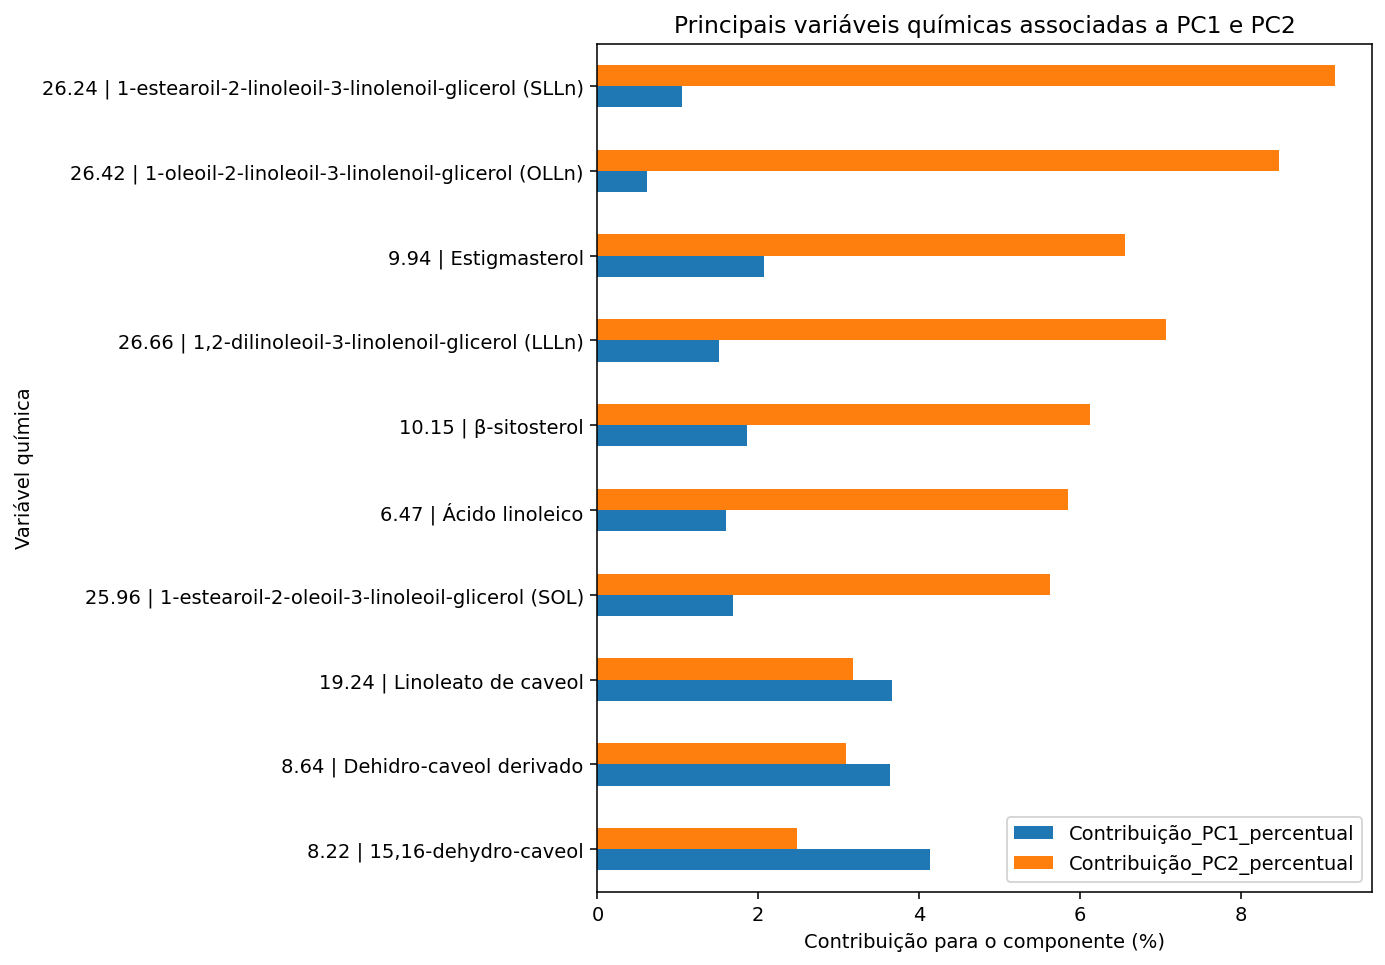

Gráfico salvo em:
/kaggle/working/projeto001_resultados/projeto001_contribuicoes_pca.png


In [16]:
# Selecionar as 10 variáveis com maior contribuição conjunta
top_variaveis = (
    df_interpretacao_pca
    .head(10)
    .sort_values(
        "Contribuição_PC1_PC2_total",
        ascending=True
    )
)

# Criar o gráfico
ax = top_variaveis[
    [
        "Contribuição_PC1_percentual",
        "Contribuição_PC2_percentual"
    ]
].plot(
    kind="barh",
    figsize=(10, 7)
)

ax.set_xlabel("Contribuição para o componente (%)")
ax.set_ylabel("Variável química")
ax.set_title(
    "Principais variáveis químicas associadas a PC1 e PC2"
)

plt.tight_layout()

# Salvar o gráfico
arquivo_contribuicoes = (
    PASTA_PROJETO
    / "projeto001_contribuicoes_pca.png"
)

plt.savefig(
    arquivo_contribuicoes,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(arquivo_contribuicoes)

## 15. Agrupamento hierárquico dos perfis químicos

O agrupamento hierárquico será realizado com os dados químicos padronizados,
utilizando distância euclidiana e o método de Ward.

O dendrograma representa a semelhança multivariada entre os perfis. Perfis unidos
em alturas menores apresentam maior semelhança química; uniões em alturas maiores
indicam maior diferença.

Os agrupamentos são exploratórios e não representam categorias biológicas
definitivas. Nenhum perfil, composto ou outlier será excluído.

,Grupo_1,Grupo_2,Distância,Número_de_perfis
0,0.0,2.0,3.817987,2.0
1,8.0,9.0,4.088983,2.0
2,4.0,5.0,5.658343,2.0
3,1.0,11.0,5.888110,3.0
4,3.0,10.0,6.740155,2.0
5,12.0,14.0,7.031083,5.0
6,6.0,13.0,7.796890,3.0
7,7.0,15.0,8.576777,3.0
8,16.0,18.0,12.760510,8.0
9,17.0,19.0,17.999097,11.0


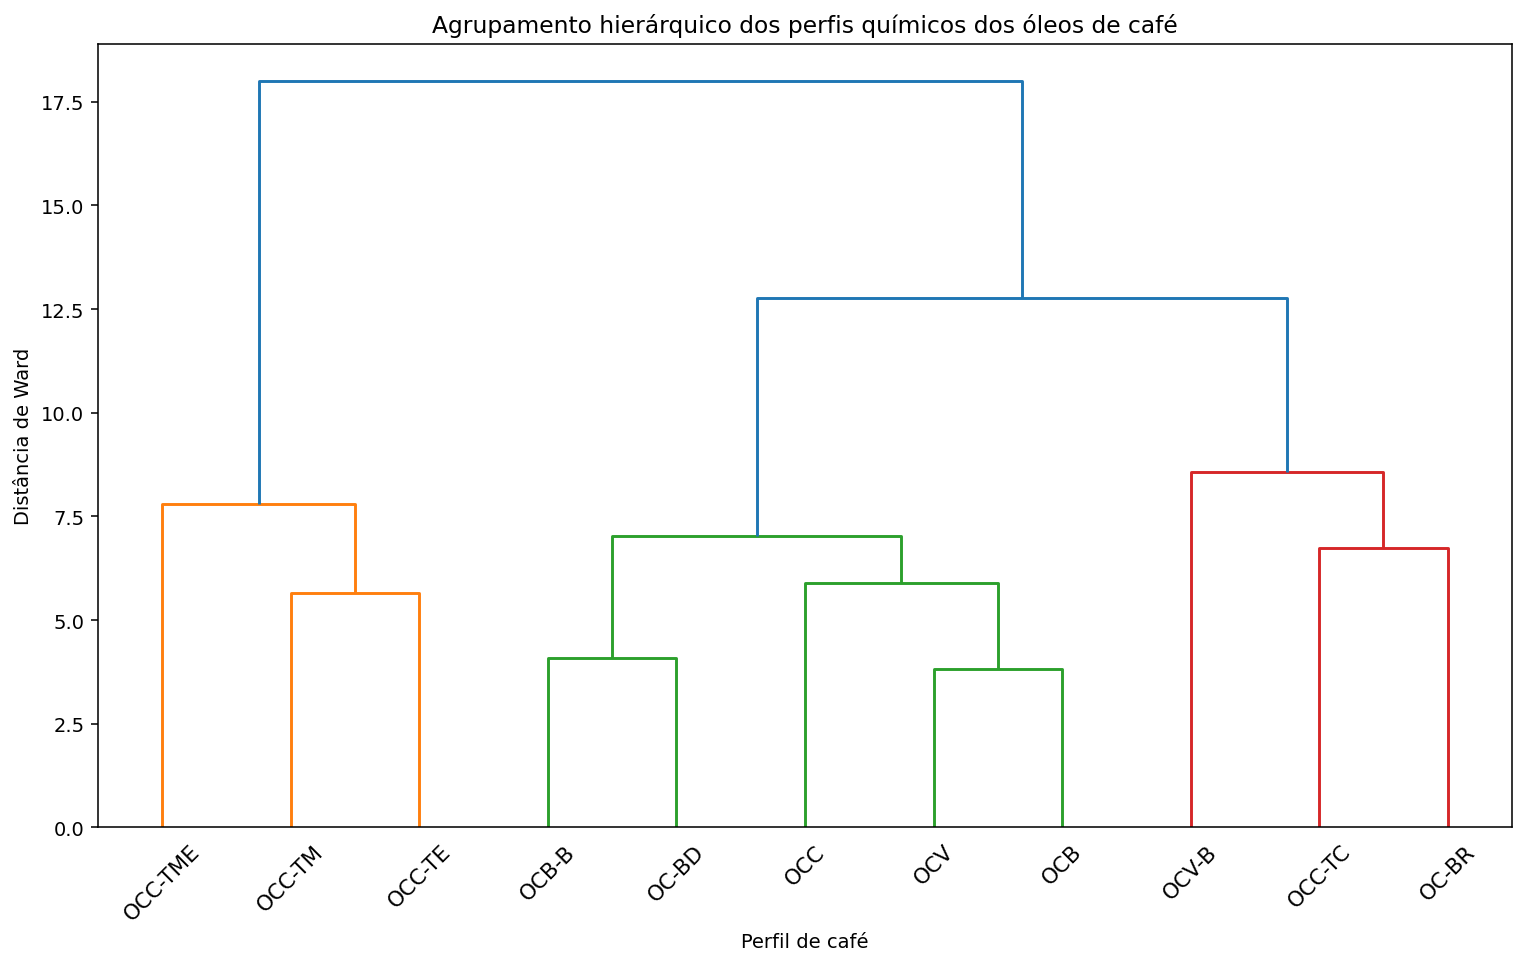

Dendrograma salvo em:
/kaggle/working/projeto001_resultados/projeto001_dendrograma_perfis_quimicos.png


In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd

# Agrupamento hierárquico pelo método de Ward
matriz_ligacao = linkage(
    X_padronizada.values,
    method="ward",
    metric="euclidean"
)

# Tabela da sequência de agrupamentos
df_ligacao = pd.DataFrame(
    matriz_ligacao,
    columns=[
        "Grupo_1",
        "Grupo_2",
        "Distância",
        "Número_de_perfis"
    ]
)

display(df_ligacao)

# Construção do dendrograma
fig, ax = plt.subplots(figsize=(11, 7))

dendrogram(
    matriz_ligacao,
    labels=X_padronizada.index.tolist(),
    leaf_rotation=45,
    leaf_font_size=11,
    ax=ax
)

ax.set_title(
    "Agrupamento hierárquico dos perfis químicos dos óleos de café"
)
ax.set_xlabel("Perfil de café")
ax.set_ylabel("Distância de Ward")

plt.tight_layout()

arquivo_dendrograma = (
    PASTA_PROJETO
    / "projeto001_dendrograma_perfis_quimicos.png"
)

plt.savefig(
    arquivo_dendrograma,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Dendrograma salvo em:")
print(arquivo_dendrograma)

## 16. Heatmap da composição química

O heatmap representa os valores padronizados das variáveis químicas em cada perfil
de café. Valores positivos indicam concentrações acima da média daquela variável;
valores negativos indicam concentrações abaixo da média.

Os perfis e as variáveis químicas serão reorganizados por agrupamento hierárquico,
facilitando a identificação de assinaturas químicas semelhantes.

O gráfico é exploratório e não demonstra causalidade. Nenhum perfil, composto ou
outlier será excluído.

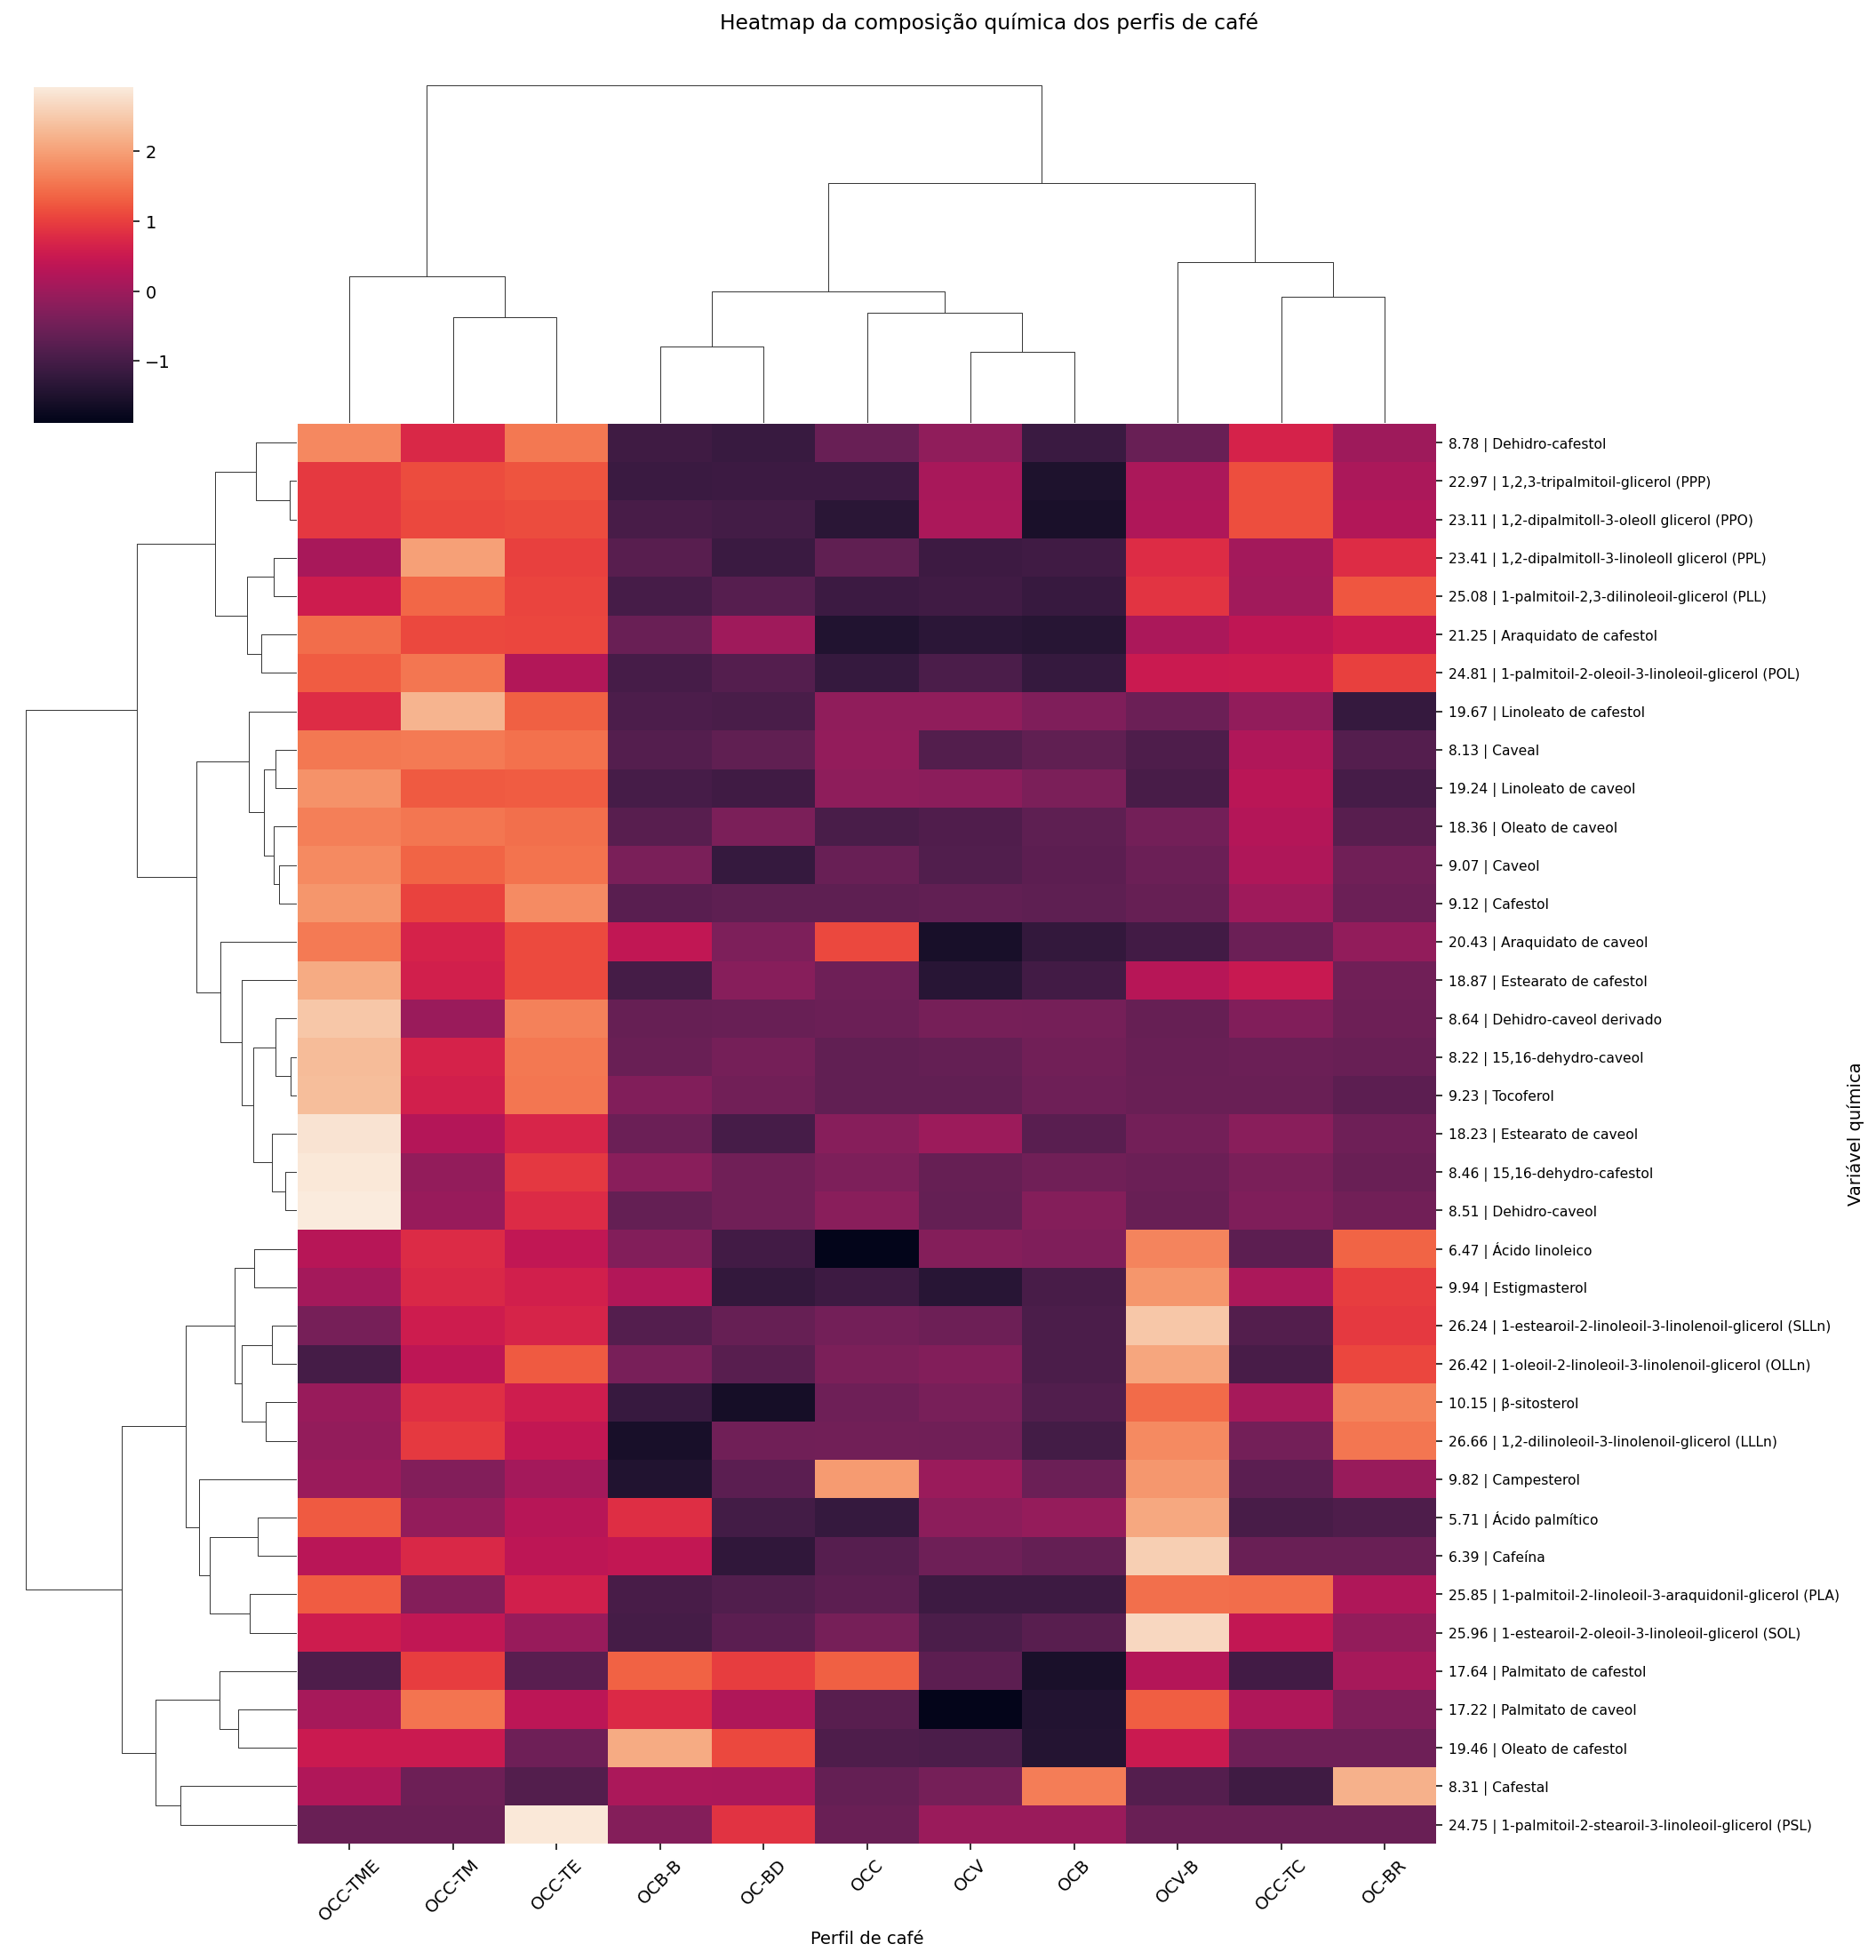

Heatmap salvo em:
/kaggle/working/projeto001_resultados/projeto001_heatmap_composicao_quimica.png


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transpor:
# linhas = variáveis químicas
# colunas = perfis de café
matriz_heatmap = X_padronizada.T.copy()

# Heatmap com agrupamento hierárquico
mapa_calor = sns.clustermap(
    matriz_heatmap,
    method="ward",
    metric="euclidean",
    figsize=(16, 15),
    xticklabels=True,
    yticklabels=True
)

mapa_calor.fig.suptitle(
    "Heatmap da composição química dos perfis de café",
    y=1.02
)

mapa_calor.ax_heatmap.set_xlabel("Perfil de café")
mapa_calor.ax_heatmap.set_ylabel("Variável química")

mapa_calor.ax_heatmap.tick_params(
    axis="x",
    labelrotation=45,
    labelsize=10
)

mapa_calor.ax_heatmap.tick_params(
    axis="y",
    labelsize=8
)

arquivo_heatmap = (
    PASTA_PROJETO
    / "projeto001_heatmap_composicao_quimica.png"
)

mapa_calor.savefig(
    arquivo_heatmap,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Heatmap salvo em:")
print(arquivo_heatmap)

## 17. Biplot da PCA química

O biplot apresenta simultaneamente:

- a posição dos perfis de café nos componentes PC1 e PC2;
- a direção das variáveis químicas mais associadas a esses componentes.

Perfis posicionados na direção de uma seta tendem a apresentar valores relativamente
maiores daquela variável. Setas próximas indicam variáveis com comportamento semelhante;
setas em direções opostas indicam associação inversa no plano PC1–PC2.

Todas as variáveis foram utilizadas na PCA. Apenas as dez maiores contribuições
conjuntas são identificadas graficamente para preservar a legibilidade.

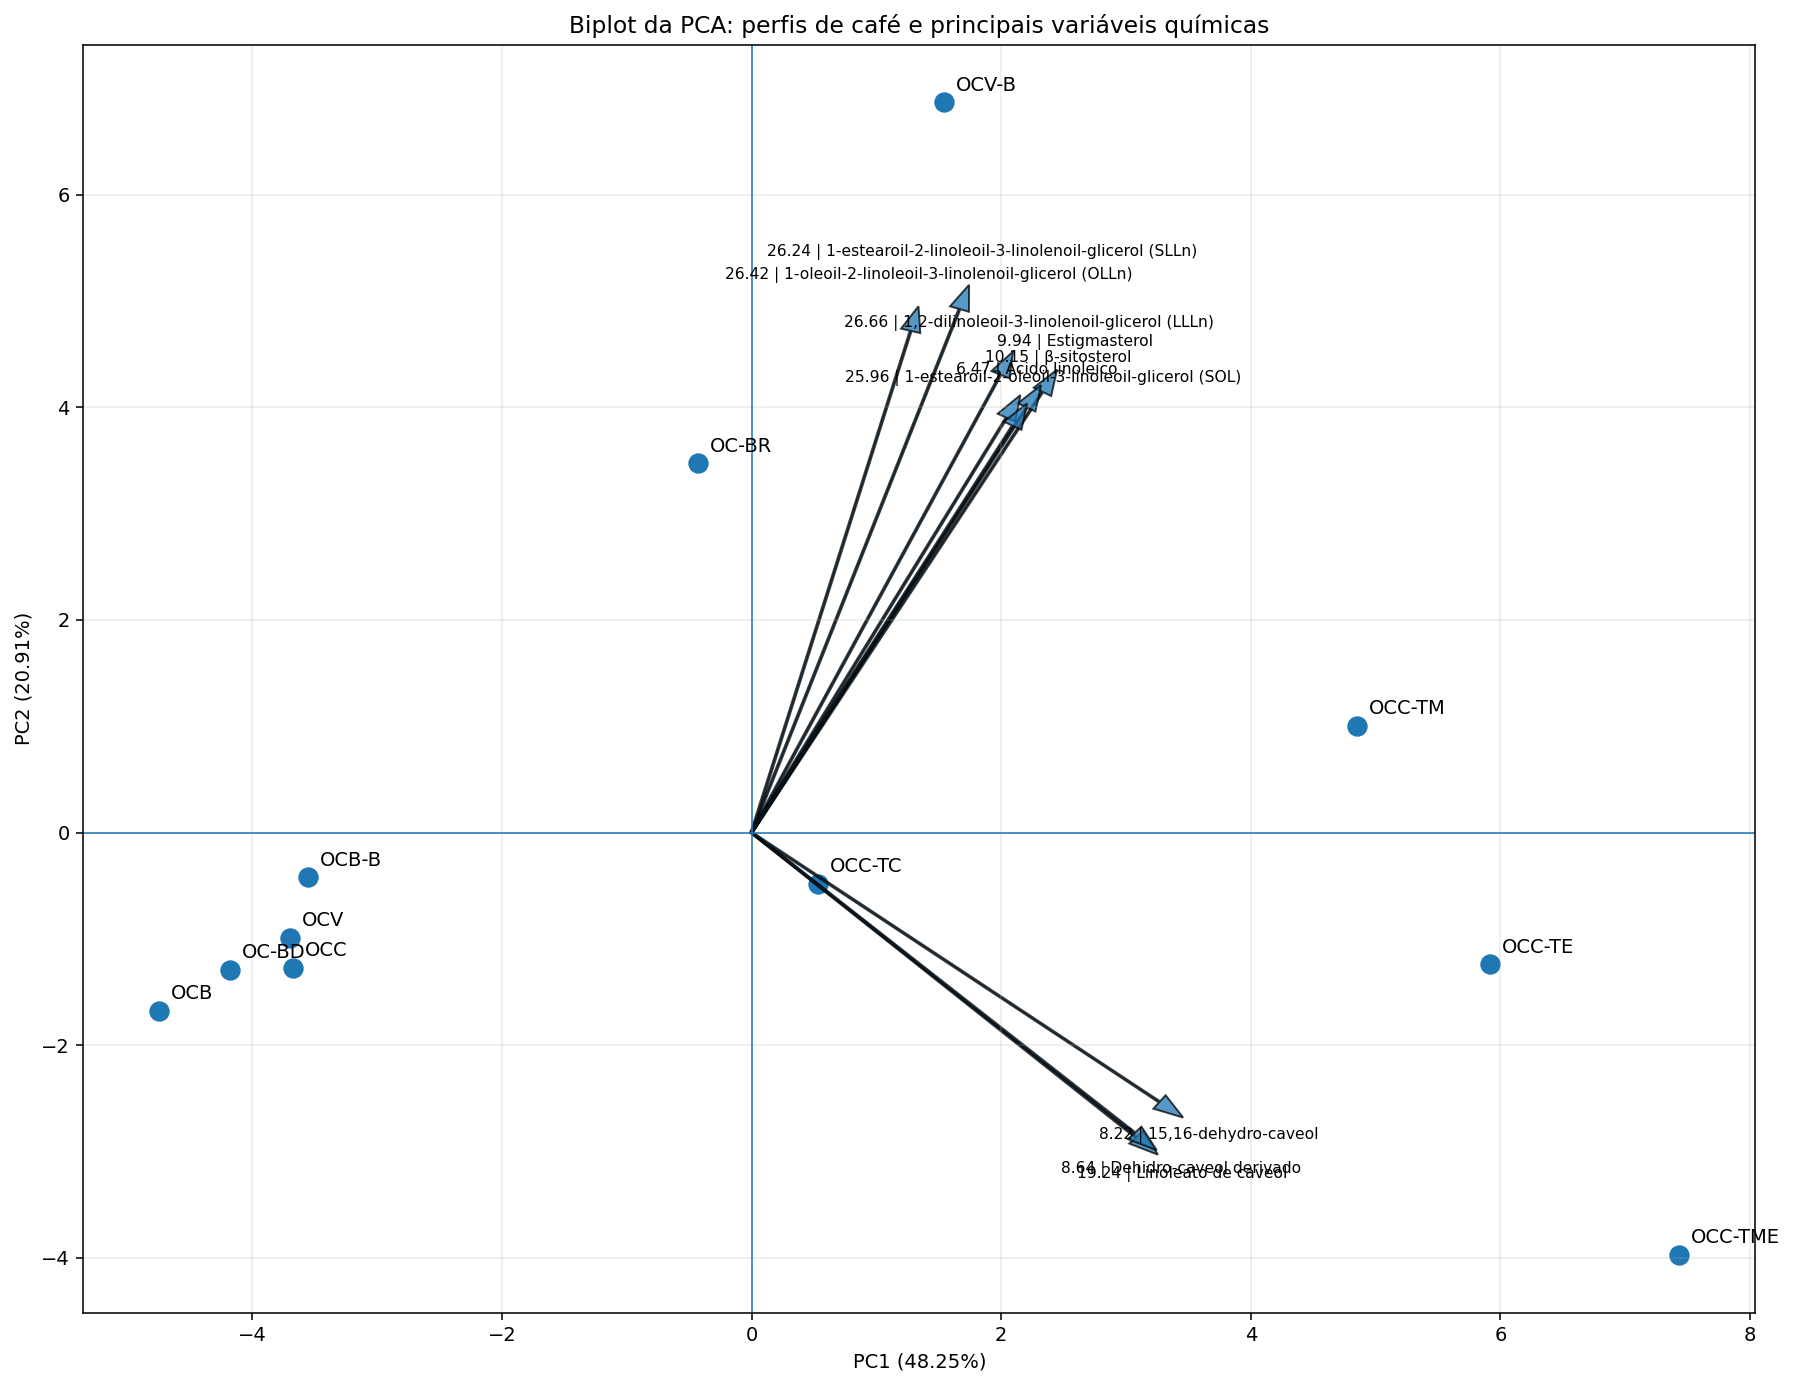

Biplot salvo em:
/kaggle/working/projeto001_resultados/projeto001_biplot_pca_quimica.png


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Selecionar somente para rotulagem as 10 variáveis
# com maior contribuição conjunta em PC1 e PC2
variaveis_biplot = (
    df_interpretacao_pca
    .head(10)
    .index
    .tolist()
)

# Loadings das variáveis selecionadas
loadings_biplot = df_loadings_pca.loc[
    variaveis_biplot,
    ["PC1", "PC2"]
].copy()

# Ajustar o tamanho das setas à escala dos escores
escala_x = (
    np.max(np.abs(df_escores_pca["PC1"]))
    / np.max(np.abs(loadings_biplot["PC1"]))
)

escala_y = (
    np.max(np.abs(df_escores_pca["PC2"]))
    / np.max(np.abs(loadings_biplot["PC2"]))
)

escala_setas = min(escala_x, escala_y) * 0.75

fig, ax = plt.subplots(figsize=(13, 10))

# Perfis de café
ax.scatter(
    df_escores_pca["PC1"],
    df_escores_pca["PC2"],
    s=90,
    label="Perfis de café"
)

for perfil, linha in df_escores_pca.iterrows():
    ax.annotate(
        perfil,
        (linha["PC1"], linha["PC2"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

# Setas das variáveis químicas
for variavel, linha in loadings_biplot.iterrows():
    x_final = linha["PC1"] * escala_setas
    y_final = linha["PC2"] * escala_setas

    ax.arrow(
        0,
        0,
        x_final,
        y_final,
        width=0.015,
        head_width=0.16,
        length_includes_head=True,
        alpha=0.75
    )

    ax.text(
        x_final * 1.06,
        y_final * 1.06,
        variavel,
        fontsize=8,
        ha="center",
        va="center"
    )

variancia_pc1 = df_variancia_pca.loc[
    0, "Variância explicada (%)"
]

variancia_pc2 = df_variancia_pca.loc[
    1, "Variância explicada (%)"
]

ax.set_xlabel(f"PC1 ({variancia_pc1:.2f}%)")
ax.set_ylabel(f"PC2 ({variancia_pc2:.2f}%)")

ax.set_title(
    "Biplot da PCA: perfis de café e principais variáveis químicas"
)

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.grid(alpha=0.25)

plt.tight_layout()

arquivo_biplot = (
    PASTA_PROJETO
    / "projeto001_biplot_pca_quimica.png"
)

plt.savefig(
    arquivo_biplot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Biplot salvo em:")
print(arquivo_biplot)

## 18. Identificação das tabelas de bioatividade

Nesta etapa serão localizadas as abas relacionadas a:

- área e contração das feridas;
- estresse oxidativo;
- atividade antioxidante;
- SOD;
- catalase;
- MDA;
- proteínas carboniladas;
- fotoproteção;
- demais parâmetros biológicos disponíveis.

As tabelas serão apenas inspecionadas. Nenhuma linha, coluna, controle,
replicata ou valor extremo será removido ou modificado.

In [20]:
# Termos utilizados para localizar as abas biológicas
termos_bioatividade = [
    "cicatr",
    "ferida",
    "oxid",
    "sod",
    "catalase",
    "frap",
    "mda",
    "carbon",
    "fotoprote",
    "antioxid"
]

abas_bioatividade = {
    nome: tabela.copy()
    for nome, tabela in abas_brutas.items()
    if any(
        termo in nome.lower()
        for termo in termos_bioatividade
    )
}

if not abas_bioatividade:
    raise RuntimeError(
        "Nenhuma aba de bioatividade foi identificada automaticamente."
    )

resumo_bioatividade = pd.DataFrame(
    [
        {
            "Aba": nome,
            "Linhas": tabela.shape[0],
            "Colunas": tabela.shape[1]
        }
        for nome, tabela in abas_bioatividade.items()
    ]
)

print(
    "Número de abas biológicas identificadas:",
    len(abas_bioatividade)
)

display(resumo_bioatividade)

# Mostrar uma prévia de cada tabela sem alterar sua estrutura
for nome, tabela in abas_bioatividade.items():
    print("\n" + "=" * 90)
    print("ABA:", nome)
    print("Dimensão:", tabela.shape)
    display(tabela.head(12))

Número de abas biológicas identificadas: 9


,Aba,Linhas,Colunas
0,Cicatrização (área da ferida),213,13
1,Cicatr.(contração da ferida),16,6
2,Fotoproteção (ABSORÇÃO),123,12
3,Fotoproteção (FPS),2,12
4,Estresse oxid.(FRAP),15,19
5,Estres. Oxid.(MDA),15,19
6,Estr. Oxid.(Proteinas),15,20
7,Estr. Oxd.(SOD),15,17
8,Estr. Oxid. (Catalase),15,19



ABA: Cicatrização (área da ferida)
Dimensão: (213, 13)


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,Tratamento,Dia zero,Dia 4,Dia 8,NaN,NaN,NaN,DIA ZERO,NaN,Dia 4,NaN,Dia 8,NaN
1,NaN,Área (Média),Área (Média),Área (Média),NaN,NaN,Tratamento,Grupo,Area (mm2),GRUPO,Area (mm2),GRUPO,Area (mm2)
2,NaN,NaN,NaN,NaN,NaN,NaN,GD(+),C1,77.716,C1,54.012,NaN,NaN
3,GD(+),82.019909,60.982333,36.4602,NaN,NaN,GD(+),C2,80.611,NaN,NaN,C2,33.558
4,GS(-),70.579875,99.9,38.42,NaN,NaN,GD(+),C3,91.001,NaN,NaN,C3,59.947
5,OCV,60.35675,57.88975,29.83225,NaN,NaN,GD(+),C4,98.15,C4,78.215,NaN,NaN
6,OCC,98.598947,71.5095,28.094,NaN,NaN,GD(+),C5,51.5,C5,68.504,NaN,NaN
7,OCB,89.933615,69.024,40.840667,NaN,NaN,GD(+),C6,78.873,NaN,NaN,C6,21.012
8,OCV-B,87.689643,76.096857,15.479143,NaN,NaN,GD(+),C7,56.322,C7,51.774,NaN,NaN
9,OCB-B,71.311571,62.8655,29.608167,NaN,NaN,GD(+),C8,73.444,C8,54.956,NaN,NaN



ABA: Cicatr.(contração da ferida)
Dimensão: (16, 6)


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,Teste Proteinas Carboniladas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GD(+),1071.414,1221.0860,417.8524,561.5515,594.9944,NaN,NaN,NaN,NaN,NaN,154.2499,1079.6150,525.8537,938.5778,1605.9750,537.6709,NaN,NaN,NaN
3,GS(-),746.3956,726.7249,1049.6470,794.0494,1238.5020,NaN,NaN,NaN,NaN,NaN,-402.301,629.5319,1381.4960,1178.5410,1021.3270,NaN,NaN,NaN,NaN
4,OCV,769.8042,1179.2710,544.0749,466.6614,2453.9080,2708.5010,1154.5750,907.9114,NaN,NaN,778.6687,3135.0010,520.4194,1926.4350,2323.9600,886.0709,758.1569,502.7901,NaN
5,OCC,-995.713,474.2194,814.2794,858.2945,624.1176,1057.9200,1001.3500,1104.3060,1068.9090,1074.139,847.9037,803.2368,751.1840,500.6659,756.3491,1693.6210,1603.8600,NaN,NaN
6,OCB,692.8427,1083.5790,1572.5080,2488.1770,130.8161,800.9010,984.4487,1316.2550,NaN,NaN,1136.35,608.8075,908.5503,998.4549,921.4997,NaN,NaN,NaN,NaN
7,OCV-B,867.8769,782.5358,644.6991,611.7829,576.0991,572.1437,1322.8640,NaN,NaN,NaN,340.2886,764.7509,890.3890,652.3818,686.6237,903.6763,788.1400,NaN,NaN
8,OCB-B,1280.839,23.0000,1041.2760,1238.4280,1685.2270,1274.0120,1022.5160,803.1389,2051.6280,NaN,698.5824,343.8998,1173.2640,508.6651,3438.3130,NaN,NaN,NaN,NaN
9,OC-BD,-2075.97,2042.4540,954.5587,1766.9890,1098.0270,2328.9690,2344.3270,1387.8440,648.2735,1473.530,878.7092,386.3434,3604.8560,919.8057,1342.2350,546.5062,1057.0640,330.5352,824.5033



ABA: Estr. Oxd.(SOD)
Dimensão: (15, 17)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,Teste SOD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GD(+),0.006018,0.000320,0.010274,0.003220,NaN,NaN,NaN,NaN,0.006346,0.000190,0.003361,0.011991,NaN,NaN,NaN,NaN
3,GS(-),0.009879,0.012513,0.011292,NaN,NaN,NaN,NaN,NaN,0.001338,0.002730,NaN,NaN,NaN,NaN,NaN,NaN
4,OCV,0.014456,0.003470,0.039300,0.011961,0.003271,0.005043,0.002397,0.008598,0.003365,0.002596,0.002286,0.004708,0.001869,0.013354,0.006525,0.005798
5,OCC,0.006464,0.001841,0.015920,0.025119,0.009456,0.003505,0.008497,0.009564,0.009194,0.000557,NaN,NaN,NaN,NaN,NaN,NaN
6,OCB,0.006268,0.014499,0.000798,0.003902,0.005704,0.006428,NaN,NaN,0.000397,0.002184,0.000197,NaN,NaN,NaN,NaN,NaN
7,OCV-B,0.001744,0.005503,0.000473,0.012858,0.018935,0.001334,NaN,NaN,0.004448,0.009365,0.005164,0.012785,0.001763,0.001796,0.008975,NaN
8,OCB-B,0.009238,0.004647,0.006580,0.002577,0.016976,0.003763,0.026928,0.007836,0.003038,0.001138,0.009603,0.026540,0.001875,NaN,NaN,NaN
9,OC-BD,0.004201,0.004543,0.010908,0.003999,0.003767,0.000632,NaN,NaN,0.016498,0.005414,0.016159,0.005983,NaN,NaN,NaN,NaN



ABA: Estr. Oxid. (Catalase)
Dimensão: (15, 19)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,Teste Catalase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GD(+),1574.879,867.8353,373.5383,596.6344,603.7001,NaN,NaN,NaN,NaN,185.876,811.8020,899.3966,1798.3990,1543.7370,726.19530,NaN,NaN,NaN
3,GS(-),771.8181,773.5234,1321.0690,1219.1580,1354.9550,NaN,NaN,NaN,NaN,518.0588,1843.1670,1016.2910,753.9685,NaN,NaN,NaN,NaN,NaN
4,OCV,763.3318,637.5408,678.9941,550.0850,1863.2390,2430.3200,1001.1800,643.2023,NaN,333.2259,969.6522,699.7080,1248.6890,359.8119,1020.33400,628.2607,476.12400,NaN
5,OCC,652.9799,986.6592,689.3099,741.3330,791.6008,981.8531,1045.0770,990.2242,728.0606,642.7517,473.3303,465.1609,623.1430,429.5772,1711.86400,301.0406,NaN,NaN
6,OCB,922.6148,1353.5740,1291.0220,1567.2890,144.1691,300.7711,960.0785,954.3152,NaN,1156.923,567.3301,967.3077,396.6082,460.3179,NaN,NaN,NaN,NaN
7,OCV-B,1151.247,1029.4280,643.5137,596.0813,431.0551,523.4182,1045.4710,NaN,NaN,281.3291,1001.2340,609.4714,735.3319,324.1298,710.16990,1093.2360,NaN,NaN
8,OCB-B,1415.788,1024.5480,883.7930,918.3107,950.8079,1204.0750,1253.6070,1160.5780,2275.0040,553.8329,264.0064,762.3641,357.1962,571.2435,NaN,NaN,NaN,NaN
9,OC-BD,1207.413,986.0465,1386.7300,985.3010,1613.0090,1322.8980,1006.9850,638.4758,1111.5950,288.0833,255.0015,841.3349,396.6293,495.1983,193.44310,614.3066,76.62449,520.9566


## 19. Mapeamento dos perfis nas tabelas biológicas

As tabelas biológicas podem apresentar os tratamentos em diferentes linhas,
colunas e blocos experimentais.

Nesta etapa, o notebook localizará automaticamente cada um dos 11 perfis de café
nas abas de bioatividade, registrando:

- nome da aba;
- linha e coluna da ocorrência;
- código encontrado;
- quantidade de ocorrências por perfil.

Controles experimentais serão preservados e organizados posteriormente.
Nenhum dado será excluído ou modificado.

In [21]:
import pandas as pd
import re

def normalizar_codigo(valor):
    """Padroniza textos para localizar os códigos sem modificar a tabela."""
    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    # Padronizar diferentes tipos de hífen
    texto = texto.replace("–", "-").replace("—", "-")

    # Remover espaços internos
    texto = re.sub(r"\s+", "", texto)

    return texto


# Códigos esperados, já normalizados
mapa_perfis_normalizados = {
    normalizar_codigo(perfil): perfil
    for perfil in PERFIS_ESPERADOS
}

ocorrencias = []

# Examinar todas as células das abas biológicas
for nome_aba, tabela in abas_bioatividade.items():

    for linha in tabela.index:
        for coluna in tabela.columns:

            valor_original = tabela.loc[linha, coluna]
            valor_normalizado = normalizar_codigo(valor_original)

            if valor_normalizado in mapa_perfis_normalizados:

                ocorrencias.append({
                    "Aba": nome_aba,
                    "Linha": linha,
                    "Coluna": coluna,
                    "Valor_original": valor_original,
                    "Perfil_padronizado":
                        mapa_perfis_normalizados[valor_normalizado]
                })


df_ocorrencias_perfis = pd.DataFrame(ocorrencias)

if df_ocorrencias_perfis.empty:
    raise RuntimeError(
        "Nenhum dos 11 perfis foi localizado nas abas biológicas."
    )


print("Ocorrências encontradas:")
display(df_ocorrencias_perfis)


# Resumo por aba e perfil
resumo_perfis_abas = (
    df_ocorrencias_perfis
    .groupby(
        ["Aba", "Perfil_padronizado"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "Número_de_ocorrências"})
)

print("\nResumo das ocorrências por aba:")
display(resumo_perfis_abas)


# Matriz indicando presença ou ausência de cada perfil em cada aba
presenca_perfis = pd.crosstab(
    df_ocorrencias_perfis["Aba"],
    df_ocorrencias_perfis["Perfil_padronizado"]
)

# Garantir que todos os 11 códigos apareçam como colunas,
# mesmo quando algum não estiver presente em determinada aba
presenca_perfis = presenca_perfis.reindex(
    columns=PERFIS_ESPERADOS,
    fill_value=0
)

print("\nPresença dos perfis em cada aba:")
display(presenca_perfis)


# Perfis não encontrados em nenhuma aba biológica
perfis_localizados = set(
    df_ocorrencias_perfis["Perfil_padronizado"]
)

perfis_nao_localizados = [
    perfil
    for perfil in PERFIS_ESPERADOS
    if perfil not in perfis_localizados
]

print("\nPerfis não localizados nas tabelas biológicas:")
print(
    perfis_nao_localizados
    if perfis_nao_localizados
    else "Todos os 11 perfis foram localizados."
)

Ocorrências encontradas:


,Aba,Linha,Coluna,Valor_original,Perfil_padronizado
0,Cicatrização (área da ferida),5,0,OCV,OCV
1,Cicatrização (área da ferida),6,0,OCC,OCC
2,Cicatrização (área da ferida),7,0,OCB,OCB
3,Cicatrização (área da ferida),8,0,OCV-B,OCV-B
4,Cicatrização (área da ferida),9,0,OCB-B,OCB-B
...,...,...,...,...,...
250,Estr. Oxid. (Catalase),10,0,OC-BR,OC-BR
251,Estr. Oxid. (Catalase),11,0,OCC-TC,OCC-TC
252,Estr. Oxid. (Catalase),12,0,OCC-TM,OCC-TM
253,Estr. Oxid. (Catalase),13,0,OCC-TE,OCC-TE



Resumo das ocorrências por aba:


,Aba,Perfil_padronizado,Número_de_ocorrências
0,Cicatr.(contração da ferida),OC-BD,1
1,Cicatr.(contração da ferida),OC-BR,1
2,Cicatr.(contração da ferida),OCB,1
3,Cicatr.(contração da ferida),OCB-B,1
4,Cicatr.(contração da ferida),OCC,1
...,...,...,...
92,Fotoproteção (FPS),OCC-TE,1
93,Fotoproteção (FPS),OCC-TM,1
94,Fotoproteção (FPS),OCC-TME,1
95,Fotoproteção (FPS),OCV,1



Presença dos perfis em cada aba:


Perfil_padronizado,OCV,OCC,OCB,OCC-TC,OCC-TM,OCC-TE,OCC-TME,OCV-B,OCB-B,OC-BD,OC-BR
Aba,,,,,,,,,,,
Cicatr.(contração da ferida),1,1,1,1,1,1,1,1,1,1,1
Cicatrização (área da ferida),17,20,14,13,13,15,15,15,15,19,13
Estr. Oxd.(SOD),1,1,1,1,1,1,1,1,1,1,1
Estr. Oxid. (Catalase),1,1,1,1,1,1,1,1,1,1,1
Estr. Oxid.(Proteinas),1,1,1,1,1,1,1,1,1,1,1
Estres. Oxid.(MDA),1,1,1,1,1,1,1,1,1,1,1
Estresse oxid.(FRAP),1,1,1,1,1,1,1,1,1,1,1
Fotoproteção (ABSORÇÃO),1,1,1,1,1,1,1,1,0,1,1
Fotoproteção (FPS),1,1,1,1,1,1,1,1,0,1,1



Perfis não localizados nas tabelas biológicas:
Todos os 11 perfis foram localizados.


## 20. Organização das áreas médias das feridas

A tabela-resumo de cicatrização será lida exclusivamente do arquivo
`Tabela analise multivariada_FJMN marcos_outliers3.xlsx`.

Serão utilizadas somente as colunas A a D da aba de cicatrização:

- tratamento;
- área média no dia zero;
- área média no dia 4;
- área média no dia 8.

Os dois controles e os 11 perfis de café serão preservados. Nenhum valor será
excluído, substituído ou recalculado nesta etapa.

In [22]:
# ETAPA 20 — Organização correta das áreas médias

# ARQUIVO_EXCEL foi localizado em /kaggle/input na Etapa 3.
if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada. Execute primeiro a Etapa 3."
    )

NOME_ABA_CICATRIZACAO = "Cicatrização (área da ferida)"

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{ARQUIVO_EXCEL}"
    )

# Ler somente as colunas A:D, sem interpretar cabeçalhos
area_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_CICATRIZACAO,
    header=None,
    usecols="A:D",
    engine="openpyxl"
)

# Os dados estão nas linhas 4 a 16 do Excel
df_area_ferida = area_bruta.iloc[3:16].copy()

df_area_ferida.columns = [
    "Tratamento",
    "Area_D0",
    "Area_D4",
    "Area_D8"
]

# Limpar os nomes dos tratamentos
df_area_ferida["Tratamento"] = (
    df_area_ferida["Tratamento"]
    .astype("string")
    .str.strip()
)

# Converter somente as áreas para valores numéricos
colunas_area = [
    "Area_D0",
    "Area_D4",
    "Area_D8"
]

for coluna in colunas_area:
    df_area_ferida[coluna] = pd.to_numeric(
        df_area_ferida[coluna]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False),
        errors="raise"
    )

df_area_ferida = df_area_ferida.reset_index(drop=True)

# Tratamentos que devem estar presentes
tratamentos_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

tratamentos_encontrados = (
    df_area_ferida["Tratamento"].tolist()
)

if tratamentos_encontrados != tratamentos_esperados:
    raise ValueError(
        "A ordem ou os nomes dos tratamentos não correspondem "
        "à tabela esperada.\n"
        f"Encontrados: {tratamentos_encontrados}"
    )

if df_area_ferida[colunas_area].isna().any().any():
    raise ValueError(
        "Foram encontrados valores ausentes nas áreas médias."
    )

print("Arquivo utilizado:")
print(ARQUIVO_EXCEL.name)

print("\nAba utilizada:")
print(NOME_ABA_CICATRIZACAO)

print("\nNúmero de tratamentos:")
print(len(df_area_ferida))

display(df_area_ferida.round(4))

# Salvar a tabela organizada
arquivo_area = (
    PASTA_PROJETO
    / "projeto001_area_ferida_dias_0_4_8.csv"
)

df_area_ferida.to_csv(
    arquivo_area,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nTabela de áreas salva em:")
print(arquivo_area)

Arquivo utilizado:
Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba utilizada:
Cicatrização (área da ferida)

Número de tratamentos:
13


,Tratamento,Area_D0,Area_D4,Area_D8
0,GD(+),82.0199,60.9823,36.4602
1,GS(-),70.5799,99.9000,38.4200
2,OCV,60.3568,57.8898,29.8322
3,OCC,98.5989,71.5095,28.0940
4,OCB,89.9336,69.0240,40.8407
5,OCV-B,87.6896,76.0969,15.4791
6,OCB-B,71.3116,62.8655,29.6082
7,OC-BD,77.9362,59.5340,33.2471
8,OC-BR,89.5433,63.3200,10.4963
9,OCC-TC,87.5363,54.6084,32.2786



Tabela de áreas salva em:
/kaggle/working/projeto001_resultados/projeto001_area_ferida_dias_0_4_8.csv


## 21. Cálculo da contração percentual das feridas

A contração será calculada separadamente para os dias 4 e 8 pela fórmula:

**Contração (%) = [(área no dia zero − área no dia avaliado) / área no dia zero] × 100**

Valores positivos indicam redução da área da ferida. Valores negativos indicam
aumento da área em relação ao dia zero.

Os cálculos utilizarão exclusivamente as áreas médias organizadas na Etapa 20.
Nenhum valor será excluído, limitado ou substituído.

In [23]:
# ETAPA 21 — Cálculo correto da contração percentual

colunas_necessarias = [
    "Tratamento",
    "Area_D0",
    "Area_D4",
    "Area_D8"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_area_ferida.columns
]

if colunas_ausentes:
    raise ValueError(
        f"Colunas ausentes em df_area_ferida: {colunas_ausentes}"
    )

# Criar uma cópia para não modificar a tabela de áreas
df_contracao_ferida = df_area_ferida.copy()

# Verificações de segurança
if df_contracao_ferida[
    ["Area_D0", "Area_D4", "Area_D8"]
].isna().any().any():
    raise ValueError(
        "Existem valores ausentes nas áreas das feridas."
    )

if (
    df_contracao_ferida["Area_D0"] <= 0
).any():
    raise ValueError(
        "Existem áreas iniciais iguais ou inferiores a zero."
    )

# Calcular a contração percentual no dia 4
df_contracao_ferida["Contracao_D4"] = (
    (
        df_contracao_ferida["Area_D0"]
        - df_contracao_ferida["Area_D4"]
    )
    / df_contracao_ferida["Area_D0"]
) * 100

# Calcular a contração percentual no dia 8
df_contracao_ferida["Contracao_D8"] = (
    (
        df_contracao_ferida["Area_D0"]
        - df_contracao_ferida["Area_D8"]
    )
    / df_contracao_ferida["Area_D0"]
) * 100

# Organizar a tabela final
df_contracao_ferida = df_contracao_ferida[
    [
        "Tratamento",
        "Area_D0",
        "Area_D4",
        "Area_D8",
        "Contracao_D4",
        "Contracao_D8"
    ]
]

print("Contração percentual calculada:")
display(df_contracao_ferida.round(4))

# Mostrar tratamentos com aumento da área
tratamentos_contracao_negativa = df_contracao_ferida.loc[
    (
        df_contracao_ferida["Contracao_D4"] < 0
    )
    | (
        df_contracao_ferida["Contracao_D8"] < 0
    ),
    [
        "Tratamento",
        "Contracao_D4",
        "Contracao_D8"
    ]
]

print("\nTratamentos com contração negativa em algum dia:")
display(tratamentos_contracao_negativa.round(4))

# Salvar mantendo a precisão completa
arquivo_contracao = (
    PASTA_PROJETO
    / "projeto001_contracao_ferida_dias_4_8.csv"
)

df_contracao_ferida.to_csv(
    arquivo_contracao,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nTabela de contração salva em:")
print(arquivo_contracao)

Contração percentual calculada:


,Tratamento,Area_D0,Area_D4,Area_D8,Contracao_D4,Contracao_D8
0,GD(+),82.0199,60.9823,36.4602,25.6494,55.5471
1,GS(-),70.5799,99.9000,38.4200,-41.5418,45.5652
2,OCV,60.3568,57.8898,29.8322,4.0874,50.5735
3,OCC,98.5989,71.5095,28.0940,27.4744,71.5068
4,OCB,89.9336,69.0240,40.8407,23.2501,54.5880
5,OCV-B,87.6896,76.0969,15.4791,13.2202,82.3478
6,OCB-B,71.3116,62.8655,29.6082,11.8439,58.4806
7,OC-BD,77.9362,59.5340,33.2471,23.6118,57.3406
8,OC-BR,89.5433,63.3200,10.4963,29.2856,88.2779
9,OCC-TC,87.5363,54.6084,32.2786,37.6163,63.1255



Tratamentos com contração negativa em algum dia:


,Tratamento,Contracao_D4,Contracao_D8
1,GS(-),-41.5418,45.5652



Tabela de contração salva em:
/kaggle/working/projeto001_resultados/projeto001_contracao_ferida_dias_4_8.csv


## 22. Visualização e ranking da contração das feridas

Será construído um gráfico de barras comparando a contração percentual das
feridas nos dias 4 e 8 para todos os tratamentos.

Valores positivos indicam redução da área da ferida em relação ao dia zero.
Valores negativos indicam aumento da área da ferida.

Também será apresentado um ranking exploratório dos tratamentos de acordo com
a contração média observada no dia 8.

Os resultados apresentados são descritivos. Como a tabela contém médias, este
gráfico não demonstra diferença estatisticamente significativa entre os grupos.

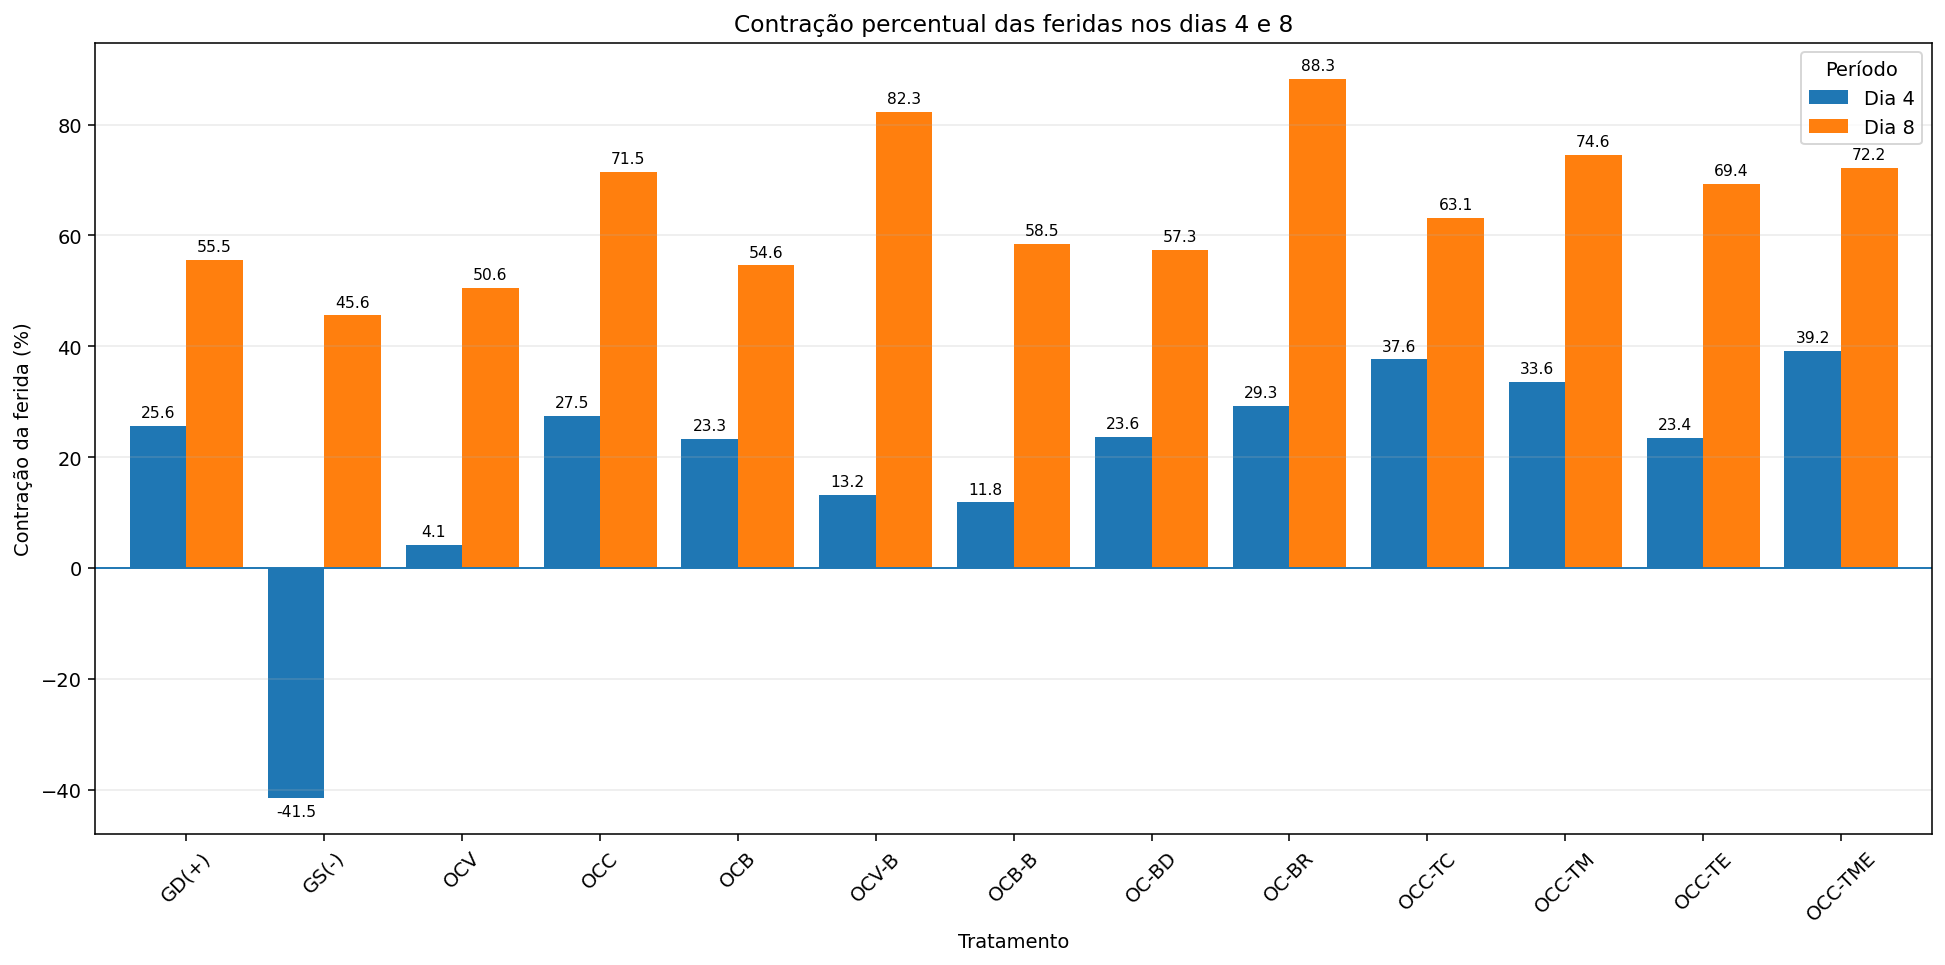

Gráfico salvo em:
/kaggle/working/projeto001_resultados/projeto001_contracao_feridas_dias_4_8.png

Ranking exploratório da contração no dia 8:


,Posicao,Tratamento,Contracao_D8
0,1,OC-BR,88.28
1,2,OCV-B,82.35
2,3,OCC-TM,74.56
3,4,OCC-TME,72.23
4,5,OCC,71.51
5,6,OCC-TE,69.35
6,7,OCC-TC,63.13
7,8,OCB-B,58.48
8,9,OC-BD,57.34
9,10,GD(+),55.55



Ranking salvo em:
/kaggle/working/projeto001_resultados/projeto001_ranking_contracao_dia_8.csv


In [24]:
# ETAPA 22 — Gráfico e ranking da contração das feridas

import matplotlib.pyplot as plt
import pandas as pd

# Verificar se a tabela necessária existe
if "df_contracao_ferida" not in globals():
    raise RuntimeError(
        "A tabela df_contracao_ferida não foi encontrada. "
        "Execute primeiro a Etapa 21."
    )

# Verificar as colunas necessárias
colunas_necessarias = [
    "Tratamento",
    "Contracao_D4",
    "Contracao_D8"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_contracao_ferida.columns
]

if colunas_ausentes:
    raise ValueError(
        f"Colunas ausentes em df_contracao_ferida: "
        f"{colunas_ausentes}"
    )

# Criar tabela específica para o gráfico
# Os nomes serão usados automaticamente na legenda
df_contracao_grafico = (
    df_contracao_ferida[
        [
            "Tratamento",
            "Contracao_D4",
            "Contracao_D8"
        ]
    ]
    .copy()
    .rename(
        columns={
            "Contracao_D4": "Dia 4",
            "Contracao_D8": "Dia 8"
        }
    )
    .set_index("Tratamento")
)

# Construir o gráfico
fig, ax = plt.subplots(
    figsize=(14, 7)
)

df_contracao_grafico.plot(
    kind="bar",
    width=0.82,
    ax=ax
)

# Linha de referência em zero
# Não recebe rótulo para não aparecer na legenda
ax.axhline(
    y=0,
    linewidth=1
)

# Títulos e rótulos
ax.set_title(
    "Contração percentual das feridas nos dias 4 e 8"
)

ax.set_xlabel("Tratamento")
ax.set_ylabel("Contração da ferida (%)")

# Ajustar os nomes dos tratamentos
ax.tick_params(
    axis="x",
    rotation=45
)

# Legenda automática com Dia 4 e Dia 8
ax.legend(
    title="Período"
)

# Grade horizontal
ax.grid(
    axis="y",
    alpha=0.25
)

# Mostrar os valores sobre cada barra
for conjunto_barras in ax.containers:
    ax.bar_label(
        conjunto_barras,
        fmt="%.1f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()

# Salvar o gráfico
arquivo_grafico_contracao = (
    PASTA_PROJETO
    / "projeto001_contracao_feridas_dias_4_8.png"
)

plt.savefig(
    arquivo_grafico_contracao,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico salvo em:")
print(arquivo_grafico_contracao)


# ---------------------------------------------------------
# Ranking exploratório da contração no dia 8
# ---------------------------------------------------------

ranking_contracao_d8 = (
    df_contracao_ferida[
        [
            "Tratamento",
            "Contracao_D8"
        ]
    ]
    .copy()
    .sort_values(
        by="Contracao_D8",
        ascending=False
    )
    .reset_index(drop=True)
)

# Inserir a posição no ranking
ranking_contracao_d8.insert(
    0,
    "Posicao",
    range(
        1,
        len(ranking_contracao_d8) + 1
    )
)

print("\nRanking exploratório da contração no dia 8:")

display(
    ranking_contracao_d8.round(
        {
            "Contracao_D8": 2
        }
    )
)

# Salvar o ranking
arquivo_ranking_contracao = (
    PASTA_PROJETO
    / "projeto001_ranking_contracao_dia_8.csv"
)

ranking_contracao_d8.to_csv(
    arquivo_ranking_contracao,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nRanking salvo em:")
print(arquivo_ranking_contracao)

## 23. Inspeção dos dados individuais de cicatrização

A análise estatística não deve utilizar apenas as médias apresentadas nas
colunas A a D. Nesta etapa serão examinados os valores individuais dos animais,
armazenados nas colunas G a M da aba de cicatrização.

Serão conferidos:

- tratamento;
- identificação do animal ou grupo;
- área da ferida no dia zero;
- área da ferida no dia 4;
- área da ferida no dia 8;
- linhas de média, desvio-padrão e outros elementos auxiliares.

Nenhuma linha ou valor será excluído, transformado ou salvo nesta etapa.

In [25]:
# ETAPA 23 — Inspeção dos dados individuais de cicatrização

import pandas as pd

# Usar exclusivamente o arquivo com outliers localizado na Etapa 3
if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada. Execute primeiro a Etapa 3."
    )

NOME_ABA_CICATRIZACAO = "Cicatrização (área da ferida)"

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{ARQUIVO_EXCEL}"
    )

# Ler exclusivamente o bloco de dados individuais
# G = tratamento
# H:I = dia zero
# J:K = dia 4
# L:M = dia 8
dados_individuais_brutos = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_CICATRIZACAO,
    header=None,
    usecols="G:M",
    engine="openpyxl"
)

# Acrescentar o número real da linha no Excel
dados_individuais_brutos.insert(
    0,
    "Linha_Excel",
    dados_individuais_brutos.index + 1
)

# Nomear as colunas apenas para facilitar a inspeção
dados_individuais_brutos.columns = [
    "Linha_Excel",
    "G_Tratamento",
    "H_Grupo_D0",
    "I_Area_D0",
    "J_Grupo_D4",
    "K_Area_D4",
    "L_Grupo_D8",
    "M_Area_D8"
]

# Manter somente as linhas que possuem algum conteúdo nas colunas G:M
colunas_dados = [
    "G_Tratamento",
    "H_Grupo_D0",
    "I_Area_D0",
    "J_Grupo_D4",
    "K_Area_D4",
    "L_Grupo_D8",
    "M_Area_D8"
]

mascara_linha_com_conteudo = (
    dados_individuais_brutos[
        colunas_dados
    ]
    .notna()
    .any(axis=1)
)

df_inspecao_individual = (
    dados_individuais_brutos
    .loc[mascara_linha_com_conteudo]
    .reset_index(drop=True)
)

print("Arquivo utilizado:")
print(ARQUIVO_EXCEL.name)

print("\nAba utilizada:")
print(NOME_ABA_CICATRIZACAO)

print("\nNúmero de linhas com algum conteúdo:")
print(len(df_inspecao_individual))

print("\nIntervalo das linhas encontradas no Excel:")
print(
    df_inspecao_individual["Linha_Excel"].min(),
    "até",
    df_inspecao_individual["Linha_Excel"].max()
)

# Exibir todas as linhas para conferência
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 200
):
    display(df_inspecao_individual)

Arquivo utilizado:
Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba utilizada:
Cicatrização (área da ferida)

Número de linhas com algum conteúdo:
213

Intervalo das linhas encontradas no Excel:
1 até 213


,Linha_Excel,G_Tratamento,H_Grupo_D0,I_Area_D0,J_Grupo_D4,K_Area_D4,L_Grupo_D8,M_Area_D8
0,1,NaN,DIA ZERO,NaN,Dia 4,NaN,Dia 8,NaN
1,2,Tratamento,Grupo,Area (mm2),GRUPO,Area (mm2),GRUPO,Area (mm2)
2,3,GD(+),C1,77.716,C1,54.012,NaN,NaN
3,4,GD(+),C2,80.611,NaN,NaN,C2,33.558
4,5,GD(+),C3,91.001,NaN,NaN,C3,59.947
5,6,GD(+),C4,98.15,C4,78.215,NaN,NaN
6,7,GD(+),C5,51.5,C5,68.504,NaN,NaN
7,8,GD(+),C6,78.873,NaN,NaN,C6,21.012
8,9,GD(+),C7,56.322,C7,51.774,NaN,NaN
9,10,GD(+),C8,73.444,C8,54.956,NaN,NaN


## 24. Organização segura dos dados individuais de cicatrização

Os dados individuais serão organizados utilizando cada linha do Excel como uma
unidade experimental.

A identificação registrada no dia zero será mantida como identificação principal
do animal. Os rótulos existentes nas colunas dos dias 4 e 8 serão preservados para
auditoria, mas não serão utilizados como chave única, pois podem conter identificações
repetidas ou nomes de arquivos de imagem.

Serão produzidas duas tabelas:

- tabela ampla: uma linha para cada unidade experimental;
- tabela longa: uma linha para cada área efetivamente registrada em cada dia.

Nenhum animal, valor ausente, identificação repetida ou outlier será removido.

In [26]:
# ETAPA 24 — Organização segura dos dados individuais
# A linha do Excel será utilizada como referência da unidade experimental.

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Verificar se a Etapa 23 foi executada
# ---------------------------------------------------------

if "df_inspecao_individual" not in globals():
    raise RuntimeError(
        "A tabela df_inspecao_individual não foi encontrada. "
        "Execute primeiro a Etapa 23."
    )


# ---------------------------------------------------------
# 2. Definir tratamentos e colunas necessárias
# ---------------------------------------------------------

tratamentos_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

colunas_necessarias = [
    "Linha_Excel",
    "G_Tratamento",
    "H_Grupo_D0",
    "I_Area_D0",
    "J_Grupo_D4",
    "K_Area_D4",
    "L_Grupo_D8",
    "M_Area_D8"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_inspecao_individual.columns
]

if colunas_ausentes:
    raise ValueError(
        "Faltam colunas necessárias na tabela da Etapa 23: "
        f"{colunas_ausentes}"
    )


# ---------------------------------------------------------
# 3. Copiar e renomear as colunas
# ---------------------------------------------------------

df_cicatrizacao_individual = (
    df_inspecao_individual[
        colunas_necessarias
    ]
    .copy()
    .rename(
        columns={
            "G_Tratamento": "Tratamento",
            "H_Grupo_D0": "Animal_D0",
            "I_Area_D0": "Area_D0",
            "J_Grupo_D4": "Rotulo_D4_original",
            "K_Area_D4": "Area_D4",
            "L_Grupo_D8": "Rotulo_D8_original",
            "M_Area_D8": "Area_D8"
        }
    )
)


# ---------------------------------------------------------
# 4. Limpar somente os campos textuais
# ---------------------------------------------------------

colunas_texto = [
    "Tratamento",
    "Animal_D0",
    "Rotulo_D4_original",
    "Rotulo_D8_original"
]

for coluna in colunas_texto:

    df_cicatrizacao_individual[coluna] = (
        df_cicatrizacao_individual[coluna]
        .astype("string")
        .str.strip()
        .replace(
            {
                "": pd.NA,
                "nan": pd.NA,
                "NaN": pd.NA,
                "None": pd.NA
            }
        )
    )


# ---------------------------------------------------------
# 5. Manter somente as linhas dos 13 tratamentos
# ---------------------------------------------------------

df_cicatrizacao_individual = (
    df_cicatrizacao_individual.loc[
        df_cicatrizacao_individual[
            "Tratamento"
        ].isin(tratamentos_esperados)
    ]
    .copy()
)


# ---------------------------------------------------------
# 6. Converter somente as áreas para valores numéricos
# ---------------------------------------------------------

colunas_area = [
    "Area_D0",
    "Area_D4",
    "Area_D8"
]

for coluna in colunas_area:

    df_cicatrizacao_individual[coluna] = pd.to_numeric(
        df_cicatrizacao_individual[coluna],
        errors="coerce"
    )


# ---------------------------------------------------------
# 7. Verificar a identificação e a área inicial
# ---------------------------------------------------------

problemas_d0 = (
    df_cicatrizacao_individual["Animal_D0"].isna()
    ^ df_cicatrizacao_individual["Area_D0"].isna()
)

if problemas_d0.any():

    print(
        "Linhas com identificação ou área do dia zero incompleta:"
    )

    display(
        df_cicatrizacao_individual.loc[
            problemas_d0
        ]
    )

    raise ValueError(
        "Existem linhas de animais com identificação "
        "ou área inicial incompleta."
    )


# Remover apenas linhas auxiliares que não representam animais
df_cicatrizacao_individual = (
    df_cicatrizacao_individual.loc[
        df_cicatrizacao_individual[
            "Animal_D0"
        ].notna()
        & df_cicatrizacao_individual[
            "Area_D0"
        ].notna()
    ]
    .copy()
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 8. Auditar rótulos e áreas dos dias 4 e 8
# ---------------------------------------------------------
# Os rótulos posteriores serão preservados, mas não utilizados
# como chave, pois podem conter nomes de imagens ou repetições.

for dia, coluna_rotulo, coluna_area in [
    (
        4,
        "Rotulo_D4_original",
        "Area_D4"
    ),
    (
        8,
        "Rotulo_D8_original",
        "Area_D8"
    )
]:

    area_sem_rotulo = (
        df_cicatrizacao_individual[
            coluna_area
        ].notna()
        & df_cicatrizacao_individual[
            coluna_rotulo
        ].isna()
    )

    rotulo_sem_area = (
        df_cicatrizacao_individual[
            coluna_rotulo
        ].notna()
        & df_cicatrizacao_individual[
            coluna_area
        ].isna()
    )

    if area_sem_rotulo.any() or rotulo_sem_area.any():

        print(
            f"Aviso: existem linhas com rótulo ou área "
            f"incompleta no dia {dia}."
        )

        display(
            df_cicatrizacao_individual.loc[
                area_sem_rotulo | rotulo_sem_area,
                [
                    "Linha_Excel",
                    "Tratamento",
                    "Animal_D0",
                    coluna_rotulo,
                    coluna_area
                ]
            ]
        )


# ---------------------------------------------------------
# 9. Verificar áreas inválidas
# ---------------------------------------------------------

areas_invalidas = (
    df_cicatrizacao_individual[
        colunas_area
    ]
    .le(0)
    .fillna(False)
    .any(axis=1)
)

if areas_invalidas.any():

    print(
        "Foram encontradas áreas iguais ou inferiores a zero:"
    )

    display(
        df_cicatrizacao_individual.loc[
            areas_invalidas,
            [
                "Linha_Excel",
                "Tratamento",
                "Animal_D0",
                "Area_D0",
                "Area_D4",
                "Area_D8"
            ]
        ]
    )

    raise ValueError(
        "Existem áreas iguais ou inferiores a zero."
    )


# ---------------------------------------------------------
# 10. Criar uma identificação realmente única
# ---------------------------------------------------------
# A identificação combina tratamento e linha original do Excel.

df_cicatrizacao_individual[
    "Unidade_ID"
] = (
    df_cicatrizacao_individual[
        "Tratamento"
    ].astype(str)
    + "|L"
    + df_cicatrizacao_individual[
        "Linha_Excel"
    ].astype(int).astype(str)
)


# ---------------------------------------------------------
# 11. Verificar se alguma linha foi lida duas vezes
# ---------------------------------------------------------

duplicidade_de_linha = (
    df_cicatrizacao_individual.duplicated(
        subset=[
            "Tratamento",
            "Linha_Excel"
        ],
        keep=False
    )
)

if duplicidade_de_linha.any():

    display(
        df_cicatrizacao_individual.loc[
            duplicidade_de_linha
        ].sort_values(
            [
                "Tratamento",
                "Linha_Excel"
            ]
        )
    )

    raise ValueError(
        "A mesma linha do Excel foi lida mais de uma vez."
    )


# ---------------------------------------------------------
# 12. Auditar identificações de animais repetidas
# ---------------------------------------------------------
# Identificações repetidas não serão excluídas.
# A Linha_Excel diferencia as unidades experimentais.

rotulos_animais_repetidos = (
    df_cicatrizacao_individual.duplicated(
        subset=[
            "Tratamento",
            "Animal_D0"
        ],
        keep=False
    )
)

if rotulos_animais_repetidos.any():

    print(
        "ATENÇÃO: existem identificações de animais "
        "repetidas dentro de um mesmo tratamento."
    )

    print(
        "Essas linhas foram preservadas e serão "
        "diferenciadas pela Linha_Excel."
    )

    display(
        df_cicatrizacao_individual.loc[
            rotulos_animais_repetidos,
            [
                "Linha_Excel",
                "Tratamento",
                "Animal_D0",
                "Area_D0",
                "Area_D4",
                "Area_D8"
            ]
        ].sort_values(
            [
                "Tratamento",
                "Animal_D0",
                "Linha_Excel"
            ]
        )
    )


# ---------------------------------------------------------
# 13. Organizar a tabela ampla
# ---------------------------------------------------------

ordem_colunas_ampla = [
    "Unidade_ID",
    "Linha_Excel",
    "Tratamento",
    "Animal_D0",
    "Area_D0",
    "Rotulo_D4_original",
    "Area_D4",
    "Rotulo_D8_original",
    "Area_D8"
]

df_cicatrizacao_individual = (
    df_cicatrizacao_individual[
        ordem_colunas_ampla
    ]
    .sort_values(
        "Linha_Excel"
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 14. Criar a tabela em formato longo
# ---------------------------------------------------------
# O Animal_D0 será a identificação principal.
# A combinação Unidade_ID + Dia será a chave de cada observação.

partes_longas = []

for dia, coluna_area in [
    (
        0,
        "Area_D0"
    ),
    (
        4,
        "Area_D4"
    ),
    (
        8,
        "Area_D8"
    )
]:

    parte = df_cicatrizacao_individual[
        [
            "Unidade_ID",
            "Linha_Excel",
            "Tratamento",
            "Animal_D0",
            coluna_area
        ]
    ].copy()

    parte = parte.rename(
        columns={
            "Animal_D0": "Animal",
            coluna_area: "Area_mm2"
        }
    )

    parte["Dia"] = dia

    parte = parte.loc[
        parte["Area_mm2"].notna()
    ]

    partes_longas.append(
        parte
    )


df_cicatrizacao_longa = (
    pd.concat(
        partes_longas,
        ignore_index=True
    )
    .sort_values(
        [
            "Linha_Excel",
            "Dia"
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------
# 15. Verificar duplicidade verdadeira
# ---------------------------------------------------------
# A mesma unidade experimental não pode possuir duas áreas
# diferentes registradas no mesmo dia.

duplicidades_reais = (
    df_cicatrizacao_longa.duplicated(
        subset=[
            "Unidade_ID",
            "Dia"
        ],
        keep=False
    )
)

if duplicidades_reais.any():

    display(
        df_cicatrizacao_longa.loc[
            duplicidades_reais
        ].sort_values(
            [
                "Unidade_ID",
                "Dia"
            ]
        )
    )

    raise ValueError(
        "A mesma unidade experimental possui "
        "mais de uma área registrada no mesmo dia."
    )


# ---------------------------------------------------------
# 16. Contar observações por tratamento e dia
# ---------------------------------------------------------

contagem_por_tratamento_dia = pd.crosstab(
    df_cicatrizacao_longa[
        "Tratamento"
    ],
    df_cicatrizacao_longa[
        "Dia"
    ]
)

contagem_por_tratamento_dia = (
    contagem_por_tratamento_dia
    .reindex(
        index=tratamentos_esperados,
        columns=[
            0,
            4,
            8
        ],
        fill_value=0
    )
    .rename(
        columns={
            0: "n_D0",
            4: "n_D4",
            8: "n_D8"
        }
    )
)


# ---------------------------------------------------------
# 17. Mostrar os resultados
# ---------------------------------------------------------

print(
    "Número de unidades experimentais:"
)

print(
    len(df_cicatrizacao_individual)
)

print(
    "\nNúmero total de áreas individuais registradas:"
)

print(
    len(df_cicatrizacao_longa)
)

print(
    "\nContagem por tratamento e dia:"
)

display(
    contagem_por_tratamento_dia
)

print(
    "\nPrimeiras linhas da tabela ampla:"
)

display(
    df_cicatrizacao_individual.head(20)
)

print(
    "\nPrimeiras linhas da tabela longa:"
)

display(
    df_cicatrizacao_longa.head(25)
)


# ---------------------------------------------------------
# 18. Salvar os arquivos
# ---------------------------------------------------------

arquivo_individual_amplo = (
    PASTA_PROJETO
    / "projeto001_cicatrizacao_individual_ampla.csv"
)

arquivo_individual_longo = (
    PASTA_PROJETO
    / "projeto001_cicatrizacao_individual_formato_longo.csv"
)

df_cicatrizacao_individual.to_csv(
    arquivo_individual_amplo,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_cicatrizacao_longa.to_csv(
    arquivo_individual_longo,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print(
    "\nArquivos salvos:"
)

print(
    arquivo_individual_amplo
)

print(
    arquivo_individual_longo
)

ATENÇÃO: existem identificações de animais repetidas dentro de um mesmo tratamento.
Essas linhas foram preservadas e serão diferenciadas pela Linha_Excel.


,Linha_Excel,Tratamento,Animal_D0,Area_D0,Area_D4,Area_D8
60,71,OC-BD,G3C2,66.817,NaN,34.219
69,80,OC-BD,G3C2,56.628,NaN,29.051
62,73,OC-BD,G3C4,76.502,54.465,NaN
70,81,OC-BD,G3C4,47.271,85.176,NaN
64,75,OC-BD,G3C6,74.665,NaN,33.152
71,82,OC-BD,G3C6,70.314,NaN,26.294
65,76,OC-BD,G3C7,68.409,61.346,NaN
72,83,OC-BD,G3C7,58.292,49.130,NaN
66,77,OC-BD,G3C8,82.067,NaN,35.569
73,84,OC-BD,G3C8,71.702,58.605,NaN


Número de unidades experimentais:
185

Número total de áreas individuais registradas:
366

Contagem por tratamento e dia:


Dia,n_D0,n_D4,n_D8
Tratamento,,,
GD(+),11,6,5
GS(-),16,9,7
OCV,16,8,8
OCC,19,10,8
OCB,13,7,6
OCV-B,14,7,7
OCB-B,14,8,6
OC-BD,18,10,8
OC-BR,12,6,6



Primeiras linhas da tabela ampla:


,Unidade_ID,Linha_Excel,Tratamento,Animal_D0,Area_D0,Rotulo_D4_original,Area_D4,Rotulo_D8_original,Area_D8
0,GD(+)|L3,3,GD(+),C1,77.716,C1,54.012,<NA>,NaN
1,GD(+)|L4,4,GD(+),C2,80.611,<NA>,NaN,C2,33.558
2,GD(+)|L5,5,GD(+),C3,91.001,<NA>,NaN,C3,59.947
3,GD(+)|L6,6,GD(+),C4,98.150,C4,78.215,<NA>,NaN
4,GD(+)|L7,7,GD(+),C5,51.500,C5,68.504,<NA>,NaN
5,GD(+)|L8,8,GD(+),C6,78.873,<NA>,NaN,C6,21.012
6,GD(+)|L9,9,GD(+),C7,56.322,C7,51.774,<NA>,NaN
7,GD(+)|L10,10,GD(+),C8,73.444,C8,54.956,<NA>,NaN
8,GD(+)|L11,11,GD(+),C11,88.489,<NA>,NaN,C11,23.330
9,GD(+)|L12,12,GD(+),C12,123.227,<NA>,NaN,C12,44.454



Primeiras linhas da tabela longa:


,Unidade_ID,Linha_Excel,Tratamento,Animal,Area_mm2,Dia
0,GD(+)|L3,3,GD(+),C1,77.716,0
1,GD(+)|L3,3,GD(+),C1,54.012,4
2,GD(+)|L4,4,GD(+),C2,80.611,0
3,GD(+)|L4,4,GD(+),C2,33.558,8
4,GD(+)|L5,5,GD(+),C3,91.001,0
5,GD(+)|L5,5,GD(+),C3,59.947,8
6,GD(+)|L6,6,GD(+),C4,98.150,0
7,GD(+)|L6,6,GD(+),C4,78.215,4
8,GD(+)|L7,7,GD(+),C5,51.500,0
9,GD(+)|L7,7,GD(+),C5,68.504,4



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_cicatrizacao_individual_ampla.csv
/kaggle/working/projeto001_resultados/projeto001_cicatrizacao_individual_formato_longo.csv


25. Auditoria das médias individuais

Antes de calcular as contrações individuais, as médias obtidas a partir dos dadosindividuais serão comparadas com a tabela-resumo organizada na Etapa 20.

A auditoria verifica separadamente os dias 0, 4 e 8, além do número de observaçõespor tratamento e dia. Diferenças de até 0,01 mm² serão consideradas compatíveis comarredondamentos da planilha.

Nenhuma observação será excluída ou modificada.

In [27]:
# ETAPA 25 — Auditoria das médias individuais

import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------
# 1. Verificar as etapas necessárias
# ---------------------------------------------------------

if "df_cicatrizacao_longa" not in globals():
    raise RuntimeError(
        "A tabela df_cicatrizacao_longa não foi encontrada. "
        "Execute primeiro a Etapa 24 corrigida."
    )

if "df_area_ferida" not in globals():
    raise RuntimeError(
        "A tabela df_area_ferida não foi encontrada. "
        "Execute primeiro a Etapa 20."
    )

if "tratamentos_esperados" not in globals():
    raise RuntimeError(
        "A lista tratamentos_esperados não foi encontrada. "
        "Execute primeiro a Etapa 24 corrigida."
    )

# ---------------------------------------------------------
# 2. Contar observações por tratamento e dia
# ---------------------------------------------------------

contagem_observacoes = pd.crosstab(
    df_cicatrizacao_longa["Tratamento"],
    df_cicatrizacao_longa["Dia"]
)

contagem_observacoes = (
    contagem_observacoes
    .reindex(
        index=tratamentos_esperados,
        columns=[0, 4, 8],
        fill_value=0
    )
    .rename(
        columns={
            0: "n_D0",
            4: "n_D4",
            8: "n_D8"
        }
    )
    .reset_index()
)

# ---------------------------------------------------------
# 3. Calcular as médias a partir dos dados individuais
# ---------------------------------------------------------

medias_individuais = (
    df_cicatrizacao_longa
    .groupby(
        ["Tratamento", "Dia"],
        observed=True
    )["Area_mm2"]
    .mean()
    .unstack("Dia")
    .reindex(
        index=tratamentos_esperados,
        columns=[0, 4, 8]
    )
    .rename(
        columns={
            0: "Media_individual_D0",
            4: "Media_individual_D4",
            8: "Media_individual_D8"
        }
    )
    .reset_index()
)

# ---------------------------------------------------------
# 4. Reunir a tabela-resumo, as médias e as contagens
# ---------------------------------------------------------

df_auditoria_medias = (
    df_area_ferida
    .merge(
        medias_individuais,
        on="Tratamento",
        how="outer",
        validate="one_to_one"
    )
    .merge(
        contagem_observacoes,
        on="Tratamento",
        how="left",
        validate="one_to_one"
    )
)

# ---------------------------------------------------------
# 5. Calcular as diferenças entre as duas fontes
# ---------------------------------------------------------

for dia in [0, 4, 8]:
    df_auditoria_medias[f"Diferenca_D{dia}"] = (
        df_auditoria_medias[f"Media_individual_D{dia}"]
        - df_auditoria_medias[f"Area_D{dia}"]
    )

    df_auditoria_medias[f"Diferenca_abs_D{dia}"] = (
        df_auditoria_medias[f"Diferenca_D{dia}"].abs()
    )

# ---------------------------------------------------------
# 6. Classificar a concordância
# ---------------------------------------------------------

tolerancia_mm2 = 0.01

colunas_resumo = [
    "Area_D0",
    "Area_D4",
    "Area_D8"
]

colunas_medias = [
    "Media_individual_D0",
    "Media_individual_D4",
    "Media_individual_D8"
]

colunas_diferencas_absolutas = [
    "Diferenca_abs_D0",
    "Diferenca_abs_D4",
    "Diferenca_abs_D8"
]

informacoes_completas = (
    df_auditoria_medias[
        colunas_resumo + colunas_medias
    ]
    .notna()
    .all(axis=1)
)

df_auditoria_medias["Maior_diferenca_abs"] = (
    df_auditoria_medias[
        colunas_diferencas_absolutas
    ]
    .max(
        axis=1,
        skipna=False
    )
)

df_auditoria_medias["Conferencia"] = np.where(
    informacoes_completas
    & (
        df_auditoria_medias["Maior_diferenca_abs"]
        <= tolerancia_mm2
    ),
    "OK",
    "REVISAR"
)

# ---------------------------------------------------------
# 7. Mostrar os resultados
# ---------------------------------------------------------

print("Número de observações por tratamento e dia:")
display(contagem_observacoes)

print(
    "\nAuditoria das médias individuais "
    "em relação à tabela-resumo:"
)

display(
    df_auditoria_medias.round(6)
)

linhas_revisar = df_auditoria_medias.loc[
    df_auditoria_medias["Conferencia"] == "REVISAR"
]

if linhas_revisar.empty:
    print(
        "\nAUDITORIA CONCLUÍDA: todas as médias "
        "estão concordantes dentro da tolerância de "
        f"{tolerancia_mm2} mm²."
    )
else:
    print(
        "\nATENÇÃO: existem tratamentos que devem ser revisados."
    )

    display(
        linhas_revisar.round(6)
    )

# ---------------------------------------------------------
# 8. Salvar a auditoria
# ---------------------------------------------------------

arquivo_auditoria = (
    PASTA_PROJETO
    / "projeto001_auditoria_medias_individuais.csv"
)

df_auditoria_medias.to_csv(
    arquivo_auditoria,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nAuditoria salva em:")
print(arquivo_auditoria)

Número de observações por tratamento e dia:


Dia,Tratamento,n_D0,n_D4,n_D8
0,GD(+),11,6,5
1,GS(-),16,9,7
2,OCV,16,8,8
3,OCC,19,10,8
4,OCB,13,7,6
5,OCV-B,14,7,7
6,OCB-B,14,8,6
7,OC-BD,18,10,8
8,OC-BR,12,6,6
9,OCC-TC,12,5,7



Auditoria das médias individuais em relação à tabela-resumo:


,Tratamento,Area_D0,Area_D4,Area_D8,Media_individual_D0,Media_individual_D4,Media_individual_D8,n_D0,n_D4,n_D8,Diferenca_D0,Diferenca_abs_D0,Diferenca_D4,Diferenca_abs_D4,Diferenca_D8,Diferenca_abs_D8,Maior_diferenca_abs,Conferencia
0,GD(+),82.019909,60.982333,36.460200,82.019909,60.982333,36.460200,11,6,5,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
1,GS(-),70.579875,99.900000,38.420000,70.579875,99.905000,38.423429,16,9,7,0.0,0.0,0.0050,0.0050,0.003429,0.003429,0.0050,OK
2,OC-BD,77.936167,59.534000,33.247125,77.936167,59.534000,33.247125,18,10,8,-0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
3,OC-BR,89.543333,63.320000,10.496333,89.543333,63.321500,10.496333,12,6,6,0.0,0.0,0.0015,0.0015,0.000000,0.000000,0.0015,OK
4,OCB,89.933615,69.024000,40.840667,89.933615,69.024000,40.840667,13,7,6,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
5,OCB-B,71.311571,62.865500,29.608167,71.311571,62.865500,29.608167,14,8,6,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
6,OCC,98.598947,71.509500,28.094000,98.598947,71.509500,28.094000,19,10,8,-0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
7,OCC-TC,87.536333,54.608400,32.278571,87.536333,54.608400,32.278571,12,5,7,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
8,OCC-TE,83.899714,64.232125,25.711333,83.899714,64.232125,25.711333,14,8,6,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK
9,OCC-TM,74.927667,49.728000,19.061200,74.927667,49.728000,19.061200,12,7,5,0.0,0.0,0.0000,0.0000,0.000000,0.000000,0.0000,OK



AUDITORIA CONCLUÍDA: todas as médias estão concordantes dentro da tolerância de 0.01 mm².

Auditoria salva em:
/kaggle/working/projeto001_resultados/projeto001_auditoria_medias_individuais.csv


26. Cálculo da contração individual das feridas

A contração individual será calculada para cada unidade experimental que possuaárea inicial e uma medida posterior no mesmo registro da planilha.

A identificação única será Unidade_ID, formada na Etapa 24 a partir do tratamentoe da linha original do Excel. Identificações textuais repetidas não serão utilizadascomo chave de pareamento.

Valores negativos serão preservados, pois representam aumento da área da ferida.Nenhum valor ausente será imputado e nenhum outlier será removido.

In [28]:
# ETAPA 26 — Cálculo da contração individual

import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------
# 1. Verificar a tabela da Etapa 24
# ---------------------------------------------------------

if "df_cicatrizacao_individual" not in globals():
    raise RuntimeError(
        "A tabela df_cicatrizacao_individual não foi encontrada. "
        "Execute primeiro a Etapa 24 corrigida."
    )

colunas_necessarias = [
    "Unidade_ID",
    "Linha_Excel",
    "Tratamento",
    "Animal_D0",
    "Area_D0",
    "Rotulo_D4_original",
    "Area_D4",
    "Rotulo_D8_original",
    "Area_D8"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_cicatrizacao_individual.columns
]

if colunas_ausentes:
    raise ValueError(
        "Faltam colunas necessárias na tabela da Etapa 24: "
        f"{colunas_ausentes}"
    )

# ---------------------------------------------------------
# 2. Criar uma cópia ampla para os cálculos
# ---------------------------------------------------------

df_contracao_individual_ampla = (
    df_cicatrizacao_individual[
        colunas_necessarias
    ]
    .copy()
)

# ---------------------------------------------------------
# 3. Verificar as áreas iniciais
# ---------------------------------------------------------

if df_contracao_individual_ampla["Area_D0"].isna().any():
    raise ValueError(
        "Existem unidades experimentais sem área inicial."
    )

if (
    df_contracao_individual_ampla["Area_D0"] <= 0
).any():
    raise ValueError(
        "Existem áreas iniciais iguais ou inferiores a zero."
    )

# ---------------------------------------------------------
# 4. Criar uma tabela para cada dia posterior
# ---------------------------------------------------------

partes_contracao = []

for dia, coluna_area, coluna_rotulo in [
    (4, "Area_D4", "Rotulo_D4_original"),
    (8, "Area_D8", "Rotulo_D8_original")
]:
    parte = (
        df_contracao_individual_ampla.loc[
            df_contracao_individual_ampla[
                coluna_area
            ].notna(),
            [
                "Unidade_ID",
                "Linha_Excel",
                "Tratamento",
                "Animal_D0",
                "Area_D0",
                coluna_rotulo,
                coluna_area
            ]
        ]
        .copy()
        .rename(
            columns={
                "Animal_D0": "Animal",
                coluna_rotulo: "Rotulo_dia_original",
                coluna_area: "Area_dia"
            }
        )
    )

    parte["Dia"] = dia

    parte["Contracao_percentual"] = (
        (
            parte["Area_D0"]
            - parte["Area_dia"]
        )
        / parte["Area_D0"]
    ) * 100

    partes_contracao.append(parte)

if not partes_contracao:
    raise RuntimeError(
        "Nenhuma medida posterior foi encontrada."
    )

# ---------------------------------------------------------
# 5. Reunir os dias 4 e 8
# ---------------------------------------------------------

df_contracao_individual_longa = (
    pd.concat(
        partes_contracao,
        ignore_index=True
    )
    .sort_values(
        [
            "Dia",
            "Tratamento",
            "Linha_Excel"
        ]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 6. Verificar resultados inválidos ou duplicados
# ---------------------------------------------------------

if not np.isfinite(
    df_contracao_individual_longa[
        "Contracao_percentual"
    ]
).all():
    raise ValueError(
        "Foram produzidos valores infinitos ou inválidos."
    )

duplicidades_reais = (
    df_contracao_individual_longa.duplicated(
        subset=[
            "Unidade_ID",
            "Dia"
        ],
        keep=False
    )
)

if duplicidades_reais.any():
    display(
        df_contracao_individual_longa.loc[
            duplicidades_reais
        ]
    )

    raise ValueError(
        "Uma mesma unidade experimental possui mais de "
        "uma contração calculada no mesmo dia."
    )

# ---------------------------------------------------------
# 7. Contar contrações calculadas
# ---------------------------------------------------------

contagem_contracoes = pd.crosstab(
    df_contracao_individual_longa["Tratamento"],
    df_contracao_individual_longa["Dia"]
)

contagem_contracoes = (
    contagem_contracoes
    .reindex(
        index=tratamentos_esperados,
        columns=[4, 8],
        fill_value=0
    )
    .rename(
        columns={
            4: "n_contracao_D4",
            8: "n_contracao_D8"
        }
    )
)

print("Número de contrações calculadas por tratamento:")
display(contagem_contracoes)

print("\nPrimeiras contrações individuais:")
display(
    df_contracao_individual_longa.head(30).round(4)
)

# ---------------------------------------------------------
# 8. Identificar valores negativos sem removê-los
# ---------------------------------------------------------

contracoes_negativas = (
    df_contracao_individual_longa.loc[
        df_contracao_individual_longa[
            "Contracao_percentual"
        ] < 0
    ]
)

print("\nContrações individuais negativas:")

if contracoes_negativas.empty:
    print("Nenhuma contração individual negativa foi encontrada.")
else:
    display(
        contracoes_negativas.round(4)
    )

# ---------------------------------------------------------
# 9. Salvar as tabelas
# ---------------------------------------------------------

arquivo_contracao_ampla = (
    PASTA_PROJETO
    / "projeto001_contracao_individual_ampla.csv"
)

arquivo_contracao_longa = (
    PASTA_PROJETO
    / "projeto001_contracao_individual_longa.csv"
)

df_contracao_individual_ampla.to_csv(
    arquivo_contracao_ampla,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_contracao_individual_longa.to_csv(
    arquivo_contracao_longa,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")
print(arquivo_contracao_ampla)
print(arquivo_contracao_longa)

Número de contrações calculadas por tratamento:


Dia,n_contracao_D4,n_contracao_D8
Tratamento,,
GD(+),6,5
GS(-),9,7
OCV,8,8
OCC,10,8
OCB,7,6
OCV-B,7,7
OCB-B,8,6
OC-BD,10,8
OC-BR,6,6



Primeiras contrações individuais:


,Unidade_ID,Linha_Excel,Tratamento,Animal,Area_D0,Rotulo_dia_original,Area_dia,Dia,Contracao_percentual
0,GD(+)|L3,3,GD(+),C1,77.716,C1,54.012,4,30.5008
1,GD(+)|L6,6,GD(+),C4,98.150,C4,78.215,4,20.3107
2,GD(+)|L7,7,GD(+),C5,51.500,C5,68.504,4,-33.0175
3,GD(+)|L9,9,GD(+),C7,56.322,C7,51.774,4,8.0750
4,GD(+)|L10,10,GD(+),C8,73.444,C8,54.956,4,25.1729
5,GD(+)|L13,13,GD(+),C13,82.886,C13,58.433,4,29.5020
6,GS(-)|L17,17,GS(-),G2C1,91.286,G2C1,99.799,4,-9.3256
7,GS(-)|L18,18,GS(-),G3C1,62.385,"IMG_6364,jpg",115.731,4,-85.5109
8,GS(-)|L19,19,GS(-),G4C1,52.976,G4C1,163.293,4,-208.2396
9,GS(-)|L21,21,GS(-),C1,44.468,C1,80.901,4,-81.9308



Contrações individuais negativas:


,Unidade_ID,Linha_Excel,Tratamento,Animal,Area_D0,Rotulo_dia_original,Area_dia,Dia,Contracao_percentual
2,GD(+)|L7,7,GD(+),C5,51.500,C5,68.504,4,-33.0175
6,GS(-)|L17,17,GS(-),G2C1,91.286,G2C1,99.799,4,-9.3256
7,GS(-)|L18,18,GS(-),G3C1,62.385,"IMG_6364,jpg",115.731,4,-85.5109
8,GS(-)|L19,19,GS(-),G4C1,52.976,G4C1,163.293,4,-208.2396
9,GS(-)|L21,21,GS(-),C1,44.468,C1,80.901,4,-81.9308
10,GS(-)|L22,22,GS(-),C3,21.394,C3,91.404,4,-327.2413
12,GS(-)|L26,26,GS(-),C7,105.239,C7,127.027,4,-20.7034
14,GS(-)|L30,30,GS(-),C11,76.567,C11,88.708,4,-15.8567
20,OC-BD|L81,81,OC-BD,G3C4,47.271,G3C4,85.176,4,-80.1866
37,OCB|L66,66,OCB,G2C9,56.186,G2C9,81.596,4,-45.2248



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_contracao_individual_ampla.csv
/kaggle/working/projeto001_resultados/projeto001_contracao_individual_longa.csv


27. Estatística descritiva das contrações individuais

Para cada tratamento e dia serão calculados o número de observações, média,desvio-padrão, erro-padrão, intervalo de confiança de 95%, mediana, quartis,intervalo interquartil, mínimo e máximo.

As estatísticas serão calculadas com todos os valores disponíveis, incluindocontrações negativas e valores extremos. Nenhum dado será removido.

In [29]:
# ETAPA 27 — Estatística descritiva das contrações individuais

import numpy as np
import pandas as pd
from scipy.stats import t
from IPython.display import display

# ---------------------------------------------------------
# 1. Verificar a Etapa 26
# ---------------------------------------------------------

if "df_contracao_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_contracao_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 26."
    )

# ---------------------------------------------------------
# 2. Funções para os quartis
# ---------------------------------------------------------

def primeiro_quartil(serie):
    return serie.quantile(0.25)


def terceiro_quartil(serie):
    return serie.quantile(0.75)

# ---------------------------------------------------------
# 3. Calcular as estatísticas principais
# ---------------------------------------------------------

df_descritiva_contracao = (
    df_contracao_individual_longa
    .groupby(
        ["Dia", "Tratamento"],
        observed=True
    )["Contracao_percentual"]
    .agg(
        n="count",
        Media="mean",
        Desvio_padrao="std",
        Mediana="median",
        Q1=primeiro_quartil,
        Q3=terceiro_quartil,
        Minimo="min",
        Maximo="max"
    )
    .reset_index()
)

# ---------------------------------------------------------
# 4. Erro-padrão e intervalo de confiança de 95%
# ---------------------------------------------------------

df_descritiva_contracao["Erro_padrao"] = (
    df_descritiva_contracao["Desvio_padrao"]
    / np.sqrt(
        df_descritiva_contracao["n"]
    )
)

df_descritiva_contracao["t_critico_95"] = (
    df_descritiva_contracao["n"].apply(
        lambda n: (
            t.ppf(
                0.975,
                df=n - 1
            )
            if n > 1
            else np.nan
        )
    )
)

df_descritiva_contracao["IC95_inferior"] = (
    df_descritiva_contracao["Media"]
    - df_descritiva_contracao["t_critico_95"]
    * df_descritiva_contracao["Erro_padrao"]
)

df_descritiva_contracao["IC95_superior"] = (
    df_descritiva_contracao["Media"]
    + df_descritiva_contracao["t_critico_95"]
    * df_descritiva_contracao["Erro_padrao"]
)

df_descritiva_contracao["Amplitude_interquartil"] = (
    df_descritiva_contracao["Q3"]
    - df_descritiva_contracao["Q1"]
)

# A coluna auxiliar não será mantida na tabela final.
df_descritiva_contracao = (
    df_descritiva_contracao
    .drop(
        columns="t_critico_95"
    )
)

# ---------------------------------------------------------
# 5. Organizar os tratamentos na ordem experimental
# ---------------------------------------------------------

ordem_tratamentos = {
    tratamento: posicao
    for posicao, tratamento
    in enumerate(tratamentos_esperados)
}

df_descritiva_contracao["Ordem_tratamento"] = (
    df_descritiva_contracao["Tratamento"].map(
        ordem_tratamentos
    )
)

df_descritiva_contracao = (
    df_descritiva_contracao
    .sort_values(
        [
            "Dia",
            "Ordem_tratamento"
        ]
    )
    .drop(
        columns="Ordem_tratamento"
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 6. Mostrar e salvar
# ---------------------------------------------------------

print("Estatística descritiva das contrações individuais:")
display(
    df_descritiva_contracao.round(3)
)

arquivo_descritiva = (
    PASTA_PROJETO
    / "projeto001_descritiva_contracao_individual.csv"
)

df_descritiva_contracao.to_csv(
    arquivo_descritiva,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nTabela descritiva salva em:")
print(arquivo_descritiva)

Estatística descritiva das contrações individuais:


,Dia,Tratamento,n,Media,Desvio_padrao,Mediana,Q1,Q3,Minimo,Maximo,Erro_padrao,IC95_inferior,IC95_superior,Amplitude_interquartil
0,4,GD(+),6,13.424,24.170,22.742,11.134,28.420,-33.017,30.501,9.867,-11.941,38.789,17.286
1,4,GS(-),9,-79.037,117.133,-20.703,-85.511,-9.326,-327.241,23.128,39.044,-169.074,11.000,76.185
2,4,OCV,8,2.196,25.256,2.612,-3.463,12.781,-48.574,40.048,8.929,-18.919,23.311,16.243
3,4,OCC,10,31.762,9.844,31.210,24.189,37.780,19.091,50.594,3.113,24.720,38.804,13.592
4,4,OCB,7,15.775,30.705,22.727,10.059,31.474,-45.225,49.854,11.606,-12.623,44.172,21.415
5,4,OCV-B,7,21.123,11.053,22.434,19.255,28.140,-1.151,31.784,4.178,10.900,31.345,8.885
6,4,OCB-B,8,1.074,26.410,5.471,-21.132,14.676,-33.561,46.104,9.337,-21.006,23.154,35.808
7,4,OC-BD,10,11.702,34.474,16.992,11.183,26.883,-80.187,49.746,10.902,-12.959,36.363,15.700
8,4,OC-BR,6,27.514,5.866,26.636,23.267,31.229,21.003,35.902,2.395,21.358,33.669,7.962
9,4,OCC-TC,5,29.131,6.539,29.130,25.815,33.734,20.180,36.797,2.925,21.011,37.251,7.919



Tabela descritiva salva em:
/kaggle/working/projeto001_resultados/projeto001_descritiva_contracao_individual.csv


## 28. Distribuição individual da contração por tratamento

Serão produzidos dois gráficos independentes: um para o dia 4 e outro para o
dia 8.

Cada gráfico apresentará:

- boxplot da distribuição;
- todos os valores individuais sobrepostos;
- linha horizontal correspondente a zero;
- identificação dos 13 tratamentos.

Os pontos extremos serão mantidos. O boxplot não repetirá os marcadores de
outliers, porque todos os valores já estarão representados individualmente.

Antes da geração de cada gráfico, será exibida uma tabela de conferência com
número de observações, mínimo, primeiro quartil, mediana, terceiro quartil e
máximo de cada tratamento.


CONFERENCIA DOS DADOS DO DIA 4


,n,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo
Tratamento,,,,,,
GD(+),6,-33.0175,11.1339,22.7418,28.4197,30.5008
GS(-),9,-327.2413,-85.5109,-20.7034,-9.3256,23.1284
OCV,8,-48.5745,-3.4627,2.6122,12.7807,40.0477
OCC,10,19.0913,24.1886,31.2098,37.7805,50.5943
OCB,7,-45.2248,10.0592,22.7271,31.4743,49.8541
OCV-B,7,-1.1509,19.2548,22.4342,28.1403,31.7842
OCB-B,8,-33.5614,-21.1319,5.4711,14.6761,46.1038
OC-BD,10,-80.1866,11.1831,16.9917,26.8829,49.7457
OC-BR,6,21.0031,23.2669,26.6360,31.2293,35.9020


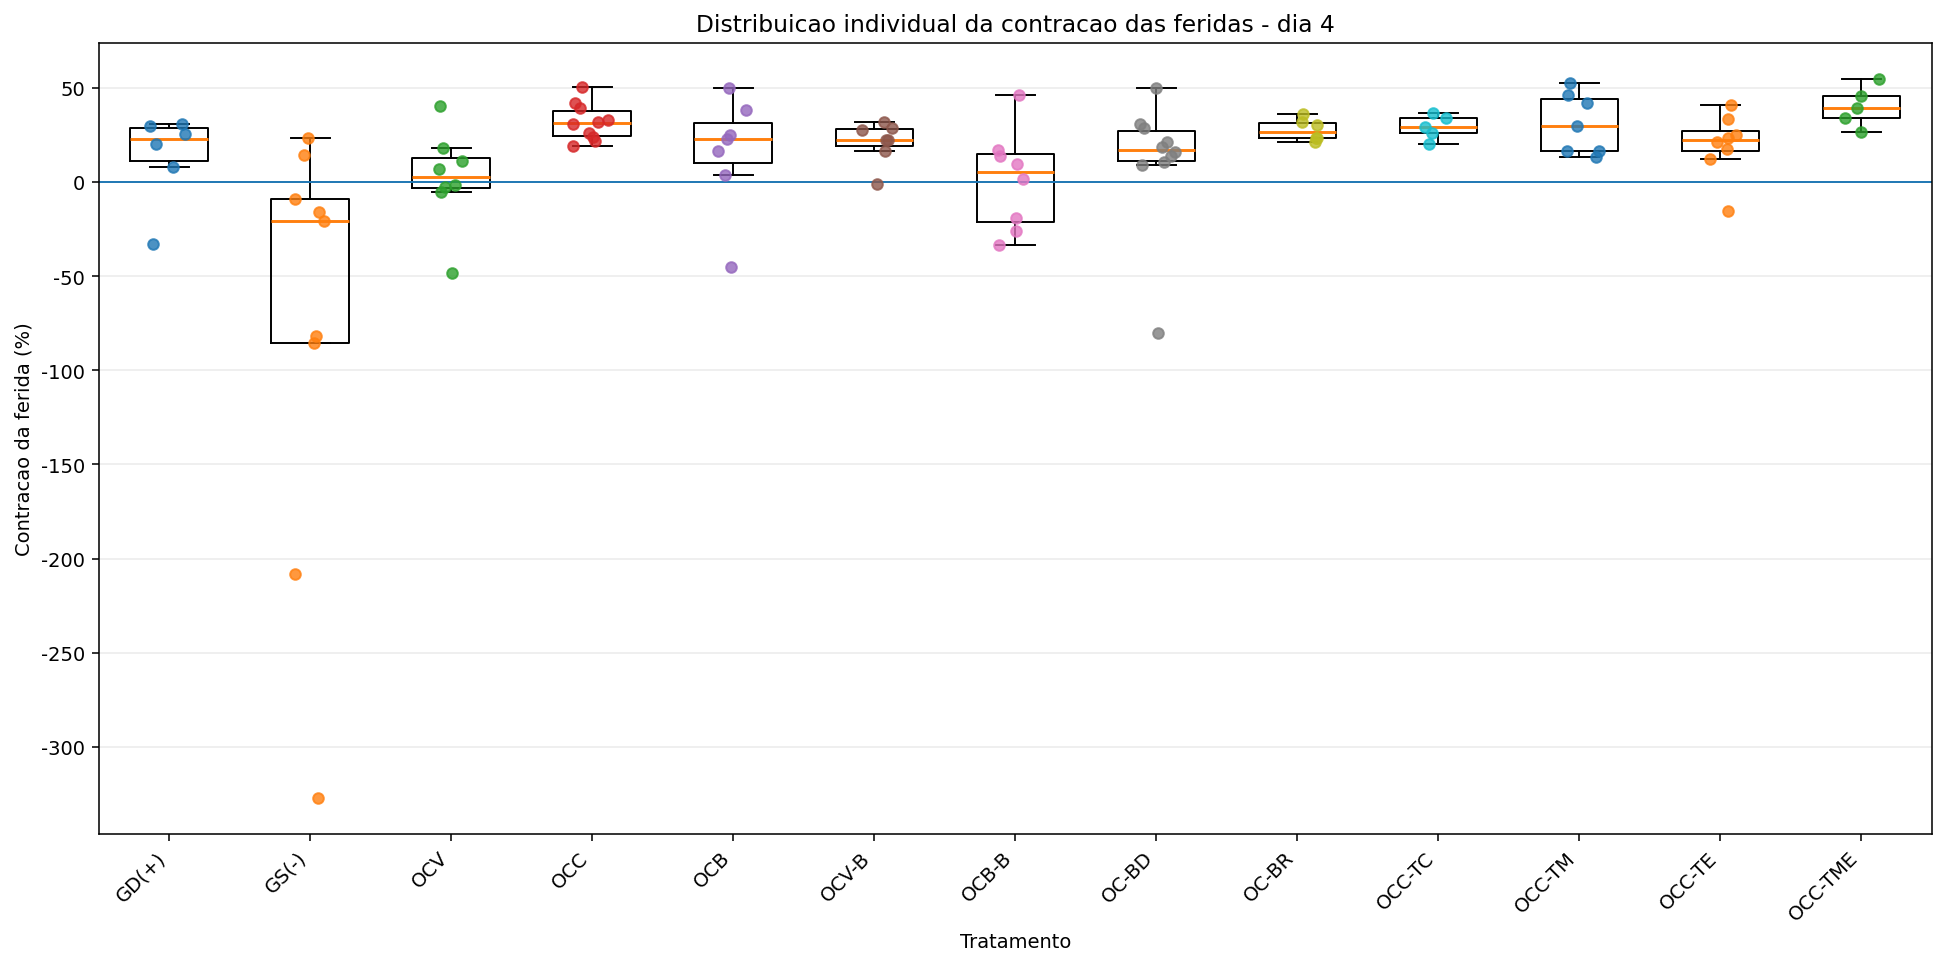


Gráfico do dia 4 salvo em:
/kaggle/working/projeto001_resultados/projeto001_distribuicao_contracao_dia_4.png

CONFERENCIA DOS DADOS DO DIA 8


,n,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo
Tratamento,,,,,,
GD(+),5,34.1249,58.3704,63.9251,73.3597,73.6351
GS(-),7,-33.8660,-9.4832,65.6583,70.5909,85.6304
OCV,8,37.6407,44.9350,49.3850,52.2454,60.7934
OCC,8,48.2958,57.2730,72.1919,74.0203,80.1635
OCB,6,10.3280,26.7905,52.0878,67.3029,79.4638
OCV-B,7,65.6548,75.8720,78.0466,83.0340,91.9895
OCB-B,6,41.6992,51.2140,58.2684,65.6842,74.7217
OC-BD,8,48.6985,52.5131,56.1288,63.3386,74.9337
OC-BR,6,82.3129,86.0529,89.3264,90.9508,93.4184


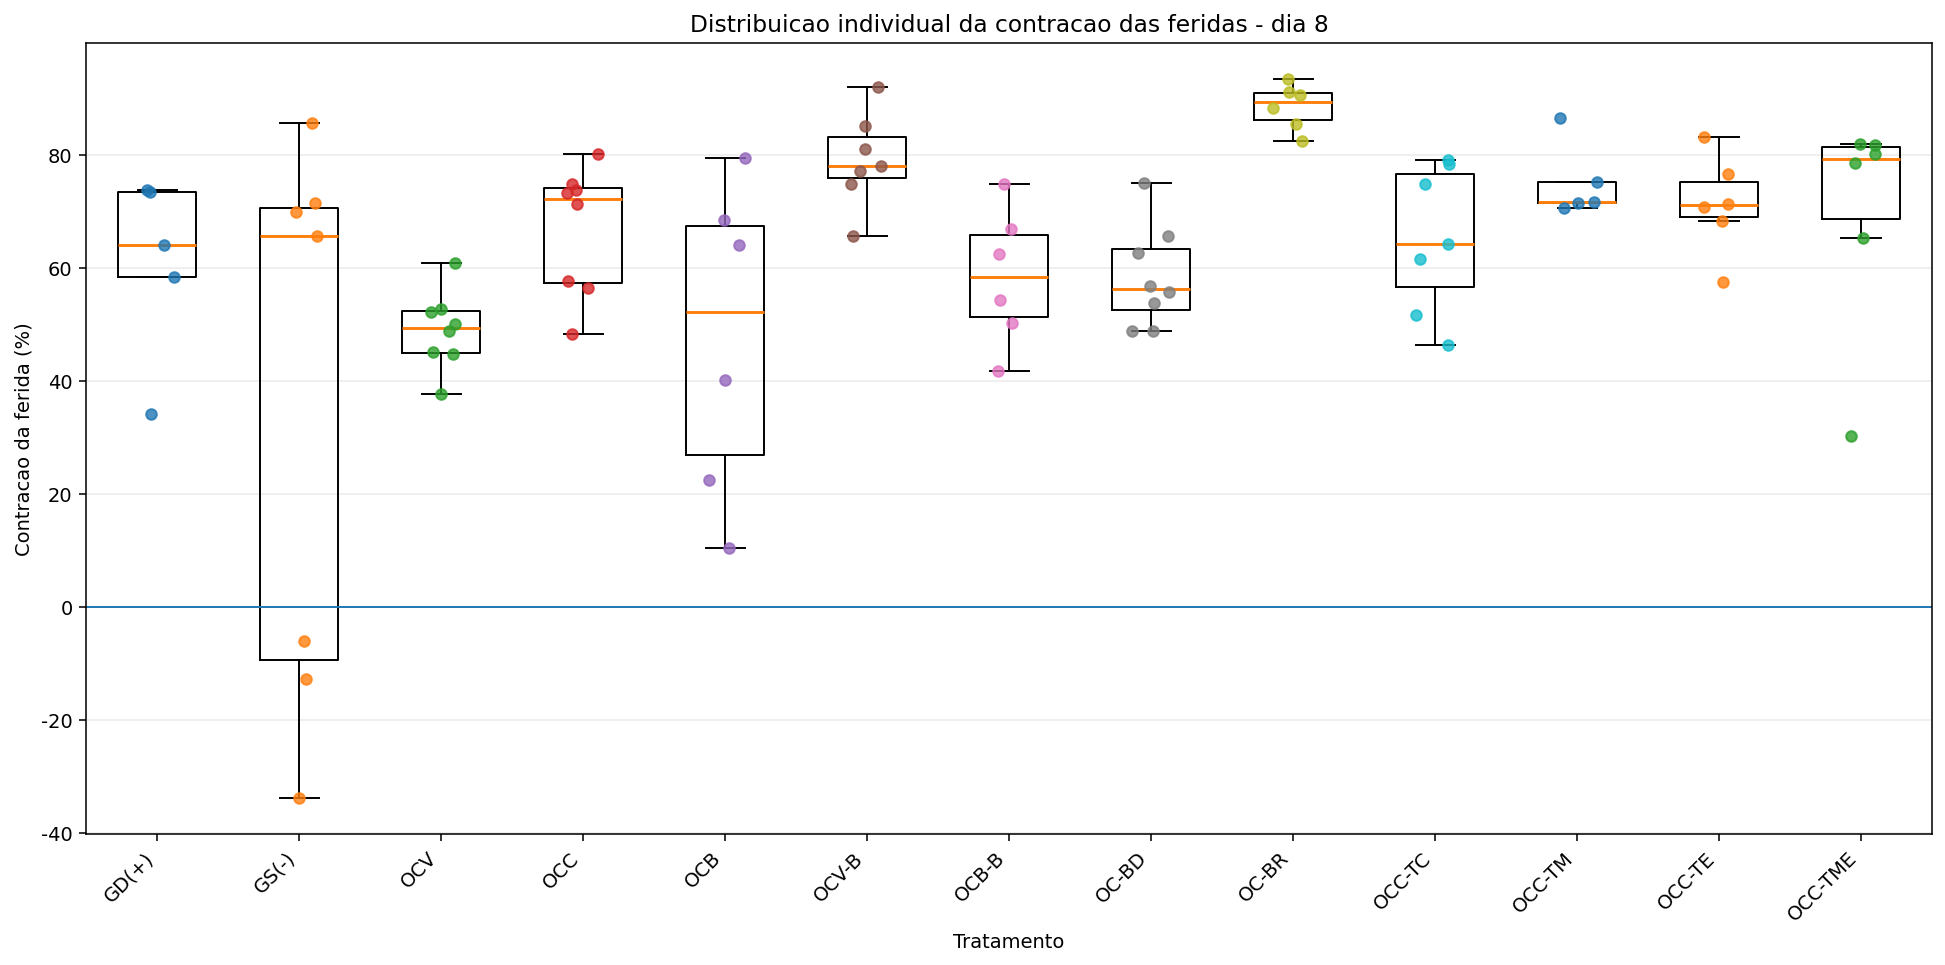


Gráfico do dia 8 salvo em:
/kaggle/working/projeto001_resultados/projeto001_distribuicao_contracao_dia_8.png

ETAPA 28 CONCLUIDA
Número de gráficos produzidos: 2
/kaggle/working/projeto001_resultados/projeto001_distribuicao_contracao_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_contracao_dia_8.png


In [30]:
# ETAPA 28 — Distribuição individual da contração
# Versão sem seaborn e sem caracteres especiais no gráfico

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ---------------------------------------------------------
# 1. Verificar as variáveis necessárias
# ---------------------------------------------------------

if "df_contracao_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_contracao_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 26."
    )

if "tratamentos_esperados" not in globals():
    raise RuntimeError(
        "A lista tratamentos_esperados não foi encontrada. "
        "Execute primeiro a Etapa 24 corrigida."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# ---------------------------------------------------------
# 2. Verificar as colunas necessárias
# ---------------------------------------------------------

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Contracao_percentual"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_contracao_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes em df_contracao_individual_longa: "
        f"{colunas_ausentes}"
    )


# ---------------------------------------------------------
# 3. Criar uma cópia exclusiva para os gráficos
# ---------------------------------------------------------

dados_plot = (
    df_contracao_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_plot["Tratamento"] = (
    dados_plot["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_plot["Dia"] = pd.to_numeric(
    dados_plot["Dia"],
    errors="coerce"
)

dados_plot["Contracao_percentual"] = pd.to_numeric(
    dados_plot["Contracao_percentual"],
    errors="coerce"
)


# ---------------------------------------------------------
# 4. Conferir valores inválidos
# ---------------------------------------------------------

linhas_invalidas = (
    dados_plot["Tratamento"].isna()
    | dados_plot["Dia"].isna()
    | dados_plot["Contracao_percentual"].isna()
    | ~np.isfinite(
        dados_plot["Contracao_percentual"]
    )
)

if linhas_invalidas.any():

    print(
        "Linhas inválidas encontradas antes da construção "
        "dos gráficos:"
    )

    display(
        dados_plot.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de contração."
    )


# ---------------------------------------------------------
# 5. Verificar tratamentos não previstos
# ---------------------------------------------------------

tratamentos_encontrados = set(
    dados_plot["Tratamento"].unique()
)

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_esperados)
)

if tratamentos_nao_previstos:

    print(
        "Tratamentos não previstos encontrados:"
    )

    print(
        tratamentos_nao_previstos
    )

    raise ValueError(
        "Existem tratamentos não previstos na tabela."
    )


# ---------------------------------------------------------
# 6. Criar separadamente os gráficos dos dias 4 e 8
# ---------------------------------------------------------

arquivos_graficos_etapa28 = []

for dia in [4, 8]:

    print("\n" + "=" * 90)
    print(f"CONFERENCIA DOS DADOS DO DIA {dia}")

    dados_dia = (
        dados_plot.loc[
            dados_plot["Dia"] == dia
        ]
        .copy()
    )

    if dados_dia.empty:
        raise RuntimeError(
            f"Não existem dados individuais para o dia {dia}."
        )


    # -----------------------------------------------------
    # 6.1. Estatística de conferência antes do gráfico
    # -----------------------------------------------------

    resumo_dia = (
        dados_dia
        .groupby(
            "Tratamento",
            observed=True
        )["Contracao_percentual"]
        .agg(
            n="count",
            minimo="min",
            primeiro_quartil=lambda serie: serie.quantile(0.25),
            mediana="median",
            terceiro_quartil=lambda serie: serie.quantile(0.75),
            maximo="max"
        )
        .reindex(
            tratamentos_esperados
        )
    )

    display(
        resumo_dia.round(4)
    )

    tratamentos_sem_dados = (
        resumo_dia.index[
            resumo_dia["n"].isna()
            | (resumo_dia["n"] == 0)
        ]
        .tolist()
    )

    if tratamentos_sem_dados:
        print(
            f"Atenção: tratamentos sem observações no dia {dia}:"
        )
        print(
            tratamentos_sem_dados
        )


    # -----------------------------------------------------
    # 6.2. Preparar os grupos para o boxplot
    # -----------------------------------------------------

    posicoes_todas = list(
        range(
            1,
            len(tratamentos_esperados) + 1
        )
    )

    grupos_com_dados = []
    posicoes_com_dados = []

    for posicao, tratamento in zip(
        posicoes_todas,
        tratamentos_esperados
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Contracao_percentual"
            ]
            .dropna()
            .to_numpy(
                dtype=float
            )
        )

        if len(valores) > 0:
            grupos_com_dados.append(
                valores
            )

            posicoes_com_dados.append(
                posicao
            )


    if not grupos_com_dados:
        raise RuntimeError(
            f"Nenhum grupo válido foi encontrado no dia {dia}."
        )


    # -----------------------------------------------------
    # 6.3. Construir o gráfico
    # -----------------------------------------------------
    # Os textos do gráfico usam apenas caracteres ASCII.
    # axes.unicode_minus=False impede o uso do símbolo Unicode
    # de menos nos valores negativos.

    configuracao_fonte = {
        "font.family": "DejaVu Sans",
        "axes.unicode_minus": False
    }

    with plt.rc_context(
        configuracao_fonte
    ):

        fig, ax = plt.subplots(
            figsize=(14, 7)
        )

        # Boxplot sem marcadores automáticos de outliers.
        # Nenhum valor é excluído: todos serão desenhados
        # no gráfico de pontos logo abaixo.
        ax.boxplot(
            grupos_com_dados,
            positions=posicoes_com_dados,
            widths=0.55,
            showfliers=False,
            patch_artist=False,
            medianprops={
                "linewidth": 1.5
            }
        )

        # Gerador fixo para o deslocamento horizontal.
        # Isso garante que o gráfico seja reprodutível.
        gerador = np.random.default_rng(
            20260728 + dia
        )

        # Adicionar todos os pontos individuais.
        for posicao, valores in zip(
            posicoes_com_dados,
            grupos_com_dados
        ):

            deslocamento = gerador.uniform(
                low=-0.14,
                high=0.14,
                size=len(valores)
            )

            coordenadas_x = (
                np.full(
                    len(valores),
                    posicao,
                    dtype=float
                )
                + deslocamento
            )

            ax.scatter(
                coordenadas_x,
                valores,
                s=30,
                alpha=0.80,
                zorder=3
            )

        # Linha correspondente a ausência de contração.
        ax.axhline(
            y=0,
            linewidth=1
        )

        # Textos propositalmente sem acentos ou travessão,
        # evitando o erro de carregamento de glifos.
        ax.set_title(
            "Distribuicao individual da contracao "
            f"das feridas - dia {dia}"
        )

        ax.set_xlabel(
            "Tratamento"
        )

        ax.set_ylabel(
            "Contracao da ferida (%)"
        )

        ax.set_xticks(
            posicoes_todas
        )

        ax.set_xticklabels(
            tratamentos_esperados,
            rotation=45,
            ha="right"
        )

        ax.grid(
            axis="y",
            alpha=0.25
        )

        fig.tight_layout()


        # -------------------------------------------------
        # 6.4. Renderizar antes de salvar
        # -------------------------------------------------
        # Esta chamada verifica antecipadamente se todos os
        # elementos gráficos podem ser desenhados.

        try:
            fig.canvas.draw()

        except RuntimeError as erro:

            plt.close(fig)

            raise RuntimeError(
                f"Falha ao renderizar o gráfico do dia {dia}. "
                "O problema ainda está relacionado à fonte "
                "ou ao backend gráfico."
            ) from erro


        # -------------------------------------------------
        # 6.5. Salvar o gráfico
        # -------------------------------------------------

        arquivo_boxplot = (
            PASTA_PROJETO
            / (
                "projeto001_distribuicao_"
                f"contracao_dia_{dia}.png"
            )
        )

        try:
            fig.savefig(
                arquivo_boxplot,
                dpi=300,
                bbox_inches="tight",
                format="png"
            )

        except Exception as erro:

            plt.close(fig)

            raise RuntimeError(
                f"Falha ao salvar o gráfico do dia {dia}."
            ) from erro


        plt.show()
        plt.close(fig)


    arquivos_graficos_etapa28.append(
        arquivo_boxplot
    )

    print(
        f"\nGráfico do dia {dia} salvo em:"
    )

    print(
        arquivo_boxplot
    )


# ---------------------------------------------------------
# 7. Confirmar a conclusão da etapa
# ---------------------------------------------------------

print("\n" + "=" * 90)
print("ETAPA 28 CONCLUIDA")

print(
    "Número de gráficos produzidos:",
    len(arquivos_graficos_etapa28)
)

for arquivo in arquivos_graficos_etapa28:
    print(
        arquivo
    )

## 29. Comparação global entre os tratamentos

A contração individual das feridas será comparada entre os 13 tratamentos,
separadamente para os dias 4 e 8.

Será utilizado o teste não paramétrico de Kruskal-Wallis, adequado para comparar
mais de dois grupos independentes sem pressupor distribuição normal dos dados.

Hipóteses do teste:

- hipótese nula: os tratamentos apresentam distribuições semelhantes;
- hipótese alternativa: pelo menos um tratamento apresenta distribuição diferente.

O teste global não identifica quais tratamentos diferem entre si. Comparações
múltiplas somente serão realizadas posteriormente, caso o resultado global
justifique essa análise.

Nenhum ponto extremo será removido e nenhum valor ausente será imputado.

In [31]:
# ETAPA 29 — Teste global de Kruskal-Wallis
# Comparação dos 13 tratamentos separadamente nos dias 4 e 8

import numpy as np
import pandas as pd
from scipy.stats import kruskal
from IPython.display import display


# ---------------------------------------------------------
# 1. Verificar as variáveis necessárias
# ---------------------------------------------------------

if "df_contracao_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_contracao_individual_longa não foi encontrada. "
        "Execute primeiro as etapas anteriores."
    )

if "tratamentos_esperados" not in globals():
    raise RuntimeError(
        "A lista tratamentos_esperados não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# ---------------------------------------------------------
# 2. Verificar as colunas necessárias
# ---------------------------------------------------------

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Contracao_percentual"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_contracao_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes em df_contracao_individual_longa: "
        f"{colunas_ausentes}"
    )


# ---------------------------------------------------------
# 3. Preparar uma cópia específica para o teste
# ---------------------------------------------------------

dados_kruskal = (
    df_contracao_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_kruskal["Tratamento"] = (
    dados_kruskal["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_kruskal["Dia"] = pd.to_numeric(
    dados_kruskal["Dia"],
    errors="coerce"
)

dados_kruskal["Contracao_percentual"] = pd.to_numeric(
    dados_kruskal["Contracao_percentual"],
    errors="coerce"
)


# ---------------------------------------------------------
# 4. Auditar valores inválidos
# ---------------------------------------------------------

linhas_invalidas = (
    dados_kruskal["Tratamento"].isna()
    | dados_kruskal["Dia"].isna()
    | dados_kruskal["Contracao_percentual"].isna()
    | ~np.isfinite(
        dados_kruskal["Contracao_percentual"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_kruskal.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados da contração."
    )


# ---------------------------------------------------------
# 5. Verificar tratamentos não previstos
# ---------------------------------------------------------

tratamentos_encontrados = set(
    dados_kruskal["Tratamento"].unique()
)

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_esperados)
)

if tratamentos_nao_previstos:
    raise ValueError(
        "Foram encontrados tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


# ---------------------------------------------------------
# 6. Realizar o Kruskal-Wallis em cada dia
# ---------------------------------------------------------

resultados_kruskal = []
contagens_kruskal = []

for dia in [4, 8]:

    dados_dia = (
        dados_kruskal.loc[
            dados_kruskal["Dia"] == dia
        ]
        .copy()
    )

    if dados_dia.empty:
        raise RuntimeError(
            f"Não existem dados de contração para o dia {dia}."
        )

    grupos = []
    nomes_grupos = []

    for tratamento in tratamentos_esperados:

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Contracao_percentual"
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        contagens_kruskal.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": len(valores)
            }
        )

        if len(valores) < 2:
            raise ValueError(
                f"O tratamento {tratamento} possui apenas "
                f"{len(valores)} observação(ões) no dia {dia}. "
                "O teste global não será executado."
            )

        grupos.append(valores)
        nomes_grupos.append(tratamento)

    numero_grupos = len(grupos)
    numero_total = sum(len(grupo) for grupo in grupos)

    if numero_grupos != len(tratamentos_esperados):
        raise ValueError(
            f"O dia {dia} não contém todos os "
            f"{len(tratamentos_esperados)} tratamentos."
        )

    estatistica_h, valor_p = kruskal(
        *grupos,
        nan_policy="raise"
    )

    graus_liberdade = numero_grupos - 1

    # Tamanho de efeito epsilon-quadrado
    denominador = numero_total - numero_grupos

    if denominador > 0:
        epsilon_quadrado = (
            estatistica_h
            - numero_grupos
            + 1
        ) / denominador

        epsilon_quadrado = max(
            0.0,
            float(epsilon_quadrado)
        )

    else:
        epsilon_quadrado = np.nan

    if valor_p < 0.05:
        conclusao = (
            "Há evidência de diferença global entre os tratamentos."
        )
    else:
        conclusao = (
            "Não há evidência de diferença global entre os tratamentos."
        )

    resultados_kruskal.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Estatistica_H": estatistica_h,
            "Graus_de_liberdade": graus_liberdade,
            "Valor_p": valor_p,
            "Epsilon_quadrado": epsilon_quadrado,
            "Conclusao_5_percent": conclusao
        }
    )


# ---------------------------------------------------------
# 7. Criar tabelas de resultados
# ---------------------------------------------------------

df_contagens_kruskal = pd.DataFrame(
    contagens_kruskal
)

df_resultados_kruskal = pd.DataFrame(
    resultados_kruskal
)


# ---------------------------------------------------------
# 8. Conferir o número de observações
# ---------------------------------------------------------

tabela_contagens_kruskal = (
    df_contagens_kruskal
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)

print("Número de observações utilizadas em cada grupo:")

display(
    tabela_contagens_kruskal
)


# ---------------------------------------------------------
# 9. Exibir os resultados globais
# ---------------------------------------------------------

print("\nResultados do teste global de Kruskal-Wallis:")

display(
    df_resultados_kruskal.round(
        {
            "Estatistica_H": 4,
            "Valor_p": 6,
            "Epsilon_quadrado": 4
        }
    )
)


# ---------------------------------------------------------
# 10. Interpretação automática
# ---------------------------------------------------------

for _, resultado in df_resultados_kruskal.iterrows():

    dia = int(resultado["Dia"])
    h = resultado["Estatistica_H"]
    p = resultado["Valor_p"]
    epsilon = resultado["Epsilon_quadrado"]

    print("\n" + "=" * 80)

    print(f"DIA {dia}")

    print(
        f"Kruskal-Wallis: H = {h:.4f}; "
        f"gl = {int(resultado['Graus_de_liberdade'])}; "
        f"p = {p:.6f}"
    )

    print(
        f"Epsilon-quadrado = {epsilon:.4f}"
    )

    print(
        resultado["Conclusao_5_percent"]
    )

    if p < 0.05:
        print(
            "O resultado global permite avançar para "
            "comparações múltiplas entre tratamentos."
        )
    else:
        print(
            "O resultado global não demonstra diferença "
            "estatística entre os tratamentos neste dia."
        )


# ---------------------------------------------------------
# 11. Salvar os resultados
# ---------------------------------------------------------

arquivo_resultados_kruskal = (
    PASTA_PROJETO
    / "projeto001_kruskal_contracao_dias_4_8.csv"
)

arquivo_contagens_kruskal = (
    PASTA_PROJETO
    / "projeto001_contagens_kruskal_dias_4_8.csv"
)

df_resultados_kruskal.to_csv(
    arquivo_resultados_kruskal,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tabela_contagens_kruskal.to_csv(
    arquivo_contagens_kruskal,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")

print(arquivo_resultados_kruskal)
print(arquivo_contagens_kruskal)

Número de observações utilizadas em cada grupo:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),6,5
GS(-),9,7
OCV,8,8
OCC,10,8
OCB,7,6
OCV-B,7,7
OCB-B,8,6
OC-BD,10,8
OC-BR,6,6



Resultados do teste global de Kruskal-Wallis:


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Estatistica_H,Graus_de_liberdade,Valor_p,Epsilon_quadrado,Conclusao_5_percent
0,4,13,96,39.5458,12,0.000086,0.3319,Há evidência de diferença global entre os trat...
1,8,13,85,40.0094,12,0.000072,0.3890,Há evidência de diferença global entre os trat...



DIA 4
Kruskal-Wallis: H = 39.5458; gl = 12; p = 0.000086
Epsilon-quadrado = 0.3319
Há evidência de diferença global entre os tratamentos.
O resultado global permite avançar para comparações múltiplas entre tratamentos.

DIA 8
Kruskal-Wallis: H = 40.0094; gl = 12; p = 0.000072
Epsilon-quadrado = 0.3890
Há evidência de diferença global entre os tratamentos.
O resultado global permite avançar para comparações múltiplas entre tratamentos.

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_kruskal_contracao_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_kruskal_dias_4_8.csv


## 30. Comparações dos óleos com os controles

Como o teste global de Kruskal-Wallis indicou diferenças entre os tratamentos
nos dias 4 e 8, serão realizadas comparações planejadas entre cada óleo de café
e os dois controles experimentais:

- GD(+): controle positivo;
- GS(-): controle negativo.

Será utilizado o teste bilateral de Mann-Whitney para grupos independentes.

Em cada dia serão realizadas 22 comparações:

- 11 óleos versus GD(+);
- 11 óleos versus GS(-).

Os valores de p serão corrigidos pelo método de Holm dentro de cada dia,
considerando conjuntamente as 22 comparações. Essa correção controla o aumento
do risco de resultados falso-positivos provocado pelas comparações múltiplas.

Também serão apresentados:

- número de observações;
- mediana de cada grupo;
- diferença entre as medianas;
- correlação bisserial de postos como medida de tamanho e direção do efeito.

Valores positivos da correlação bisserial indicam tendência de maior contração
no óleo em comparação ao controle. Valores negativos indicam tendência de menor
contração.

Nenhum ponto extremo será removido e nenhum valor ausente será imputado.

In [32]:
# ETAPA 30 — Comparações planejadas dos óleos com os controles
# Mann-Whitney bilateral com correção de Holm

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Verificar as variáveis necessárias
# =========================================================

if "df_contracao_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_contracao_individual_longa não foi encontrada. "
        "Execute primeiro as etapas anteriores."
    )

if "df_resultados_kruskal" not in globals():
    raise RuntimeError(
        "Os resultados do teste de Kruskal-Wallis não foram encontrados. "
        "Execute primeiro a Etapa 29."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# =========================================================
# 2. Definir controles e óleos
# =========================================================

controles = [
    "GD(+)",
    "GS(-)"
]

oleos = [
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

tratamentos_comparacao = controles + oleos


# =========================================================
# 3. Conferir o resultado global da Etapa 29
# =========================================================

resultados_globais = (
    df_resultados_kruskal[
        [
            "Dia",
            "Valor_p"
        ]
    ]
    .copy()
)

resultados_globais["Dia"] = pd.to_numeric(
    resultados_globais["Dia"],
    errors="coerce"
)

resultados_globais["Valor_p"] = pd.to_numeric(
    resultados_globais["Valor_p"],
    errors="coerce"
)

for dia in [4, 8]:

    linha_dia = resultados_globais.loc[
        resultados_globais["Dia"] == dia
    ]

    if linha_dia.empty:
        raise ValueError(
            f"O resultado global do dia {dia} não foi encontrado."
        )

    valor_p_global = float(
        linha_dia["Valor_p"].iloc[0]
    )

    if valor_p_global >= 0.05:
        raise ValueError(
            f"O teste global do dia {dia} não foi significativo "
            f"(p = {valor_p_global:.6f}). "
            "As comparações múltiplas não serão executadas."
        )


# =========================================================
# 4. Preparar os dados
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Contracao_percentual"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_contracao_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes em df_contracao_individual_longa: "
        f"{colunas_ausentes}"
    )

dados_comparacoes = (
    df_contracao_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_comparacoes["Tratamento"] = (
    dados_comparacoes["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_comparacoes["Dia"] = pd.to_numeric(
    dados_comparacoes["Dia"],
    errors="coerce"
)

dados_comparacoes["Contracao_percentual"] = pd.to_numeric(
    dados_comparacoes["Contracao_percentual"],
    errors="coerce"
)


# =========================================================
# 5. Verificar linhas inválidas
# =========================================================

linhas_invalidas = (
    dados_comparacoes["Tratamento"].isna()
    | dados_comparacoes["Dia"].isna()
    | dados_comparacoes["Contracao_percentual"].isna()
    | ~np.isfinite(
        dados_comparacoes["Contracao_percentual"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_comparacoes.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados das comparações."
    )


# =========================================================
# 6. Verificar presença dos 13 tratamentos
# =========================================================

for dia in [4, 8]:

    tratamentos_no_dia = set(
        dados_comparacoes.loc[
            dados_comparacoes["Dia"] == dia,
            "Tratamento"
        ].unique()
    )

    tratamentos_ausentes = [
        tratamento
        for tratamento in tratamentos_comparacao
        if tratamento not in tratamentos_no_dia
    ]

    if tratamentos_ausentes:
        raise ValueError(
            f"Tratamentos ausentes no dia {dia}: "
            f"{tratamentos_ausentes}"
        )


# =========================================================
# 7. Função auxiliar para classificar a magnitude do efeito
# =========================================================

def classificar_magnitude_efeito(valor):

    valor_absoluto = abs(valor)

    if valor_absoluto < 0.10:
        return "Desprezível"

    if valor_absoluto < 0.30:
        return "Pequeno"

    if valor_absoluto < 0.50:
        return "Moderado"

    return "Grande"


# =========================================================
# 8. Realizar as comparações
# =========================================================

resultados_comparacoes = []

for dia in [4, 8]:

    dados_dia = dados_comparacoes.loc[
        dados_comparacoes["Dia"] == dia
    ].copy()

    resultados_dia = []

    for controle in controles:

        valores_controle = (
            dados_dia.loc[
                dados_dia["Tratamento"] == controle,
                "Contracao_percentual"
            ]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(valores_controle) < 2:
            raise ValueError(
                f"O controle {controle} possui apenas "
                f"{len(valores_controle)} observação(ões) "
                f"no dia {dia}."
            )

        for oleo in oleos:

            valores_oleo = (
                dados_dia.loc[
                    dados_dia["Tratamento"] == oleo,
                    "Contracao_percentual"
                ]
                .dropna()
                .to_numpy(dtype=float)
            )

            if len(valores_oleo) < 2:
                raise ValueError(
                    f"O óleo {oleo} possui apenas "
                    f"{len(valores_oleo)} observação(ões) "
                    f"no dia {dia}."
                )

            estatistica_u, valor_p_bruto = mannwhitneyu(
                valores_oleo,
                valores_controle,
                alternative="two-sided",
                method="auto"
            )

            n_oleo = len(valores_oleo)
            n_controle = len(valores_controle)

            # Correlação bisserial de postos.
            # Valor positivo: óleo tende a valores maiores.
            # Valor negativo: óleo tende a valores menores.
            correlacao_bisserial = (
                2 * estatistica_u
                / (n_oleo * n_controle)
            ) - 1

            mediana_oleo = float(
                np.median(valores_oleo)
            )

            mediana_controle = float(
                np.median(valores_controle)
            )

            diferenca_medianas = (
                mediana_oleo
                - mediana_controle
            )

            if correlacao_bisserial > 0:
                direcao = (
                    "Óleo tende a apresentar maior contração"
                )

            elif correlacao_bisserial < 0:
                direcao = (
                    "Óleo tende a apresentar menor contração"
                )

            else:
                direcao = (
                    "Ausência de direção predominante"
                )

            resultados_dia.append(
                {
                    "Dia": dia,
                    "Oleo": oleo,
                    "Controle": controle,
                    "n_Oleo": n_oleo,
                    "n_Controle": n_controle,
                    "Mediana_Oleo": mediana_oleo,
                    "Mediana_Controle": mediana_controle,
                    "Diferenca_Medianas": diferenca_medianas,
                    "Estatistica_U": float(estatistica_u),
                    "Valor_p_bruto": float(valor_p_bruto),
                    "Correlacao_bisserial_postos": (
                        float(correlacao_bisserial)
                    ),
                    "Magnitude_efeito": classificar_magnitude_efeito(
                        correlacao_bisserial
                    ),
                    "Direcao_efeito": direcao
                }
            )


    # =====================================================
    # 9. Correção de Holm dentro do dia
    # =====================================================
    # As 22 comparações do dia são tratadas como uma única
    # família de testes.

    valores_p_dia = [
        resultado["Valor_p_bruto"]
        for resultado in resultados_dia
    ]

    rejeitar_h0, valores_p_ajustados, _, _ = multipletests(
        valores_p_dia,
        alpha=0.05,
        method="holm"
    )

    for resultado, rejeitar, p_ajustado in zip(
        resultados_dia,
        rejeitar_h0,
        valores_p_ajustados
    ):

        resultado["Valor_p_Holm"] = float(
            p_ajustado
        )

        resultado["Significativo_Holm_5_percent"] = bool(
            rejeitar
        )

        if rejeitar:
            resultado["Conclusao"] = (
                "Diferença significativa após correção de Holm"
            )
        else:
            resultado["Conclusao"] = (
                "Diferença não significativa após correção de Holm"
            )

    resultados_comparacoes.extend(
        resultados_dia
    )


# =========================================================
# 10. Criar a tabela final
# =========================================================

df_comparacoes_controles = pd.DataFrame(
    resultados_comparacoes
)

ordem_colunas = [
    "Dia",
    "Oleo",
    "Controle",
    "n_Oleo",
    "n_Controle",
    "Mediana_Oleo",
    "Mediana_Controle",
    "Diferenca_Medianas",
    "Estatistica_U",
    "Valor_p_bruto",
    "Valor_p_Holm",
    "Significativo_Holm_5_percent",
    "Correlacao_bisserial_postos",
    "Magnitude_efeito",
    "Direcao_efeito",
    "Conclusao"
]

df_comparacoes_controles = (
    df_comparacoes_controles[
        ordem_colunas
    ]
    .sort_values(
        [
            "Dia",
            "Controle",
            "Valor_p_Holm",
            "Oleo"
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 11. Mostrar os resultados por dia e controle
# =========================================================

for dia in [4, 8]:

    for controle in controles:

        print("\n" + "=" * 100)

        print(
            f"DIA {dia} — ÓLEOS VERSUS {controle}"
        )

        tabela_exibicao = (
            df_comparacoes_controles.loc[
                (
                    df_comparacoes_controles["Dia"] == dia
                )
                & (
                    df_comparacoes_controles["Controle"]
                    == controle
                ),
                [
                    "Oleo",
                    "n_Oleo",
                    "n_Controle",
                    "Mediana_Oleo",
                    "Mediana_Controle",
                    "Diferenca_Medianas",
                    "Valor_p_bruto",
                    "Valor_p_Holm",
                    "Significativo_Holm_5_percent",
                    "Correlacao_bisserial_postos",
                    "Magnitude_efeito",
                    "Direcao_efeito"
                ]
            ]
        )

        display(
            tabela_exibicao.round(
                {
                    "Mediana_Oleo": 4,
                    "Mediana_Controle": 4,
                    "Diferenca_Medianas": 4,
                    "Valor_p_bruto": 6,
                    "Valor_p_Holm": 6,
                    "Correlacao_bisserial_postos": 4
                }
            )
        )


# =========================================================
# 12. Mostrar somente os resultados significativos
# =========================================================

df_comparacoes_significativas = (
    df_comparacoes_controles.loc[
        df_comparacoes_controles[
            "Significativo_Holm_5_percent"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n" + "=" * 100)

print(
    "COMPARAÇÕES SIGNIFICATIVAS APÓS CORREÇÃO DE HOLM"
)

if df_comparacoes_significativas.empty:

    print(
        "Nenhuma comparação permaneceu significativa "
        "após a correção de Holm."
    )

else:

    display(
        df_comparacoes_significativas[
            [
                "Dia",
                "Oleo",
                "Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_bruto",
                "Valor_p_Holm",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito"
            ]
        ].round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_bruto": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 13. Salvar os resultados
# =========================================================

arquivo_comparacoes_controles = (
    PASTA_PROJETO
    / "projeto001_mannwhitney_oleos_vs_controles_holm.csv"
)

arquivo_comparacoes_significativas = (
    PASTA_PROJETO
    / "projeto001_comparacoes_significativas_holm.csv"
)

df_comparacoes_controles.to_csv(
    arquivo_comparacoes_controles,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_comparacoes_significativas.to_csv(
    arquivo_comparacoes_significativas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")

print(
    arquivo_comparacoes_controles
)

print(
    arquivo_comparacoes_significativas
)


DIA 4 — ÓLEOS VERSUS GD(+)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_bruto,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
0,OCC-TME,5,6,39.3493,22.7418,16.6075,0.017316,0.230070,False,0.8667,Grande,Óleo tende a apresentar maior contração
1,OCC,10,6,31.2098,22.7418,8.4680,0.055944,0.671329,False,0.6000,Grande,Óleo tende a apresentar maior contração
2,OC-BD,10,6,16.9917,22.7418,-5.7502,0.874875,1.000000,False,-0.0667,Desprezível,Óleo tende a apresentar menor contração
3,OC-BR,6,6,26.6360,22.7418,3.8942,0.240260,1.000000,False,0.4444,Moderado,Óleo tende a apresentar maior contração
4,OCB,7,6,22.7271,22.7418,-0.0147,1.000000,1.000000,False,0.0000,Desprezível,Ausência de direção predominante
5,OCB-B,8,6,5.4711,22.7418,-17.2707,0.282384,1.000000,False,-0.3750,Moderado,Óleo tende a apresentar menor contração
6,OCC-TC,5,6,29.1300,22.7418,6.3882,0.246753,1.000000,False,0.4667,Moderado,Óleo tende a apresentar maior contração
7,OCC-TE,8,6,22.0024,22.7418,-0.7394,0.851815,1.000000,False,0.0833,Desprezível,Óleo tende a apresentar maior contração
8,OCC-TM,7,6,29.8853,22.7418,7.1434,0.294872,1.000000,False,0.3810,Moderado,Óleo tende a apresentar maior contração
9,OCV,8,6,2.6122,22.7418,-20.1296,0.228438,1.000000,False,-0.4167,Moderado,Óleo tende a apresentar menor contração



DIA 4 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_bruto,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
11,OCC,10,9,31.2098,-20.7034,51.9131,0.000520,0.011445,True,0.9556,Grande,Óleo tende a apresentar maior contração
12,OC-BR,6,9,26.6360,-20.7034,47.3394,0.000799,0.016783,True,0.9630,Grande,Óleo tende a apresentar maior contração
13,OCC-TME,5,9,39.3493,-20.7034,60.0526,0.000999,0.019980,True,1.0000,Grande,Óleo tende a apresentar maior contração
14,OCC-TC,5,9,29.1300,-20.7034,49.8334,0.001998,0.037962,True,0.9556,Grande,Óleo tende a apresentar maior contração
15,OCC-TM,7,9,29.8853,-20.7034,50.5886,0.002098,0.037962,True,0.8730,Grande,Óleo tende a apresentar maior contração
16,OCV-B,7,9,22.4342,-20.7034,43.1376,0.003322,0.056469,False,0.8413,Grande,Óleo tende a apresentar maior contração
17,OCC-TE,8,9,22.0024,-20.7034,42.7058,0.005512,0.088194,False,0.7778,Grande,Óleo tende a apresentar maior contração
18,OC-BD,10,9,16.9917,-20.7034,37.6950,0.012763,0.191445,False,0.6889,Grande,Óleo tende a apresentar maior contração
19,OCB,7,9,22.7271,-20.7034,43.4305,0.016434,0.230070,False,0.7143,Grande,Óleo tende a apresentar maior contração
20,OCV,8,9,2.6122,-20.7034,23.3155,0.059235,0.671329,False,0.5556,Grande,Óleo tende a apresentar maior contração



DIA 8 — ÓLEOS VERSUS GD(+)


...


DIA 8 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_bruto,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
33,OC-BR,6,7,89.3264,65.6583,23.6681,0.004662,0.097902,False,0.9048,Grande,Óleo tende a apresentar maior contração
34,OC-BD,8,7,56.1288,65.6583,-9.5295,0.955089,1.000000,False,-0.0357,Desprezível,Óleo tende a apresentar menor contração
35,OCB,6,7,52.0878,65.6583,-13.5705,0.945221,1.000000,False,0.0476,Desprezível,Óleo tende a apresentar maior contração
36,OCB-B,6,7,58.2684,65.6583,-7.3899,0.945221,1.000000,False,0.0476,Desprezível,Óleo tende a apresentar maior contração
37,OCC,8,7,72.1919,65.6583,6.5335,0.280963,1.000000,False,0.3571,Moderado,Óleo tende a apresentar maior contração
38,OCC-TC,7,7,64.1481,65.6583,-1.5103,0.534965,1.000000,False,0.2245,Pequeno,Óleo tende a apresentar maior contração
39,OCC-TE,6,7,71.0297,65.6583,5.3714,0.294872,1.000000,False,0.3810,Moderado,Óleo tende a apresentar maior contração
40,OCC-TM,5,7,71.6882,65.6583,6.0299,0.073232,1.000000,False,0.6571,Grande,Óleo tende a apresentar maior contração
41,OCC-TME,6,7,79.2833,65.6583,13.6250,0.234266,1.000000,False,0.4286,Moderado,Óleo tende a apresentar maior contração
42,OCV,8,7,49.3850,65.6583,-16.2733,0.694328,1.000000,False,-0.1429,Pequeno,Óleo tende a apresentar menor contração



COMPARAÇÕES SIGNIFICATIVAS APÓS CORREÇÃO DE HOLM


,Dia,Oleo,Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_bruto,Valor_p_Holm,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
0,4,OCC,GS(-),31.2098,-20.7034,51.9131,0.000520,0.011445,0.9556,Grande,Óleo tende a apresentar maior contração
1,4,OC-BR,GS(-),26.6360,-20.7034,47.3394,0.000799,0.016783,0.9630,Grande,Óleo tende a apresentar maior contração
2,4,OCC-TME,GS(-),39.3493,-20.7034,60.0526,0.000999,0.019980,1.0000,Grande,Óleo tende a apresentar maior contração
3,4,OCC-TC,GS(-),29.1300,-20.7034,49.8334,0.001998,0.037962,0.9556,Grande,Óleo tende a apresentar maior contração
4,4,OCC-TM,GS(-),29.8853,-20.7034,50.5886,0.002098,0.037962,0.8730,Grande,Óleo tende a apresentar maior contração



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_mannwhitney_oleos_vs_controles_holm.csv
/kaggle/working/projeto001_resultados/projeto001_comparacoes_significativas_holm.csv


In [33]:
print("Dimensão da matriz química:")
print(X_quimica_analise.shape)

print("\nNúmero de variáveis usadas na PCA:")
print(X_quimica_analise.shape[1])

print("\nVariáveis químicas:")
for numero, variavel in enumerate(
    X_quimica_analise.columns,
    start=1
):
    print(f"{numero:02d}. {variavel}")

Dimensão da matriz química:
(11, 37)

Número de variáveis usadas na PCA:
37

Variáveis químicas:
01. 5.71 | Ácido palmítico
02. 6.39 | Cafeína
03. 6.47 | Ácido linoleico
04. 8.13 | Caveal
05. 8.22 | 15,16-dehydro-caveol
06. 8.31 | Cafestal
07. 8.46 | 15,16-dehydro-cafestol
08. 8.51 | Dehidro-caveol
09. 8.64 | Dehidro-caveol derivado
10. 8.78 | Dehidro-cafestol
11. 9.07 | Caveol
12. 9.12 | Cafestol
13. 9.23 | Tocoferol
14. 9.82 | Campesterol
15. 9.94 | Estigmasterol
16. 10.15 | β-sitosterol
17. 17.22 | Palmitato de caveol
18. 17.64 | Palmitato de cafestol
19. 18.23 | Estearato de caveol
20. 18.36 | Oleato de caveol
21. 18.87 | Estearato de cafestol
22. 19.24 | Linoleato de caveol
23. 19.46 | Oleato de cafestol
24. 19.67 | Linoleato de cafestol
25. 20.43 | Araquidato de caveol
26. 21.25 | Araquidato de cafestol
27. 22.97 | 1,2,3-tripalmitoil-glicerol (PPP)
28. 23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)
29. 23.41 | 1,2-dipalmitoll-3-linoleoll glicerol (PPL)
30. 24.75 | 1-palmitoil-2-

In [34]:
# Conferência das 37 variáveis e dos nomes químicos únicos

import re
import pandas as pd
from IPython.display import display

variaveis_quimicas = pd.Series(
    X_quimica_analise.columns.astype(str),
    name="Variavel_original"
)

df_identificacoes_quimicas = pd.DataFrame(
    {
        "Variavel_original": variaveis_quimicas
    }
)

# Remove o número inicial correspondente ao tempo de retenção
# e os separadores situados antes do nome químico.
df_identificacoes_quimicas["Nome_quimico"] = (
    df_identificacoes_quimicas["Variavel_original"]
    .str.replace(
        r"^\s*\d+(?:[.,]\d+)?\s*[|:\-–—]?\s*",
        "",
        regex=True
    )
    .str.strip()
)

print(
    "Número de variáveis cromatográficas:",
    len(df_identificacoes_quimicas)
)

print(
    "Número de nomes químicos únicos:",
    df_identificacoes_quimicas["Nome_quimico"].nunique()
)

print("\nNomes repetidos em diferentes variáveis:")

contagem_nomes = (
    df_identificacoes_quimicas
    .groupby("Nome_quimico", as_index=False)
    .agg(
        Numero_de_ocorrencias=(
            "Variavel_original",
            "count"
        )
    )
    .sort_values(
        [
            "Numero_de_ocorrencias",
            "Nome_quimico"
        ],
        ascending=[False, True]
    )
)

display(
    contagem_nomes.loc[
        contagem_nomes["Numero_de_ocorrencias"] > 1
    ]
)

print("\nRelação completa das variáveis:")

display(
    df_identificacoes_quimicas
)

Número de variáveis cromatográficas: 37
Número de nomes químicos únicos: 37

Nomes repetidos em diferentes variáveis:


,Nome_quimico,Numero_de_ocorrencias



Relação completa das variáveis:


,Variavel_original,Nome_quimico
0,5.71 | Ácido palmítico,Ácido palmítico
1,6.39 | Cafeína,Cafeína
2,6.47 | Ácido linoleico,Ácido linoleico
3,8.13 | Caveal,Caveal
4,"8.22 | 15,16-dehydro-caveol","15,16-dehydro-caveol"
5,8.31 | Cafestal,Cafestal
6,"8.46 | 15,16-dehydro-cafestol","15,16-dehydro-cafestol"
7,8.51 | Dehidro-caveol,Dehidro-caveol
8,8.64 | Dehidro-caveol derivado,Dehidro-caveol derivado
9,8.78 | Dehidro-cafestol,Dehidro-cafestol


## 31. Mapeamento das tabelas de estresse oxidativo

Após a análise da contração das feridas, serão avaliados os marcadores
relacionados ao estresse oxidativo e à capacidade antioxidante.

Nesta etapa serão identificadas as abas contendo dados de:

- proteínas carboniladas;
- FRAP;
- MDA;
- superóxido dismutase — SOD;
- catalase;
- outros marcadores oxidativos disponíveis.

O arquivo-base definitivo é:

`Tabela analise multivariada_FJMN marcos_outliers3.xlsx`

Nenhum dado será modificado, excluído ou analisado estatisticamente nesta etapa.

In [35]:
# ETAPA 31 — Mapeamento das abas de estresse oxidativo

from pathlib import Path
import unicodedata
import pandas as pd

from openpyxl import load_workbook
from IPython.display import display


# =========================================================
# 1. Verificar a pasta do projeto
# =========================================================

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada. "
        "Execute primeiro as etapas iniciais do notebook."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)


# =========================================================
# 2. Reutilizar o arquivo-base localizado em /kaggle/input
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada. Execute primeiro a Etapa 3."
    )

ARQUIVO_EXCEL = Path(ARQUIVO_EXCEL)

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        "O novo arquivo-base não foi encontrado:\n"
        f"{ARQUIVO_EXCEL}"
    )

print("Arquivo-base utilizado:")
print(ARQUIVO_EXCEL)


# =========================================================
# 3. Função para normalizar textos
# =========================================================

def normalizar_texto(texto):

    texto = str(texto).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    return texto


# =========================================================
# 4. Abrir o arquivo sem carregar todas as planilhas
# =========================================================

workbook = load_workbook(
    ARQUIVO_EXCEL,
    read_only=True,
    data_only=True
)

nomes_abas = workbook.sheetnames

print("\nNúmero total de abas no arquivo:")
print(len(nomes_abas))

print("\nRelação completa das abas:")

for numero, nome_aba in enumerate(
    nomes_abas,
    start=1
):
    print(f"{numero:02d}. {nome_aba}")


# =========================================================
# 5. Termos usados para localizar marcadores oxidativos
# =========================================================

termos_oxidativos = {
    "oxid": "Estresse oxidativo",
    "frap": "FRAP",
    "mda": "MDA",
    "carbon": "Proteínas carboniladas",
    "proteina": "Proteínas",
    "sod": "SOD",
    "superoxido": "SOD",
    "catalase": "Catalase",
    "antioxid": "Atividade antioxidante"
}


# =========================================================
# 6. Localizar as abas candidatas
# =========================================================

registros_abas_oxidativas = []

for nome_aba in nomes_abas:

    nome_normalizado = normalizar_texto(
        nome_aba
    )

    marcadores_detectados = []

    for termo, marcador in termos_oxidativos.items():

        if termo in nome_normalizado:
            marcadores_detectados.append(
                marcador
            )

    if marcadores_detectados:

        planilha = workbook[nome_aba]

        registros_abas_oxidativas.append(
            {
                "Aba": nome_aba,
                "Marcadores_detectados": ", ".join(
                    sorted(
                        set(marcadores_detectados)
                    )
                ),
                "Numero_de_linhas": planilha.max_row,
                "Numero_de_colunas": planilha.max_column
            }
        )

workbook.close()


# =========================================================
# 7. Criar a tabela de mapeamento
# =========================================================

df_abas_oxidativas = pd.DataFrame(
    registros_abas_oxidativas
)

if df_abas_oxidativas.empty:
    raise RuntimeError(
        "Nenhuma aba relacionada ao estresse oxidativo "
        "foi identificada no arquivo."
    )

df_abas_oxidativas = (
    df_abas_oxidativas
    .sort_values("Aba")
    .reset_index(drop=True)
)


# =========================================================
# 8. Exibir o resultado
# =========================================================

print("\nAbas relacionadas ao estresse oxidativo:")

display(
    df_abas_oxidativas
)


# =========================================================
# 9. Salvar o mapeamento
# =========================================================

arquivo_mapeamento = (
    PASTA_PROJETO
    / "projeto001_mapeamento_abas_estresse_oxidativo.csv"
)

df_abas_oxidativas.to_csv(
    arquivo_mapeamento,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nMapeamento salvo em:")
print(arquivo_mapeamento)

Arquivo-base utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Número total de abas no arquivo:
12

Relação completa das abas:
01. Abreviações
02. Componentes dos óleos
03. Cicatrização (área da ferida)
04. Cicatr.(contração da ferida)
05. Fotoproteção (ABSORÇÃO)
06. Fotoproteção (FPS)
07. Antibacteriana
08. Estresse oxid.(FRAP)
09. Estres. Oxid.(MDA)
10. Estr. Oxid.(Proteinas)
11. Estr. Oxd.(SOD)
12. Estr. Oxid. (Catalase)

Abas relacionadas ao estresse oxidativo:


,Aba,Marcadores_detectados,Numero_de_linhas,Numero_de_colunas
0,Estr. Oxd.(SOD),SOD,15,17
1,Estr. Oxid. (Catalase),"Catalase, Estresse oxidativo",15,19
2,Estr. Oxid.(Proteinas),"Estresse oxidativo, Proteínas",15,20
3,Estres. Oxid.(MDA),"Estresse oxidativo, MDA",15,19
4,Estresse oxid.(FRAP),"Estresse oxidativo, FRAP",15,19



Mapeamento salvo em:
/kaggle/working/projeto001_resultados/projeto001_mapeamento_abas_estresse_oxidativo.csv


## 32. Inspeção da estrutura dos dados de SOD

Nesta etapa será examinada a estrutura original da aba `Estr. Oxid.(SOD)`.

Serão verificados:

- localização dos 13 tratamentos;
- distribuição dos valores e das repetições;
- presença de cabeçalhos, médias, desvios-padrão e células vazias;
- organização dos dados individuais por tratamento.

Nenhum valor será excluído, corrigido, imputado ou analisado estatisticamente.

In [36]:
# ETAPA 32 — Inspeção da estrutura da aba de SOD
# Versão corrigida: identificação automática do nome da aba

import re
import unicodedata
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{ARQUIVO_EXCEL}"
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# =========================================================
# 2. Função de normalização
# =========================================================

def normalizar_texto_sod(texto):

    texto = str(texto).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


# =========================================================
# 3. Localizar automaticamente a aba de SOD
# =========================================================

arquivo_excel_sod = pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
)

nomes_abas_disponiveis = (
    arquivo_excel_sod.sheet_names
)

abas_sod_encontradas = [
    nome_aba
    for nome_aba in nomes_abas_disponiveis
    if "sod" in normalizar_texto_sod(nome_aba)
]

if len(abas_sod_encontradas) == 0:

    print("Abas disponíveis no arquivo:")

    for nome_aba in nomes_abas_disponiveis:
        print("-", repr(nome_aba))

    raise RuntimeError(
        "Nenhuma aba contendo o termo SOD foi localizada."
    )

if len(abas_sod_encontradas) > 1:

    print("Mais de uma aba relacionada a SOD foi localizada:")

    for nome_aba in abas_sod_encontradas:
        print("-", repr(nome_aba))

    raise RuntimeError(
        "Não foi possível determinar automaticamente "
        "qual aba de SOD deve ser utilizada."
    )

NOME_ABA_SOD = abas_sod_encontradas[0]

print("Arquivo utilizado:")
print(ARQUIVO_EXCEL.name)

print("\nNome exato da aba de SOD localizado:")
print(repr(NOME_ABA_SOD))


# =========================================================
# 4. Definir os tratamentos esperados
# =========================================================

tratamentos_sod_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 5. Ler a aba exatamente como está no Excel
# =========================================================

sod_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_SOD,
    header=None,
    engine="openpyxl"
)

print("\nDimensão original da aba:")
print(
    f"{sod_bruta.shape[0]} linhas × "
    f"{sod_bruta.shape[1]} colunas"
)


# =========================================================
# 6. Remover somente margens totalmente vazias
# =========================================================

linhas_com_conteudo = (
    sod_bruta
    .notna()
    .any(axis=1)
)

colunas_com_conteudo = (
    sod_bruta
    .notna()
    .any(axis=0)
)

sod_inspecao = sod_bruta.loc[
    linhas_com_conteudo,
    colunas_com_conteudo
].copy()


# Manter números reais das linhas do Excel
sod_inspecao.index = (
    sod_inspecao.index + 1
)

sod_inspecao.index.name = "Linha_Excel"


# Converter os índices das colunas para letras do Excel
sod_inspecao.columns = [
    get_column_letter(
        int(indice_coluna) + 1
    )
    for indice_coluna in sod_inspecao.columns
]


# =========================================================
# 7. Exibir toda a estrutura da aba
# =========================================================

print("\nEstrutura completa da aba de SOD:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 250,
    "display.max_colwidth", 100
):
    display(sod_inspecao)


# =========================================================
# 8. Normalizar códigos dos tratamentos
# =========================================================

def normalizar_codigo_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


mapa_tratamentos_sod = {
    normalizar_codigo_tratamento(tratamento): tratamento
    for tratamento in tratamentos_sod_esperados
}


# =========================================================
# 9. Localizar todas as ocorrências dos tratamentos
# =========================================================

ocorrencias_sod = []

for linha_excel, linha in sod_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        valor_normalizado = (
            normalizar_codigo_tratamento(
                valor_original
            )
        )

        if valor_normalizado in mapa_tratamentos_sod:

            ocorrencias_sod.append(
                {
                    "Tratamento": (
                        mapa_tratamentos_sod[
                            valor_normalizado
                        ]
                    ),
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": coluna_excel,
                    "Valor_original": valor_original
                }
            )


df_ocorrencias_sod = pd.DataFrame(
    ocorrencias_sod
)

if df_ocorrencias_sod.empty:
    raise RuntimeError(
        "Nenhum dos 13 tratamentos foi localizado "
        "na aba de SOD."
    )

df_ocorrencias_sod = (
    df_ocorrencias_sod
    .sort_values(
        [
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(drop=True)
)


print("\nOcorrências dos tratamentos na aba:")

display(
    df_ocorrencias_sod
)


# =========================================================
# 10. Conferir tratamentos encontrados
# =========================================================

tratamentos_sod_encontrados = set(
    df_ocorrencias_sod["Tratamento"]
)

tratamentos_sod_ausentes = [
    tratamento
    for tratamento in tratamentos_sod_esperados
    if tratamento not in tratamentos_sod_encontrados
]

print("\nNúmero de tratamentos esperados:")
print(len(tratamentos_sod_esperados))

print("\nNúmero de tratamentos localizados:")
print(len(tratamentos_sod_encontrados))

if tratamentos_sod_ausentes:

    print("\nTratamentos não localizados:")
    print(tratamentos_sod_ausentes)

else:

    print("\nTodos os 13 tratamentos foram localizados.")


# =========================================================
# 11. Contar células numéricas por coluna
# =========================================================

contagem_numerica_sod = []

for coluna in sod_inspecao.columns:

    valores_numericos = pd.to_numeric(
        sod_inspecao[coluna],
        errors="coerce"
    )

    contagem_numerica_sod.append(
        {
            "Coluna_Excel": coluna,
            "Numero_de_valores_numericos": (
                valores_numericos.notna().sum()
            ),
            "Numero_de_celulas_com_conteudo": (
                sod_inspecao[coluna].notna().sum()
            )
        }
    )

df_contagem_numerica_sod = pd.DataFrame(
    contagem_numerica_sod
)

print("\nContagem preliminar de valores por coluna:")

display(
    df_contagem_numerica_sod
)


# =========================================================
# 12. Salvar a inspeção
# =========================================================

arquivo_inspecao_sod = (
    PASTA_PROJETO
    / "projeto001_inspecao_bruta_sod.csv"
)

arquivo_ocorrencias_sod = (
    PASTA_PROJETO
    / "projeto001_ocorrencias_tratamentos_sod.csv"
)

sod_inspecao.to_csv(
    arquivo_inspecao_sod,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

df_ocorrencias_sod.to_csv(
    arquivo_ocorrencias_sod,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")

print(arquivo_inspecao_sod)
print(arquivo_ocorrencias_sod)

Arquivo utilizado:
Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Nome exato da aba de SOD localizado:
'Estr. Oxd.(SOD)'

Dimensão original da aba:
15 linhas × 17 colunas

Estrutura completa da aba de SOD:


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q
Linha_Excel,,,,,,,,,,,,,,,,,
1,Teste SOD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GD(+),0.006018,0.000320,0.010274,0.003220,NaN,NaN,NaN,NaN,0.006346,0.000190,0.003361,0.011991,NaN,NaN,NaN,NaN
4,GS(-),0.009879,0.012513,0.011292,NaN,NaN,NaN,NaN,NaN,0.001338,0.002730,NaN,NaN,NaN,NaN,NaN,NaN
5,OCV,0.014456,0.003470,0.039300,0.011961,0.003271,0.005043,0.002397,0.008598,0.003365,0.002596,0.002286,0.004708,0.001869,0.013354,0.006525,0.005798
6,OCC,0.006464,0.001841,0.015920,0.025119,0.009456,0.003505,0.008497,0.009564,0.009194,0.000557,NaN,NaN,NaN,NaN,NaN,NaN
7,OCB,0.006268,0.014499,0.000798,0.003902,0.005704,0.006428,NaN,NaN,0.000397,0.002184,0.000197,NaN,NaN,NaN,NaN,NaN
8,OCV-B,0.001744,0.005503,0.000473,0.012858,0.018935,0.001334,NaN,NaN,0.004448,0.009365,0.005164,0.012785,0.001763,0.001796,0.008975,NaN
9,OCB-B,0.009238,0.004647,0.006580,0.002577,0.016976,0.003763,0.026928,0.007836,0.003038,0.001138,0.009603,0.026540,0.001875,NaN,NaN,NaN



Ocorrências dos tratamentos na aba:


,Tratamento,Linha_Excel,Coluna_Excel,Valor_original
0,GD(+),3,A,GD(+)
1,GS(-),4,A,GS(-)
2,OCV,5,A,OCV
3,OCC,6,A,OCC
4,OCB,7,A,OCB
5,OCV-B,8,A,OCV-B
6,OCB-B,9,A,OCB-B
7,OC-BD,10,A,OC-BD
8,OC-BR,11,A,OC-BR
9,OCC-TC,12,A,OCC-TC



Número de tratamentos esperados:
13

Número de tratamentos localizados:
13

Todos os 13 tratamentos foram localizados.

Contagem preliminar de valores por coluna:


,Coluna_Excel,Numero_de_valores_numericos,Numero_de_celulas_com_conteudo
0,A,0,15
1,B,12,13
2,C,13,13
3,D,13,13
4,E,9,9
5,F,7,7
6,G,7,7
7,H,3,3
8,I,3,3
9,J,13,14



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_inspecao_bruta_sod.csv
/kaggle/working/projeto001_resultados/projeto001_ocorrencias_tratamentos_sod.csv


## 33. Organização dos dados individuais de SOD

Os valores individuais de SOD serão organizados em formato longo, mantendo:

- os 13 tratamentos;
- os dias 4 e 8 separados;
- todas as observações disponíveis;
- a posição original de cada repetição na planilha;
- os valores extremos e os tamanhos amostrais desiguais.

As células vazias serão interpretadas apenas como ausência de observação.
Nenhum valor será imputado, excluído ou pareado artificialmente entre os dias.

In [37]:
# ETAPA 33 — Organização dos dados individuais de SOD

import re
import unicodedata
import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado:\n{ARQUIVO_EXCEL}"
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# =========================================================
# 2. Tratamentos esperados
# =========================================================

tratamentos_sod_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 3. Localizar automaticamente a aba de SOD
# =========================================================

def normalizar_nome_aba(texto):

    texto = str(texto).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


arquivo_excel_sod = pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
)

abas_sod = [
    nome_aba
    for nome_aba in arquivo_excel_sod.sheet_names
    if "sod" in normalizar_nome_aba(nome_aba)
]

if len(abas_sod) != 1:

    raise RuntimeError(
        "Era esperada exatamente uma aba contendo SOD, "
        f"mas foram encontradas: {abas_sod}"
    )

NOME_ABA_SOD = abas_sod[0]

print("Arquivo utilizado:")
print(ARQUIVO_EXCEL.name)

print("\nAba localizada:")
print(repr(NOME_ABA_SOD))


# =========================================================
# 4. Ler a aba bruta
# =========================================================

sod_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_SOD,
    header=None,
    engine="openpyxl"
)

if sod_bruta.shape[1] < 17:
    raise ValueError(
        "A aba de SOD possui menos de 17 colunas. "
        f"Dimensão encontrada: {sod_bruta.shape}"
    )


# =========================================================
# 5. Normalizar os códigos dos tratamentos
# =========================================================

def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


mapa_tratamentos = {
    normalizar_tratamento(tratamento): tratamento
    for tratamento in tratamentos_sod_esperados
}


# =========================================================
# 6. Selecionar exclusivamente as linhas dos tratamentos
# =========================================================

linhas_tratamentos = []

for indice_linha in range(sod_bruta.shape[0]):

    valor_coluna_a = sod_bruta.iat[
        indice_linha,
        0
    ]

    codigo_normalizado = normalizar_tratamento(
        valor_coluna_a
    )

    if codigo_normalizado in mapa_tratamentos:

        linhas_tratamentos.append(
            {
                "Indice_pandas": indice_linha,
                "Linha_Excel": indice_linha + 1,
                "Tratamento": mapa_tratamentos[
                    codigo_normalizado
                ]
            }
        )


df_linhas_sod = pd.DataFrame(
    linhas_tratamentos
)

if len(df_linhas_sod) != 13:

    raise ValueError(
        "Foram esperadas 13 linhas de tratamentos, "
        f"mas foram encontradas {len(df_linhas_sod)}."
    )


tratamentos_encontrados = (
    df_linhas_sod["Tratamento"]
    .tolist()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_sod_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_duplicados = (
    df_linhas_sod["Tratamento"]
    .value_counts()
)

tratamentos_duplicados = (
    tratamentos_duplicados[
        tratamentos_duplicados > 1
    ]
    .index
    .tolist()
)

if tratamentos_ausentes:
    raise ValueError(
        f"Tratamentos ausentes: {tratamentos_ausentes}"
    )

if tratamentos_duplicados:
    raise ValueError(
        f"Tratamentos duplicados: {tratamentos_duplicados}"
    )


# =========================================================
# 7. Função robusta para converter os valores numéricos
# =========================================================

def converter_valor_sod(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (int, float, np.integer, np.floating)
    ):
        return float(valor)

    texto = str(valor).strip()

    if texto == "":
        return np.nan

    texto = texto.replace(
        ",",
        "."
    )

    try:
        return float(texto)

    except ValueError:
        raise ValueError(
            f"Valor não numérico encontrado na aba de SOD: {valor!r}"
        )


# =========================================================
# 8. Definir os blocos dos dias
# =========================================================
# Índices pandas:
# B:I = 1 a 8
# J:Q = 9 a 16

blocos_sod = {
    4: list(range(1, 9)),
    8: list(range(9, 17))
}


# =========================================================
# 9. Organizar em formato longo
# =========================================================

registros_sod = []

for _, identificacao in df_linhas_sod.iterrows():

    indice_linha = int(
        identificacao["Indice_pandas"]
    )

    linha_excel = int(
        identificacao["Linha_Excel"]
    )

    tratamento = identificacao["Tratamento"]

    for dia, indices_colunas in blocos_sod.items():

        ordem_observacao = 0

        for posicao_bloco, indice_coluna in enumerate(
            indices_colunas,
            start=1
        ):

            valor_original = sod_bruta.iat[
                indice_linha,
                indice_coluna
            ]

            valor_sod = converter_valor_sod(
                valor_original
            )

            if pd.isna(valor_sod):
                continue

            ordem_observacao += 1

            registros_sod.append(
                {
                    "Tratamento": tratamento,
                    "Dia": dia,
                    "Ordem_observacao": ordem_observacao,
                    "Posicao_original_no_bloco": posicao_bloco,
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": get_column_letter(
                        indice_coluna + 1
                    ),
                    "Valor_SOD": valor_sod
                }
            )


df_sod_individual_longa = pd.DataFrame(
    registros_sod
)


# =========================================================
# 10. Verificações da tabela organizada
# =========================================================

if df_sod_individual_longa.empty:
    raise RuntimeError(
        "Nenhum valor individual de SOD foi organizado."
    )

if df_sod_individual_longa["Valor_SOD"].isna().any():
    raise ValueError(
        "A tabela longa contém valores ausentes inesperados."
    )

if not np.isfinite(
    df_sod_individual_longa["Valor_SOD"]
).all():
    raise ValueError(
        "A tabela longa contém valores infinitos."
    )

duplicatas_reais = (
    df_sod_individual_longa
    .duplicated(
        subset=[
            "Tratamento",
            "Dia",
            "Coluna_Excel"
        ],
        keep=False
    )
)

if duplicatas_reais.any():

    display(
        df_sod_individual_longa.loc[
            duplicatas_reais
        ]
    )

    raise ValueError(
        "Foram encontradas observações duplicadas "
        "na mesma posição original."
    )


# =========================================================
# 11. Contagens por tratamento e dia
# =========================================================

df_contagem_sod = (
    df_sod_individual_longa
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=("Valor_SOD", "count")
    )
)

tabela_contagem_sod = (
    df_contagem_sod
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_sod_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)


# =========================================================
# 12. Conferência geral
# =========================================================

total_dia_4 = int(
    (
        df_sod_individual_longa["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        df_sod_individual_longa["Dia"] == 8
    ).sum()
)

print("\nContagem das observações de SOD:")

display(
    tabela_contagem_sod
)

print("\nTotal de observações no dia 4:")
print(total_dia_4)

print("\nTotal de observações no dia 8:")
print(total_dia_8)

print("\nPrimeiras observações da tabela longa:")

display(
    df_sod_individual_longa.head(20)
)


# =========================================================
# 13. Salvar os resultados
# =========================================================

arquivo_sod_longo = (
    PASTA_PROJETO
    / "projeto001_sod_individual_formato_longo.csv"
)

arquivo_contagem_sod = (
    PASTA_PROJETO
    / "projeto001_contagem_observacoes_sod.csv"
)

df_sod_individual_longa.to_csv(
    arquivo_sod_longo,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tabela_contagem_sod.to_csv(
    arquivo_contagem_sod,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")

print(arquivo_sod_longo)
print(arquivo_contagem_sod)

Arquivo utilizado:
Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba localizada:
'Estr. Oxd.(SOD)'

Contagem das observações de SOD:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),4,4
GS(-),3,2
OCV,8,8
OCC,8,2
OCB,6,3
OCV-B,6,7
OCB-B,8,5
OC-BD,6,4
OC-BR,3,6



Total de observações no dia 4:
67

Total de observações no dia 8:
56

Primeiras observações da tabela longa:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Valor_SOD
0,GD(+),4,1,1,3,B,0.006018
1,GD(+),4,2,2,3,C,0.000320
2,GD(+),4,3,3,3,D,0.010274
3,GD(+),4,4,4,3,E,0.003220
4,GD(+),8,1,1,3,J,0.006346
5,GD(+),8,2,2,3,K,0.000190
6,GD(+),8,3,3,3,L,0.003361
7,GD(+),8,4,4,3,M,0.011991
8,GS(-),4,1,1,4,B,0.009879
9,GS(-),4,2,2,4,C,0.012513



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_sod_individual_formato_longo.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_observacoes_sod.csv


## 34. Análise descritiva e distribuição individual da SOD

Os valores individuais de SOD serão descritos separadamente para os dias 4 e 8.

Para cada tratamento serão apresentados:

- número de observações;
- média;
- desvio-padrão;
- mínimo;
- primeiro quartil;
- mediana;
- terceiro quartil;
- máximo.

Também serão construídos dois gráficos independentes, um para cada dia,
com boxplots e sobreposição de todas as observações individuais.

Os boxplots não substituirão os valores extremos por símbolos separados,
pois todos os pontos serão apresentados individualmente.

Nenhum valor será removido, transformado ou imputado.

Estatística descritiva da SOD:


,Tratamento,Dia,n,media,desvio_padrao,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo
0,GD(+),4,4,0.004958,0.004239,0.000320,0.002495,0.004619,0.007082,0.010274
1,GD(+),8,4,0.005472,0.005021,0.000190,0.002568,0.004854,0.007757,0.011991
2,GS(-),4,3,0.011228,0.001318,0.009879,0.010585,0.011292,0.011902,0.012513
3,GS(-),8,2,0.002034,0.000984,0.001338,0.001686,0.002034,0.002382,0.002730
4,OCV,4,8,0.011062,0.012221,0.002397,0.003420,0.006821,0.012585,0.039300
5,OCV,8,8,0.005063,0.003750,0.001869,0.002518,0.004037,0.005980,0.013354
6,OCC,4,8,0.010046,0.007441,0.001841,0.005724,0.008977,0.011153,0.025119
7,OCC,8,2,0.004875,0.006107,0.000557,0.002716,0.004875,0.007035,0.009194
8,OCB,4,6,0.006267,0.004552,0.000798,0.004352,0.005986,0.006388,0.014499
9,OCB,8,3,0.000926,0.001094,0.000197,0.000297,0.000397,0.001290,0.002184



Grupos com menos de três observações:


,Tratamento,Dia,n
3,GS(-),8,2
7,OCC,8,2
18,OCC-TC,4,2
21,OCC-TM,8,1



Número de observações por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),4,4
GS(-),3,2
OCV,8,8
OCC,8,2
OCB,6,3
OCV-B,6,7
OCB-B,8,5
OC-BD,6,4
OC-BR,3,6


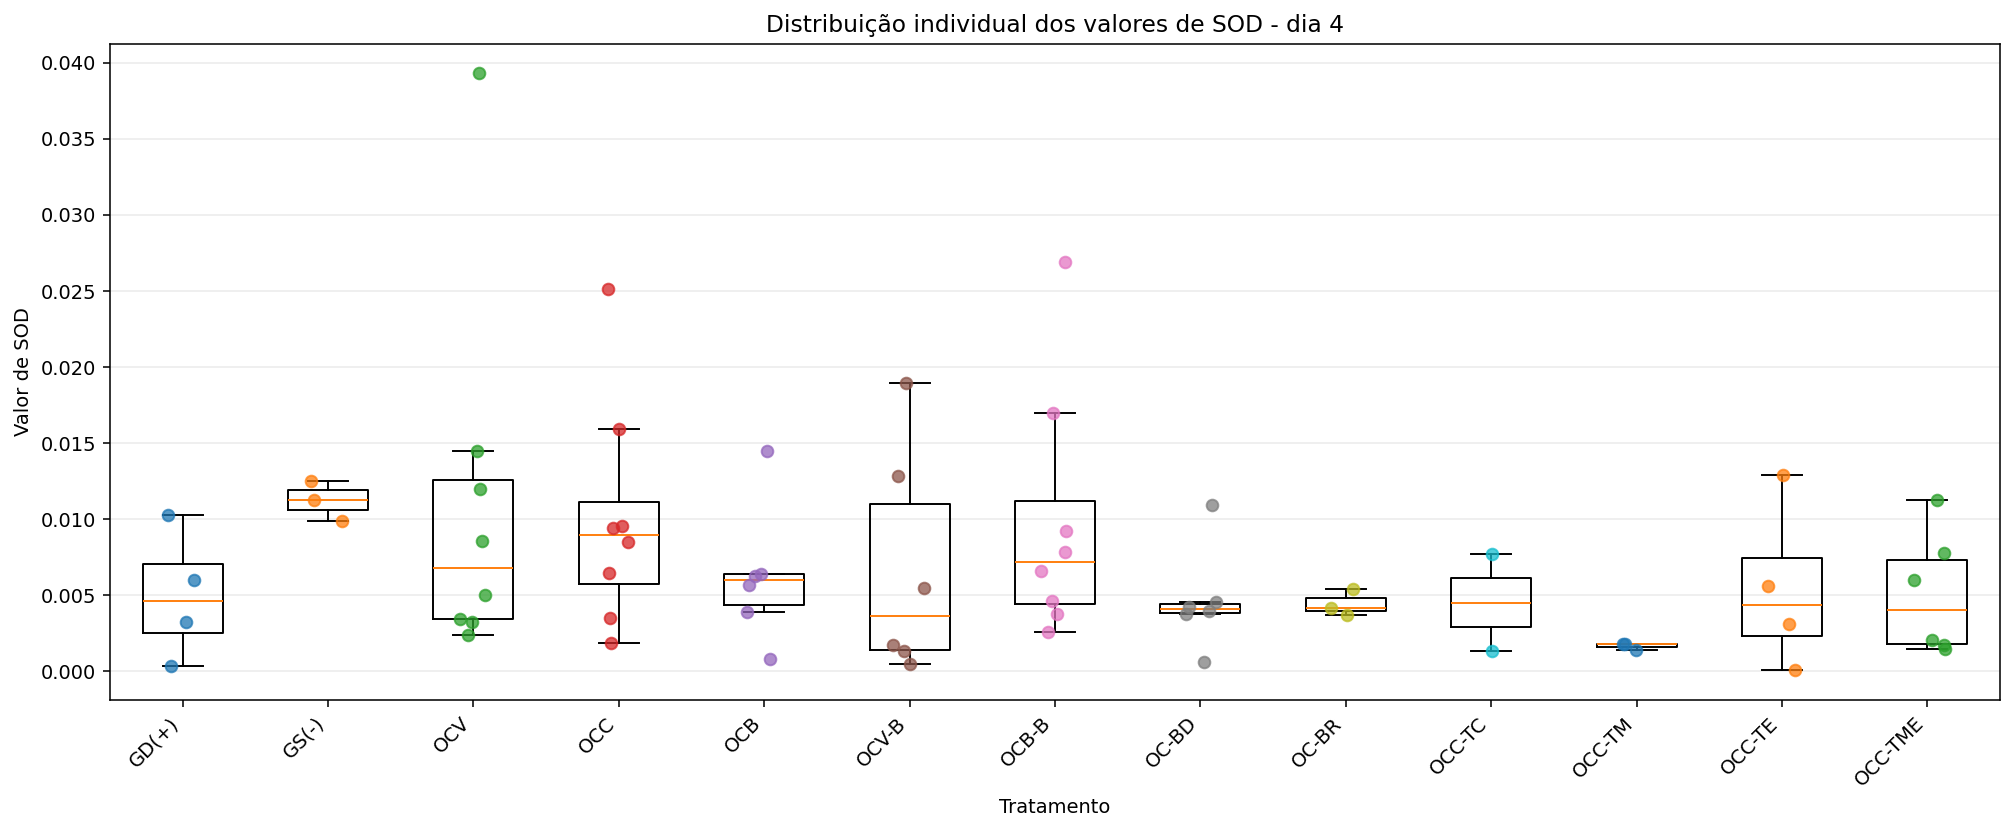

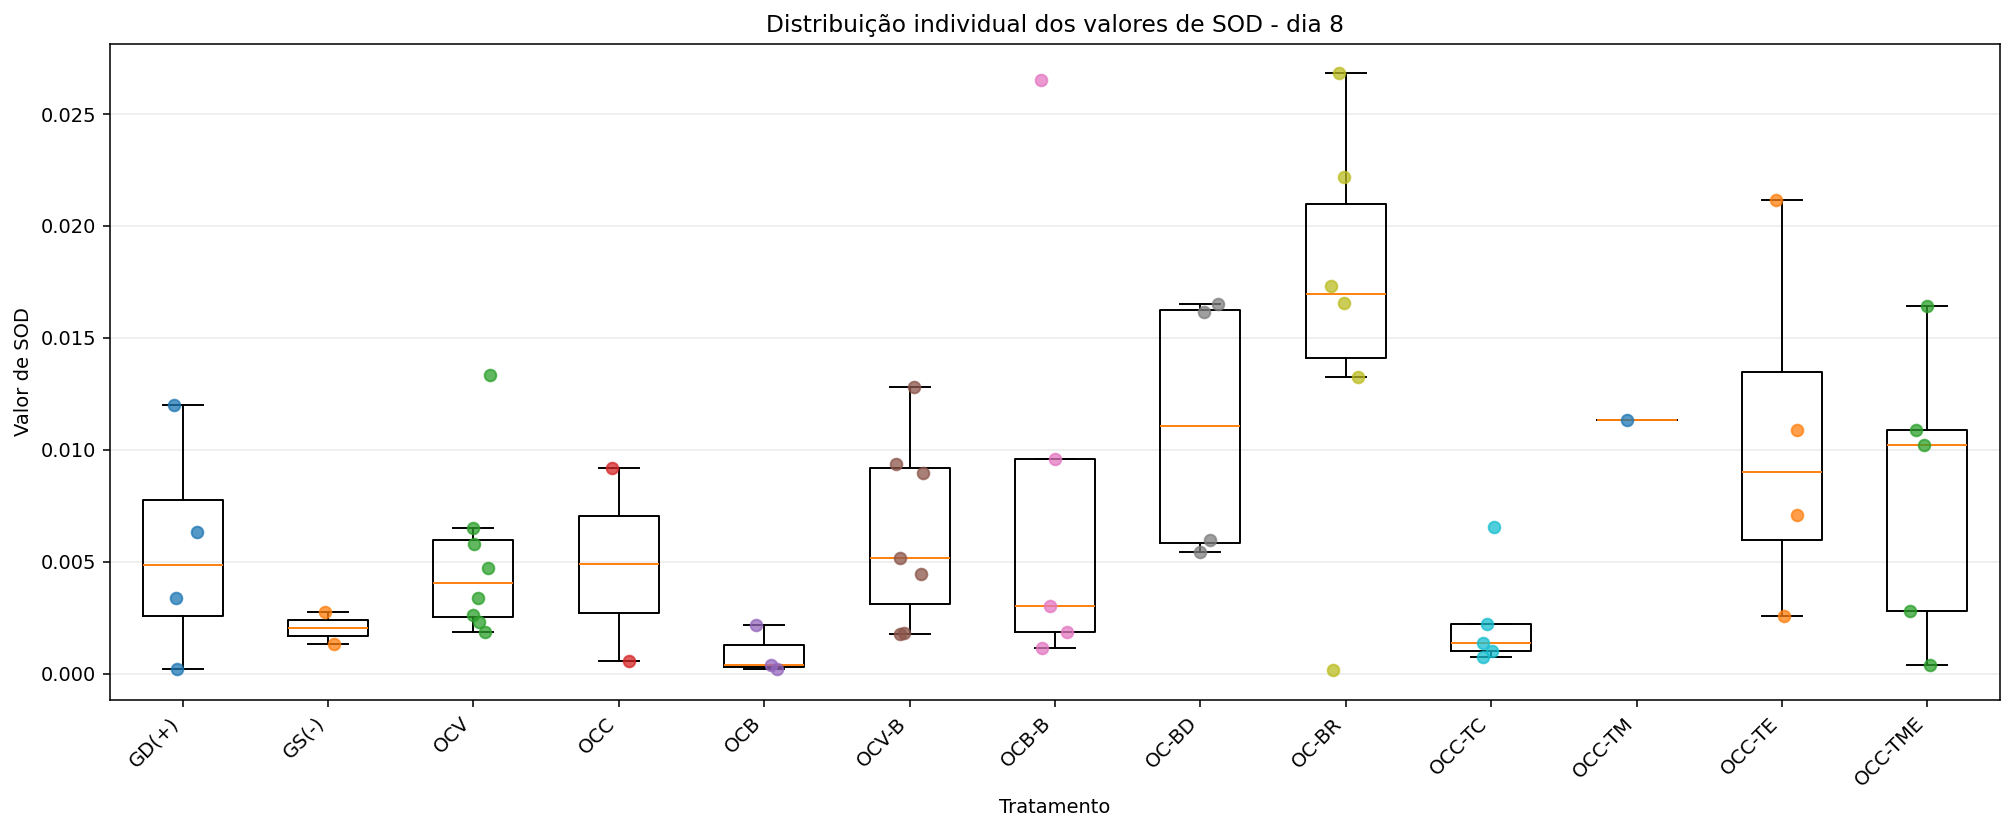


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_descritiva_sod_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_distribuicao_sod_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_sod_dia_8.png


In [38]:
# ETAPA 34 — Análise descritiva e distribuição individual da SOD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "df_sod_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_sod_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 33."
    )

if "tratamentos_sod_esperados" not in globals():
    raise RuntimeError(
        "A lista tratamentos_sod_esperados não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# =========================================================
# 2. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Valor_SOD"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_sod_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes em df_sod_individual_longa: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 3. Preparar uma cópia para a análise descritiva
# =========================================================

dados_sod_descritiva = (
    df_sod_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_sod_descritiva["Tratamento"] = (
    dados_sod_descritiva["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_sod_descritiva["Dia"] = pd.to_numeric(
    dados_sod_descritiva["Dia"],
    errors="coerce"
)

dados_sod_descritiva["Valor_SOD"] = pd.to_numeric(
    dados_sod_descritiva["Valor_SOD"],
    errors="coerce"
)


# =========================================================
# 4. Verificar valores inválidos
# =========================================================

linhas_invalidas = (
    dados_sod_descritiva["Tratamento"].isna()
    | dados_sod_descritiva["Dia"].isna()
    | dados_sod_descritiva["Valor_SOD"].isna()
    | ~np.isfinite(
        dados_sod_descritiva["Valor_SOD"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_sod_descritiva.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de SOD."
    )


# =========================================================
# 5. Verificar dias e tratamentos
# =========================================================

dias_esperados = [
    4,
    8
]

dias_encontrados = sorted(
    dados_sod_descritiva["Dia"]
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:
    raise ValueError(
        "Os dias encontrados não correspondem a 4 e 8: "
        f"{dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_sod_descritiva["Tratamento"]
    .unique()
)

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_sod_esperados)
)

if tratamentos_nao_previstos:
    raise ValueError(
        "Foram encontrados tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 6. Calcular a estatística descritiva
# =========================================================

df_descritiva_sod = (
    dados_sod_descritiva
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_SOD",
            "count"
        ),
        media=(
            "Valor_SOD",
            "mean"
        ),
        desvio_padrao=(
            "Valor_SOD",
            "std"
        ),
        minimo=(
            "Valor_SOD",
            "min"
        ),
        primeiro_quartil=(
            "Valor_SOD",
            lambda valores: valores.quantile(0.25)
        ),
        mediana=(
            "Valor_SOD",
            "median"
        ),
        terceiro_quartil=(
            "Valor_SOD",
            lambda valores: valores.quantile(0.75)
        ),
        maximo=(
            "Valor_SOD",
            "max"
        )
    )
)


# =========================================================
# 7. Completar e ordenar os 13 tratamentos nos dois dias
# =========================================================

indice_completo = pd.MultiIndex.from_product(
    [
        tratamentos_sod_esperados,
        dias_esperados
    ],
    names=[
        "Tratamento",
        "Dia"
    ]
)

df_descritiva_sod = (
    df_descritiva_sod
    .set_index(
        [
            "Tratamento",
            "Dia"
        ]
    )
    .reindex(
        indice_completo
    )
    .reset_index()
)


# =========================================================
# 8. Conferir grupos com amostra muito pequena
# =========================================================

grupos_amostra_pequena = (
    df_descritiva_sod.loc[
        df_descritiva_sod["n"] < 3,
        [
            "Tratamento",
            "Dia",
            "n"
        ]
    ]
    .copy()
)

print("Estatística descritiva da SOD:")

display(
    df_descritiva_sod.round(
        {
            "media": 8,
            "desvio_padrao": 8,
            "minimo": 8,
            "primeiro_quartil": 8,
            "mediana": 8,
            "terceiro_quartil": 8,
            "maximo": 8
        }
    )
)


print("\nGrupos com menos de três observações:")

if grupos_amostra_pequena.empty:

    print(
        "Nenhum grupo possui menos de três observações."
    )

else:

    display(
        grupos_amostra_pequena
    )


# =========================================================
# 9. Criar uma tabela de contagens
# =========================================================

tabela_contagem_sod_descritiva = (
    df_descritiva_sod
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_sod_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)

print("\nNúmero de observações por tratamento:")

display(
    tabela_contagem_sod_descritiva
)


# =========================================================
# 10. Construir os gráficos dos dias 4 e 8
# =========================================================

arquivos_graficos_sod = []

for dia in dias_esperados:

    dados_dia = (
        dados_sod_descritiva.loc[
            dados_sod_descritiva["Dia"] == dia
        ]
        .copy()
    )

    valores_boxplot = []
    posicoes_boxplot = []

    for posicao, tratamento in enumerate(
        tratamentos_sod_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_SOD"
            ]
            .to_numpy(dtype=float)
        )

        if len(valores) > 0:

            valores_boxplot.append(
                valores
            )

            posicoes_boxplot.append(
                posicao
            )


    plt.close("all")

    fig, ax = plt.subplots(
        figsize=(
            15,
            7
        )
    )


    # -----------------------------------------------------
    # Boxplots
    # -----------------------------------------------------
    # showfliers=False evita repetir os valores extremos,
    # pois todos os pontos serão exibidos no gráfico.

    ax.boxplot(
        valores_boxplot,
        positions=posicoes_boxplot,
        widths=0.55,
        showfliers=False
    )


    # -----------------------------------------------------
    # Pontos individuais com deslocamento horizontal
    # -----------------------------------------------------

    gerador_aleatorio = np.random.default_rng(
        20260728 + dia
    )

    for posicao, tratamento in enumerate(
        tratamentos_sod_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_SOD"
            ]
            .to_numpy(dtype=float)
        )

        if len(valores) == 0:
            continue

        deslocamento = gerador_aleatorio.uniform(
            -0.12,
            0.12,
            size=len(valores)
        )

        posicoes_pontos = (
            np.full(
                len(valores),
                posicao,
                dtype=float
            )
            + deslocamento
        )

        ax.scatter(
            posicoes_pontos,
            valores,
            alpha=0.75,
            zorder=3
        )


    # -----------------------------------------------------
    # Formatação
    # -----------------------------------------------------

    ax.set_title(
        f"Distribuição individual dos valores de SOD - dia {dia}"
    )

    ax.set_xlabel(
        "Tratamento"
    )

    ax.set_ylabel(
        "Valor de SOD"
    )

    ax.set_xticks(
        range(
            1,
            len(tratamentos_sod_esperados) + 1
        )
    )

    ax.set_xticklabels(
        tratamentos_sod_esperados,
        rotation=45,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )


    # Evita o uso de tight_layout, que anteriormente
    # causou problemas de renderização no computador antigo.

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.23,
        top=0.90
    )


    # -----------------------------------------------------
    # Salvar e exibir
    # -----------------------------------------------------

    arquivo_grafico = (
        PASTA_PROJETO
        / f"projeto001_distribuicao_sod_dia_{dia}.png"
    )

    fig.canvas.draw()

    fig.savefig(
        arquivo_grafico,
        dpi=300,
        format="png"
    )

    plt.show()

    plt.close(fig)

    arquivos_graficos_sod.append(
        arquivo_grafico
    )


# =========================================================
# 11. Salvar a estatística descritiva
# =========================================================

arquivo_descritiva_sod = (
    PASTA_PROJETO
    / "projeto001_descritiva_sod_dias_4_8.csv"
)

df_descritiva_sod.to_csv(
    arquivo_descritiva_sod,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(arquivo_descritiva_sod)

for arquivo in arquivos_graficos_sod:
    print(arquivo)

## 35. Comparação global da SOD por teste de permutação

A distribuição dos valores individuais de SOD será comparada entre os 13
tratamentos, separadamente nos dias 4 e 8.

Será utilizada a estatística H de Kruskal-Wallis, acompanhada de um valor de
p obtido por permutação aleatória dos tratamentos. O procedimento preserva:

- os tamanhos amostrais originais;
- todos os valores individuais;
- os valores extremos;
- os grupos com tamanhos amostrais desiguais.

Serão realizadas 49.999 permutações em cada dia, com semente fixa para permitir
a reprodução exata da análise.

O grupo OCC-TM possui apenas uma observação no dia 8. Ele será mantido no teste
global, mas essa limitação deverá ser considerada na interpretação. Nenhuma
comparação individual envolvendo esse grupo será realizada enquanto houver
somente uma observação.

O teste global verifica apenas se pelo menos um tratamento difere dos demais.
Ele não identifica quais tratamentos apresentam diferenças.

In [39]:
# ETAPA 35 — Teste global da SOD por permutação
# Estatística H de Kruskal-Wallis com 49.999 permutações

import time
import numpy as np
import pandas as pd

from scipy.stats import kruskal, rankdata
from IPython.display import display


# =========================================================
# 1. Configurações da análise
# =========================================================

NUMERO_PERMUTACOES = 49_999
SEMENTE_PERMUTACAO = 20260728
NIVEL_SIGNIFICANCIA = 0.05


# =========================================================
# 2. Verificações iniciais
# =========================================================

if "df_sod_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_sod_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 33."
    )

if "tratamentos_sod_esperados" not in globals():
    raise RuntimeError(
        "A lista tratamentos_sod_esperados não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Valor_SOD"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_sod_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes na tabela de SOD: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 3. Preparar os dados
# =========================================================

dados_sod_teste = (
    df_sod_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_sod_teste["Tratamento"] = (
    dados_sod_teste["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_sod_teste["Dia"] = pd.to_numeric(
    dados_sod_teste["Dia"],
    errors="coerce"
)

dados_sod_teste["Valor_SOD"] = pd.to_numeric(
    dados_sod_teste["Valor_SOD"],
    errors="coerce"
)


linhas_invalidas = (
    dados_sod_teste["Tratamento"].isna()
    | dados_sod_teste["Dia"].isna()
    | dados_sod_teste["Valor_SOD"].isna()
    | ~np.isfinite(
        dados_sod_teste["Valor_SOD"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_sod_teste.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de SOD."
    )


# =========================================================
# 4. Função para calcular a correção de empates
# =========================================================

def calcular_correcao_empates(valores):

    valores_unicos, contagens = np.unique(
        valores,
        return_counts=True
    )

    contagens_empates = contagens[
        contagens > 1
    ]

    numero_total = len(valores)

    if numero_total < 2:
        raise ValueError(
            "Não há observações suficientes para o teste."
        )

    numerador = np.sum(
        contagens_empates**3
        - contagens_empates
    )

    denominador = (
        numero_total**3
        - numero_total
    )

    correcao = 1.0 - (
        numerador / denominador
    )

    if correcao <= 0:
        raise ValueError(
            "Não foi possível calcular a correção de empates."
        )

    return float(correcao)


# =========================================================
# 5. Função para calcular H a partir dos postos
# =========================================================

def calcular_h_por_postos(
    postos,
    tamanhos_grupos,
    correcao_empates
):

    numero_total = len(postos)

    inicio = 0
    soma_componentes = 0.0

    for tamanho_grupo in tamanhos_grupos:

        final = inicio + tamanho_grupo

        soma_postos_grupo = np.sum(
            postos[inicio:final]
        )

        soma_componentes += (
            soma_postos_grupo**2
            / tamanho_grupo
        )

        inicio = final

    h_sem_correcao = (
        12.0
        / (
            numero_total
            * (numero_total + 1)
        )
        * soma_componentes
        - 3.0
        * (numero_total + 1)
    )

    h_corrigido = (
        h_sem_correcao
        / correcao_empates
    )

    return float(h_corrigido)


# =========================================================
# 6. Executar a análise separadamente por dia
# =========================================================

resultados_permutacao_sod = []
contagens_sod_teste = []

inicio_geral = time.perf_counter()

for dia in [4, 8]:

    print("\n" + "=" * 90)
    print(f"PROCESSANDO DIA {dia}")

    dados_dia = (
        dados_sod_teste.loc[
            dados_sod_teste["Dia"] == dia
        ]
        .copy()
    )

    if dados_dia.empty:
        raise RuntimeError(
            f"Não foram encontrados dados de SOD no dia {dia}."
        )

    grupos = []
    tamanhos_grupos = []

    for tratamento in tratamentos_sod_esperados:

        valores_grupo = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_SOD"
            ]
            .to_numpy(dtype=float)
        )

        numero_observacoes = len(
            valores_grupo
        )

        contagens_sod_teste.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": numero_observacoes
            }
        )

        if numero_observacoes == 0:
            raise ValueError(
                f"O tratamento {tratamento} não possui "
                f"observações no dia {dia}."
            )

        grupos.append(
            valores_grupo
        )

        tamanhos_grupos.append(
            numero_observacoes
        )

    numero_grupos = len(grupos)
    numero_total = sum(tamanhos_grupos)

    valores_concatenados = np.concatenate(
        grupos
    )

    postos = rankdata(
        valores_concatenados,
        method="average"
    )

    correcao_empates = calcular_correcao_empates(
        valores_concatenados
    )

    h_observado = calcular_h_por_postos(
        postos=postos,
        tamanhos_grupos=tamanhos_grupos,
        correcao_empates=correcao_empates
    )


    # -----------------------------------------------------
    # Conferência com o Kruskal-Wallis convencional
    # -----------------------------------------------------

    resultado_kruskal = kruskal(
        *grupos,
        nan_policy="raise"
    )

    h_assintotico = float(
        resultado_kruskal.statistic
    )

    p_assintotico = float(
        resultado_kruskal.pvalue
    )

    if not np.isclose(
        h_observado,
        h_assintotico,
        rtol=1e-10,
        atol=1e-10
    ):
        raise RuntimeError(
            "A estatística H calculada manualmente não "
            "coincide com o resultado do SciPy."
        )


    # -----------------------------------------------------
    # Permutações
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        SEMENTE_PERMUTACAO + dia
    )

    numero_extremos = 0

    inicio_dia = time.perf_counter()

    for _ in range(NUMERO_PERMUTACOES):

        postos_permutados = gerador.permutation(
            postos
        )

        h_permutado = calcular_h_por_postos(
            postos=postos_permutados,
            tamanhos_grupos=tamanhos_grupos,
            correcao_empates=correcao_empates
        )

        if h_permutado >= (
            h_observado - 1e-12
        ):
            numero_extremos += 1


    # Correção de mais um no numerador e denominador
    valor_p_permutacao = (
        numero_extremos + 1
    ) / (
        NUMERO_PERMUTACOES + 1
    )

    erro_padrao_monte_carlo = np.sqrt(
        valor_p_permutacao
        * (
            1.0
            - valor_p_permutacao
        )
        / (
            NUMERO_PERMUTACOES + 1
        )
    )


    # -----------------------------------------------------
    # Tamanho de efeito global
    # -----------------------------------------------------

    denominador_efeito = (
        numero_total
        - numero_grupos
    )

    if denominador_efeito > 0:

        epsilon_quadrado = (
            h_observado
            - numero_grupos
            + 1
        ) / denominador_efeito

        epsilon_quadrado = min(
            1.0,
            max(
                0.0,
                float(epsilon_quadrado)
            )
        )

    else:
        epsilon_quadrado = np.nan


    tempo_dia = (
        time.perf_counter()
        - inicio_dia
    )


    # -----------------------------------------------------
    # Conclusão global
    # -----------------------------------------------------

    if valor_p_permutacao < NIVEL_SIGNIFICANCIA:

        conclusao = (
            "Há evidência de diferença global entre "
            "os tratamentos."
        )

    else:

        conclusao = (
            "Não há evidência de diferença global entre "
            "os tratamentos."
        )


    resultados_permutacao_sod.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Menor_n": min(tamanhos_grupos),
            "Maior_n": max(tamanhos_grupos),
            "Estatistica_H": h_observado,
            "Graus_de_liberdade": numero_grupos - 1,
            "Valor_p_assintotico": p_assintotico,
            "Numero_de_permutacoes": NUMERO_PERMUTACOES,
            "Permutacoes_iguais_ou_maiores": numero_extremos,
            "Valor_p_permutacao": valor_p_permutacao,
            "Erro_padrao_Monte_Carlo": erro_padrao_monte_carlo,
            "Epsilon_quadrado": epsilon_quadrado,
            "Tempo_segundos": tempo_dia,
            "Conclusao_5_percent": conclusao
        }
    )

    print(
        f"H observado: {h_observado:.6f}"
    )

    print(
        f"p assintótico: {p_assintotico:.8f}"
    )

    print(
        f"p por permutação: {valor_p_permutacao:.8f}"
    )

    print(
        f"ε²: {epsilon_quadrado:.4f}"
    )

    print(
        f"Tempo: {tempo_dia:.2f} segundos"
    )

    print(conclusao)


# =========================================================
# 7. Criar as tabelas finais
# =========================================================

df_resultados_permutacao_sod = pd.DataFrame(
    resultados_permutacao_sod
)

df_contagens_sod_teste = pd.DataFrame(
    contagens_sod_teste
)

tabela_contagens_sod_teste = (
    df_contagens_sod_teste
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_sod_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)


# =========================================================
# 8. Mostrar os resultados
# =========================================================

print("\n" + "=" * 90)
print("CONTAGENS UTILIZADAS NO TESTE")

display(
    tabela_contagens_sod_teste
)


print("\nRESULTADOS GLOBAIS DA SOD")

display(
    df_resultados_permutacao_sod.round(
        {
            "Estatistica_H": 6,
            "Valor_p_assintotico": 8,
            "Valor_p_permutacao": 8,
            "Erro_padrao_Monte_Carlo": 8,
            "Epsilon_quadrado": 4,
            "Tempo_segundos": 2
        }
    )
)


tempo_total = (
    time.perf_counter()
    - inicio_geral
)

print(
    f"\nTempo total da Etapa 35: "
    f"{tempo_total:.2f} segundos"
)


# =========================================================
# 9. Salvar os resultados
# =========================================================

arquivo_resultados_permutacao_sod = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_sod.csv"
)

arquivo_contagens_teste_sod = (
    PASTA_PROJETO
    / "projeto001_contagens_teste_global_sod.csv"
)

df_resultados_permutacao_sod.to_csv(
    arquivo_resultados_permutacao_sod,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tabela_contagens_sod_teste.to_csv(
    arquivo_contagens_teste_sod,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_resultados_permutacao_sod
)

print(
    arquivo_contagens_teste_sod
)


PROCESSANDO DIA 4
H observado: 14.268218
p assintótico: 0.28390937
p por permutação: 0.28194000
ε²: 0.0420
Tempo: 2.59 segundos
Não há evidência de diferença global entre os tratamentos.

PROCESSANDO DIA 8
H observado: 18.872637
p assintótico: 0.09164880
p por permutação: 0.06050000
ε²: 0.1598
Tempo: 2.57 segundos
Não há evidência de diferença global entre os tratamentos.

CONTAGENS UTILIZADAS NO TESTE


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),4,4
GS(-),3,2
OCV,8,8
OCC,8,2
OCB,6,3
OCV-B,6,7
OCB-B,8,5
OC-BD,6,4
OC-BR,3,6



RESULTADOS GLOBAIS DA SOD


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Menor_n,Maior_n,Estatistica_H,Graus_de_liberdade,Valor_p_assintotico,Numero_de_permutacoes,Permutacoes_iguais_ou_maiores,Valor_p_permutacao,Erro_padrao_Monte_Carlo,Epsilon_quadrado,Tempo_segundos,Conclusao_5_percent
0,4,13,67,2,8,14.268218,12,0.283909,49999,14096,0.28194,0.002012,0.0420,2.59,Não há evidência de diferença global entre os ...
1,8,13,56,1,8,18.872637,12,0.091649,49999,3024,0.06050,0.001066,0.1598,2.57,Não há evidência de diferença global entre os ...



Tempo total da Etapa 35: 5.19 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_teste_global_permutacao_sod.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_teste_global_sod.csv


## 36. Inspeção da estrutura dos dados de catalase

A estrutura original da aba de catalase será examinada antes da organização
dos dados individuais.

Serão verificados:

- nome exato da aba;
- localização dos 13 tratamentos;
- distribuição dos valores por coluna;
- possíveis blocos referentes aos dias 4 e 8;
- presença de cabeçalhos, médias, desvios-padrão e células vazias.

Nenhum valor será removido, corrigido, imputado ou analisado estatisticamente.

In [40]:
# ETAPA 36 — Inspeção da estrutura da catalase

import re
import unicodedata
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n{ARQUIVO_EXCEL}"
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


# =========================================================
# 2. Funções de normalização
# =========================================================

def normalizar_texto(texto):

    texto = str(texto).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


# =========================================================
# 3. Localizar automaticamente a aba de catalase
# =========================================================

arquivo_excel = pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
)

abas_catalase = [
    nome_aba
    for nome_aba in arquivo_excel.sheet_names
    if "catalase" in normalizar_texto(nome_aba)
]

if len(abas_catalase) == 0:

    print("Abas disponíveis:")

    for nome_aba in arquivo_excel.sheet_names:
        print("-", repr(nome_aba))

    raise RuntimeError(
        "Nenhuma aba relacionada à catalase foi encontrada."
    )

if len(abas_catalase) > 1:

    print("Abas candidatas encontradas:")

    for nome_aba in abas_catalase:
        print("-", repr(nome_aba))

    raise RuntimeError(
        "Foi encontrada mais de uma aba de catalase."
    )

NOME_ABA_CATALASE = abas_catalase[0]

print("Arquivo-base:")
print(ARQUIVO_EXCEL)

print("\nAba de catalase localizada:")
print(repr(NOME_ABA_CATALASE))


# =========================================================
# 4. Ler a planilha sem assumir cabeçalho
# =========================================================

catalase_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_CATALASE,
    header=None,
    engine="openpyxl"
)

print("\nDimensão original:")
print(
    f"{catalase_bruta.shape[0]} linhas × "
    f"{catalase_bruta.shape[1]} colunas"
)


# =========================================================
# 5. Remover somente margens totalmente vazias
# =========================================================

linhas_com_conteudo = (
    catalase_bruta
    .notna()
    .any(axis=1)
)

colunas_com_conteudo = (
    catalase_bruta
    .notna()
    .any(axis=0)
)

catalase_inspecao = catalase_bruta.loc[
    linhas_com_conteudo,
    colunas_com_conteudo
].copy()

catalase_inspecao.index = (
    catalase_inspecao.index + 1
)

catalase_inspecao.index.name = "Linha_Excel"

catalase_inspecao.columns = [
    get_column_letter(
        int(indice_coluna) + 1
    )
    for indice_coluna in catalase_inspecao.columns
]


# =========================================================
# 6. Exibir a estrutura completa
# =========================================================

print("\nEstrutura completa da catalase:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 280,
    "display.max_colwidth", 100
):
    display(
        catalase_inspecao
    )


# =========================================================
# 7. Localizar os 13 tratamentos
# =========================================================

tratamentos_catalase_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

mapa_tratamentos = {
    normalizar_tratamento(tratamento): tratamento
    for tratamento in tratamentos_catalase_esperados
}

ocorrencias_catalase = []

for linha_excel, linha in catalase_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        codigo = normalizar_tratamento(
            valor_original
        )

        if codigo in mapa_tratamentos:

            ocorrencias_catalase.append(
                {
                    "Tratamento": mapa_tratamentos[codigo],
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": coluna_excel,
                    "Valor_original": valor_original
                }
            )

df_ocorrencias_catalase = pd.DataFrame(
    ocorrencias_catalase
)

if df_ocorrencias_catalase.empty:
    raise RuntimeError(
        "Nenhum tratamento foi localizado na aba."
    )

df_ocorrencias_catalase = (
    df_ocorrencias_catalase
    .sort_values(
        [
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(drop=True)
)

print("\nOcorrências dos tratamentos:")

display(
    df_ocorrencias_catalase
)


# =========================================================
# 8. Conferir tratamentos ausentes ou duplicados
# =========================================================

contagem_tratamentos = (
    df_ocorrencias_catalase[
        "Tratamento"
    ]
    .value_counts()
    .reindex(
        tratamentos_catalase_esperados,
        fill_value=0
    )
    .rename("Numero_de_ocorrencias")
    .to_frame()
)

print("\nContagem das ocorrências por tratamento:")

display(
    contagem_tratamentos
)

tratamentos_ausentes = (
    contagem_tratamentos.loc[
        contagem_tratamentos[
            "Numero_de_ocorrencias"
        ] == 0
    ]
    .index
    .tolist()
)

if tratamentos_ausentes:
    print("\nTratamentos não localizados:")
    print(tratamentos_ausentes)
else:
    print("\nTodos os 13 tratamentos foram localizados.")


# =========================================================
# 9. Contar valores numéricos por coluna
# =========================================================

registros_contagem = []

for coluna in catalase_inspecao.columns:

    valores_numericos = pd.to_numeric(
        catalase_inspecao[coluna],
        errors="coerce"
    )

    registros_contagem.append(
        {
            "Coluna_Excel": coluna,
            "Valores_numericos": int(
                valores_numericos.notna().sum()
            ),
            "Celulas_com_conteudo": int(
                catalase_inspecao[coluna]
                .notna()
                .sum()
            )
        }
    )

df_contagem_numerica_catalase = pd.DataFrame(
    registros_contagem
)

print("\nContagem de valores por coluna:")

display(
    df_contagem_numerica_catalase
)


# =========================================================
# 10. Salvar os arquivos de inspeção
# =========================================================

arquivo_inspecao_catalase = (
    PASTA_PROJETO
    / "projeto001_inspecao_bruta_catalase.csv"
)

arquivo_ocorrencias_catalase = (
    PASTA_PROJETO
    / "projeto001_ocorrencias_tratamentos_catalase.csv"
)

catalase_inspecao.to_csv(
    arquivo_inspecao_catalase,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

df_ocorrencias_catalase.to_csv(
    arquivo_ocorrencias_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

print("\nArquivos salvos:")

print(arquivo_inspecao_catalase)
print(arquivo_ocorrencias_catalase)

Arquivo-base:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba de catalase localizada:
'Estr. Oxid. (Catalase)'

Dimensão original:
15 linhas × 19 colunas

Estrutura completa da catalase:


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S
Linha_Excel,,,,,,,,,,,,,,,,,,,
1,Teste Catalase,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GD(+),1574.879,867.8353,373.5383,596.6344,603.7001,NaN,NaN,NaN,NaN,185.876,811.8020,899.3966,1798.3990,1543.7370,726.19530,NaN,NaN,NaN
4,GS(-),771.8181,773.5234,1321.0690,1219.1580,1354.9550,NaN,NaN,NaN,NaN,518.0588,1843.1670,1016.2910,753.9685,NaN,NaN,NaN,NaN,NaN
5,OCV,763.3318,637.5408,678.9941,550.0850,1863.2390,2430.3200,1001.1800,643.2023,NaN,333.2259,969.6522,699.7080,1248.6890,359.8119,1020.33400,628.2607,476.12400,NaN
6,OCC,652.9799,986.6592,689.3099,741.3330,791.6008,981.8531,1045.0770,990.2242,728.0606,642.7517,473.3303,465.1609,623.1430,429.5772,1711.86400,301.0406,NaN,NaN
7,OCB,922.6148,1353.5740,1291.0220,1567.2890,144.1691,300.7711,960.0785,954.3152,NaN,1156.923,567.3301,967.3077,396.6082,460.3179,NaN,NaN,NaN,NaN
8,OCV-B,1151.247,1029.4280,643.5137,596.0813,431.0551,523.4182,1045.4710,NaN,NaN,281.3291,1001.2340,609.4714,735.3319,324.1298,710.16990,1093.2360,NaN,NaN
9,OCB-B,1415.788,1024.5480,883.7930,918.3107,950.8079,1204.0750,1253.6070,1160.5780,2275.0040,553.8329,264.0064,762.3641,357.1962,571.2435,NaN,NaN,NaN,NaN



Ocorrências dos tratamentos:


,Tratamento,Linha_Excel,Coluna_Excel,Valor_original
0,GD(+),3,A,GD(+)
1,GS(-),4,A,GS(-)
2,OCV,5,A,OCV
3,OCC,6,A,OCC
4,OCB,7,A,OCB
5,OCV-B,8,A,OCV-B
6,OCB-B,9,A,OCB-B
7,OC-BD,10,A,OC-BD
8,OC-BR,11,A,OC-BR
9,OCC-TC,12,A,OCC-TC



Contagem das ocorrências por tratamento:


,Numero_de_ocorrencias
Tratamento,
GD(+),1
GS(-),1
OCV,1
OCC,1
OCB,1
OCV-B,1
OCB-B,1
OC-BD,1
OC-BR,1



Todos os 13 tratamentos foram localizados.

Contagem de valores por coluna:


,Coluna_Excel,Valores_numericos,Celulas_com_conteudo
0,A,0,15
1,B,13,14
2,C,13,13
3,D,13,13
4,E,13,13
5,F,13,13
6,G,9,9
7,H,8,8
8,I,6,6
9,J,3,3



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_inspecao_bruta_catalase.csv
/kaggle/working/projeto001_resultados/projeto001_ocorrencias_tratamentos_catalase.csv


## 37. Organização dos dados individuais de catalase após auditoria

A inspeção confirmou a seguinte estrutura:

- dia 4: colunas B a J;
- dia 8: colunas K a S.

Dois valores extremos foram excluídos da base analítica por decisão do
pesquisador:

- OCC-TM, dia 4, célula G13: 26.567,38;
- OC-BR, dia 8, célula L11: 27.704,77.

Após essas exclusões, são esperadas 90 observações no dia 4 e 77 observações
no dia 8.

A base original deverá permanecer preservada. Nenhum outro valor será
excluído ou imputado nesta etapa.

In [41]:
# =========================================================
# ETAPA 37 — Organização definitiva dos dados individuais
# de catalase
#
# Estrutura confirmada:
# Dia 4 = B:J
# Dia 8 = K:S
#
# Exclusões previamente definidas:
# G13 = 26567,38
# L11 = 27704,77
#
# Totais esperados APÓS exclusões:
# Dia 4 = 90 observações
# Dia 8 = 77 observações
#
# IMPORTANTE:
# A planilha original NÃO é modificada.
# Os outliers são excluídos somente da base analítica.
# =========================================================

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import (
    get_column_letter,
    column_index_from_string
)

from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():

    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )


if "PASTA_PROJETO" not in globals():

    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )


ARQUIVO_EXCEL = Path(
    ARQUIVO_EXCEL
)

PASTA_PROJETO = Path(
    PASTA_PROJETO
)


if not ARQUIVO_EXCEL.exists():

    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n"
        f"{ARQUIVO_EXCEL}"
    )


PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Tratamentos esperados
# =========================================================

tratamentos_catalase_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 3. Registro formal das exclusões
# =========================================================

df_exclusoes_catalase = pd.DataFrame(
    [
        {
            "Tratamento": "OCC-TM",
            "Dia": 4,
            "Celula_Excel": "G13",
            "Valor_original": 26567.38,
            "Motivo": (
                "Outlier extremo excluído por decisão "
                "do pesquisador."
            ),
            "Status": "Excluído da base analítica"
        },

        {
            "Tratamento": "OC-BR",
            "Dia": 8,
            "Celula_Excel": "L11",
            "Valor_original": 27704.77,
            "Motivo": (
                "Outlier extremo excluído por decisão "
                "do pesquisador."
            ),
            "Status": "Excluído da base analítica"
        }
    ]
)


# Garantir que não existem exclusões duplicadas

if df_exclusoes_catalase[
    "Celula_Excel"
].duplicated().any():

    raise ValueError(
        "Existem células duplicadas no registro "
        "de exclusões da catalase."
    )


CELULAS_EXCLUIDAS = set(
    df_exclusoes_catalase[
        "Celula_Excel"
    ].tolist()
)


print(
    "Células previamente definidas para exclusão:"
)

print(
    sorted(
        CELULAS_EXCLUIDAS
    )
)


# =========================================================
# 4. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(
        valor
    ).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(
            caractere
        )
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(
        valor
    ).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(
            caractere
        )
    )

    texto = re.sub(
        r"\s+",
        "",
        texto
    )

    return texto


def converter_valor_catalase(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):

        return float(
            valor
        )

    texto = str(
        valor
    ).strip()

    if texto == "":
        return np.nan

    # Formato brasileiro:
    # 1.234,56

    if "," in texto and "." in texto:

        if texto.rfind(
            ","
        ) > texto.rfind(
            "."
        ):

            texto = texto.replace(
                ".",
                ""
            )

            texto = texto.replace(
                ",",
                "."
            )

        # Formato internacional:
        # 1,234.56

        else:

            texto = texto.replace(
                ",",
                ""
            )

    elif "," in texto:

        texto = texto.replace(
            ",",
            "."
        )

    try:

        return float(
            texto
        )

    except ValueError as erro:

        raise ValueError(
            "Valor não numérico encontrado "
            "na catalase: "
            f"{valor!r}"
        ) from erro


# =========================================================
# 5. Localizar automaticamente a aba de catalase
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    abas_catalase = [
        nome_aba

        for nome_aba
        in arquivo_excel.sheet_names

        if "catalase"
        in normalizar_texto(
            nome_aba
        )
    ]


if len(
    abas_catalase
) != 1:

    raise RuntimeError(
        "Era esperada exatamente uma aba "
        "de catalase. "
        f"Abas localizadas: {abas_catalase}"
    )


NOME_ABA_CATALASE = (
    abas_catalase[0]
)


print(
    "Arquivo utilizado:"
)

print(
    ARQUIVO_EXCEL
)


print(
    "\nAba localizada:"
)

print(
    repr(
        NOME_ABA_CATALASE
    )
)


# =========================================================
# 6. Ler a aba SEM modificar o arquivo original
# =========================================================

catalase_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_CATALASE,
    header=None,
    engine="openpyxl"
)


print(
    "\nDimensão da aba:"
)

print(
    f"{catalase_bruta.shape[0]} linhas × "
    f"{catalase_bruta.shape[1]} colunas"
)


if catalase_bruta.shape[1] < 19:

    raise ValueError(
        "A aba deveria alcançar pelo menos "
        "a coluna S, "
        f"mas possui somente "
        f"{catalase_bruta.shape[1]} colunas."
    )


# =========================================================
# 7. CONFIRMAR OS VALORES ORIGINAIS DOS OUTLIERS
#
# IMPORTANTE:
# Aqui NÃO se exige que as células estejam vazias.
#
# O objetivo é confirmar que a planilha original contém
# exatamente os valores que foram previamente identificados
# para exclusão.
# =========================================================

for _, exclusao in (
    df_exclusoes_catalase.iterrows()
):

    celula = exclusao[
        "Celula_Excel"
    ]

    correspondencia = re.fullmatch(
        r"([A-Z]+)(\d+)",
        celula
    )


    if correspondencia is None:

        raise ValueError(
            f"Referência de célula inválida: "
            f"{celula}"
        )


    letra_coluna = (
        correspondencia.group(
            1
        )
    )


    linha_excel = int(
        correspondencia.group(
            2
        )
    )


    indice_linha = (
        linha_excel - 1
    )


    indice_coluna = (
        column_index_from_string(
            letra_coluna
        )
        - 1
    )


    valor_atual = (
        catalase_bruta.iat[
            indice_linha,
            indice_coluna
        ]
    )


    valor_atual_num = (
        converter_valor_catalase(
            valor_atual
        )
    )


    valor_esperado = float(
        exclusao[
            "Valor_original"
        ]
    )


    # A célula não deve estar vazia:
    # queremos confirmar o dado bruto original.

    if pd.isna(
        valor_atual_num
    ):

        raise ValueError(
            f"A célula {celula} está vazia, "
            "mas deveria conter o valor "
            f"original {valor_esperado}."
        )


    # Confirmar que é exatamente o valor
    # previamente documentado.

    if not np.isclose(
        valor_atual_num,
        valor_esperado,
        rtol=0,
        atol=1e-6
    ):

        raise ValueError(
            f"Valor inesperado em {celula}: "
            f"{valor_atual_num}. "
            f"Esperado: {valor_esperado}."
        )


print(
    "\nValores originais dos outliers "
    "confirmados na planilha:"
)

for _, exclusao in (
    df_exclusoes_catalase.iterrows()
):

    print(
        f"{exclusao['Celula_Excel']} = "
        f"{exclusao['Valor_original']}"
    )


print(
    "\nA planilha original será preservada."
)

print(
    "As duas observações serão excluídas "
    "somente da base analítica."
)


# =========================================================
# 8. Localizar as linhas dos 13 tratamentos
# =========================================================

mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento

    for tratamento
    in tratamentos_catalase_esperados
}


registros_linhas = []


for indice_linha in range(
    catalase_bruta.shape[0]
):

    codigo = normalizar_tratamento(
        catalase_bruta.iat[
            indice_linha,
            0
        ]
    )


    if codigo in mapa_tratamentos:

        registros_linhas.append(
            {
                "Indice_pandas":
                    indice_linha,

                "Linha_Excel":
                    indice_linha + 1,

                "Tratamento":
                    mapa_tratamentos[
                        codigo
                    ]
            }
        )


df_linhas_catalase = pd.DataFrame(
    registros_linhas
)


if len(
    df_linhas_catalase
) != 13:

    raise ValueError(
        "Foram esperadas 13 linhas "
        "de tratamentos, "
        f"mas foram encontradas "
        f"{len(df_linhas_catalase)}."
    )


if df_linhas_catalase[
    "Tratamento"
].duplicated().any():

    duplicados = (
        df_linhas_catalase.loc[
            df_linhas_catalase[
                "Tratamento"
            ].duplicated(
                keep=False
            ),
            "Tratamento"
        ]
        .tolist()
    )


    raise ValueError(
        f"Tratamentos duplicados: "
        f"{duplicados}"
    )


tratamentos_encontrados = set(
    df_linhas_catalase[
        "Tratamento"
    ]
)


tratamentos_ausentes = [
    tratamento

    for tratamento
    in tratamentos_catalase_esperados

    if tratamento
    not in tratamentos_encontrados
]


if tratamentos_ausentes:

    raise ValueError(
        f"Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )


# =========================================================
# 9. Localizar automaticamente os cabeçalhos dos dias
# =========================================================

posicoes_dia_4 = []
posicoes_dia_8 = []


for indice_linha in range(
    catalase_bruta.shape[0]
):

    for indice_coluna in range(
        catalase_bruta.shape[1]
    ):

        texto = normalizar_texto(
            catalase_bruta.iat[
                indice_linha,
                indice_coluna
            ]
        )


        if texto == "dia4":

            posicoes_dia_4.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )


        elif texto == "dia8":

            posicoes_dia_8.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )


if len(
    posicoes_dia_4
) != 1:

    raise ValueError(
        "Não foi localizada exatamente "
        "uma célula com Dia 4: "
        f"{posicoes_dia_4}"
    )


if len(
    posicoes_dia_8
) != 1:

    raise ValueError(
        "Não foi localizada exatamente "
        "uma célula com Dia 8: "
        f"{posicoes_dia_8}"
    )


linha_dia_4, coluna_inicio_dia_4 = (
    posicoes_dia_4[0]
)


linha_dia_8, coluna_inicio_dia_8 = (
    posicoes_dia_8[0]
)


if linha_dia_4 != linha_dia_8:

    raise ValueError(
        "Os cabeçalhos Dia 4 e Dia 8 "
        "não estão na mesma linha."
    )


# =========================================================
# 10. Determinar automaticamente os blocos
# =========================================================

# Dia 4 começa no cabeçalho Dia 4
# e termina antes do cabeçalho Dia 8.

colunas_dia_4 = list(
    range(
        coluna_inicio_dia_4,
        coluna_inicio_dia_8
    )
)


# Dia 8 começa no cabeçalho Dia 8
# e termina na última coluna que possui
# algum valor nas linhas dos tratamentos.

indices_linhas_tratamentos = (
    df_linhas_catalase[
        "Indice_pandas"
    ]
    .astype(
        int
    )
    .tolist()
)


colunas_dia_8_com_dados = []


for indice_coluna in range(
    coluna_inicio_dia_8,
    catalase_bruta.shape[1]
):

    existe_dado = (
        catalase_bruta.iloc[
            indices_linhas_tratamentos,
            indice_coluna
        ]
        .notna()
        .any()
    )


    if existe_dado:

        colunas_dia_8_com_dados.append(
            indice_coluna
        )


if not colunas_dia_8_com_dados:

    raise ValueError(
        "Nenhuma coluna com dados foi "
        "localizada no bloco do dia 8."
    )


ultima_coluna_dia_8 = max(
    colunas_dia_8_com_dados
)


colunas_dia_8 = list(
    range(
        coluna_inicio_dia_8,
        ultima_coluna_dia_8 + 1
    )
)


inicio_dia_4 = get_column_letter(
    colunas_dia_4[0] + 1
)


fim_dia_4 = get_column_letter(
    colunas_dia_4[-1] + 1
)


inicio_dia_8 = get_column_letter(
    colunas_dia_8[0] + 1
)


fim_dia_8 = get_column_letter(
    colunas_dia_8[-1] + 1
)


print(
    "\nBloco identificado para o dia 4:"
)

print(
    f"{inicio_dia_4}:{fim_dia_4}"
)


print(
    "\nBloco identificado para o dia 8:"
)

print(
    f"{inicio_dia_8}:{fim_dia_8}"
)


# Estrutura confirmada no estudo

if (
    inicio_dia_4 != "B"
    or fim_dia_4 != "J"
    or inicio_dia_8 != "K"
    or fim_dia_8 != "S"
):

    raise ValueError(
        "A estrutura localizada não corresponde "
        "à estrutura confirmada B:J e K:S."
    )


# =========================================================
# 11. Organizar os dados em formato longo
#
# AQUI ocorre efetivamente a exclusão dos outliers.
# =========================================================

blocos_catalase = {
    4: colunas_dia_4,
    8: colunas_dia_8
}


registros_catalase = []


# Servirá para confirmar que as duas células
# realmente foram encontradas e retiradas.

celulas_excluidas_encontradas = set()


for _, identificacao in (
    df_linhas_catalase.iterrows()
):

    indice_linha = int(
        identificacao[
            "Indice_pandas"
        ]
    )


    linha_excel = int(
        identificacao[
            "Linha_Excel"
        ]
    )


    tratamento = identificacao[
        "Tratamento"
    ]


    for dia, indices_colunas in (
        blocos_catalase.items()
    ):

        ordem_observacao = 0


        for (
            posicao_bloco,
            indice_coluna
        ) in enumerate(
            indices_colunas,
            start=1
        ):

            coluna_excel = (
                get_column_letter(
                    indice_coluna + 1
                )
            )


            celula_excel = (
                f"{coluna_excel}"
                f"{linha_excel}"
            )


            # ---------------------------------------------
            # EXCLUSÃO DOS OUTLIERS
            #
            # G13 e L11 permanecem na planilha original,
            # mas NÃO entram na base analítica.
            # ---------------------------------------------

            if (
                celula_excel
                in CELULAS_EXCLUIDAS
            ):

                celulas_excluidas_encontradas.add(
                    celula_excel
                )

                continue


            valor_original = (
                catalase_bruta.iat[
                    indice_linha,
                    indice_coluna
                ]
            )


            valor_catalase = (
                converter_valor_catalase(
                    valor_original
                )
            )


            if pd.isna(
                valor_catalase
            ):

                continue


            ordem_observacao += 1


            registros_catalase.append(
                {
                    "Tratamento":
                        tratamento,

                    "Dia":
                        dia,

                    "Ordem_observacao":
                        ordem_observacao,

                    "Posicao_original_no_bloco":
                        posicao_bloco,

                    "Linha_Excel":
                        linha_excel,

                    "Coluna_Excel":
                        coluna_excel,

                    "Valor_Catalase":
                        valor_catalase
                }
            )


# Confirmar que as duas exclusões previstas
# foram efetivamente encontradas no percurso.

if (
    celulas_excluidas_encontradas
    != CELULAS_EXCLUIDAS
):

    faltantes = (
        CELULAS_EXCLUIDAS
        - celulas_excluidas_encontradas
    )

    excedentes = (
        celulas_excluidas_encontradas
        - CELULAS_EXCLUIDAS
    )

    raise RuntimeError(
        "As exclusões previstas não foram "
        "aplicadas corretamente.\n"
        f"Não encontradas: {sorted(faltantes)}\n"
        f"Inesperadas: {sorted(excedentes)}"
    )


print(
    "\nOutliers efetivamente excluídos "
    "da base analítica:"
)

print(
    sorted(
        celulas_excluidas_encontradas
    )
)


df_catalase_individual_longa = (
    pd.DataFrame(
        registros_catalase
    )
)


# =========================================================
# 12. Validar a tabela organizada
# =========================================================

if df_catalase_individual_longa.empty:

    raise RuntimeError(
        "Nenhum valor de catalase "
        "foi organizado."
    )


if df_catalase_individual_longa[
    "Valor_Catalase"
].isna().any():

    raise ValueError(
        "A tabela contém valores "
        "ausentes inesperados."
    )


if not np.isfinite(
    df_catalase_individual_longa[
        "Valor_Catalase"
    ]
).all():

    raise ValueError(
        "A tabela contém valores infinitos."
    )


duplicatas = (
    df_catalase_individual_longa
    .duplicated(
        subset=[
            "Tratamento",
            "Dia",
            "Linha_Excel",
            "Coluna_Excel"
        ],
        keep=False
    )
)


if duplicatas.any():

    display(
        df_catalase_individual_longa.loc[
            duplicatas
        ]
    )


    raise ValueError(
        "Foram encontradas posições duplicadas."
    )


# Confirmação adicional:
# nenhuma célula excluída pode estar presente
# na base analítica.

celulas_base_analitica = set(
    (
        df_catalase_individual_longa[
            "Coluna_Excel"
        ].astype(str)
        +
        df_catalase_individual_longa[
            "Linha_Excel"
        ].astype(str)
    )
)


intersecao_outliers = (
    celulas_base_analitica
    &
    CELULAS_EXCLUIDAS
)


if intersecao_outliers:

    raise RuntimeError(
        "Outlier encontrado indevidamente "
        "na base analítica: "
        f"{sorted(intersecao_outliers)}"
    )


print(
    "\nValidação concluída:"
)

print(
    "G13 presente na base analítica?",
    "G13" in celulas_base_analitica
)

print(
    "L11 presente na base analítica?",
    "L11" in celulas_base_analitica
)


# =========================================================
# 13. Calcular as contagens
# =========================================================

df_contagem_catalase = (
    df_catalase_individual_longa
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_Catalase",
            "count"
        )
    )
)


tabela_contagem_catalase = (
    df_contagem_catalase
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_catalase_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(
        0
    )
    .astype(
        int
    )
)


# =========================================================
# 14. Validar as contagens por tratamento
# =========================================================

contagens_esperadas = pd.DataFrame(
    {
        "n_Dia_4": [
            5,  # GD(+)
            5,  # GS(-)
            8,  # OCV
            9,  # OCC
            8,  # OCB
            7,  # OCV-B
            9,  # OCB-B
            9,  # OC-BD
            5,  # OC-BR
            5,  # OCC-TC

            # após exclusão de G13
            6,  # OCC-TM

            8,  # OCC-TE
            6   # OCC-TME
        ],

        "n_Dia_8": [
            6,  # GD(+)
            4,  # GS(-)
            8,  # OCV
            7,  # OCC
            5,  # OCB
            7,  # OCV-B
            5,  # OCB-B

            # incluindo S10
            9,  # OC-BD

            # após exclusão de L11
            5,  # OC-BR

            6,  # OCC-TC
            4,  # OCC-TM
            6,  # OCC-TE
            5   # OCC-TME
        ]
    },

    index=(
        tratamentos_catalase_esperados
    ),

    dtype=int
)


if (
    tabela_contagem_catalase
    .index
    .tolist()
    !=
    contagens_esperadas
    .index
    .tolist()
):

    raise ValueError(
        "A ordem dos tratamentos não coincide "
        "com a ordem esperada."
    )


if (
    tabela_contagem_catalase
    .columns
    .tolist()
    !=
    contagens_esperadas
    .columns
    .tolist()
):

    raise ValueError(
        "As colunas de contagem não coincidem "
        "com as colunas esperadas."
    )


if not np.array_equal(
    tabela_contagem_catalase.to_numpy(),
    contagens_esperadas.to_numpy()
):

    print(
        "Contagens encontradas:"
    )

    display(
        tabela_contagem_catalase
    )


    print(
        "\nContagens esperadas:"
    )

    display(
        contagens_esperadas
    )


    raise ValueError(
        "As contagens não coincidem com "
        "a base de catalase auditada."
    )


# =========================================================
# 15. Validar os totais
# =========================================================

total_dia_4 = int(
    tabela_contagem_catalase[
        "n_Dia_4"
    ].sum()
)


total_dia_8 = int(
    tabela_contagem_catalase[
        "n_Dia_8"
    ].sum()
)


if total_dia_4 != 90:

    raise ValueError(
        "Esperadas 90 observações "
        "no dia 4; "
        f"encontradas {total_dia_4}."
    )


if total_dia_8 != 77:

    raise ValueError(
        "Esperadas 77 observações "
        "no dia 8; "
        f"encontradas {total_dia_8}."
    )


# =========================================================
# 16. Exibir os resultados
# =========================================================

print(
    "\nExclusões documentadas:"
)

display(
    df_exclusoes_catalase
)


print(
    "\nContagens após as exclusões:"
)

display(
    tabela_contagem_catalase
)


print(
    "\nTotal de observações no dia 4:"
)

print(
    total_dia_4
)


print(
    "\nTotal de observações no dia 8:"
)

print(
    total_dia_8
)


print(
    "\nPrimeiras observações organizadas:"
)

display(
    df_catalase_individual_longa.head(
        20
    )
)


print(
    "\nDez maiores valores atualmente preservados:"
)

display(
    df_catalase_individual_longa
    .nlargest(
        10,
        "Valor_Catalase"
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 17. Salvar os resultados
# =========================================================

arquivo_catalase_longo = (
    PASTA_PROJETO
    /
    "projeto001_catalase_individual_formato_longo.csv"
)


arquivo_contagem_catalase = (
    PASTA_PROJETO
    /
    "projeto001_contagem_observacoes_catalase.csv"
)


arquivo_exclusoes_catalase = (
    PASTA_PROJETO
    /
    "projeto001_registro_exclusoes_catalase.csv"
)


df_catalase_individual_longa.to_csv(
    arquivo_catalase_longo,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagem_catalase.to_csv(
    arquivo_contagem_catalase,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


df_exclusoes_catalase.to_csv(
    arquivo_exclusoes_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nArquivos salvos:"
)

print(
    arquivo_catalase_longo
)

print(
    arquivo_contagem_catalase
)

print(
    arquivo_exclusoes_catalase
)


# =========================================================
# 18. Resumo final da auditoria
# =========================================================

print(
    "\n"
    + "=" * 80
)

print(
    "ETAPA 37 CONCLUÍDA"
)

print(
    "=" * 80
)


print(
    "\nPlanilha original modificada: NÃO"
)

print(
    "Outliers excluídos somente da base analítica:"
)

print(
    sorted(
        CELULAS_EXCLUIDAS
    )
)


print(
    "\nOutliers presentes na base analítica:"
)

print(
    sorted(
        intersecao_outliers
    )
)


print(
    "\nTotal Dia 4:",
    total_dia_4
)

print(
    "Total Dia 8:",
    total_dia_8
)

Células previamente definidas para exclusão:
['G13', 'L11']
Arquivo utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba localizada:
'Estr. Oxid. (Catalase)'

Dimensão da aba:
15 linhas × 19 colunas

Valores originais dos outliers confirmados na planilha:
G13 = 26567.38
L11 = 27704.77

A planilha original será preservada.
As duas observações serão excluídas somente da base analítica.

Bloco identificado para o dia 4:
B:J

Bloco identificado para o dia 8:
K:S

Outliers efetivamente excluídos da base analítica:
['G13', 'L11']

Validação concluída:
G13 presente na base analítica? False
L11 presente na base analítica? False

Exclusões documentadas:


,Tratamento,Dia,Celula_Excel,Valor_original,Motivo,Status
0,OCC-TM,4,G13,26567.38,Outlier extremo excluído por decisão do pesqui...,Excluído da base analítica
1,OC-BR,8,L11,27704.77,Outlier extremo excluído por decisão do pesqui...,Excluído da base analítica



Contagens após as exclusões:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



Total de observações no dia 4:
90

Total de observações no dia 8:
77

Primeiras observações organizadas:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Valor_Catalase
0,GD(+),4,1,1,3,B,1574.8790
1,GD(+),4,2,2,3,C,867.8353
2,GD(+),4,3,3,3,D,373.5383
3,GD(+),4,4,4,3,E,596.6344
4,GD(+),4,5,5,3,F,603.7001
5,GD(+),8,1,1,3,K,185.8760
6,GD(+),8,2,2,3,L,811.8020
7,GD(+),8,3,3,3,M,899.3966
8,GD(+),8,4,4,3,N,1798.3990
9,GD(+),8,5,5,3,O,1543.7370



Dez maiores valores atualmente preservados:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Valor_Catalase
0,OCV,4,6,6,5,G,2430.320
1,OCB-B,4,9,9,9,J,2275.004
2,OCC-TC,4,3,3,12,D,1967.630
3,OCC-TM,4,4,4,13,E,1952.020
4,OCV,4,5,5,5,F,1863.239
5,GS(-),8,2,2,4,L,1843.167
6,GD(+),8,4,4,3,N,1798.399
7,OCC,8,6,6,6,P,1711.864
8,OC-BR,4,2,2,11,C,1643.582
9,OC-BD,4,5,5,10,F,1613.009



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_catalase_individual_formato_longo.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_observacoes_catalase.csv
/kaggle/working/projeto001_resultados/projeto001_registro_exclusoes_catalase.csv

ETAPA 37 CONCLUÍDA

Planilha original modificada: NÃO
Outliers excluídos somente da base analítica:
['G13', 'L11']

Outliers presentes na base analítica:
[]

Total Dia 4: 90
Total Dia 8: 77


## 38. Análise descritiva e distribuição individual da catalase

Os valores individuais de catalase serão descritos separadamente para os dias
4 e 8, após as duas exclusões previamente registradas.

Para cada tratamento serão apresentados:

- número de observações;
- média e desvio-padrão;
- mínimo e máximo;
- primeiro e terceiro quartis;
- mediana;
- intervalo interquartil.

Também serão produzidos dois gráficos independentes, um para cada dia, contendo
boxplots e todas as observações individuais sobrepostas.

Os gráficos serão construídos com os valores originais da catalase. Nenhuma
transformação, imputação ou exclusão adicional será realizada nesta etapa.

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

Estatística descritiva da catalase:


,Tratamento,Dia,n,media,desvio_padrao,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo,intervalo_interquartil
0,GD(+),4,5,803.3174,465.4957,373.5383,596.6344,603.7001,867.8353,1574.8790,271.2009
1,GD(+),8,6,994.2343,585.8665,185.8760,747.5970,855.5993,1382.6519,1798.3990,635.0549
2,GS(-),4,5,1088.1047,292.2563,771.8181,773.5234,1219.1580,1321.0690,1354.9550,547.5456
3,GS(-),8,4,1032.8713,577.2558,518.0588,694.9911,885.1298,1223.0100,1843.1670,528.0189
4,OCV,4,8,1070.9866,693.9377,550.0850,641.7869,721.1630,1216.6947,2430.3200,574.9078
5,OCV,8,8,716.9757,333.7233,333.2259,447.0460,663.9843,982.3226,1248.6890,535.2767
6,OCC,4,9,845.2331,153.4197,652.9799,728.0606,791.6008,986.6592,1045.0770,258.5986
7,OCC,8,7,663.8382,476.5720,301.0406,447.3690,473.3303,632.9474,1711.8640,185.5783
8,OCB,4,8,936.7292,497.2117,144.1691,767.1539,957.1968,1306.6600,1567.2890,539.5061
9,OCB,8,5,709.6974,334.2369,396.6082,460.3179,567.3301,967.3077,1156.9230,506.9898



Grupos com menos de três observações:
Nenhum grupo possui menos de três observações.

Número de observações por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5


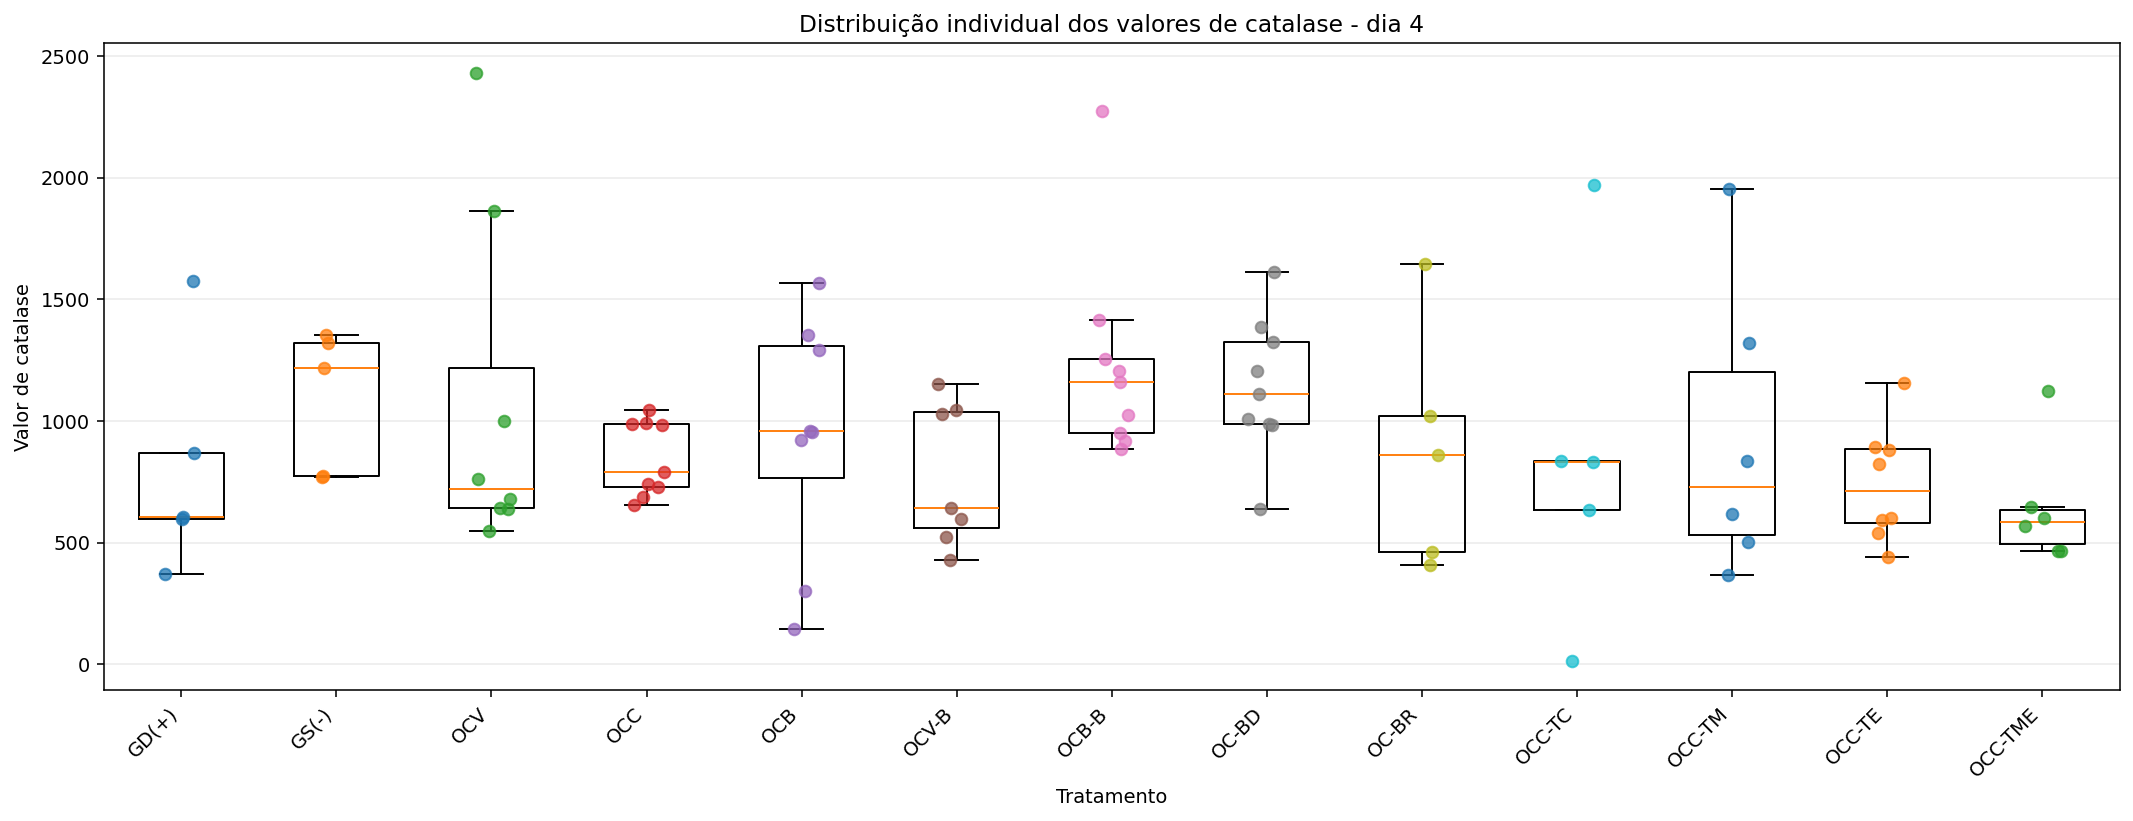

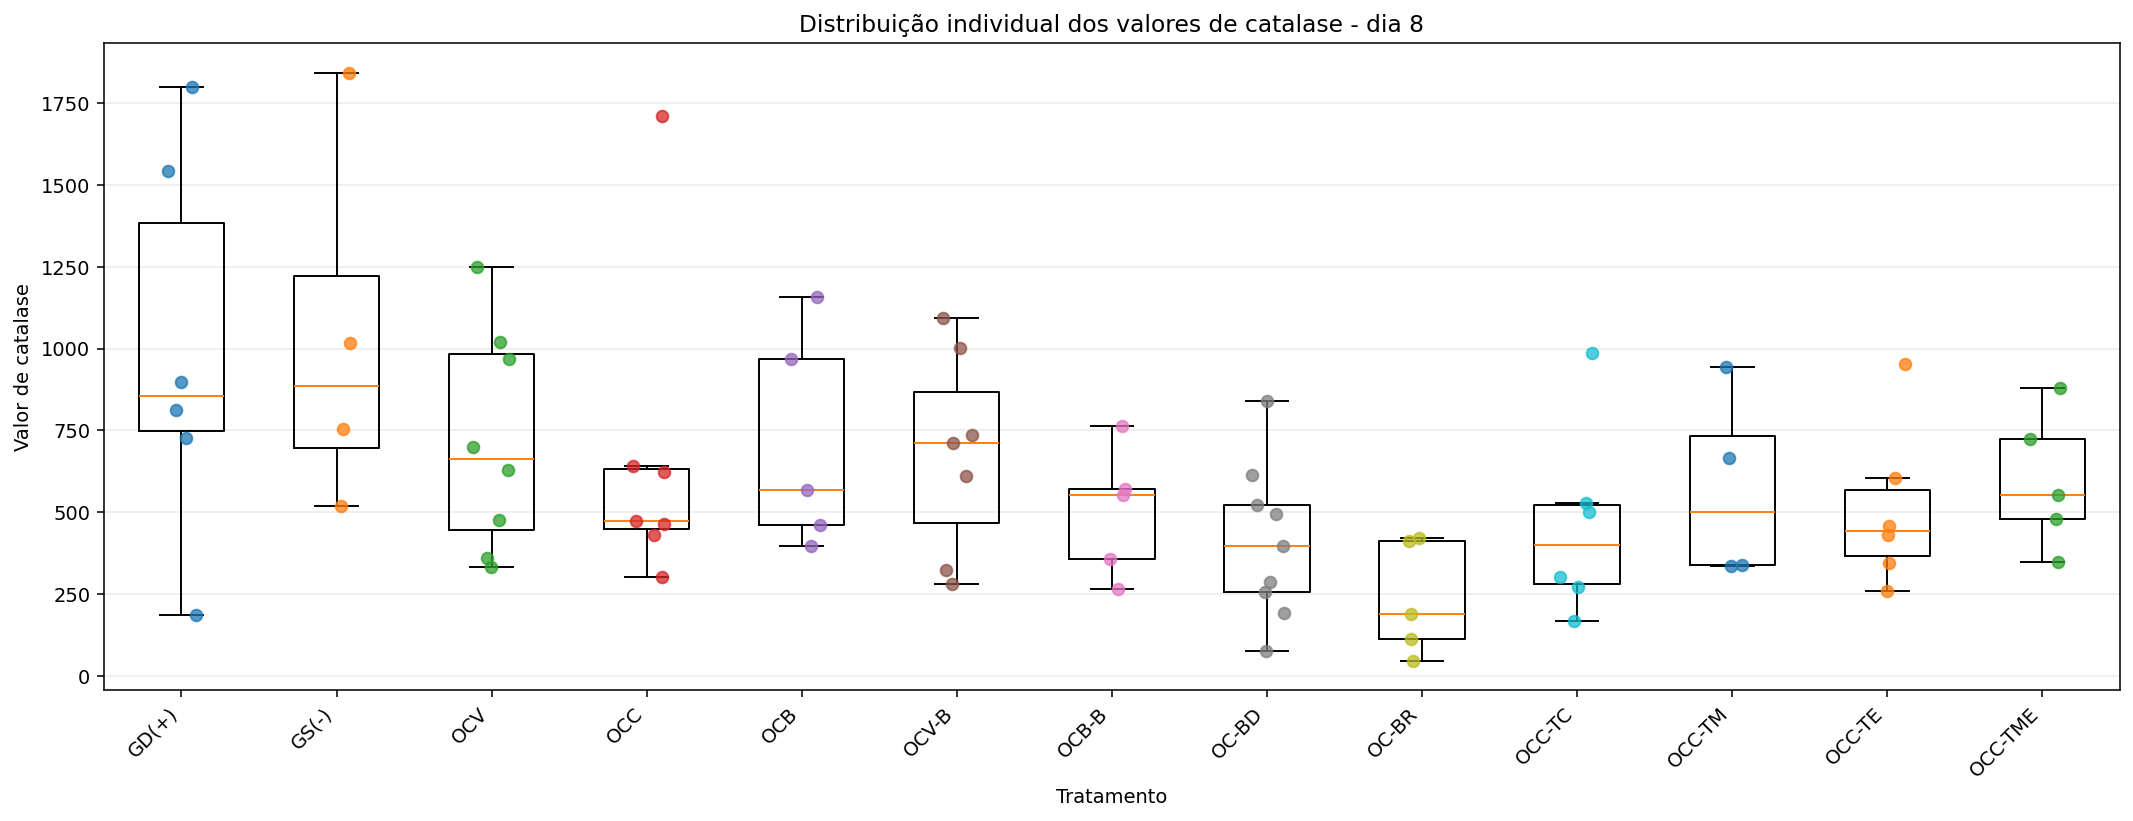


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_descritiva_catalase_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_distribuicao_catalase_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_catalase_dia_8.png


In [42]:
# ETAPA 38 — Análise descritiva e distribuição individual da catalase

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "df_catalase_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_catalase_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 37."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Definir tratamentos e dias esperados
# =========================================================

tratamentos_catalase_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

dias_esperados = [
    4,
    8
]


# =========================================================
# 3. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Valor_Catalase"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_catalase_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes na tabela de catalase: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 4. Preparar cópia específica para esta análise
# =========================================================

dados_catalase = (
    df_catalase_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_catalase["Tratamento"] = (
    dados_catalase["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_catalase["Dia"] = pd.to_numeric(
    dados_catalase["Dia"],
    errors="coerce"
)

dados_catalase["Valor_Catalase"] = pd.to_numeric(
    dados_catalase["Valor_Catalase"],
    errors="coerce"
)


# =========================================================
# 5. Verificar valores inválidos
# =========================================================

linhas_invalidas = (
    dados_catalase["Tratamento"].isna()
    | dados_catalase["Dia"].isna()
    | dados_catalase["Valor_Catalase"].isna()
    | ~np.isfinite(
        dados_catalase["Valor_Catalase"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_catalase.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de catalase."
    )


# =========================================================
# 6. Verificar dias e tratamentos
# =========================================================

dias_encontrados = sorted(
    dados_catalase["Dia"]
    .astype(int)
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:
    raise ValueError(
        "Os dias encontrados não correspondem aos dias 4 e 8: "
        f"{dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_catalase["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_catalase_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_catalase_esperados)
)

if tratamentos_ausentes:
    raise ValueError(
        "Tratamentos ausentes nos dados de catalase: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:
    raise ValueError(
        "Tratamentos não previstos encontrados: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 7. Confirmar os totais da Etapa 37
# =========================================================

total_dia_4 = int(
    (
        dados_catalase["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_catalase["Dia"] == 8
    ).sum()
)

if total_dia_4 != 90:
    raise ValueError(
        "O total do dia 4 deveria ser 90, "
        f"mas foi encontrado {total_dia_4}."
    )

if total_dia_8 != 77:
    raise ValueError(
        "O total do dia 8 deveria ser 77, "
        f"mas foi encontrado {total_dia_8}."
    )

print("Totais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 8. Calcular a estatística descritiva
# =========================================================

df_descritiva_catalase = (
    dados_catalase
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_Catalase",
            "count"
        ),
        media=(
            "Valor_Catalase",
            "mean"
        ),
        desvio_padrao=(
            "Valor_Catalase",
            "std"
        ),
        minimo=(
            "Valor_Catalase",
            "min"
        ),
        primeiro_quartil=(
            "Valor_Catalase",
            lambda valores: valores.quantile(0.25)
        ),
        mediana=(
            "Valor_Catalase",
            "median"
        ),
        terceiro_quartil=(
            "Valor_Catalase",
            lambda valores: valores.quantile(0.75)
        ),
        maximo=(
            "Valor_Catalase",
            "max"
        )
    )
)


# =========================================================
# 9. Calcular intervalo interquartil
# =========================================================

df_descritiva_catalase[
    "intervalo_interquartil"
] = (
    df_descritiva_catalase[
        "terceiro_quartil"
    ]
    - df_descritiva_catalase[
        "primeiro_quartil"
    ]
)


# =========================================================
# 10. Garantir a ordem dos 13 tratamentos
# =========================================================

indice_completo = pd.MultiIndex.from_product(
    [
        tratamentos_catalase_esperados,
        dias_esperados
    ],
    names=[
        "Tratamento",
        "Dia"
    ]
)

df_descritiva_catalase = (
    df_descritiva_catalase
    .set_index(
        [
            "Tratamento",
            "Dia"
        ]
    )
    .reindex(
        indice_completo
    )
    .reset_index()
)


# =========================================================
# 11. Verificar grupos com poucas observações
# =========================================================

grupos_amostra_pequena = (
    df_descritiva_catalase.loc[
        df_descritiva_catalase["n"] < 3,
        [
            "Tratamento",
            "Dia",
            "n"
        ]
    ]
    .copy()
)

print("\nEstatística descritiva da catalase:")

display(
    df_descritiva_catalase.round(
        {
            "media": 4,
            "desvio_padrao": 4,
            "minimo": 4,
            "primeiro_quartil": 4,
            "mediana": 4,
            "terceiro_quartil": 4,
            "maximo": 4,
            "intervalo_interquartil": 4
        }
    )
)


print("\nGrupos com menos de três observações:")

if grupos_amostra_pequena.empty:

    print(
        "Nenhum grupo possui menos de três observações."
    )

else:

    display(
        grupos_amostra_pequena
    )


# =========================================================
# 12. Criar tabela de contagens
# =========================================================

tabela_contagem_catalase_descritiva = (
    df_descritiva_catalase
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_catalase_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .astype(int)
)

print("\nNúmero de observações por tratamento:")

display(
    tabela_contagem_catalase_descritiva
)


# =========================================================
# 13. Construir gráficos para os dias 4 e 8
# =========================================================

arquivos_graficos_catalase = []

for dia in dias_esperados:

    dados_dia = (
        dados_catalase.loc[
            dados_catalase["Dia"] == dia
        ]
        .copy()
    )

    valores_boxplot = []
    posicoes_boxplot = []

    for posicao, tratamento in enumerate(
        tratamentos_catalase_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_Catalase"
            ]
            .to_numpy(dtype=float)
        )

        if len(valores) > 0:

            valores_boxplot.append(
                valores
            )

            posicoes_boxplot.append(
                posicao
            )


    plt.close("all")

    fig, ax = plt.subplots(
        figsize=(
            16,
            7
        )
    )


    # -----------------------------------------------------
    # Boxplots
    # -----------------------------------------------------
    # Os marcadores automáticos de outliers são ocultados
    # porque todos os pontos serão mostrados separadamente.

    ax.boxplot(
        valores_boxplot,
        positions=posicoes_boxplot,
        widths=0.55,
        showfliers=False
    )


    # -----------------------------------------------------
    # Sobreposição de todos os valores individuais
    # -----------------------------------------------------

    gerador_aleatorio = np.random.default_rng(
        20260729 + dia
    )

    for posicao, tratamento in enumerate(
        tratamentos_catalase_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_Catalase"
            ]
            .to_numpy(dtype=float)
        )

        if len(valores) == 0:
            continue

        deslocamento = gerador_aleatorio.uniform(
            -0.12,
            0.12,
            size=len(valores)
        )

        posicoes_pontos = (
            np.full(
                len(valores),
                posicao,
                dtype=float
            )
            + deslocamento
        )

        ax.scatter(
            posicoes_pontos,
            valores,
            alpha=0.75,
            zorder=3
        )


    # -----------------------------------------------------
    # Formatação
    # -----------------------------------------------------

    ax.set_title(
        f"Distribuição individual dos valores de catalase - dia {dia}"
    )

    ax.set_xlabel(
        "Tratamento"
    )

    ax.set_ylabel(
        "Valor de catalase"
    )

    ax.set_xticks(
        range(
            1,
            len(tratamentos_catalase_esperados) + 1
        )
    )

    ax.set_xticklabels(
        tratamentos_catalase_esperados,
        rotation=45,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.24,
        top=0.90
    )


    # -----------------------------------------------------
    # Salvar e exibir
    # -----------------------------------------------------

    arquivo_grafico = (
        PASTA_PROJETO
        / f"projeto001_distribuicao_catalase_dia_{dia}.png"
    )

    fig.canvas.draw()

    fig.savefig(
        arquivo_grafico,
        dpi=300,
        format="png"
    )

    plt.show()

    plt.close(fig)

    arquivos_graficos_catalase.append(
        arquivo_grafico
    )


# =========================================================
# 14. Salvar a estatística descritiva
# =========================================================

arquivo_descritiva_catalase = (
    PASTA_PROJETO
    / "projeto001_descritiva_catalase_dias_4_8.csv"
)

df_descritiva_catalase.to_csv(
    arquivo_descritiva_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_descritiva_catalase
)

for arquivo in arquivos_graficos_catalase:
    print(arquivo)

## 39. Comparação global da catalase por teste de permutação

Os valores individuais de catalase serão comparados entre os 13 tratamentos,
separadamente nos dias 4 e 8.

Será utilizada a estatística H de Kruskal-Wallis, acompanhada de valor de p
calculado por permutação. Esse procedimento é apropriado diante de:

- distribuições assimétricas;
- tamanhos amostrais desiguais;
- presença de valores extremos preservados;
- ausência de garantia de normalidade.

Serão realizadas 49.999 permutações em cada dia, mantendo os tamanhos originais
dos grupos.

A análise utilizará a base auditada após a exclusão documentada dos valores
das células G13 e L11. O teste global indicará apenas se existe diferença entre
os tratamentos, sem identificar quais grupos diferem entre si.

In [43]:
# ETAPA 39 — Teste global da catalase por permutação
# Kruskal-Wallis com 49.999 permutações por dia

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import kruskal, rankdata
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

NUMERO_PERMUTACOES_CATALASE = 49_999
SEMENTE_CATALASE = 20260729
NIVEL_SIGNIFICANCIA = 0.05


# =========================================================
# 2. Verificações iniciais
# =========================================================

if "df_catalase_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_catalase_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 37."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


tratamentos_catalase_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Valor_Catalase"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_catalase_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes na tabela de catalase: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 3. Preparar os dados
# =========================================================

dados_catalase_teste = (
    df_catalase_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_catalase_teste["Tratamento"] = (
    dados_catalase_teste["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_catalase_teste["Dia"] = pd.to_numeric(
    dados_catalase_teste["Dia"],
    errors="coerce"
)

dados_catalase_teste["Valor_Catalase"] = pd.to_numeric(
    dados_catalase_teste["Valor_Catalase"],
    errors="coerce"
)


linhas_invalidas = (
    dados_catalase_teste["Tratamento"].isna()
    | dados_catalase_teste["Dia"].isna()
    | dados_catalase_teste["Valor_Catalase"].isna()
    | ~np.isfinite(
        dados_catalase_teste["Valor_Catalase"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_catalase_teste.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de catalase."
    )


# =========================================================
# 4. Conferir tratamentos e totais
# =========================================================

tratamentos_encontrados = set(
    dados_catalase_teste["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_catalase_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_catalase_esperados)
)

if tratamentos_ausentes:
    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:
    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


total_dia_4 = int(
    (
        dados_catalase_teste["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_catalase_teste["Dia"] == 8
    ).sum()
)

if total_dia_4 != 90:
    raise ValueError(
        "O dia 4 deveria conter 90 observações, "
        f"mas contém {total_dia_4}."
    )

if total_dia_8 != 77:
    raise ValueError(
        "O dia 8 deveria conter 77 observações, "
        f"mas contém {total_dia_8}."
    )


# =========================================================
# 5. Função para correção de empates
# =========================================================

def calcular_correcao_empates_catalase(valores):

    _, contagens = np.unique(
        valores,
        return_counts=True
    )

    numero_total = len(valores)

    if numero_total < 2:
        raise ValueError(
            "Número insuficiente de observações."
        )

    numerador = np.sum(
        contagens**3
        - contagens
    )

    denominador = (
        numero_total**3
        - numero_total
    )

    correcao = (
        1.0
        - numerador / denominador
    )

    if correcao <= 0:
        raise ValueError(
            "Não foi possível calcular a correção "
            "de empates."
        )

    return float(correcao)


# =========================================================
# 6. Função para calcular H a partir dos postos
# =========================================================

def calcular_h_catalase(
    postos,
    tamanhos_grupos,
    correcao_empates
):

    numero_total = len(postos)

    inicio = 0
    soma_componentes = 0.0

    for tamanho in tamanhos_grupos:

        final = inicio + tamanho

        soma_postos = np.sum(
            postos[inicio:final]
        )

        soma_componentes += (
            soma_postos**2
            / tamanho
        )

        inicio = final

    h_sem_correcao = (
        12.0
        / (
            numero_total
            * (numero_total + 1)
        )
        * soma_componentes
        - 3.0
        * (numero_total + 1)
    )

    return float(
        h_sem_correcao
        / correcao_empates
    )


# =========================================================
# 7. Executar a análise nos dias 4 e 8
# =========================================================

resultados_catalase = []
contagens_catalase_teste = []

inicio_etapa = time.perf_counter()

for dia in [4, 8]:

    print("\n" + "=" * 90)
    print(f"PROCESSANDO CATALASE — DIA {dia}")

    dados_dia = (
        dados_catalase_teste.loc[
            dados_catalase_teste["Dia"] == dia
        ]
        .copy()
    )

    grupos = []
    tamanhos_grupos = []

    for tratamento in tratamentos_catalase_esperados:

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                "Valor_Catalase"
            ]
            .to_numpy(dtype=float)
        )

        numero_observacoes = len(
            valores
        )

        contagens_catalase_teste.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": numero_observacoes
            }
        )

        if numero_observacoes < 2:
            raise ValueError(
                f"O tratamento {tratamento} possui somente "
                f"{numero_observacoes} observação(ões) "
                f"no dia {dia}."
            )

        grupos.append(
            valores
        )

        tamanhos_grupos.append(
            numero_observacoes
        )


    numero_grupos = len(
        grupos
    )

    numero_total = sum(
        tamanhos_grupos
    )

    valores_concatenados = np.concatenate(
        grupos
    )

    postos = rankdata(
        valores_concatenados,
        method="average"
    )

    correcao_empates = (
        calcular_correcao_empates_catalase(
            valores_concatenados
        )
    )

    h_observado = calcular_h_catalase(
        postos=postos,
        tamanhos_grupos=tamanhos_grupos,
        correcao_empates=correcao_empates
    )


    # -----------------------------------------------------
    # Conferência com o resultado convencional
    # -----------------------------------------------------

    resultado_assintotico = kruskal(
        *grupos,
        nan_policy="raise"
    )

    h_assintotico = float(
        resultado_assintotico.statistic
    )

    p_assintotico = float(
        resultado_assintotico.pvalue
    )

    if not np.isclose(
        h_observado,
        h_assintotico,
        rtol=1e-10,
        atol=1e-10
    ):
        raise RuntimeError(
            "A estatística H manual não coincide "
            "com o resultado do SciPy."
        )


    # -----------------------------------------------------
    # Permutações
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        SEMENTE_CATALASE + dia
    )

    numero_extremos = 0

    inicio_dia = time.perf_counter()

    for _ in range(
        NUMERO_PERMUTACOES_CATALASE
    ):

        postos_permutados = gerador.permutation(
            postos
        )

        h_permutado = calcular_h_catalase(
            postos=postos_permutados,
            tamanhos_grupos=tamanhos_grupos,
            correcao_empates=correcao_empates
        )

        if h_permutado >= (
            h_observado - 1e-12
        ):
            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos + 1
    ) / (
        NUMERO_PERMUTACOES_CATALASE + 1
    )


    erro_padrao_monte_carlo = np.sqrt(
        valor_p_permutacao
        * (
            1.0
            - valor_p_permutacao
        )
        / (
            NUMERO_PERMUTACOES_CATALASE + 1
        )
    )


    # -----------------------------------------------------
    # Tamanho de efeito global
    # -----------------------------------------------------

    denominador_efeito = (
        numero_total
        - numero_grupos
    )

    epsilon_quadrado = (
        h_observado
        - numero_grupos
        + 1
    ) / denominador_efeito

    epsilon_quadrado = min(
        1.0,
        max(
            0.0,
            float(epsilon_quadrado)
        )
    )


    # -----------------------------------------------------
    # Conclusão
    # -----------------------------------------------------

    if valor_p_permutacao < NIVEL_SIGNIFICANCIA:

        conclusao = (
            "Há evidência de diferença global entre "
            "os tratamentos."
        )

    else:

        conclusao = (
            "Não há evidência de diferença global entre "
            "os tratamentos."
        )


    tempo_dia = (
        time.perf_counter()
        - inicio_dia
    )


    resultados_catalase.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Menor_n": min(tamanhos_grupos),
            "Maior_n": max(tamanhos_grupos),
            "Estatistica_H": h_observado,
            "Graus_de_liberdade": numero_grupos - 1,
            "Valor_p_assintotico": p_assintotico,
            "Numero_de_permutacoes": (
                NUMERO_PERMUTACOES_CATALASE
            ),
            "Permutacoes_iguais_ou_maiores": (
                numero_extremos
            ),
            "Valor_p_permutacao": (
                valor_p_permutacao
            ),
            "Erro_padrao_Monte_Carlo": (
                erro_padrao_monte_carlo
            ),
            "Epsilon_quadrado": (
                epsilon_quadrado
            ),
            "Tempo_segundos": tempo_dia,
            "Conclusao_5_percent": conclusao
        }
    )


    print(
        f"H observado: {h_observado:.6f}"
    )

    print(
        f"p assintótico: {p_assintotico:.8f}"
    )

    print(
        f"p por permutação: "
        f"{valor_p_permutacao:.8f}"
    )

    print(
        f"ε²: {epsilon_quadrado:.4f}"
    )

    print(
        f"Tempo: {tempo_dia:.2f} segundos"
    )

    print(conclusao)


# =========================================================
# 8. Criar as tabelas finais
# =========================================================

df_resultados_permutacao_catalase = pd.DataFrame(
    resultados_catalase
)

df_contagens_teste_catalase = pd.DataFrame(
    contagens_catalase_teste
)

tabela_contagens_teste_catalase = (
    df_contagens_teste_catalase
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_catalase_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)


# =========================================================
# 9. Exibir os resultados
# =========================================================

print("\n" + "=" * 90)

print(
    "CONTAGENS UTILIZADAS NO TESTE DA CATALASE"
)

display(
    tabela_contagens_teste_catalase
)


print("\nRESULTADOS GLOBAIS DA CATALASE")

display(
    df_resultados_permutacao_catalase.round(
        {
            "Estatistica_H": 6,
            "Valor_p_assintotico": 8,
            "Valor_p_permutacao": 8,
            "Erro_padrao_Monte_Carlo": 8,
            "Epsilon_quadrado": 4,
            "Tempo_segundos": 2
        }
    )
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)

print(
    f"\nTempo total da Etapa 39: "
    f"{tempo_total:.2f} segundos"
)


# =========================================================
# 10. Salvar os resultados
# =========================================================

arquivo_teste_global_catalase = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_catalase.csv"
)

arquivo_contagens_teste_catalase = (
    PASTA_PROJETO
    / "projeto001_contagens_teste_global_catalase.csv"
)

df_resultados_permutacao_catalase.to_csv(
    arquivo_teste_global_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tabela_contagens_teste_catalase.to_csv(
    arquivo_contagens_teste_catalase,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_teste_global_catalase
)

print(
    arquivo_contagens_teste_catalase
)


PROCESSANDO CATALASE — DIA 4
H observado: 18.954477
p assintótico: 0.08963299
p por permutação: 0.07696000
ε²: 0.0903
Tempo: 2.63 segundos
Não há evidência de diferença global entre os tratamentos.

PROCESSANDO CATALASE — DIA 8
H observado: 21.150117
p assintótico: 0.04822497
p por permutação: 0.03418000
ε²: 0.1430
Tempo: 2.59 segundos
Há evidência de diferença global entre os tratamentos.

CONTAGENS UTILIZADAS NO TESTE DA CATALASE


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



RESULTADOS GLOBAIS DA CATALASE


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Menor_n,Maior_n,Estatistica_H,Graus_de_liberdade,Valor_p_assintotico,Numero_de_permutacoes,Permutacoes_iguais_ou_maiores,Valor_p_permutacao,Erro_padrao_Monte_Carlo,Epsilon_quadrado,Tempo_segundos,Conclusao_5_percent
0,4,13,90,5,9,18.954477,12,0.089633,49999,3847,0.07696,0.001192,0.0903,2.63,Não há evidência de diferença global entre os ...
1,8,13,77,4,9,21.150117,12,0.048225,49999,1708,0.03418,0.000813,0.1430,2.59,Há evidência de diferença global entre os trat...



Tempo total da Etapa 39: 5.25 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_teste_global_permutacao_catalase.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_teste_global_catalase.csv


## 40. Comparações da catalase com os controles no dia 8

Como o teste global por permutação indicou diferença significativa entre os
tratamentos no dia 8, serão realizadas comparações planejadas entre cada óleo
e os dois controles:

- GD(+): controle positivo;
- GS(-): controle negativo.

Será utilizado um teste bilateral de permutação baseado na estatística U de
Mann-Whitney, com 49.999 permutações por comparação.

Os valores de p das 22 comparações serão corrigidos conjuntamente pelo método
de Holm.

Também serão apresentados:

- número de observações;
- medianas;
- diferença entre medianas;
- correlação bisserial de postos;
- magnitude e direção do efeito.

O dia 4 não será submetido a comparações múltiplas porque o teste global não
foi significativo.

In [44]:
# ETAPA 40 — Comparações dos óleos com os controles
# Catalase — somente dia 8
# Mann-Whitney por permutação com correção de Holm

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import rankdata, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

DIA_ANALISADO = 8
NUMERO_PERMUTACOES_PARES = 49_999
SEMENTE_PARES_CATALASE = 20260730
NIVEL_SIGNIFICANCIA = 0.05


# =========================================================
# 2. Verificações iniciais
# =========================================================

if "df_catalase_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_catalase_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 37."
    )

if "df_resultados_permutacao_catalase" not in globals():
    raise RuntimeError(
        "A tabela df_resultados_permutacao_catalase não foi encontrada. "
        "Execute primeiro a Etapa 39."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 3. Confirmar o resultado global
# =========================================================

resultado_dia_4 = (
    df_resultados_permutacao_catalase.loc[
        df_resultados_permutacao_catalase["Dia"] == 4
    ]
)

resultado_dia_8 = (
    df_resultados_permutacao_catalase.loc[
        df_resultados_permutacao_catalase["Dia"] == 8
    ]
)

if len(resultado_dia_4) != 1:
    raise ValueError(
        "Não foi encontrado exatamente um resultado global "
        "para o dia 4."
    )

if len(resultado_dia_8) != 1:
    raise ValueError(
        "Não foi encontrado exatamente um resultado global "
        "para o dia 8."
    )

p_global_dia_4 = float(
    resultado_dia_4["Valor_p_permutacao"].iloc[0]
)

p_global_dia_8 = float(
    resultado_dia_8["Valor_p_permutacao"].iloc[0]
)

print("Resultados globais conferidos:")

print(
    f"Dia 4: p por permutação = "
    f"{p_global_dia_4:.8f}"
)

print(
    f"Dia 8: p por permutação = "
    f"{p_global_dia_8:.8f}"
)

if p_global_dia_4 < NIVEL_SIGNIFICANCIA:
    raise ValueError(
        "O resultado do dia 4 está diferente do esperado. "
        "Revise a Etapa 39 antes de continuar."
    )

if p_global_dia_8 >= NIVEL_SIGNIFICANCIA:
    raise ValueError(
        "O teste global do dia 8 não foi significativo. "
        "As comparações múltiplas não serão executadas."
    )


# =========================================================
# 4. Definir grupos
# =========================================================

controles_catalase = [
    "GD(+)",
    "GS(-)"
]

oleos_catalase = [
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

tratamentos_esperados = (
    controles_catalase
    + oleos_catalase
)


# =========================================================
# 5. Preparar os dados do dia 8
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    "Valor_Catalase"
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_catalase_individual_longa.columns
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes na tabela de catalase: "
        f"{colunas_ausentes}"
    )

dados_catalase_dia_8 = (
    df_catalase_individual_longa.loc[
        df_catalase_individual_longa["Dia"] == DIA_ANALISADO,
        colunas_necessarias
    ]
    .copy()
)

dados_catalase_dia_8["Tratamento"] = (
    dados_catalase_dia_8["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_catalase_dia_8["Valor_Catalase"] = pd.to_numeric(
    dados_catalase_dia_8["Valor_Catalase"],
    errors="coerce"
)


# =========================================================
# 6. Validar os dados
# =========================================================

linhas_invalidas = (
    dados_catalase_dia_8["Tratamento"].isna()
    | dados_catalase_dia_8["Valor_Catalase"].isna()
    | ~np.isfinite(
        dados_catalase_dia_8["Valor_Catalase"]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas:")

    display(
        dados_catalase_dia_8.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem valores inválidos nos dados do dia 8."
    )


tratamentos_encontrados = set(
    dados_catalase_dia_8["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_esperados)
)

if tratamentos_ausentes:
    raise ValueError(
        "Tratamentos ausentes no dia 8: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:
    raise ValueError(
        "Tratamentos não previstos no dia 8: "
        f"{tratamentos_nao_previstos}"
    )

if len(dados_catalase_dia_8) != 77:
    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas {len(dados_catalase_dia_8)}."
    )


# =========================================================
# 7. Classificar magnitude do efeito
# =========================================================

def classificar_magnitude_bisserial(valor):

    valor_absoluto = abs(valor)

    if valor_absoluto < 0.10:
        return "Desprezível"

    if valor_absoluto < 0.30:
        return "Pequeno"

    if valor_absoluto < 0.50:
        return "Moderado"

    return "Grande"


# =========================================================
# 8. Teste de permutação baseado na estatística U
# =========================================================

def teste_u_por_permutacao(
    valores_oleo,
    valores_controle,
    numero_permutacoes,
    semente
):

    valores_oleo = np.asarray(
        valores_oleo,
        dtype=float
    )

    valores_controle = np.asarray(
        valores_controle,
        dtype=float
    )

    n_oleo = len(valores_oleo)
    n_controle = len(valores_controle)

    if n_oleo < 2 or n_controle < 2:
        raise ValueError(
            "Cada grupo deve possuir pelo menos duas observações."
        )

    valores_combinados = np.concatenate(
        [
            valores_oleo,
            valores_controle
        ]
    )

    postos = rankdata(
        valores_combinados,
        method="average"
    )

    soma_postos_oleo = np.sum(
        postos[:n_oleo]
    )

    u_observado = (
        soma_postos_oleo
        - n_oleo
        * (n_oleo + 1)
        / 2
    )

    centro_u = (
        n_oleo
        * n_controle
        / 2
    )

    distancia_observada = abs(
        u_observado
        - centro_u
    )

    gerador = np.random.default_rng(
        semente
    )

    numero_extremos = 0

    for _ in range(
        numero_permutacoes
    ):

        postos_permutados = gerador.permutation(
            postos
        )

        soma_postos_permutada = np.sum(
            postos_permutados[:n_oleo]
        )

        u_permutado = (
            soma_postos_permutada
            - n_oleo
            * (n_oleo + 1)
            / 2
        )

        distancia_permutada = abs(
            u_permutado
            - centro_u
        )

        if distancia_permutada >= (
            distancia_observada - 1e-12
        ):
            numero_extremos += 1

    valor_p_permutacao = (
        numero_extremos + 1
    ) / (
        numero_permutacoes + 1
    )

    correlacao_bisserial = (
        2.0
        * u_observado
        / (
            n_oleo
            * n_controle
        )
        - 1.0
    )

    return {
        "Estatistica_U": float(
            u_observado
        ),
        "Valor_p_permutacao": float(
            valor_p_permutacao
        ),
        "Permutacoes_iguais_ou_maiores": int(
            numero_extremos
        ),
        "Correlacao_bisserial_postos": float(
            correlacao_bisserial
        )
    }


# =========================================================
# 9. Executar as 22 comparações
# =========================================================

resultados_comparacoes = []

contador_comparacao = 0

inicio_etapa = time.perf_counter()

for controle in controles_catalase:

    valores_controle = (
        dados_catalase_dia_8.loc[
            dados_catalase_dia_8["Tratamento"] == controle,
            "Valor_Catalase"
        ]
        .to_numpy(dtype=float)
    )

    for oleo in oleos_catalase:

        contador_comparacao += 1

        valores_oleo = (
            dados_catalase_dia_8.loc[
                dados_catalase_dia_8["Tratamento"] == oleo,
                "Valor_Catalase"
            ]
            .to_numpy(dtype=float)
        )

        resultado_permutacao = teste_u_por_permutacao(
            valores_oleo=valores_oleo,
            valores_controle=valores_controle,
            numero_permutacoes=NUMERO_PERMUTACOES_PARES,
            semente=(
                SEMENTE_PARES_CATALASE
                + contador_comparacao
            )
        )

        # Mann-Whitney assintótico apenas para conferência
        resultado_assintotico = mannwhitneyu(
            valores_oleo,
            valores_controle,
            alternative="two-sided",
            method="asymptotic"
        )

        mediana_oleo = float(
            np.median(valores_oleo)
        )

        mediana_controle = float(
            np.median(valores_controle)
        )

        diferenca_medianas = (
            mediana_oleo
            - mediana_controle
        )

        efeito = resultado_permutacao[
            "Correlacao_bisserial_postos"
        ]

        if efeito > 0:

            direcao = (
                "Óleo apresentou tendência a valores "
                "mais altos de catalase"
            )

        elif efeito < 0:

            direcao = (
                "Óleo apresentou tendência a valores "
                "mais baixos de catalase"
            )

        else:

            direcao = (
                "Não houve direção predominante"
            )

        resultados_comparacoes.append(
            {
                "Dia": DIA_ANALISADO,
                "Oleo": oleo,
                "Controle": controle,
                "n_Oleo": len(valores_oleo),
                "n_Controle": len(valores_controle),
                "Mediana_Oleo": mediana_oleo,
                "Mediana_Controle": mediana_controle,
                "Diferenca_Medianas": diferenca_medianas,
                "Estatistica_U": resultado_permutacao[
                    "Estatistica_U"
                ],
                "Valor_p_assintotico": float(
                    resultado_assintotico.pvalue
                ),
                "Numero_de_permutacoes": (
                    NUMERO_PERMUTACOES_PARES
                ),
                "Permutacoes_iguais_ou_maiores": (
                    resultado_permutacao[
                        "Permutacoes_iguais_ou_maiores"
                    ]
                ),
                "Valor_p_permutacao": (
                    resultado_permutacao[
                        "Valor_p_permutacao"
                    ]
                ),
                "Correlacao_bisserial_postos": efeito,
                "Magnitude_efeito": (
                    classificar_magnitude_bisserial(
                        efeito
                    )
                ),
                "Direcao_efeito": direcao
            }
        )


# =========================================================
# 10. Aplicar correção de Holm
# =========================================================

df_comparacoes_catalase = pd.DataFrame(
    resultados_comparacoes
)

valores_p = (
    df_comparacoes_catalase[
        "Valor_p_permutacao"
    ]
    .to_numpy(dtype=float)
)

rejeitar_h0, valores_p_holm, _, _ = multipletests(
    valores_p,
    alpha=NIVEL_SIGNIFICANCIA,
    method="holm"
)

df_comparacoes_catalase[
    "Valor_p_Holm"
] = valores_p_holm

df_comparacoes_catalase[
    "Significativo_Holm_5_percent"
] = rejeitar_h0


df_comparacoes_catalase[
    "Conclusao"
] = np.where(
    df_comparacoes_catalase[
        "Significativo_Holm_5_percent"
    ],
    "Diferença significativa após correção de Holm",
    "Diferença não significativa após correção de Holm"
)


# =========================================================
# 11. Ordenar a tabela
# =========================================================

df_comparacoes_catalase = (
    df_comparacoes_catalase
    .sort_values(
        [
            "Controle",
            "Valor_p_Holm",
            "Oleo"
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 12. Exibir por controle
# =========================================================

for controle in controles_catalase:

    print("\n" + "=" * 100)

    print(
        f"CATALASE — DIA 8 — ÓLEOS VERSUS {controle}"
    )

    tabela_exibicao = (
        df_comparacoes_catalase.loc[
            df_comparacoes_catalase["Controle"] == controle,
            [
                "Oleo",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Significativo_Holm_5_percent",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito"
            ]
        ]
    )

    display(
        tabela_exibicao.round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 13. Mostrar apenas comparações significativas
# =========================================================

df_comparacoes_significativas_catalase = (
    df_comparacoes_catalase.loc[
        df_comparacoes_catalase[
            "Significativo_Holm_5_percent"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

print("\n" + "=" * 100)

print(
    "COMPARAÇÕES SIGNIFICATIVAS DA CATALASE "
    "APÓS CORREÇÃO DE HOLM"
)

if df_comparacoes_significativas_catalase.empty:

    print(
        "Nenhuma comparação permaneceu significativa "
        "após a correção de Holm."
    )

else:

    display(
        df_comparacoes_significativas_catalase[
            [
                "Dia",
                "Oleo",
                "Controle",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito"
            ]
        ].round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 14. Salvar os resultados
# =========================================================

arquivo_comparacoes_catalase = (
    PASTA_PROJETO
    / "projeto001_comparacoes_catalase_dia8_permutacao_holm.csv"
)

arquivo_significativas_catalase = (
    PASTA_PROJETO
    / "projeto001_comparacoes_significativas_catalase.csv"
)

df_comparacoes_catalase.to_csv(
    arquivo_comparacoes_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_comparacoes_significativas_catalase.to_csv(
    arquivo_significativas_catalase,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tempo_total = (
    time.perf_counter()
    - inicio_etapa
)

print(
    f"\nTempo total da Etapa 40: "
    f"{tempo_total:.2f} segundos"
)

print("\nArquivos salvos:")

print(arquivo_comparacoes_catalase)
print(arquivo_significativas_catalase)

Resultados globais conferidos:
Dia 4: p por permutação = 0.07696000
Dia 8: p por permutação = 0.03418000

CATALASE — DIA 8 — ÓLEOS VERSUS GD(+)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
0,OC-BR,5,6,188.1954,855.5993,-667.4039,0.03040,0.63840,False,-0.8000,Grande,Óleo apresentou tendência a valores mais baixo...
1,OC-BD,9,6,396.6293,855.5993,-458.9700,0.05028,0.95532,False,-0.6296,Grande,Óleo apresentou tendência a valores mais baixo...
2,OCB,5,6,567.3301,855.5993,-288.2692,0.53672,1.00000,False,-0.2667,Pequeno,Óleo apresentou tendência a valores mais baixo...
3,OCB-B,5,6,553.8329,855.5993,-301.7664,0.12758,1.00000,False,-0.6000,Grande,Óleo apresentou tendência a valores mais baixo...
4,OCC,7,6,473.3303,855.5993,-382.2690,0.18066,1.00000,False,-0.4762,Moderado,Óleo apresentou tendência a valores mais baixo...
5,OCC-TC,6,6,401.2507,855.5993,-454.3486,0.13214,1.00000,False,-0.5556,Grande,Óleo apresentou tendência a valores mais baixo...
6,OCC-TE,6,6,443.2172,855.5993,-412.3822,0.17982,1.00000,False,-0.5000,Grande,Óleo apresentou tendência a valores mais baixo...
7,OCC-TM,4,6,501.7250,855.5993,-353.8744,0.35562,1.00000,False,-0.4167,Moderado,Óleo apresentou tendência a valores mais baixo...
8,OCC-TME,5,6,551.3756,855.5993,-304.2237,0.17812,1.00000,False,-0.5333,Grande,Óleo apresentou tendência a valores mais baixo...
9,OCV,8,6,663.9843,855.5993,-191.6150,0.41862,1.00000,False,-0.2917,Pequeno,Óleo apresentou tendência a valores mais baixo...



CATALASE — DIA 8 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito
11,OC-BR,5,4,188.1954,885.1298,-696.9344,0.01562,0.34364,False,-1.0000,Grande,Óleo apresentou tendência a valores mais baixo...
12,OC-BD,9,4,396.6293,885.1298,-488.5005,0.03500,0.70000,False,-0.7778,Grande,Óleo apresentou tendência a valores mais baixo...
13,OCB,5,4,567.3301,885.1298,-317.7997,0.41296,1.00000,False,-0.4000,Moderado,Óleo apresentou tendência a valores mais baixo...
14,OCB-B,5,4,553.8329,885.1298,-331.2969,0.19050,1.00000,False,-0.6000,Grande,Óleo apresentou tendência a valores mais baixo...
15,OCC,7,4,473.3303,885.1298,-411.7995,0.10678,1.00000,False,-0.6429,Grande,Óleo apresentou tendência a valores mais baixo...
16,OCC-TC,6,4,401.2507,885.1298,-483.8791,0.06734,1.00000,False,-0.7500,Grande,Óleo apresentou tendência a valores mais baixo...
17,OCC-TE,6,4,443.2172,885.1298,-441.9126,0.06652,1.00000,False,-0.7500,Grande,Óleo apresentou tendência a valores mais baixo...
18,OCC-TM,4,4,501.7250,885.1298,-383.4048,0.19980,1.00000,False,-0.6250,Grande,Óleo apresentou tendência a valores mais baixo...
19,OCC-TME,5,4,551.3756,885.1298,-333.7542,0.19196,1.00000,False,-0.6000,Grande,Óleo apresentou tendência a valores mais baixo...
20,OCV,8,4,663.9843,885.1298,-221.1454,0.36768,1.00000,False,-0.3750,Moderado,Óleo apresentou tendência a valores mais baixo...



COMPARAÇÕES SIGNIFICATIVAS DA CATALASE APÓS CORREÇÃO DE HOLM
Nenhuma comparação permaneceu significativa após a correção de Holm.

Tempo total da Etapa 40: 8.51 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_comparacoes_catalase_dia8_permutacao_holm.csv
/kaggle/working/projeto001_resultados/projeto001_comparacoes_significativas_catalase.csv


## 41. Inspeção dos dados de proteínas carboniladas

Nesta etapa será examinada exclusivamente a aba de estresse oxidativo
relacionada às proteínas.

Serão verificados:

- nome exato da aba;
- localização dos 13 tratamentos;
- organização dos dias e das repetições;
- presença de cabeçalhos e células vazias;
- quantidade de valores numéricos por coluna.

Nenhum valor será excluído, transformado, imputado ou analisado
estatisticamente.

In [45]:
# ETAPA 41 — Inspeção da estrutura das proteínas carboniladas
# Correção: impedir que as abas de Fotoproteção sejam selecionadas

from pathlib import Path
import re
import unicodedata

import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

ARQUIVO_EXCEL = Path(ARQUIVO_EXCEL)
PASTA_PROJETO = Path(PASTA_PROJETO)

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n{ARQUIVO_EXCEL}"
    )

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


# =========================================================
# 3. Ler os nomes das abas
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = arquivo_excel.sheet_names


print("Arquivo utilizado:")
print(ARQUIVO_EXCEL)

print("\nAbas presentes no arquivo:")

for nome_aba in nomes_abas:
    print("-", repr(nome_aba))


# =========================================================
# 4. Localizar exclusivamente a aba de estresse oxidativo
#    relacionada às proteínas
# =========================================================

abas_proteinas_oxidativas = []

for nome_aba in nomes_abas:

    nome_normalizado = normalizar_texto(
        nome_aba
    )

    possui_proteina = (
        "proteina" in nome_normalizado
        or "protein" in nome_normalizado
    )

    possui_estresse_oxidativo = (
        "oxid" in nome_normalizado
        or "carbonil" in nome_normalizado
    )

    if (
        possui_proteina
        and possui_estresse_oxidativo
    ):
        abas_proteinas_oxidativas.append(
            nome_aba
        )


if len(abas_proteinas_oxidativas) == 0:

    raise RuntimeError(
        "Nenhuma aba de estresse oxidativo relacionada "
        "às proteínas foi localizada."
    )


if len(abas_proteinas_oxidativas) > 1:

    print(
        "\nMais de uma aba específica foi localizada:"
    )

    for nome_aba in abas_proteinas_oxidativas:
        print("-", repr(nome_aba))

    raise RuntimeError(
        "Foi localizada mais de uma aba de proteínas "
        "relacionada ao estresse oxidativo."
    )


NOME_ABA_PROTEINAS = (
    abas_proteinas_oxidativas[0]
)

print("\nAba selecionada corretamente:")

print(
    repr(NOME_ABA_PROTEINAS)
)


# Confirmação adicional para impedir seleção de Fotoproteção

if "fotoprote" in normalizar_texto(
    NOME_ABA_PROTEINAS
):

    raise RuntimeError(
        "Uma aba de Fotoproteção foi selecionada "
        "incorretamente."
    )


# =========================================================
# 5. Ler a aba sem assumir cabeçalho
# =========================================================

proteinas_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_PROTEINAS,
    header=None,
    engine="openpyxl"
)

print("\nDimensão original da aba:")

print(
    f"{proteinas_bruta.shape[0]} linhas × "
    f"{proteinas_bruta.shape[1]} colunas"
)


# =========================================================
# 6. Identificar as margens com conteúdo
# =========================================================

linhas_com_conteudo = (
    proteinas_bruta
    .notna()
    .any(axis=1)
)

colunas_com_conteudo = (
    proteinas_bruta
    .notna()
    .any(axis=0)
)


if not linhas_com_conteudo.any():
    raise RuntimeError(
        "A aba localizada não possui nenhuma linha "
        "com conteúdo."
    )


if not colunas_com_conteudo.any():
    raise RuntimeError(
        "A aba localizada não possui nenhuma coluna "
        "com conteúdo."
    )


proteinas_inspecao = proteinas_bruta.loc[
    linhas_com_conteudo,
    colunas_com_conteudo
].copy()


# =========================================================
# 7. Preservar as referências reais do Excel
# =========================================================

proteinas_inspecao.index = (
    proteinas_inspecao.index + 1
)

proteinas_inspecao.index.name = (
    "Linha_Excel"
)

proteinas_inspecao.columns = [
    get_column_letter(
        int(indice_coluna) + 1
    )
    for indice_coluna in proteinas_inspecao.columns
]


print("\nIntervalo da inspeção:")

print(
    f"Linhas do Excel: "
    f"{proteinas_inspecao.index.min()} até "
    f"{proteinas_inspecao.index.max()}"
)

print(
    f"Colunas do Excel: "
    f"{proteinas_inspecao.columns[0]} até "
    f"{proteinas_inspecao.columns[-1]}"
)


# =========================================================
# 8. Exibir a estrutura completa
# =========================================================

print(
    "\nEstrutura completa da aba selecionada:"
)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 400,
    "display.max_colwidth", 120
):

    display(
        proteinas_inspecao
    )


# =========================================================
# 9. Definir os tratamentos esperados
# =========================================================

tratamentos_proteinas_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento in tratamentos_proteinas_esperados
}


# =========================================================
# 10. Localizar todas as ocorrências dos tratamentos
# =========================================================

registros_ocorrencias = []

for linha_excel, linha in (
    proteinas_inspecao.iterrows()
):

    for coluna_excel, valor_original in (
        linha.items()
    ):

        codigo = normalizar_tratamento(
            valor_original
        )

        if codigo in mapa_tratamentos:

            registros_ocorrencias.append(
                {
                    "Tratamento": (
                        mapa_tratamentos[codigo]
                    ),
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )


df_ocorrencias_proteinas = pd.DataFrame(
    registros_ocorrencias
)


if df_ocorrencias_proteinas.empty:

    raise RuntimeError(
        "Nenhum dos 13 tratamentos foi localizado "
        "na aba selecionada."
    )


df_ocorrencias_proteinas = (
    df_ocorrencias_proteinas
    .sort_values(
        [
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(drop=True)
)


print("\nOcorrências dos tratamentos:")

display(
    df_ocorrencias_proteinas
)


# =========================================================
# 11. Conferir tratamentos ausentes ou repetidos
# =========================================================

contagem_tratamentos = (
    df_ocorrencias_proteinas[
        "Tratamento"
    ]
    .value_counts()
    .reindex(
        tratamentos_proteinas_esperados,
        fill_value=0
    )
    .rename(
        "Numero_de_ocorrencias"
    )
    .to_frame()
)


print("\nContagem de ocorrências por tratamento:")

display(
    contagem_tratamentos
)


tratamentos_ausentes = (
    contagem_tratamentos.loc[
        contagem_tratamentos[
            "Numero_de_ocorrencias"
        ] == 0
    ]
    .index
    .tolist()
)


tratamentos_repetidos = (
    contagem_tratamentos.loc[
        contagem_tratamentos[
            "Numero_de_ocorrencias"
        ] > 1
    ]
    .index
    .tolist()
)


if tratamentos_ausentes:

    print("\nTratamentos não localizados:")

    print(
        tratamentos_ausentes
    )

else:

    print(
        "\nTodos os 13 tratamentos foram localizados."
    )


if tratamentos_repetidos:

    print("\nTratamentos com mais de uma ocorrência:")

    print(
        tratamentos_repetidos
    )


# =========================================================
# 12. Contar valores numéricos por coluna
# =========================================================

registros_contagem_colunas = []

for coluna in proteinas_inspecao.columns:

    valores_numericos = pd.to_numeric(
        proteinas_inspecao[coluna],
        errors="coerce"
    )

    registros_contagem_colunas.append(
        {
            "Coluna_Excel": coluna,
            "Valores_numericos": int(
                valores_numericos.notna().sum()
            ),
            "Celulas_com_conteudo": int(
                proteinas_inspecao[coluna]
                .notna()
                .sum()
            ),
            "Celulas_vazias": int(
                proteinas_inspecao[coluna]
                .isna()
                .sum()
            )
        }
    )


df_contagem_colunas_proteinas = pd.DataFrame(
    registros_contagem_colunas
)


print("\nContagem de conteúdo por coluna:")

display(
    df_contagem_colunas_proteinas
)


# =========================================================
# 13. Localizar possíveis cabeçalhos de dias
# =========================================================

registros_dias = []

for linha_excel, linha in (
    proteinas_inspecao.iterrows()
):

    for coluna_excel, valor_original in (
        linha.items()
    ):

        texto = normalizar_texto(
            valor_original
        )

        if texto in [
            "dia4",
            "d4",
            "4dias"
        ]:

            registros_dias.append(
                {
                    "Dia": 4,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )

        elif texto in [
            "dia8",
            "d8",
            "8dias"
        ]:

            registros_dias.append(
                {
                    "Dia": 8,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )


df_cabecalhos_dias_proteinas = pd.DataFrame(
    registros_dias
)


print("\nPossíveis cabeçalhos dos dias:")

if df_cabecalhos_dias_proteinas.empty:

    print(
        "Nenhum cabeçalho explícito de dia foi localizado."
    )

else:

    display(
        df_cabecalhos_dias_proteinas
    )


# =========================================================
# 14. Salvar os arquivos de inspeção
# =========================================================

arquivo_inspecao_proteinas = (
    PASTA_PROJETO
    / "projeto001_inspecao_bruta_proteinas_carboniladas.csv"
)

arquivo_ocorrencias_proteinas = (
    PASTA_PROJETO
    / "projeto001_ocorrencias_tratamentos_proteinas_carboniladas.csv"
)

arquivo_contagem_colunas_proteinas = (
    PASTA_PROJETO
    / "projeto001_contagem_colunas_proteinas_carboniladas.csv"
)

arquivo_cabecalhos_dias_proteinas = (
    PASTA_PROJETO
    / "projeto001_cabecalhos_dias_proteinas_carboniladas.csv"
)


proteinas_inspecao.to_csv(
    arquivo_inspecao_proteinas,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


df_ocorrencias_proteinas.to_csv(
    arquivo_ocorrencias_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_contagem_colunas_proteinas.to_csv(
    arquivo_contagem_colunas_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_cabecalhos_dias_proteinas.to_csv(
    arquivo_cabecalhos_dias_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_inspecao_proteinas
)

print(
    arquivo_ocorrencias_proteinas
)

print(
    arquivo_contagem_colunas_proteinas
)

print(
    arquivo_cabecalhos_dias_proteinas
)

Arquivo utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Abas presentes no arquivo:
- 'Abreviações'
- 'Componentes dos óleos'
- 'Cicatrização (área da ferida)'
- 'Cicatr.(contração da ferida)'
- 'Fotoproteção (ABSORÇÃO)'
- 'Fotoproteção (FPS)'
- 'Antibacteriana'
- 'Estresse oxid.(FRAP)'
- 'Estres. Oxid.(MDA)'
- 'Estr. Oxid.(Proteinas)'
- 'Estr. Oxd.(SOD)'
- 'Estr. Oxid. (Catalase)'

Aba selecionada corretamente:
'Estr. Oxid.(Proteinas)'

Dimensão original da aba:
15 linhas × 20 colunas

Intervalo da inspeção:
Linhas do Excel: 1 até 15
Colunas do Excel: A até T

Estrutura completa da aba selecionada:


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T
Linha_Excel,,,,,,,,,,,,,,,,,,,,
1,Teste Proteinas Carboniladas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GD(+),1071.414,1221.0860,417.8524,561.5515,594.9944,NaN,NaN,NaN,NaN,NaN,154.2499,1079.6150,525.8537,938.5778,1605.9750,537.6709,NaN,NaN,NaN
4,GS(-),746.3956,726.7249,1049.6470,794.0494,1238.5020,NaN,NaN,NaN,NaN,NaN,-402.301,629.5319,1381.4960,1178.5410,1021.3270,NaN,NaN,NaN,NaN
5,OCV,769.8042,1179.2710,544.0749,466.6614,2453.9080,2708.5010,1154.5750,907.9114,NaN,NaN,778.6687,3135.0010,520.4194,1926.4350,2323.9600,886.0709,758.1569,502.7901,NaN
6,OCC,-995.713,474.2194,814.2794,858.2945,624.1176,1057.9200,1001.3500,1104.3060,1068.9090,1074.139,847.9037,803.2368,751.1840,500.6659,756.3491,1693.6210,1603.8600,NaN,NaN
7,OCB,692.8427,1083.5790,1572.5080,2488.1770,130.8161,800.9010,984.4487,1316.2550,NaN,NaN,1136.35,608.8075,908.5503,998.4549,921.4997,NaN,NaN,NaN,NaN
8,OCV-B,867.8769,782.5358,644.6991,611.7829,576.0991,572.1437,1322.8640,NaN,NaN,NaN,340.2886,764.7509,890.3890,652.3818,686.6237,903.6763,788.1400,NaN,NaN
9,OCB-B,1280.839,23.0000,1041.2760,1238.4280,1685.2270,1274.0120,1022.5160,803.1389,2051.6280,NaN,698.5824,343.8998,1173.2640,508.6651,3438.3130,NaN,NaN,NaN,NaN



Ocorrências dos tratamentos:


,Tratamento,Linha_Excel,Coluna_Excel,Valor_original
0,GD(+),3,A,GD(+)
1,GS(-),4,A,GS(-)
2,OCV,5,A,OCV
3,OCC,6,A,OCC
4,OCB,7,A,OCB
5,OCV-B,8,A,OCV-B
6,OCB-B,9,A,OCB-B
7,OC-BD,10,A,OC-BD
8,OC-BR,11,A,OC-BR
9,OCC-TC,12,A,OCC-TC



Contagem de ocorrências por tratamento:


...


Todos os 13 tratamentos foram localizados.

Contagem de conteúdo por coluna:


,Coluna_Excel,Valores_numericos,Celulas_com_conteudo,Celulas_vazias
0,A,0,15,0
1,B,13,14,1
2,C,13,13,2
3,D,13,13,2
4,E,13,13,2
5,F,13,13,2
6,G,9,9,6
7,H,8,8,7
8,I,6,6,9
9,J,3,3,12



Possíveis cabeçalhos dos dias:


,Dia,Linha_Excel,Coluna_Excel,Valor_original
0,4,2,B,Dia 4
1,8,2,L,Dia 8



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_inspecao_bruta_proteinas_carboniladas.csv
/kaggle/working/projeto001_resultados/projeto001_ocorrencias_tratamentos_proteinas_carboniladas.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_colunas_proteinas_carboniladas.csv
/kaggle/working/projeto001_resultados/projeto001_cabecalhos_dias_proteinas_carboniladas.csv


## 42. Organização e aplicação dos critérios de exclusão para proteínas carboniladas

Os valores individuais de proteínas carboniladas serão organizados em formato
longo, preservando o tratamento, o dia, a posição original e a célula do Excel.

Antes das análises estatísticas, serão aplicados os seguintes critérios
operacionais de exclusão, definidos previamente pelo pesquisador:

- exclusão de valores negativos;
- exclusão de valores superiores a 10.000;
- manutenção de valores iguais a zero ou iguais a 10.000.

As exclusões serão registradas individualmente, com identificação do
tratamento, dia, célula original, valor e motivo. A base bruta será preservada
integralmente para auditoria.

Nenhuma imputação, transformação ou exclusão adicional será realizada nesta
etapa.

In [46]:
# ETAPA 42 — Organização dos dados de proteínas carboniladas
# Critérios definidos pelo pesquisador:
# 1. Excluir valores negativos
# 2. Excluir valores superiores a 10.000
# Valores iguais a 0 ou 10.000 serão mantidos.

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

ARQUIVO_EXCEL = Path(ARQUIVO_EXCEL)
PASTA_PROJETO = Path(PASTA_PROJETO)

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n{ARQUIVO_EXCEL}"
    )

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Parâmetros explícitos de exclusão
# =========================================================

LIMITE_SUPERIOR_PROTEINAS = 10_000.0

print("Critérios de exclusão definidos:")

print(
    "1. Valores menores que zero serão excluídos."
)

print(
    "2. Valores maiores que 10.000 serão excluídos."
)

print(
    "3. Valores iguais a zero ou 10.000 serão mantidos."
)


# =========================================================
# 3. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


def converter_numero(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):
        return float(valor)

    texto = str(valor).strip()

    if texto == "":
        return np.nan

    if "," in texto and "." in texto:

        if texto.rfind(",") > texto.rfind("."):

            texto = texto.replace(".", "")
            texto = texto.replace(",", ".")

        else:

            texto = texto.replace(",", "")

    elif "," in texto:

        texto = texto.replace(",", ".")

    try:

        return float(texto)

    except ValueError as erro:

        raise ValueError(
            "Valor não numérico encontrado na aba "
            f"de proteínas carboniladas: {valor!r}"
        ) from erro


# =========================================================
# 4. Localizar exclusivamente a aba correta
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = arquivo_excel.sheet_names


abas_proteinas = []

for nome_aba in nomes_abas:

    nome_normalizado = normalizar_texto(
        nome_aba
    )

    possui_proteina = (
        "proteina" in nome_normalizado
        or "protein" in nome_normalizado
    )

    possui_oxidacao = (
        "oxid" in nome_normalizado
        or "carbonil" in nome_normalizado
    )

    if possui_proteina and possui_oxidacao:

        abas_proteinas.append(
            nome_aba
        )


if len(abas_proteinas) != 1:

    raise RuntimeError(
        "Era esperada exatamente uma aba de estresse "
        "oxidativo relacionada às proteínas. "
        f"Abas encontradas: {abas_proteinas}"
    )


NOME_ABA_PROTEINAS = abas_proteinas[0]

if "fotoprote" in normalizar_texto(
    NOME_ABA_PROTEINAS
):

    raise RuntimeError(
        "Uma aba de Fotoproteção foi selecionada "
        "incorretamente."
    )


print("\nArquivo utilizado:")

print(
    ARQUIVO_EXCEL
)

print("\nAba utilizada:")

print(
    repr(NOME_ABA_PROTEINAS)
)


# =========================================================
# 5. Ler a aba sem assumir cabeçalho
# =========================================================

proteinas_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_PROTEINAS,
    header=None,
    engine="openpyxl"
)


print("\nDimensão da aba:")

print(
    f"{proteinas_bruta.shape[0]} linhas × "
    f"{proteinas_bruta.shape[1]} colunas"
)


# =========================================================
# 6. Definir os tratamentos esperados
# =========================================================

tratamentos_proteinas_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento in tratamentos_proteinas_esperados
}


# =========================================================
# 7. Localizar as linhas dos tratamentos
# =========================================================

registros_linhas = []

for indice_linha in range(
    proteinas_bruta.shape[0]
):

    codigo = normalizar_tratamento(
        proteinas_bruta.iat[
            indice_linha,
            0
        ]
    )

    if codigo in mapa_tratamentos:

        registros_linhas.append(
            {
                "Indice_pandas": indice_linha,
                "Linha_Excel": indice_linha + 1,
                "Tratamento": mapa_tratamentos[
                    codigo
                ]
            }
        )


df_linhas_proteinas = pd.DataFrame(
    registros_linhas
)


if len(df_linhas_proteinas) != 13:

    raise ValueError(
        "Foram esperadas 13 linhas de tratamentos, "
        f"mas foram encontradas {len(df_linhas_proteinas)}."
    )


if df_linhas_proteinas[
    "Tratamento"
].duplicated().any():

    duplicados = (
        df_linhas_proteinas.loc[
            df_linhas_proteinas[
                "Tratamento"
            ].duplicated(
                keep=False
            ),
            "Tratamento"
        ]
        .tolist()
    )

    raise ValueError(
        f"Tratamentos duplicados: {duplicados}"
    )


# =========================================================
# 8. Localizar os cabeçalhos Dia 4 e Dia 8
# =========================================================

posicoes_dia_4 = []
posicoes_dia_8 = []

for indice_linha in range(
    proteinas_bruta.shape[0]
):

    for indice_coluna in range(
        proteinas_bruta.shape[1]
    ):

        texto = normalizar_texto(
            proteinas_bruta.iat[
                indice_linha,
                indice_coluna
            ]
        )

        if texto == "dia4":

            posicoes_dia_4.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )

        elif texto == "dia8":

            posicoes_dia_8.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )


if len(posicoes_dia_4) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"Dia 4: {posicoes_dia_4}"
    )


if len(posicoes_dia_8) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"Dia 8: {posicoes_dia_8}"
    )


linha_cabecalho_dia_4, coluna_inicio_dia_4 = (
    posicoes_dia_4[0]
)

linha_cabecalho_dia_8, coluna_inicio_dia_8 = (
    posicoes_dia_8[0]
)


if linha_cabecalho_dia_4 != linha_cabecalho_dia_8:

    raise ValueError(
        "Os cabeçalhos Dia 4 e Dia 8 não estão "
        "na mesma linha."
    )


# =========================================================
# 9. Determinar os blocos de dados
# =========================================================

# Dia 4: da coluna do cabeçalho Dia 4 até a coluna
# imediatamente anterior ao cabeçalho Dia 8.

colunas_dia_4 = list(
    range(
        coluna_inicio_dia_4,
        coluna_inicio_dia_8
    )
)


indices_linhas_tratamentos = (
    df_linhas_proteinas[
        "Indice_pandas"
    ]
    .astype(int)
    .tolist()
)


# Dia 8: do cabeçalho Dia 8 até a última coluna que
# contém algum valor nas linhas dos tratamentos.

colunas_dia_8_com_dados = []

for indice_coluna in range(
    coluna_inicio_dia_8,
    proteinas_bruta.shape[1]
):

    existe_dado = (
        proteinas_bruta.iloc[
            indices_linhas_tratamentos,
            indice_coluna
        ]
        .notna()
        .any()
    )

    if existe_dado:

        colunas_dia_8_com_dados.append(
            indice_coluna
        )


if not colunas_dia_8_com_dados:

    raise ValueError(
        "Nenhuma coluna com dados foi encontrada "
        "para o dia 8."
    )


ultima_coluna_dia_8 = max(
    colunas_dia_8_com_dados
)


colunas_dia_8 = list(
    range(
        coluna_inicio_dia_8,
        ultima_coluna_dia_8 + 1
    )
)


inicio_dia_4 = get_column_letter(
    colunas_dia_4[0] + 1
)

fim_dia_4 = get_column_letter(
    colunas_dia_4[-1] + 1
)

inicio_dia_8 = get_column_letter(
    colunas_dia_8[0] + 1
)

fim_dia_8 = get_column_letter(
    colunas_dia_8[-1] + 1
)


print("\nBloco identificado para o dia 4:")

print(
    f"{inicio_dia_4}:{fim_dia_4}"
)

print("\nBloco identificado para o dia 8:")

print(
    f"{inicio_dia_8}:{fim_dia_8}"
)


if (
    inicio_dia_4 != "B"
    or fim_dia_4 != "K"
    or inicio_dia_8 != "L"
    or fim_dia_8 != "T"
):

    raise ValueError(
        "A estrutura localizada não corresponde à "
        "estrutura previamente auditada B:K e L:T."
    )


# =========================================================
# 10. Organizar todos os valores em formato longo
# =========================================================

blocos_proteinas = {
    4: colunas_dia_4,
    8: colunas_dia_8
}


registros_proteinas = []

for _, identificacao in (
    df_linhas_proteinas.iterrows()
):

    indice_linha = int(
        identificacao["Indice_pandas"]
    )

    linha_excel = int(
        identificacao["Linha_Excel"]
    )

    tratamento = identificacao[
        "Tratamento"
    ]

    for dia, colunas_bloco in (
        blocos_proteinas.items()
    ):

        ordem_observacao = 0

        for posicao_bloco, indice_coluna in enumerate(
            colunas_bloco,
            start=1
        ):

            valor_original = proteinas_bruta.iat[
                indice_linha,
                indice_coluna
            ]

            valor_numerico = converter_numero(
                valor_original
            )

            if pd.isna(valor_numerico):
                continue

            ordem_observacao += 1

            coluna_excel = get_column_letter(
                indice_coluna + 1
            )

            celula_excel = (
                f"{coluna_excel}{linha_excel}"
            )

            registros_proteinas.append(
                {
                    "Tratamento": tratamento,
                    "Dia": dia,
                    "Ordem_observacao": (
                        ordem_observacao
                    ),
                    "Posicao_original_no_bloco": (
                        posicao_bloco
                    ),
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": coluna_excel,
                    "Celula_Excel": celula_excel,
                    "Valor_Proteinas_Carboniladas": (
                        valor_numerico
                    )
                }
            )


df_proteinas_carboniladas_bruta_longa = pd.DataFrame(
    registros_proteinas
)


if df_proteinas_carboniladas_bruta_longa.empty:

    raise RuntimeError(
        "Nenhum valor numérico foi organizado."
    )


# =========================================================
# 11. Aplicar os critérios de exclusão
# =========================================================

valores_proteinas = (
    df_proteinas_carboniladas_bruta_longa[
        "Valor_Proteinas_Carboniladas"
    ]
)


condicao_negativo = (
    valores_proteinas < 0
)

condicao_acima_limite = (
    valores_proteinas
    > LIMITE_SUPERIOR_PROTEINAS
)


df_proteinas_carboniladas_bruta_longa[
    "Motivo_exclusao"
] = ""


df_proteinas_carboniladas_bruta_longa.loc[
    condicao_negativo,
    "Motivo_exclusao"
] = (
    "Valor negativo"
)


df_proteinas_carboniladas_bruta_longa.loc[
    condicao_acima_limite,
    "Motivo_exclusao"
] = (
    "Valor superior a 10.000"
)


# Verificação de sobreposição, embora não seja possível
# um mesmo valor ser negativo e superior a 10.000.

if (
    condicao_negativo
    & condicao_acima_limite
).any():

    raise RuntimeError(
        "Foi encontrada uma sobreposição impossível "
        "entre os critérios de exclusão."
    )


df_proteinas_carboniladas_bruta_longa[
    "Incluido_na_analise"
] = (
    df_proteinas_carboniladas_bruta_longa[
        "Motivo_exclusao"
    ] == ""
)


df_exclusoes_proteinas_carboniladas = (
    df_proteinas_carboniladas_bruta_longa.loc[
        ~df_proteinas_carboniladas_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


df_proteinas_carboniladas_individual_longa = (
    df_proteinas_carboniladas_bruta_longa.loc[
        df_proteinas_carboniladas_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)


# =========================================================
# 12. Validar as exclusões
# =========================================================

celulas_excluidas_esperadas = {
    "B6",
    "B10",
    "G13",
    "L4",
    "M11"
}


celulas_excluidas_encontradas = set(
    df_exclusoes_proteinas_carboniladas[
        "Celula_Excel"
    ]
    .tolist()
)


if celulas_excluidas_encontradas != (
    celulas_excluidas_esperadas
):

    print("\nCélulas excluídas encontradas:")

    print(
        sorted(
            celulas_excluidas_encontradas
        )
    )

    print("\nCélulas excluídas esperadas:")

    print(
        sorted(
            celulas_excluidas_esperadas
        )
    )

    raise ValueError(
        "As exclusões encontradas não correspondem "
        "à base previamente auditada."
    )


if len(
    df_exclusoes_proteinas_carboniladas
) != 5:

    raise ValueError(
        "Eram esperadas exatamente cinco exclusões, "
        f"mas foram encontradas "
        f"{len(df_exclusoes_proteinas_carboniladas)}."
    )


# =========================================================
# 13. Verificar a base analítica final
# =========================================================

valores_finais = (
    df_proteinas_carboniladas_individual_longa[
        "Valor_Proteinas_Carboniladas"
    ]
)


if (
    valores_finais < 0
).any():

    raise ValueError(
        "A base final ainda contém valores negativos."
    )


if (
    valores_finais
    > LIMITE_SUPERIOR_PROTEINAS
).any():

    raise ValueError(
        "A base final ainda contém valores "
        "superiores a 10.000."
    )


if valores_finais.isna().any():

    raise ValueError(
        "A base final contém valores ausentes."
    )


if not np.isfinite(
    valores_finais
).all():

    raise ValueError(
        "A base final contém valores infinitos."
    )


# =========================================================
# 14. Conferir contagens antes e depois das exclusões
# =========================================================

contagem_bruta_por_dia = (
    df_proteinas_carboniladas_bruta_longa
    .groupby(
        "Dia"
    )
    .size()
)


contagem_final_por_dia = (
    df_proteinas_carboniladas_individual_longa
    .groupby(
        "Dia"
    )
    .size()
)


if int(
    contagem_bruta_por_dia.get(
        4,
        0
    )
) != 93:

    raise ValueError(
        "A base bruta deveria possuir 93 observações "
        "no dia 4."
    )


if int(
    contagem_bruta_por_dia.get(
        8,
        0
    )
) != 79:

    raise ValueError(
        "A base bruta deveria possuir 79 observações "
        "no dia 8."
    )


if int(
    contagem_final_por_dia.get(
        4,
        0
    )
) != 90:

    raise ValueError(
        "Após as exclusões, deveriam permanecer "
        "90 observações no dia 4."
    )


if int(
    contagem_final_por_dia.get(
        8,
        0
    )
) != 77:

    raise ValueError(
        "Após as exclusões, deveriam permanecer "
        "77 observações no dia 8."
    )


# =========================================================
# 15. Criar tabela de contagens por tratamento
# =========================================================

df_contagem_proteinas = (
    df_proteinas_carboniladas_individual_longa
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_Proteinas_Carboniladas",
            "count"
        )
    )
)


tabela_contagem_proteinas = (
    df_contagem_proteinas
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_proteinas_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(0)
    .astype(int)
)


# =========================================================
# 16. Exibir os resultados da auditoria
# =========================================================

print("\nValores excluídos pelos critérios definidos:")

display(
    df_exclusoes_proteinas_carboniladas[
        [
            "Tratamento",
            "Dia",
            "Celula_Excel",
            "Valor_Proteinas_Carboniladas",
            "Motivo_exclusao"
        ]
    ]
)


print("\nContagens por tratamento após as exclusões:")

display(
    tabela_contagem_proteinas
)


print("\nResumo das contagens:")

print(
    "Dia 4 — base bruta: "
    f"{int(contagem_bruta_por_dia.loc[4])}"
)

print(
    "Dia 4 — base analítica: "
    f"{int(contagem_final_por_dia.loc[4])}"
)

print(
    "Dia 8 — base bruta: "
    f"{int(contagem_bruta_por_dia.loc[8])}"
)

print(
    "Dia 8 — base analítica: "
    f"{int(contagem_final_por_dia.loc[8])}"
)


print("\nPrimeiras observações da base analítica:")

display(
    df_proteinas_carboniladas_individual_longa.head(
        20
    )
)


# =========================================================
# 17. Salvar os resultados
# =========================================================

arquivo_base_bruta_proteinas = (
    PASTA_PROJETO
    / "projeto001_proteinas_carboniladas_base_bruta_longa.csv"
)


arquivo_exclusoes_proteinas = (
    PASTA_PROJETO
    / "projeto001_registro_exclusoes_proteinas_carboniladas.csv"
)


arquivo_base_analitica_proteinas = (
    PASTA_PROJETO
    / "projeto001_proteinas_carboniladas_individual_analise.csv"
)


arquivo_contagens_proteinas = (
    PASTA_PROJETO
    / "projeto001_contagem_observacoes_proteinas_carboniladas.csv"
)


df_proteinas_carboniladas_bruta_longa.to_csv(
    arquivo_base_bruta_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_exclusoes_proteinas_carboniladas.to_csv(
    arquivo_exclusoes_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_proteinas_carboniladas_individual_longa.to_csv(
    arquivo_base_analitica_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagem_proteinas.to_csv(
    arquivo_contagens_proteinas,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_base_bruta_proteinas
)

print(
    arquivo_exclusoes_proteinas
)

print(
    arquivo_base_analitica_proteinas
)

print(
    arquivo_contagens_proteinas
)

Critérios de exclusão definidos:
1. Valores menores que zero serão excluídos.
2. Valores maiores que 10.000 serão excluídos.
3. Valores iguais a zero ou 10.000 serão mantidos.

Arquivo utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba utilizada:
'Estr. Oxid.(Proteinas)'

Dimensão da aba:
15 linhas × 20 colunas

Bloco identificado para o dia 4:
B:K

Bloco identificado para o dia 8:
L:T

Valores excluídos pelos critérios definidos:


,Tratamento,Dia,Celula_Excel,Valor_Proteinas_Carboniladas,Motivo_exclusao
0,GS(-),8,L4,-402.301,Valor negativo
1,OCC,4,B6,-995.713,Valor negativo
2,OC-BD,4,B10,-2075.970,Valor negativo
3,OC-BR,8,M11,19153.700,Valor superior a 10.000
4,OCC-TM,4,G13,85065.000,Valor superior a 10.000



Contagens por tratamento após as exclusões:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



Resumo das contagens:
Dia 4 — base bruta: 93
Dia 4 — base analítica: 90
Dia 8 — base bruta: 79
Dia 8 — base analítica: 77

Primeiras observações da base analítica:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Celula_Excel,Valor_Proteinas_Carboniladas,Motivo_exclusao,Incluido_na_analise
0,GD(+),4,1,1,3,B,B3,1071.4140,,True
1,GD(+),4,2,2,3,C,C3,1221.0860,,True
2,GD(+),4,3,3,3,D,D3,417.8524,,True
3,GD(+),4,4,4,3,E,E3,561.5515,,True
4,GD(+),4,5,5,3,F,F3,594.9944,,True
5,GD(+),8,1,1,3,L,L3,154.2499,,True
6,GD(+),8,2,2,3,M,M3,1079.6150,,True
7,GD(+),8,3,3,3,N,N3,525.8537,,True
8,GD(+),8,4,4,3,O,O3,938.5778,,True
9,GD(+),8,5,5,3,P,P3,1605.9750,,True



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_proteinas_carboniladas_base_bruta_longa.csv
/kaggle/working/projeto001_resultados/projeto001_registro_exclusoes_proteinas_carboniladas.csv
/kaggle/working/projeto001_resultados/projeto001_proteinas_carboniladas_individual_analise.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_observacoes_proteinas_carboniladas.csv


## 43. Análise descritiva das proteínas carboniladas

Os valores individuais de proteínas carboniladas serão descritos separadamente
para os dias 4 e 8, após a aplicação dos critérios previamente definidos:

- exclusão de valores negativos;
- exclusão de valores superiores a 10.000.

Para cada tratamento serão apresentados:

- número de observações;
- média e desvio-padrão;
- mínimo e máximo;
- primeiro e terceiro quartis;
- mediana;
- intervalo interquartil.

Também serão produzidos gráficos com boxplots e todas as observações individuais
sobrepostas.

Valores menores de proteínas carboniladas indicam menor oxidação proteica.
Nenhuma transformação, imputação ou exclusão adicional será realizada nesta
etapa.

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

Estatística descritiva das proteínas carboniladas:


,Tratamento,Dia,n,media,desvio_padrao,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo,intervalo_interquartil
0,GD(+),4,5,773.3797,350.8410,417.8524,561.5515,594.9944,1071.4140,1221.0860,509.8625
1,GD(+),8,6,806.9904,511.4014,154.2499,528.8080,738.1244,1044.3557,1605.9750,515.5477
2,GS(-),4,5,911.0638,224.2821,726.7249,746.3956,794.0494,1049.6470,1238.5020,303.2514
3,GS(-),8,4,1052.7240,318.3281,629.5319,923.3782,1099.9340,1229.2798,1381.4960,305.9015
4,OCV,4,8,1273.0884,849.0352,466.6614,713.3719,1031.2432,1497.9302,2708.5010,784.5584
5,OCV,8,8,1353.9378,983.0620,502.7901,698.7225,832.3698,2025.8162,3135.0010,1327.0937
6,OCC,4,9,897.5039,224.2314,474.2194,814.2794,1001.3500,1068.9090,1104.3060,254.6296
7,OCC,8,7,993.8315,461.5101,500.6659,753.7666,803.2368,1225.8818,1693.6210,472.1153
8,OCB,4,8,1133.6909,696.5385,130.8161,773.8864,1034.0138,1380.3182,2488.1770,606.4318
9,OCB,8,5,914.7325,193.5187,608.8075,908.5503,921.4997,998.4549,1136.3500,89.9046



Grupos com menos de três observações:
Nenhum grupo possui menos de três observações.

Número de observações por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5


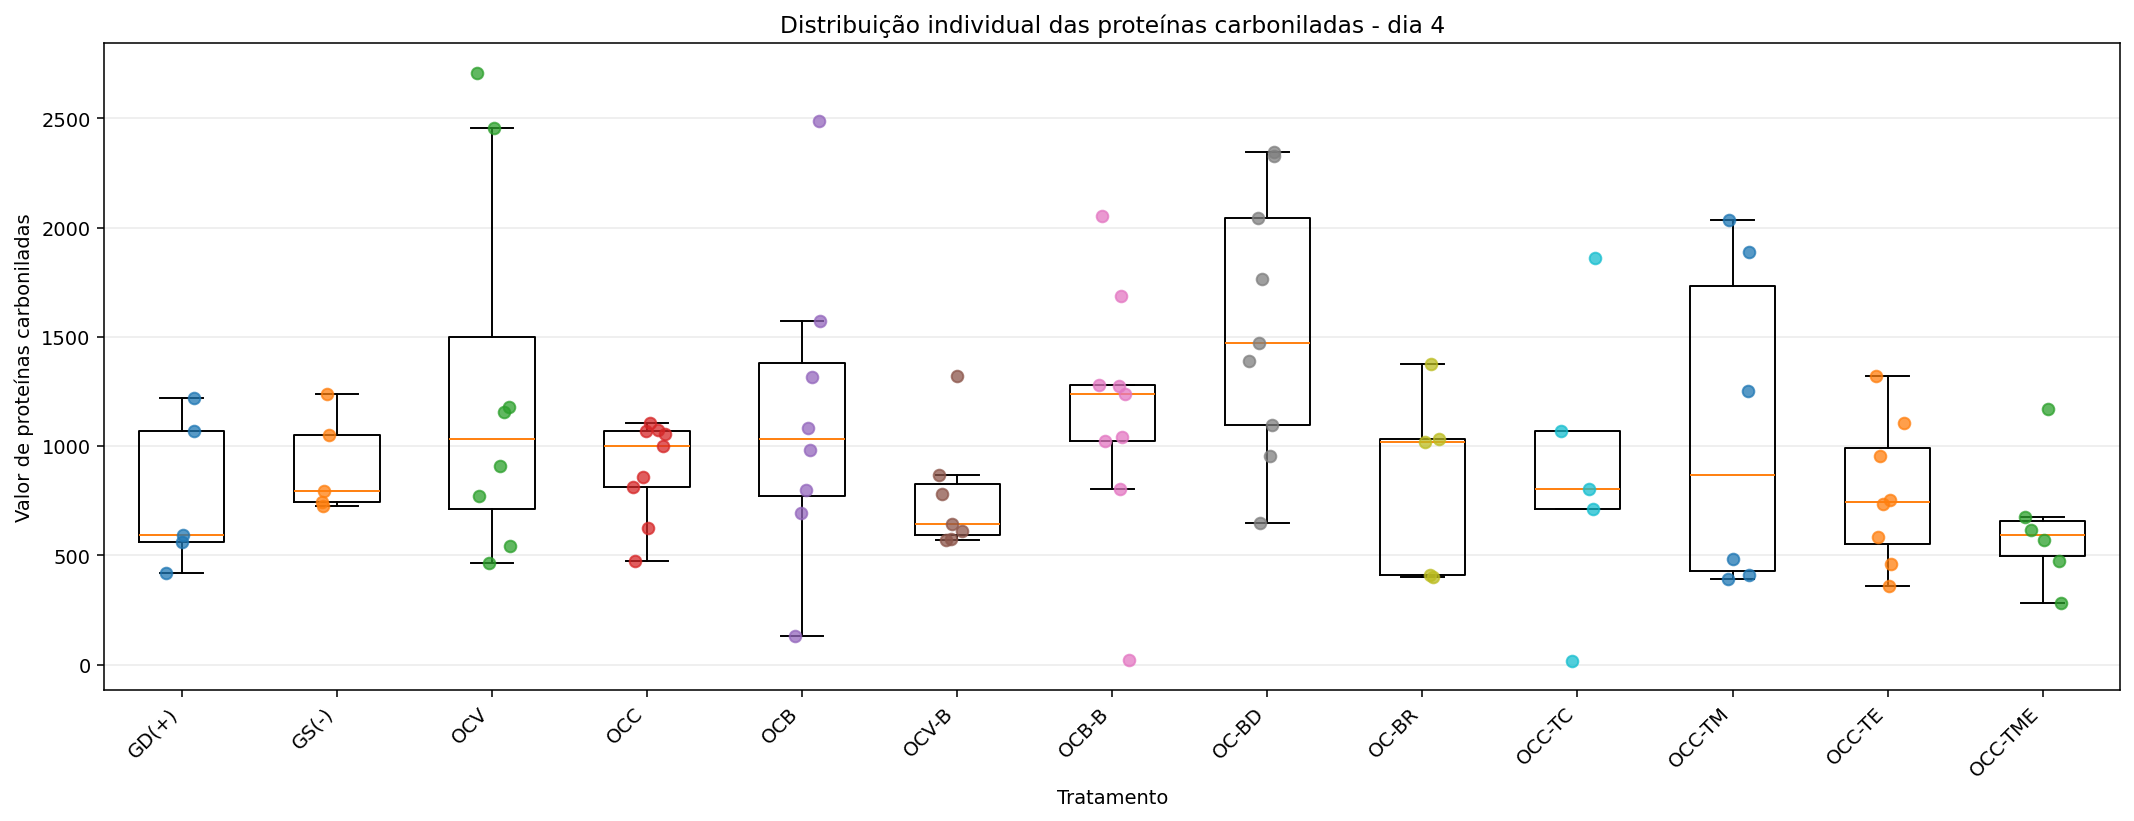

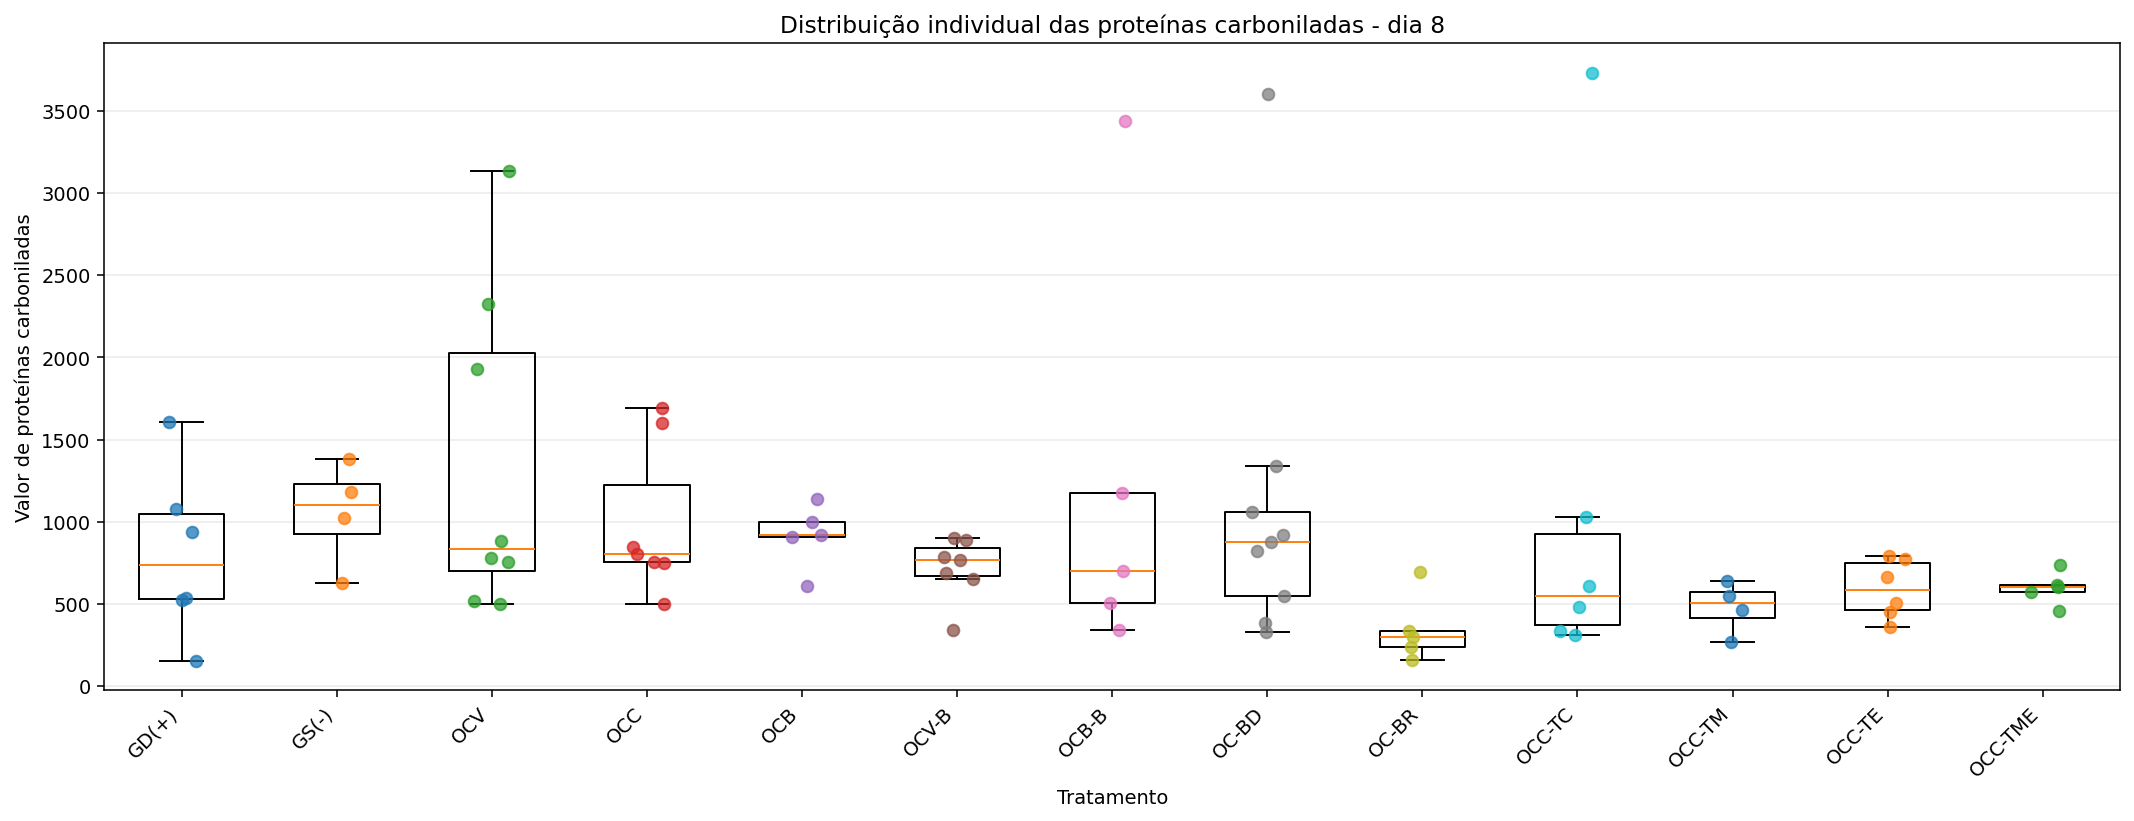


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_descritiva_proteinas_carboniladas_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_distribuicao_proteinas_carboniladas_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_proteinas_carboniladas_dia_8.png


In [47]:
# ETAPA 43 — Análise descritiva e gráficos das proteínas carboniladas

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "df_proteinas_carboniladas_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_proteinas_carboniladas_individual_longa "
        "não foi encontrada. Execute primeiro a Etapa 42."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Configurações
# =========================================================

tratamentos_proteinas_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

dias_esperados = [
    4,
    8
]

coluna_valor = (
    "Valor_Proteinas_Carboniladas"
)


# =========================================================
# 3. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    coluna_valor
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in (
        df_proteinas_carboniladas_individual_longa.columns
    )
]

if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na tabela de proteínas "
        f"carboniladas: {colunas_ausentes}"
    )


# =========================================================
# 4. Preparar cópia para análise
# =========================================================

dados_proteinas = (
    df_proteinas_carboniladas_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_proteinas["Tratamento"] = (
    dados_proteinas["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_proteinas["Dia"] = pd.to_numeric(
    dados_proteinas["Dia"],
    errors="coerce"
)

dados_proteinas[coluna_valor] = pd.to_numeric(
    dados_proteinas[coluna_valor],
    errors="coerce"
)


# =========================================================
# 5. Verificar valores inválidos
# =========================================================

linhas_invalidas = (
    dados_proteinas["Tratamento"].isna()
    | dados_proteinas["Dia"].isna()
    | dados_proteinas[coluna_valor].isna()
    | ~np.isfinite(
        dados_proteinas[coluna_valor]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_proteinas.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados "
        "de proteínas carboniladas."
    )


# =========================================================
# 6. Confirmar os critérios de exclusão
# =========================================================

if (
    dados_proteinas[coluna_valor] < 0
).any():

    raise ValueError(
        "A base analítica ainda contém valores negativos."
    )

if (
    dados_proteinas[coluna_valor] > 10_000
).any():

    raise ValueError(
        "A base analítica ainda contém valores "
        "superiores a 10.000."
    )


# =========================================================
# 7. Verificar tratamentos e dias
# =========================================================

dias_encontrados = sorted(
    dados_proteinas["Dia"]
    .astype(int)
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_proteinas["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_proteinas_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_proteinas_esperados)
)

if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 8. Confirmar os totais da Etapa 42
# =========================================================

total_dia_4 = int(
    (
        dados_proteinas["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_proteinas["Dia"] == 8
    ).sum()
)

if total_dia_4 != 90:

    raise ValueError(
        "O dia 4 deveria possuir 90 observações, "
        f"mas foram encontradas {total_dia_4}."
    )

if total_dia_8 != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas {total_dia_8}."
    )


print("Totais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 9. Calcular estatística descritiva
# =========================================================

df_descritiva_proteinas_carboniladas = (
    dados_proteinas
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            coluna_valor,
            "count"
        ),
        media=(
            coluna_valor,
            "mean"
        ),
        desvio_padrao=(
            coluna_valor,
            "std"
        ),
        minimo=(
            coluna_valor,
            "min"
        ),
        primeiro_quartil=(
            coluna_valor,
            lambda valores: valores.quantile(0.25)
        ),
        mediana=(
            coluna_valor,
            "median"
        ),
        terceiro_quartil=(
            coluna_valor,
            lambda valores: valores.quantile(0.75)
        ),
        maximo=(
            coluna_valor,
            "max"
        )
    )
)


# =========================================================
# 10. Calcular intervalo interquartil
# =========================================================

df_descritiva_proteinas_carboniladas[
    "intervalo_interquartil"
] = (
    df_descritiva_proteinas_carboniladas[
        "terceiro_quartil"
    ]
    - df_descritiva_proteinas_carboniladas[
        "primeiro_quartil"
    ]
)


# =========================================================
# 11. Organizar a ordem dos tratamentos
# =========================================================

indice_completo = pd.MultiIndex.from_product(
    [
        tratamentos_proteinas_esperados,
        dias_esperados
    ],
    names=[
        "Tratamento",
        "Dia"
    ]
)

df_descritiva_proteinas_carboniladas = (
    df_descritiva_proteinas_carboniladas
    .set_index(
        [
            "Tratamento",
            "Dia"
        ]
    )
    .reindex(
        indice_completo
    )
    .reset_index()
)


if (
    df_descritiva_proteinas_carboniladas["n"]
    .isna()
    .any()
):

    linhas_sem_resultado = (
        df_descritiva_proteinas_carboniladas.loc[
            df_descritiva_proteinas_carboniladas[
                "n"
            ].isna(),
            [
                "Tratamento",
                "Dia"
            ]
        ]
    )

    display(
        linhas_sem_resultado
    )

    raise ValueError(
        "Existem combinações de tratamento e dia "
        "sem observações."
    )


df_descritiva_proteinas_carboniladas["n"] = (
    df_descritiva_proteinas_carboniladas["n"]
    .astype(int)
)


# =========================================================
# 12. Exibir a estatística descritiva
# =========================================================

print(
    "\nEstatística descritiva das proteínas "
    "carboniladas:"
)

display(
    df_descritiva_proteinas_carboniladas.round(
        {
            "media": 4,
            "desvio_padrao": 4,
            "minimo": 4,
            "primeiro_quartil": 4,
            "mediana": 4,
            "terceiro_quartil": 4,
            "maximo": 4,
            "intervalo_interquartil": 4
        }
    )
)


# =========================================================
# 13. Identificar grupos com amostra pequena
# =========================================================

grupos_amostra_pequena = (
    df_descritiva_proteinas_carboniladas.loc[
        df_descritiva_proteinas_carboniladas[
            "n"
        ] < 3,
        [
            "Tratamento",
            "Dia",
            "n"
        ]
    ]
    .copy()
)


print(
    "\nGrupos com menos de três observações:"
)

if grupos_amostra_pequena.empty:

    print(
        "Nenhum grupo possui menos de três observações."
    )

else:

    display(
        grupos_amostra_pequena
    )


# =========================================================
# 14. Tabela de contagens
# =========================================================

tabela_contagem_proteinas_descritiva = (
    df_descritiva_proteinas_carboniladas
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_proteinas_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .astype(int)
)


print(
    "\nNúmero de observações por tratamento:"
)

display(
    tabela_contagem_proteinas_descritiva
)


# =========================================================
# 15. Criar os gráficos dos dias 4 e 8
# =========================================================

arquivos_graficos_proteinas = []

for dia in dias_esperados:

    dados_dia = (
        dados_proteinas.loc[
            dados_proteinas["Dia"] == dia
        ]
        .copy()
    )

    valores_boxplot = []
    posicoes_boxplot = []

    for posicao, tratamento in enumerate(
        tratamentos_proteinas_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                coluna_valor
            ]
            .to_numpy(dtype=float)
        )

        if len(valores) == 0:

            raise ValueError(
                f"O tratamento {tratamento} não possui "
                f"observações no dia {dia}."
            )

        valores_boxplot.append(
            valores
        )

        posicoes_boxplot.append(
            posicao
        )


    plt.close("all")

    fig, ax = plt.subplots(
        figsize=(
            16,
            7
        )
    )


    # -----------------------------------------------------
    # Boxplots
    # -----------------------------------------------------

    ax.boxplot(
        valores_boxplot,
        positions=posicoes_boxplot,
        widths=0.55,
        showfliers=False
    )


    # -----------------------------------------------------
    # Valores individuais
    # -----------------------------------------------------

    gerador_aleatorio = np.random.default_rng(
        20260729 + dia
    )

    for posicao, tratamento in enumerate(
        tratamentos_proteinas_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                coluna_valor
            ]
            .to_numpy(dtype=float)
        )

        deslocamento = gerador_aleatorio.uniform(
            -0.12,
            0.12,
            size=len(valores)
        )

        posicoes_pontos = (
            np.full(
                len(valores),
                posicao,
                dtype=float
            )
            + deslocamento
        )

        ax.scatter(
            posicoes_pontos,
            valores,
            alpha=0.75,
            zorder=3
        )


    # -----------------------------------------------------
    # Formatação
    # -----------------------------------------------------

    ax.set_title(
        "Distribuição individual das proteínas "
        f"carboniladas - dia {dia}"
    )

    ax.set_xlabel(
        "Tratamento"
    )

    ax.set_ylabel(
        "Valor de proteínas carboniladas"
    )

    ax.set_xticks(
        range(
            1,
            len(tratamentos_proteinas_esperados) + 1
        )
    )

    ax.set_xticklabels(
        tratamentos_proteinas_esperados,
        rotation=45,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.24,
        top=0.90
    )


    # -----------------------------------------------------
    # Salvar e exibir
    # -----------------------------------------------------

    arquivo_grafico = (
        PASTA_PROJETO
        / (
            "projeto001_distribuicao_proteinas_"
            f"carboniladas_dia_{dia}.png"
        )
    )

    fig.canvas.draw()

    fig.savefig(
        arquivo_grafico,
        dpi=300,
        format="png"
    )

    plt.show()

    plt.close(fig)

    arquivos_graficos_proteinas.append(
        arquivo_grafico
    )


# =========================================================
# 16. Salvar a estatística descritiva
# =========================================================

arquivo_descritiva_proteinas = (
    PASTA_PROJETO
    / (
        "projeto001_descritiva_proteinas_"
        "carboniladas_dias_4_8.csv"
    )
)


df_descritiva_proteinas_carboniladas.to_csv(
    arquivo_descritiva_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_descritiva_proteinas
)

for arquivo in arquivos_graficos_proteinas:

    print(
        arquivo
    )

## 44. Comparação global das proteínas carboniladas por permutação

Os valores individuais de proteínas carboniladas serão comparados entre os
13 tratamentos, separadamente nos dias 4 e 8.

Será utilizada a estatística H de Kruskal-Wallis, acompanhada de valor de p
calculado por 49.999 permutações.

A escolha desse procedimento considera:

- distribuições assimétricas;
- dispersões diferentes entre os grupos;
- tamanhos amostrais desiguais;
- presença de valores elevados preservados;
- ausência de garantia de normalidade.

Também será calculado o tamanho de efeito global por epsilon quadrado.

Valores menores de proteínas carboniladas representam menor oxidação de
proteínas. Entretanto, esta etapa avaliará apenas a existência de diferença
global entre os tratamentos.

Comparações específicas dos óleos com os controles somente serão realizadas
nos dias em que o teste global for significativo.

In [48]:
# ETAPA 44 — Teste global das proteínas carboniladas por permutação
# Kruskal-Wallis com 49.999 permutações, separadamente nos dias 4 e 8

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import kruskal, rankdata
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

NUMERO_PERMUTACOES_PROTEINAS = 49_999
SEMENTE_PROTEINAS = 20260729
NIVEL_SIGNIFICANCIA = 0.05

COLUNA_VALOR_PROTEINAS = (
    "Valor_Proteinas_Carboniladas"
)


# =========================================================
# 2. Verificações iniciais
# =========================================================

if (
    "df_proteinas_carboniladas_individual_longa"
    not in globals()
):
    raise RuntimeError(
        "A tabela "
        "df_proteinas_carboniladas_individual_longa "
        "não foi encontrada. Execute primeiro a Etapa 42."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(
    PASTA_PROJETO
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 3. Tratamentos esperados
# =========================================================

tratamentos_proteinas_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

dias_esperados = [
    4,
    8
]


# =========================================================
# 4. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_PROTEINAS
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in (
        df_proteinas_carboniladas_individual_longa.columns
    )
]

if colunas_ausentes:
    raise ValueError(
        "Colunas ausentes na tabela de proteínas "
        f"carboniladas: {colunas_ausentes}"
    )


# =========================================================
# 5. Preparar os dados
# =========================================================

dados_proteinas_teste = (
    df_proteinas_carboniladas_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_proteinas_teste["Tratamento"] = (
    dados_proteinas_teste["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_proteinas_teste["Dia"] = pd.to_numeric(
    dados_proteinas_teste["Dia"],
    errors="coerce"
)

dados_proteinas_teste[
    COLUNA_VALOR_PROTEINAS
] = pd.to_numeric(
    dados_proteinas_teste[
        COLUNA_VALOR_PROTEINAS
    ],
    errors="coerce"
)


# =========================================================
# 6. Verificar valores inválidos
# =========================================================

linhas_invalidas = (
    dados_proteinas_teste["Tratamento"].isna()
    | dados_proteinas_teste["Dia"].isna()
    | dados_proteinas_teste[
        COLUNA_VALOR_PROTEINAS
    ].isna()
    | ~np.isfinite(
        dados_proteinas_teste[
            COLUNA_VALOR_PROTEINAS
        ]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_proteinas_teste.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados "
        "de proteínas carboniladas."
    )


# =========================================================
# 7. Confirmar os critérios de exclusão
# =========================================================

if (
    dados_proteinas_teste[
        COLUNA_VALOR_PROTEINAS
    ] < 0
).any():

    raise ValueError(
        "A base analítica ainda contém valores negativos."
    )

if (
    dados_proteinas_teste[
        COLUNA_VALOR_PROTEINAS
    ] > 10_000
).any():

    raise ValueError(
        "A base analítica ainda contém valores "
        "superiores a 10.000."
    )


# =========================================================
# 8. Conferir tratamentos e dias
# =========================================================

dias_encontrados = sorted(
    dados_proteinas_teste["Dia"]
    .astype(int)
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_proteinas_teste["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_proteinas_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_proteinas_esperados)
)

if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 9. Confirmar os totais
# =========================================================

total_dia_4 = int(
    (
        dados_proteinas_teste["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_proteinas_teste["Dia"] == 8
    ).sum()
)

if total_dia_4 != 90:

    raise ValueError(
        "O dia 4 deveria possuir 90 observações, "
        f"mas foram encontradas {total_dia_4}."
    )

if total_dia_8 != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas {total_dia_8}."
    )

print("Totais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 10. Função de correção de empates
# =========================================================

def calcular_correcao_empates(
    valores
):

    _, contagens = np.unique(
        valores,
        return_counts=True
    )

    numero_total = len(
        valores
    )

    if numero_total < 2:

        raise ValueError(
            "Número insuficiente de observações."
        )

    numerador = np.sum(
        contagens**3
        - contagens
    )

    denominador = (
        numero_total**3
        - numero_total
    )

    correcao = (
        1.0
        - numerador / denominador
    )

    if correcao <= 0:

        raise ValueError(
            "Não foi possível calcular a correção "
            "de empates."
        )

    return float(
        correcao
    )


# =========================================================
# 11. Função de cálculo da estatística H
# =========================================================

def calcular_h_por_postos(
    postos,
    tamanhos_grupos,
    correcao_empates
):

    numero_total = len(
        postos
    )

    inicio = 0
    soma_componentes = 0.0

    for tamanho in tamanhos_grupos:

        final = (
            inicio
            + tamanho
        )

        soma_postos = np.sum(
            postos[inicio:final]
        )

        soma_componentes += (
            soma_postos**2
            / tamanho
        )

        inicio = final

    h_sem_correcao = (
        12.0
        / (
            numero_total
            * (
                numero_total
                + 1
            )
        )
        * soma_componentes
        - 3.0
        * (
            numero_total
            + 1
        )
    )

    h_corrigido = (
        h_sem_correcao
        / correcao_empates
    )

    return float(
        h_corrigido
    )


# =========================================================
# 12. Executar o teste nos dias 4 e 8
# =========================================================

resultados_globais_proteinas = []
contagens_teste_proteinas = []

inicio_etapa = time.perf_counter()

for dia in dias_esperados:

    print("\n" + "=" * 90)

    print(
        "PROCESSANDO PROTEÍNAS CARBONILADAS "
        f"— DIA {dia}"
    )

    dados_dia = (
        dados_proteinas_teste.loc[
            dados_proteinas_teste["Dia"] == dia
        ]
        .copy()
    )

    grupos = []
    tamanhos_grupos = []

    for tratamento in (
        tratamentos_proteinas_esperados
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                COLUNA_VALOR_PROTEINAS
            ]
            .to_numpy(
                dtype=float
            )
        )

        numero_observacoes = len(
            valores
        )

        contagens_teste_proteinas.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": numero_observacoes
            }
        )

        if numero_observacoes < 2:

            raise ValueError(
                f"O tratamento {tratamento} possui "
                f"somente {numero_observacoes} "
                f"observação(ões) no dia {dia}."
            )

        grupos.append(
            valores
        )

        tamanhos_grupos.append(
            numero_observacoes
        )


    numero_grupos = len(
        grupos
    )

    numero_total = sum(
        tamanhos_grupos
    )

    valores_concatenados = np.concatenate(
        grupos
    )

    postos = rankdata(
        valores_concatenados,
        method="average"
    )

    correcao_empates = (
        calcular_correcao_empates(
            valores_concatenados
        )
    )

    h_observado = calcular_h_por_postos(
        postos=postos,
        tamanhos_grupos=tamanhos_grupos,
        correcao_empates=correcao_empates
    )


    # -----------------------------------------------------
    # Conferência com scipy.stats.kruskal
    # -----------------------------------------------------

    resultado_assintotico = kruskal(
        *grupos,
        nan_policy="raise"
    )

    h_scipy = float(
        resultado_assintotico.statistic
    )

    p_assintotico = float(
        resultado_assintotico.pvalue
    )

    if not np.isclose(
        h_observado,
        h_scipy,
        rtol=1e-10,
        atol=1e-10
    ):

        raise RuntimeError(
            "A estatística H calculada manualmente "
            "não coincide com o resultado do SciPy."
        )


    # -----------------------------------------------------
    # Permutações
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        SEMENTE_PROTEINAS
        + dia
    )

    numero_extremos = 0

    inicio_dia = time.perf_counter()

    for _ in range(
        NUMERO_PERMUTACOES_PROTEINAS
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )

        h_permutado = calcular_h_por_postos(
            postos=postos_permutados,
            tamanhos_grupos=tamanhos_grupos,
            correcao_empates=correcao_empates
        )

        if h_permutado >= (
            h_observado
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        NUMERO_PERMUTACOES_PROTEINAS
        + 1
    )


    erro_padrao_monte_carlo = np.sqrt(
        valor_p_permutacao
        * (
            1.0
            - valor_p_permutacao
        )
        / (
            NUMERO_PERMUTACOES_PROTEINAS
            + 1
        )
    )


    # -----------------------------------------------------
    # Tamanho de efeito
    # -----------------------------------------------------

    denominador_efeito = (
        numero_total
        - numero_grupos
    )

    epsilon_quadrado = (
        h_observado
        - numero_grupos
        + 1
    ) / denominador_efeito

    epsilon_quadrado = min(
        1.0,
        max(
            0.0,
            float(
                epsilon_quadrado
            )
        )
    )


    # -----------------------------------------------------
    # Conclusão
    # -----------------------------------------------------

    if (
        valor_p_permutacao
        < NIVEL_SIGNIFICANCIA
    ):

        conclusao = (
            "Há evidência de diferença global entre "
            "os tratamentos."
        )

    else:

        conclusao = (
            "Não há evidência de diferença global "
            "entre os tratamentos."
        )


    tempo_dia = (
        time.perf_counter()
        - inicio_dia
    )


    resultados_globais_proteinas.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Menor_n": min(
                tamanhos_grupos
            ),
            "Maior_n": max(
                tamanhos_grupos
            ),
            "Estatistica_H": h_observado,
            "Graus_de_liberdade": (
                numero_grupos
                - 1
            ),
            "Valor_p_assintotico": p_assintotico,
            "Numero_de_permutacoes": (
                NUMERO_PERMUTACOES_PROTEINAS
            ),
            "Permutacoes_iguais_ou_maiores": (
                numero_extremos
            ),
            "Valor_p_permutacao": (
                valor_p_permutacao
            ),
            "Erro_padrao_Monte_Carlo": (
                erro_padrao_monte_carlo
            ),
            "Epsilon_quadrado": (
                epsilon_quadrado
            ),
            "Tempo_segundos": (
                tempo_dia
            ),
            "Conclusao_5_percent": (
                conclusao
            )
        }
    )


    print(
        f"H observado: {h_observado:.6f}"
    )

    print(
        f"p assintótico: {p_assintotico:.8f}"
    )

    print(
        "p por permutação: "
        f"{valor_p_permutacao:.8f}"
    )

    print(
        f"ε²: {epsilon_quadrado:.4f}"
    )

    print(
        f"Tempo: {tempo_dia:.2f} segundos"
    )

    print(
        conclusao
    )


# =========================================================
# 13. Criar as tabelas finais
# =========================================================

df_resultados_permutacao_proteinas = pd.DataFrame(
    resultados_globais_proteinas
)

df_contagens_teste_proteinas = pd.DataFrame(
    contagens_teste_proteinas
)

tabela_contagens_teste_proteinas = (
    df_contagens_teste_proteinas
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_proteinas_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
)


# =========================================================
# 14. Exibir os resultados
# =========================================================

print("\n" + "=" * 90)

print(
    "CONTAGENS UTILIZADAS NO TESTE"
)

display(
    tabela_contagens_teste_proteinas
)


print(
    "\nRESULTADOS GLOBAIS DAS "
    "PROTEÍNAS CARBONILADAS"
)

display(
    df_resultados_permutacao_proteinas.round(
        {
            "Estatistica_H": 6,
            "Valor_p_assintotico": 8,
            "Valor_p_permutacao": 8,
            "Erro_padrao_Monte_Carlo": 8,
            "Epsilon_quadrado": 4,
            "Tempo_segundos": 2
        }
    )
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)

print(
    "\nTempo total da Etapa 44: "
    f"{tempo_total:.2f} segundos"
)


# =========================================================
# 15. Salvar os resultados
# =========================================================

arquivo_teste_global_proteinas = (
    PASTA_PROJETO
    / (
        "projeto001_teste_global_permutacao_"
        "proteinas_carboniladas.csv"
    )
)

arquivo_contagens_teste_proteinas = (
    PASTA_PROJETO
    / (
        "projeto001_contagens_teste_global_"
        "proteinas_carboniladas.csv"
    )
)


df_resultados_permutacao_proteinas.to_csv(
    arquivo_teste_global_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

tabela_contagens_teste_proteinas.to_csv(
    arquivo_contagens_teste_proteinas,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_teste_global_proteinas
)

print(
    arquivo_contagens_teste_proteinas
)

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

PROCESSANDO PROTEÍNAS CARBONILADAS — DIA 4
H observado: 17.709319
p assintótico: 0.12480586
p por permutação: 0.11038000
ε²: 0.0741
Tempo: 2.63 segundos
Não há evidência de diferença global entre os tratamentos.

PROCESSANDO PROTEÍNAS CARBONILADAS — DIA 8
H observado: 21.760868
p assintótico: 0.04028895
p por permutação: 0.02716000
ε²: 0.1525
Tempo: 2.62 segundos
Há evidência de diferença global entre os tratamentos.

CONTAGENS UTILIZADAS NO TESTE


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



RESULTADOS GLOBAIS DAS PROTEÍNAS CARBONILADAS


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Menor_n,Maior_n,Estatistica_H,Graus_de_liberdade,Valor_p_assintotico,Numero_de_permutacoes,Permutacoes_iguais_ou_maiores,Valor_p_permutacao,Erro_padrao_Monte_Carlo,Epsilon_quadrado,Tempo_segundos,Conclusao_5_percent
0,4,13,90,5,9,17.709319,12,0.124806,49999,5518,0.11038,0.001401,0.0741,2.63,Não há evidência de diferença global entre os ...
1,8,13,77,4,9,21.760868,12,0.040289,49999,1357,0.02716,0.000727,0.1525,2.62,Há evidência de diferença global entre os trat...



Tempo total da Etapa 44: 5.29 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_teste_global_permutacao_proteinas_carboniladas.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_teste_global_proteinas_carboniladas.csv


## 45. Comparações das proteínas carboniladas com os controles no dia 8

Como o teste global por permutação revelou diferença significativa entre os
tratamentos no dia 8, serão realizadas comparações planejadas entre cada óleo
e os controles GD(+) e GS(-).

Será utilizado o teste bilateral de permutação baseado na estatística U de
Mann–Whitney, com 49.999 permutações por comparação.

Os valores de p das 22 comparações serão corrigidos conjuntamente pelo método
de Holm.

Também serão apresentados:

- tamanho amostral de cada grupo;
- medianas;
- diferença entre medianas;
- correlação bisserial de postos;
- magnitude e direção do efeito.

Para proteínas carboniladas, valores inferiores aos controles representam
menor oxidação proteica e, portanto, um resultado biologicamente favorável.

O dia 4 não será submetido a comparações múltiplas porque o teste global não
foi significativo.

In [49]:
# ETAPA 45 — Comparações das proteínas carboniladas com os controles
# Somente dia 8
# Mann-Whitney por permutação com correção conjunta de Holm

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import rankdata, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

DIA_ANALISADO_PROTEINAS = 8
NUMERO_PERMUTACOES_PARES_PROTEINAS = 49_999
SEMENTE_PARES_PROTEINAS = 20260731
NIVEL_SIGNIFICANCIA = 0.05

COLUNA_VALOR_PROTEINAS = (
    "Valor_Proteinas_Carboniladas"
)


# =========================================================
# 2. Verificações iniciais
# =========================================================

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(PASTA_PROJETO)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 3. Recuperar a base analítica, caso necessário
# =========================================================

if (
    "df_proteinas_carboniladas_individual_longa"
    not in globals()
):

    arquivo_base_proteinas = (
        PASTA_PROJETO
        / (
            "projeto001_proteinas_carboniladas_"
            "individual_analise.csv"
        )
    )

    if not arquivo_base_proteinas.exists():

        raise RuntimeError(
            "A base analítica das proteínas carboniladas "
            "não foi encontrada. Execute primeiro a Etapa 42."
        )

    df_proteinas_carboniladas_individual_longa = (
        pd.read_csv(
            arquivo_base_proteinas,
            sep=";",
            decimal=",",
            encoding="utf-8-sig"
        )
    )


# =========================================================
# 4. Recuperar o teste global, caso necessário
# =========================================================

if (
    "df_resultados_permutacao_proteinas"
    not in globals()
):

    arquivo_global_proteinas = (
        PASTA_PROJETO
        / (
            "projeto001_teste_global_permutacao_"
            "proteinas_carboniladas.csv"
        )
    )

    if not arquivo_global_proteinas.exists():

        raise RuntimeError(
            "O teste global das proteínas carboniladas "
            "não foi encontrado. Execute primeiro a Etapa 44."
        )

    df_resultados_permutacao_proteinas = (
        pd.read_csv(
            arquivo_global_proteinas,
            sep=";",
            decimal=",",
            encoding="utf-8-sig"
        )
    )


# =========================================================
# 5. Confirmar os resultados globais
# =========================================================

colunas_globais_necessarias = [
    "Dia",
    "Valor_p_permutacao"
]

colunas_globais_ausentes = [
    coluna
    for coluna in colunas_globais_necessarias
    if coluna not in (
        df_resultados_permutacao_proteinas.columns
    )
]

if colunas_globais_ausentes:

    raise ValueError(
        "Colunas ausentes no resultado global: "
        f"{colunas_globais_ausentes}"
    )


resultado_global_dia_4 = (
    df_resultados_permutacao_proteinas.loc[
        df_resultados_permutacao_proteinas[
            "Dia"
        ] == 4
    ]
)

resultado_global_dia_8 = (
    df_resultados_permutacao_proteinas.loc[
        df_resultados_permutacao_proteinas[
            "Dia"
        ] == 8
    ]
)


if len(resultado_global_dia_4) != 1:

    raise ValueError(
        "Não foi encontrado exatamente um resultado "
        "global para o dia 4."
    )


if len(resultado_global_dia_8) != 1:

    raise ValueError(
        "Não foi encontrado exatamente um resultado "
        "global para o dia 8."
    )


p_global_dia_4 = float(
    resultado_global_dia_4[
        "Valor_p_permutacao"
    ].iloc[0]
)

p_global_dia_8 = float(
    resultado_global_dia_8[
        "Valor_p_permutacao"
    ].iloc[0]
)


print("Resultados globais conferidos:")

print(
    f"Dia 4: p por permutação = "
    f"{p_global_dia_4:.8f}"
)

print(
    f"Dia 8: p por permutação = "
    f"{p_global_dia_8:.8f}"
)


if p_global_dia_4 < NIVEL_SIGNIFICANCIA:

    raise ValueError(
        "O resultado global do dia 4 está significativo. "
        "Revise a Etapa 44 antes de continuar."
    )


if p_global_dia_8 >= NIVEL_SIGNIFICANCIA:

    raise ValueError(
        "O teste global do dia 8 não foi significativo. "
        "As comparações múltiplas não serão executadas."
    )


# =========================================================
# 6. Definir controles e óleos
# =========================================================

controles_proteinas = [
    "GD(+)",
    "GS(-)"
]

oleos_proteinas = [
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

tratamentos_esperados = (
    controles_proteinas
    + oleos_proteinas
)


# =========================================================
# 7. Preparar os dados do dia 8
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_PROTEINAS
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in (
        df_proteinas_carboniladas_individual_longa.columns
    )
]

if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base analítica: "
        f"{colunas_ausentes}"
    )


dados_proteinas_dia_8 = (
    df_proteinas_carboniladas_individual_longa.loc[
        df_proteinas_carboniladas_individual_longa[
            "Dia"
        ] == DIA_ANALISADO_PROTEINAS,
        colunas_necessarias
    ]
    .copy()
)


dados_proteinas_dia_8["Tratamento"] = (
    dados_proteinas_dia_8["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_proteinas_dia_8["Dia"] = pd.to_numeric(
    dados_proteinas_dia_8["Dia"],
    errors="coerce"
)

dados_proteinas_dia_8[
    COLUNA_VALOR_PROTEINAS
] = pd.to_numeric(
    dados_proteinas_dia_8[
        COLUNA_VALOR_PROTEINAS
    ],
    errors="coerce"
)


# =========================================================
# 8. Validar os dados
# =========================================================

linhas_invalidas = (
    dados_proteinas_dia_8["Tratamento"].isna()
    | dados_proteinas_dia_8["Dia"].isna()
    | dados_proteinas_dia_8[
        COLUNA_VALOR_PROTEINAS
    ].isna()
    | ~np.isfinite(
        dados_proteinas_dia_8[
            COLUNA_VALOR_PROTEINAS
        ]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_proteinas_dia_8.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados do dia 8."
    )


if (
    dados_proteinas_dia_8[
        COLUNA_VALOR_PROTEINAS
    ] < 0
).any():

    raise ValueError(
        "A base do dia 8 contém valores negativos."
    )


if (
    dados_proteinas_dia_8[
        COLUNA_VALOR_PROTEINAS
    ] > 10_000
).any():

    raise ValueError(
        "A base do dia 8 contém valores superiores "
        "a 10.000."
    )


if len(dados_proteinas_dia_8) != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas "
        f"{len(dados_proteinas_dia_8)}."
    )


tratamentos_encontrados = set(
    dados_proteinas_dia_8[
        "Tratamento"
    ].unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_esperados)
)

if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes no dia 8: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos no dia 8: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 9. Classificar a magnitude do efeito
# =========================================================

def classificar_magnitude_bisserial(
    valor
):

    valor_absoluto = abs(
        valor
    )

    if valor_absoluto < 0.10:
        return "Desprezível"

    if valor_absoluto < 0.30:
        return "Pequeno"

    if valor_absoluto < 0.50:
        return "Moderado"

    return "Grande"


# =========================================================
# 10. Teste U bilateral por permutação
# =========================================================

def teste_u_por_permutacao(
    valores_oleo,
    valores_controle,
    numero_permutacoes,
    semente
):

    valores_oleo = np.asarray(
        valores_oleo,
        dtype=float
    )

    valores_controle = np.asarray(
        valores_controle,
        dtype=float
    )

    n_oleo = len(
        valores_oleo
    )

    n_controle = len(
        valores_controle
    )

    if n_oleo < 2 or n_controle < 2:

        raise ValueError(
            "Cada grupo deve possuir pelo menos "
            "duas observações."
        )


    valores_combinados = np.concatenate(
        [
            valores_oleo,
            valores_controle
        ]
    )

    postos = rankdata(
        valores_combinados,
        method="average"
    )


    soma_postos_oleo = np.sum(
        postos[:n_oleo]
    )

    u_observado = (
        soma_postos_oleo
        - n_oleo
        * (
            n_oleo + 1
        )
        / 2
    )


    centro_u = (
        n_oleo
        * n_controle
        / 2
    )

    distancia_observada = abs(
        u_observado
        - centro_u
    )


    gerador = np.random.default_rng(
        semente
    )

    numero_extremos = 0


    for _ in range(
        numero_permutacoes
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )

        soma_postos_permutada = np.sum(
            postos_permutados[:n_oleo]
        )

        u_permutado = (
            soma_postos_permutada
            - n_oleo
            * (
                n_oleo + 1
            )
            / 2
        )

        distancia_permutada = abs(
            u_permutado
            - centro_u
        )

        if distancia_permutada >= (
            distancia_observada
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        numero_permutacoes
        + 1
    )


    correlacao_bisserial = (
        2.0
        * u_observado
        / (
            n_oleo
            * n_controle
        )
        - 1.0
    )


    return {
        "Estatistica_U": float(
            u_observado
        ),
        "Valor_p_permutacao": float(
            valor_p_permutacao
        ),
        "Permutacoes_iguais_ou_maiores": int(
            numero_extremos
        ),
        "Correlacao_bisserial_postos": float(
            correlacao_bisserial
        )
    }


# =========================================================
# 11. Executar as 22 comparações
# =========================================================

resultados_comparacoes = []

contador_comparacao = 0

inicio_etapa = time.perf_counter()


for controle in controles_proteinas:

    valores_controle = (
        dados_proteinas_dia_8.loc[
            dados_proteinas_dia_8[
                "Tratamento"
            ] == controle,
            COLUNA_VALOR_PROTEINAS
        ]
        .to_numpy(
            dtype=float
        )
    )


    for oleo in oleos_proteinas:

        contador_comparacao += 1

        valores_oleo = (
            dados_proteinas_dia_8.loc[
                dados_proteinas_dia_8[
                    "Tratamento"
                ] == oleo,
                COLUNA_VALOR_PROTEINAS
            ]
            .to_numpy(
                dtype=float
            )
        )


        resultado_permutacao = (
            teste_u_por_permutacao(
                valores_oleo=valores_oleo,
                valores_controle=valores_controle,
                numero_permutacoes=(
                    NUMERO_PERMUTACOES_PARES_PROTEINAS
                ),
                semente=(
                    SEMENTE_PARES_PROTEINAS
                    + contador_comparacao
                )
            )
        )


        resultado_assintotico = mannwhitneyu(
            valores_oleo,
            valores_controle,
            alternative="two-sided",
            method="asymptotic"
        )


        mediana_oleo = float(
            np.median(
                valores_oleo
            )
        )

        mediana_controle = float(
            np.median(
                valores_controle
            )
        )

        diferenca_medianas = (
            mediana_oleo
            - mediana_controle
        )


        efeito = resultado_permutacao[
            "Correlacao_bisserial_postos"
        ]


        if efeito < 0:

            direcao = (
                "Óleo apresentou tendência a menor "
                "oxidação proteica"
            )

            interpretacao_biologica = (
                "Favorável"
            )

        elif efeito > 0:

            direcao = (
                "Óleo apresentou tendência a maior "
                "oxidação proteica"
            )

            interpretacao_biologica = (
                "Desfavorável"
            )

        else:

            direcao = (
                "Não houve direção predominante"
            )

            interpretacao_biologica = (
                "Neutra"
            )


        resultados_comparacoes.append(
            {
                "Dia": DIA_ANALISADO_PROTEINAS,
                "Oleo": oleo,
                "Controle": controle,
                "n_Oleo": len(
                    valores_oleo
                ),
                "n_Controle": len(
                    valores_controle
                ),
                "Mediana_Oleo": mediana_oleo,
                "Mediana_Controle": mediana_controle,
                "Diferenca_Medianas": diferenca_medianas,
                "Estatistica_U": resultado_permutacao[
                    "Estatistica_U"
                ],
                "Valor_p_assintotico": float(
                    resultado_assintotico.pvalue
                ),
                "Numero_de_permutacoes": (
                    NUMERO_PERMUTACOES_PARES_PROTEINAS
                ),
                "Permutacoes_iguais_ou_maiores": (
                    resultado_permutacao[
                        "Permutacoes_iguais_ou_maiores"
                    ]
                ),
                "Valor_p_permutacao": (
                    resultado_permutacao[
                        "Valor_p_permutacao"
                    ]
                ),
                "Correlacao_bisserial_postos": efeito,
                "Magnitude_efeito": (
                    classificar_magnitude_bisserial(
                        efeito
                    )
                ),
                "Direcao_efeito": direcao,
                "Interpretacao_biologica": (
                    interpretacao_biologica
                )
            }
        )


# =========================================================
# 12. Correção conjunta de Holm
# =========================================================

df_comparacoes_proteinas = pd.DataFrame(
    resultados_comparacoes
)


if len(df_comparacoes_proteinas) != 22:

    raise RuntimeError(
        "Eram esperadas 22 comparações, "
        f"mas foram produzidas "
        f"{len(df_comparacoes_proteinas)}."
    )


valores_p = (
    df_comparacoes_proteinas[
        "Valor_p_permutacao"
    ]
    .to_numpy(
        dtype=float
    )
)


rejeitar_h0, valores_p_holm, _, _ = multipletests(
    valores_p,
    alpha=NIVEL_SIGNIFICANCIA,
    method="holm"
)


df_comparacoes_proteinas[
    "Valor_p_Holm"
] = valores_p_holm


df_comparacoes_proteinas[
    "Significativo_Holm_5_percent"
] = rejeitar_h0


df_comparacoes_proteinas[
    "Conclusao"
] = np.where(
    df_comparacoes_proteinas[
        "Significativo_Holm_5_percent"
    ],
    (
        "Diferença significativa após "
        "correção de Holm"
    ),
    (
        "Diferença não significativa após "
        "correção de Holm"
    )
)


# =========================================================
# 13. Ordenar os resultados
# =========================================================

df_comparacoes_proteinas = (
    df_comparacoes_proteinas
    .sort_values(
        [
            "Controle",
            "Valor_p_Holm",
            "Oleo"
        ]
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 14. Exibir resultados por controle
# =========================================================

for controle in controles_proteinas:

    print("\n" + "=" * 110)

    print(
        "PROTEÍNAS CARBONILADAS — DIA 8 — "
        f"ÓLEOS VERSUS {controle}"
    )


    tabela_exibicao = (
        df_comparacoes_proteinas.loc[
            df_comparacoes_proteinas[
                "Controle"
            ] == controle,
            [
                "Oleo",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Significativo_Holm_5_percent",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito",
                "Interpretacao_biologica"
            ]
        ]
    )


    display(
        tabela_exibicao.round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 15. Selecionar comparações significativas
# =========================================================

df_comparacoes_significativas_proteinas = (
    df_comparacoes_proteinas.loc[
        df_comparacoes_proteinas[
            "Significativo_Holm_5_percent"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 110)

print(
    "COMPARAÇÕES SIGNIFICATIVAS DAS PROTEÍNAS "
    "CARBONILADAS APÓS CORREÇÃO DE HOLM"
)


if df_comparacoes_significativas_proteinas.empty:

    print(
        "Nenhuma comparação permaneceu significativa "
        "após a correção de Holm."
    )

else:

    display(
        df_comparacoes_significativas_proteinas[
            [
                "Dia",
                "Oleo",
                "Controle",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito",
                "Interpretacao_biologica"
            ]
        ].round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 16. Salvar os resultados
# =========================================================

arquivo_comparacoes_proteinas = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_proteinas_"
        "carboniladas_dia8_permutacao_holm.csv"
    )
)

arquivo_significativas_proteinas = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_significativas_"
        "proteinas_carboniladas.csv"
    )
)


df_comparacoes_proteinas.to_csv(
    arquivo_comparacoes_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_comparacoes_significativas_proteinas.to_csv(
    arquivo_significativas_proteinas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)


print(
    f"\nTempo total da Etapa 45: "
    f"{tempo_total:.2f} segundos"
)

print("\nArquivos salvos:")

print(
    arquivo_comparacoes_proteinas
)

print(
    arquivo_significativas_proteinas
)

Resultados globais conferidos:
Dia 4: p por permutação = 0.11038000
Dia 8: p por permutação = 0.02716000

PROTEÍNAS CARBONILADAS — DIA 8 — ÓLEOS VERSUS GD(+)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
0,OC-BD,9,6,878.7092,738.1244,140.5848,0.86082,1.0,False,0.0741,Desprezível,Óleo apresentou tendência a maior oxidação pro...,Desfavorável
1,OC-BR,5,6,298.7023,738.1244,-439.4221,0.17954,1.0,False,-0.5333,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
2,OCB,5,6,921.4997,738.1244,183.3753,0.66038,1.0,False,0.2000,Pequeno,Óleo apresentou tendência a maior oxidação pro...,Desfavorável
3,OCB-B,5,6,698.5824,738.1244,-39.5420,0.93090,1.0,False,0.0667,Desprezível,Óleo apresentou tendência a maior oxidação pro...,Desfavorável
4,OCC,7,6,803.2368,738.1244,65.1124,0.73370,1.0,False,0.1429,Pequeno,Óleo apresentou tendência a maior oxidação pro...,Desfavorável
5,OCC-TC,6,6,546.6718,738.1244,-191.4525,0.81710,1.0,False,-0.1111,Pequeno,Óleo apresentou tendência a menor oxidação pro...,Favorável
6,OCC-TE,6,6,584.4616,738.1244,-153.6627,0.40166,1.0,False,-0.3333,Moderado,Óleo apresentou tendência a menor oxidação pro...,Favorável
7,OCC-TM,4,6,506.9941,738.1244,-231.1303,0.47438,1.0,False,-0.3333,Moderado,Óleo apresentou tendência a menor oxidação pro...,Favorável
8,OCC-TME,5,6,605.3147,738.1244,-132.8097,0.79160,1.0,False,-0.1333,Pequeno,Óleo apresentou tendência a menor oxidação pro...,Favorável
9,OCV,8,6,832.3698,738.1244,94.2454,0.57156,1.0,False,0.2083,Pequeno,Óleo apresentou tendência a maior oxidação pro...,Desfavorável



PROTEÍNAS CARBONILADAS — DIA 8 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
11,OC-BR,5,4,298.7023,1099.934,-801.2317,0.03170,0.6974,False,-0.9000,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
12,OCC-TME,5,4,605.3147,1099.934,-494.6193,0.03176,0.6974,False,-0.9000,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
13,OC-BD,9,4,878.7092,1099.934,-221.2248,0.41264,1.0000,False,-0.3333,Moderado,Óleo apresentou tendência a menor oxidação pro...,Favorável
14,OCB,5,4,921.4997,1099.934,-178.4343,0.29134,1.0000,False,-0.5000,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
15,OCB-B,5,4,698.5824,1099.934,-401.3516,0.55594,1.0000,False,-0.3000,Moderado,Óleo apresentou tendência a menor oxidação pro...,Favorável
16,OCC,7,4,803.2368,1099.934,-296.6972,0.79032,1.0000,False,-0.1429,Pequeno,Óleo apresentou tendência a menor oxidação pro...,Favorável
17,OCC-TC,6,4,546.6718,1099.934,-553.2622,0.25658,1.0000,False,-0.5000,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
18,OCC-TE,6,4,584.4616,1099.934,-515.4724,0.06488,1.0000,False,-0.7500,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
19,OCC-TM,4,4,506.9941,1099.934,-592.9399,0.05782,1.0000,False,-0.8750,Grande,Óleo apresentou tendência a menor oxidação pro...,Favorável
20,OCV,8,4,832.3698,1099.934,-267.5642,0.93470,1.0000,False,-0.0625,Desprezível,Óleo apresentou tendência a menor oxidação pro...,Favorável



COMPARAÇÕES SIGNIFICATIVAS DAS PROTEÍNAS CARBONILADAS APÓS CORREÇÃO DE HOLM
Nenhuma comparação permaneceu significativa após a correção de Holm.

Tempo total da Etapa 45: 8.65 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_comparacoes_proteinas_carboniladas_dia8_permutacao_holm.csv
/kaggle/working/projeto001_resultados/projeto001_comparacoes_significativas_proteinas_carboniladas.csv


## 46. Inspeção dos dados de MDA

Nesta etapa será examinada exclusivamente a aba relacionada ao MDA.

Serão verificados:

- nome exato da aba;
- dimensão da planilha;
- localização dos 13 tratamentos;
- posição dos cabeçalhos dos dias;
- organização das repetições;
- quantidade de valores numéricos por coluna;
- presença de valores negativos, valores muito elevados e células vazias.

Nenhum valor será excluído, transformado, imputado ou analisado
estatisticamente nesta etapa.

In [50]:
# ETAPA 46 — Inspeção da estrutura dos dados de MDA

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

ARQUIVO_EXCEL = Path(ARQUIVO_EXCEL)
PASTA_PROJETO = Path(PASTA_PROJETO)

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n{ARQUIVO_EXCEL}"
    )

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


def converter_numero_inspecao(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):
        return float(valor)

    texto = str(valor).strip()

    if texto == "":
        return np.nan

    if "," in texto and "." in texto:

        if texto.rfind(",") > texto.rfind("."):

            texto = texto.replace(".", "")
            texto = texto.replace(",", ".")

        else:

            texto = texto.replace(",", "")

    elif "," in texto:

        texto = texto.replace(",", ".")

    try:

        return float(texto)

    except ValueError:

        return np.nan


# =========================================================
# 3. Ler os nomes das abas
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = arquivo_excel.sheet_names


print("Arquivo utilizado:")

print(
    ARQUIVO_EXCEL
)

print("\nAbas presentes no arquivo:")

for nome_aba in nomes_abas:

    print(
        "-",
        repr(nome_aba)
    )


# =========================================================
# 4. Localizar exclusivamente a aba de MDA
# =========================================================

abas_mda = []

for nome_aba in nomes_abas:

    nome_normalizado = normalizar_texto(
        nome_aba
    )

    if "mda" in nome_normalizado:

        abas_mda.append(
            nome_aba
        )


if len(abas_mda) == 0:

    raise RuntimeError(
        "Nenhuma aba contendo a identificação MDA "
        "foi localizada."
    )


if len(abas_mda) > 1:

    print(
        "\nMais de uma aba contendo MDA foi localizada:"
    )

    for nome_aba in abas_mda:

        print(
            "-",
            repr(nome_aba)
        )

    raise RuntimeError(
        "Não foi possível selecionar automaticamente "
        "uma única aba de MDA."
    )


NOME_ABA_MDA = abas_mda[0]


print("\nAba selecionada:")

print(
    repr(NOME_ABA_MDA)
)


# =========================================================
# 5. Ler a aba sem assumir cabeçalho
# =========================================================

mda_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_MDA,
    header=None,
    engine="openpyxl"
)


print("\nDimensão original da aba:")

print(
    f"{mda_bruta.shape[0]} linhas × "
    f"{mda_bruta.shape[1]} colunas"
)


if mda_bruta.empty:

    raise RuntimeError(
        "A aba de MDA está vazia."
    )


# =========================================================
# 6. Remover somente margens totalmente vazias
# =========================================================

linhas_com_conteudo = (
    mda_bruta
    .notna()
    .any(axis=1)
)

colunas_com_conteudo = (
    mda_bruta
    .notna()
    .any(axis=0)
)


if not linhas_com_conteudo.any():

    raise RuntimeError(
        "Nenhuma linha com conteúdo foi localizada."
    )


if not colunas_com_conteudo.any():

    raise RuntimeError(
        "Nenhuma coluna com conteúdo foi localizada."
    )


mda_inspecao = mda_bruta.loc[
    linhas_com_conteudo,
    colunas_com_conteudo
].copy()


# =========================================================
# 7. Preservar as referências reais do Excel
# =========================================================

mda_inspecao.index = (
    mda_inspecao.index + 1
)

mda_inspecao.index.name = (
    "Linha_Excel"
)


mda_inspecao.columns = [
    get_column_letter(
        int(indice_coluna) + 1
    )
    for indice_coluna in mda_inspecao.columns
]


print("\nIntervalo localizado:")

print(
    f"Linhas do Excel: "
    f"{mda_inspecao.index.min()} até "
    f"{mda_inspecao.index.max()}"
)

print(
    f"Colunas do Excel: "
    f"{mda_inspecao.columns[0]} até "
    f"{mda_inspecao.columns[-1]}"
)


# =========================================================
# 8. Exibir a estrutura completa
# =========================================================

print("\nEstrutura completa da aba de MDA:")

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", 400,
    "display.max_colwidth", 120
):

    display(
        mda_inspecao
    )


# =========================================================
# 9. Definir os tratamentos esperados
# =========================================================

tratamentos_mda_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento in tratamentos_mda_esperados
}


# =========================================================
# 10. Localizar os tratamentos
# =========================================================

registros_tratamentos = []

for linha_excel, linha in mda_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        codigo = normalizar_tratamento(
            valor_original
        )

        if codigo in mapa_tratamentos:

            registros_tratamentos.append(
                {
                    "Tratamento": mapa_tratamentos[
                        codigo
                    ],
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": coluna_excel,
                    "Valor_original": valor_original
                }
            )


df_ocorrencias_tratamentos_mda = pd.DataFrame(
    registros_tratamentos
)


if df_ocorrencias_tratamentos_mda.empty:

    raise RuntimeError(
        "Nenhum dos 13 tratamentos foi localizado "
        "na aba de MDA."
    )


df_ocorrencias_tratamentos_mda = (
    df_ocorrencias_tratamentos_mda
    .sort_values(
        [
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(drop=True)
)


print("\nOcorrências dos tratamentos:")

display(
    df_ocorrencias_tratamentos_mda
)


# =========================================================
# 11. Conferir tratamentos ausentes ou repetidos
# =========================================================

contagem_tratamentos_mda = (
    df_ocorrencias_tratamentos_mda[
        "Tratamento"
    ]
    .value_counts()
    .reindex(
        tratamentos_mda_esperados,
        fill_value=0
    )
    .rename(
        "Numero_de_ocorrencias"
    )
    .to_frame()
)


print("\nContagem de ocorrências por tratamento:")

display(
    contagem_tratamentos_mda
)


tratamentos_ausentes = (
    contagem_tratamentos_mda.loc[
        contagem_tratamentos_mda[
            "Numero_de_ocorrencias"
        ] == 0
    ]
    .index
    .tolist()
)


tratamentos_repetidos = (
    contagem_tratamentos_mda.loc[
        contagem_tratamentos_mda[
            "Numero_de_ocorrencias"
        ] > 1
    ]
    .index
    .tolist()
)


if tratamentos_ausentes:

    print("\nTratamentos ausentes:")

    print(
        tratamentos_ausentes
    )

else:

    print(
        "\nTodos os 13 tratamentos foram localizados."
    )


if tratamentos_repetidos:

    print("\nTratamentos repetidos:")

    print(
        tratamentos_repetidos
    )


# =========================================================
# 12. Localizar possíveis cabeçalhos dos dias
# =========================================================

registros_cabecalhos_dias = []

for linha_excel, linha in mda_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        texto = normalizar_texto(
            valor_original
        )

        if texto in {
            "dia4",
            "d4",
            "4dias"
        }:

            registros_cabecalhos_dias.append(
                {
                    "Dia": 4,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": coluna_excel,
                    "Valor_original": valor_original
                }
            )

        elif texto in {
            "dia8",
            "d8",
            "8dias"
        }:

            registros_cabecalhos_dias.append(
                {
                    "Dia": 8,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": coluna_excel,
                    "Valor_original": valor_original
                }
            )


df_cabecalhos_dias_mda = pd.DataFrame(
    registros_cabecalhos_dias
)


print("\nPossíveis cabeçalhos dos dias:")

if df_cabecalhos_dias_mda.empty:

    print(
        "Nenhum cabeçalho explícito foi localizado."
    )

else:

    display(
        df_cabecalhos_dias_mda
    )


# =========================================================
# 13. Contar conteúdo e valores numéricos por coluna
# =========================================================

registros_contagem_colunas = []

for coluna_excel in mda_inspecao.columns:

    valores_convertidos = (
        mda_inspecao[coluna_excel]
        .apply(
            converter_numero_inspecao
        )
    )

    valores_numericos = (
        valores_convertidos.dropna()
    )


    registros_contagem_colunas.append(
        {
            "Coluna_Excel": coluna_excel,
            "Celulas_com_conteudo": int(
                mda_inspecao[
                    coluna_excel
                ].notna().sum()
            ),
            "Valores_numericos": int(
                valores_numericos.shape[0]
            ),
            "Valores_negativos": int(
                (
                    valores_numericos < 0
                ).sum()
            ),
            "Valores_iguais_a_zero": int(
                (
                    valores_numericos == 0
                ).sum()
            ),
            "Valores_acima_de_10000": int(
                (
                    valores_numericos > 10_000
                ).sum()
            ),
            "Menor_valor_numerico": (
                float(
                    valores_numericos.min()
                )
                if not valores_numericos.empty
                else np.nan
            ),
            "Maior_valor_numerico": (
                float(
                    valores_numericos.max()
                )
                if not valores_numericos.empty
                else np.nan
            )
        }
    )


df_contagem_colunas_mda = pd.DataFrame(
    registros_contagem_colunas
)


print("\nAuditoria por coluna:")

display(
    df_contagem_colunas_mda
)


# =========================================================
# 14. Localizar todos os valores negativos
# =========================================================

registros_valores_negativos = []

registros_valores_acima_10000 = []


for linha_excel, linha in mda_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        valor_numerico = converter_numero_inspecao(
            valor_original
        )

        if pd.isna(valor_numerico):

            continue


        celula_excel = (
            f"{coluna_excel}{linha_excel}"
        )


        if valor_numerico < 0:

            registros_valores_negativos.append(
                {
                    "Celula_Excel": celula_excel,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": coluna_excel,
                    "Valor": valor_numerico
                }
            )


        if valor_numerico > 10_000:

            registros_valores_acima_10000.append(
                {
                    "Celula_Excel": celula_excel,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": coluna_excel,
                    "Valor": valor_numerico
                }
            )


df_valores_negativos_mda = pd.DataFrame(
    registros_valores_negativos
)

df_valores_acima_10000_mda = pd.DataFrame(
    registros_valores_acima_10000
)


print("\nValores negativos encontrados:")

if df_valores_negativos_mda.empty:

    print(
        "Nenhum valor negativo foi encontrado."
    )

else:

    display(
        df_valores_negativos_mda
    )


print("\nValores superiores a 10.000:")

if df_valores_acima_10000_mda.empty:

    print(
        "Nenhum valor superior a 10.000 foi encontrado."
    )

else:

    display(
        df_valores_acima_10000_mda
    )


# =========================================================
# 15. Salvar os arquivos de inspeção
# =========================================================

arquivo_inspecao_mda = (
    PASTA_PROJETO
    / "projeto001_inspecao_bruta_mda.csv"
)

arquivo_ocorrencias_mda = (
    PASTA_PROJETO
    / "projeto001_ocorrencias_tratamentos_mda.csv"
)

arquivo_cabecalhos_mda = (
    PASTA_PROJETO
    / "projeto001_cabecalhos_dias_mda.csv"
)

arquivo_contagem_colunas_mda = (
    PASTA_PROJETO
    / "projeto001_contagem_colunas_mda.csv"
)

arquivo_negativos_mda = (
    PASTA_PROJETO
    / "projeto001_valores_negativos_mda.csv"
)

arquivo_acima_10000_mda = (
    PASTA_PROJETO
    / "projeto001_valores_acima_10000_mda.csv"
)


mda_inspecao.to_csv(
    arquivo_inspecao_mda,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)

df_ocorrencias_tratamentos_mda.to_csv(
    arquivo_ocorrencias_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_cabecalhos_dias_mda.to_csv(
    arquivo_cabecalhos_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_contagem_colunas_mda.to_csv(
    arquivo_contagem_colunas_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_valores_negativos_mda.to_csv(
    arquivo_negativos_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)

df_valores_acima_10000_mda.to_csv(
    arquivo_acima_10000_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_inspecao_mda
)

print(
    arquivo_ocorrencias_mda
)

print(
    arquivo_cabecalhos_mda
)

print(
    arquivo_contagem_colunas_mda
)

print(
    arquivo_negativos_mda
)

print(
    arquivo_acima_10000_mda
)

Arquivo utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Abas presentes no arquivo:
- 'Abreviações'
- 'Componentes dos óleos'
- 'Cicatrização (área da ferida)'
- 'Cicatr.(contração da ferida)'
- 'Fotoproteção (ABSORÇÃO)'
- 'Fotoproteção (FPS)'
- 'Antibacteriana'
- 'Estresse oxid.(FRAP)'
- 'Estres. Oxid.(MDA)'
- 'Estr. Oxid.(Proteinas)'
- 'Estr. Oxd.(SOD)'
- 'Estr. Oxid. (Catalase)'

Aba selecionada:
'Estres. Oxid.(MDA)'

Dimensão original da aba:
15 linhas × 19 colunas

Intervalo localizado:
Linhas do Excel: 1 até 15
Colunas do Excel: A até S

Estrutura completa da aba de MDA:


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S
Linha_Excel,,,,,,,,,,,,,,,,,,,
1,Teste MDA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GD(+),114.1667,234.073400,60.451130,18.548070,86.644410,NaN,NaN,NaN,NaN,6.051446,45.746930,28.464920,96.619110,158.923000,41.587250,NaN,NaN,NaN
4,GS(-),1.060572,2.047884,1.930276,4.538528,1.060304,NaN,NaN,NaN,NaN,74.54622,241.523500,251.829600,152.443700,NaN,NaN,NaN,NaN,NaN
5,OCV,22.19772,19.669410,42.786250,27.719340,140.749300,317.05160,61.11920,57.69752,NaN,8.784016,45.939290,20.585260,43.754300,166.819000,36.788260,37.91735,16.419780,NaN
6,OCC,14.07274,75.594290,134.172900,79.894040,180.147800,109.41830,166.35550,143.93840,153.4858,61.38033,77.074670,91.530320,28.894280,39.554990,332.722000,78.44686,NaN,NaN
7,OCB,74.64514,97.586240,152.254800,131.406800,7.018927,10.96087,193.65510,158.72750,NaN,150.1941,24.086610,47.072190,12.141780,23.935460,NaN,NaN,NaN,NaN
8,OCV-B,28.59602,21.962870,22.422680,66.970380,18.047340,18.36724,157.50640,NaN,NaN,19.01659,29.189570,21.101230,16.488440,31.822830,14.552860,20.03406,NaN,NaN
9,OCB-B,126.0835,23.000000,132.702000,118.297900,134.973500,197.19670,18.60210,39.62204,306.3902,39.72127,18.630760,79.654500,17.785400,66.355260,NaN,NaN,NaN,NaN



Ocorrências dos tratamentos:


,Tratamento,Linha_Excel,Coluna_Excel,Valor_original
0,GD(+),3,A,GD(+)
1,GS(-),4,A,GS(-)
2,OCV,5,A,OCV
3,OCC,6,A,OCC
4,OCB,7,A,OCB
5,OCV-B,8,A,OCV-B
6,OCB-B,9,A,OCB-B
7,OC-BD,10,A,OC-BD
8,OC-BR,11,A,OC-BR
9,OCC-TC,12,A,OCC-TC



Contagem de ocorrências por tratamento:


...


Todos os 13 tratamentos foram localizados.

Possíveis cabeçalhos dos dias:


,Dia,Linha_Excel,Coluna_Excel,Valor_original
0,4,2,B,Dia 4
1,8,2,K,Dia 8



Auditoria por coluna:


,Coluna_Excel,Celulas_com_conteudo,Valores_numericos,Valores_negativos,Valores_iguais_a_zero,Valores_acima_de_10000,Menor_valor_numerico,Maior_valor_numerico
0,A,15,0,0,0,0,NaN,NaN
1,B,14,13,0,0,0,0.800227,208.18120
2,C,13,13,0,0,0,2.047884,234.07340
3,D,13,13,0,0,0,1.930276,279.71170
4,E,13,13,0,0,0,4.538528,163.25840
5,F,13,13,0,0,0,1.060304,276.73310
6,G,9,9,0,0,0,10.960870,1381.27900
7,H,8,8,0,0,0,18.602100,216.57960
8,I,6,6,0,0,0,16.863940,158.72750
9,J,3,3,0,0,0,153.485800,306.39020



Valores negativos encontrados:
Nenhum valor negativo foi encontrado.

Valores superiores a 10.000:
Nenhum valor superior a 10.000 foi encontrado.

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_inspecao_bruta_mda.csv
/kaggle/working/projeto001_resultados/projeto001_ocorrencias_tratamentos_mda.csv
/kaggle/working/projeto001_resultados/projeto001_cabecalhos_dias_mda.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_colunas_mda.csv
/kaggle/working/projeto001_resultados/projeto001_valores_negativos_mda.csv
/kaggle/working/projeto001_resultados/projeto001_valores_acima_10000_mda.csv


## 47. Organização e auditoria dos dados individuais de MDA

Os valores individuais de MDA serão organizados em formato longo, preservando:

- tratamento;
- dia;
- posição original;
- linha, coluna e célula do Excel;
- valor numérico original.

Serão aplicados os critérios operacionais previamente definidos pelo
pesquisador:

- exclusão de valores negativos;
- exclusão de valores superiores a 10.000;
- manutenção dos valores iguais a zero ou iguais a 10.000.

A inspeção inicial não identificou valores que atendam aos critérios de
exclusão. Assim, são esperadas 91 observações no dia 4 e 78 observações no
dia 8.

A base bruta será preservada integralmente para auditoria. Nenhuma imputação,
transformação ou exclusão adicional será realizada nesta etapa.

In [51]:
# ETAPA 47 — Organização e auditoria dos dados individuais de MDA
# Critérios:
# 1. Excluir valores negativos
# 2. Excluir valores superiores a 10.000
# 3. Manter valores iguais a zero ou iguais a 10.000

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "ARQUIVO_EXCEL" not in globals():
    raise RuntimeError(
        "A variável ARQUIVO_EXCEL não foi encontrada."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

ARQUIVO_EXCEL = Path(
    ARQUIVO_EXCEL
)

PASTA_PROJETO = Path(
    PASTA_PROJETO
)

if not ARQUIVO_EXCEL.exists():
    raise FileNotFoundError(
        f"Arquivo-base não encontrado:\n{ARQUIVO_EXCEL}"
    )

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Critérios explícitos de exclusão
# =========================================================

LIMITE_SUPERIOR_MDA = 10_000.0

print("Critérios de exclusão do MDA:")

print(
    "1. Valores menores que zero serão excluídos."
)

print(
    "2. Valores maiores que 10.000 serão excluídos."
)

print(
    "3. Valores iguais a zero ou 10.000 serão mantidos."
)


# =========================================================
# 3. Tratamentos esperados
# =========================================================

tratamentos_mda_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 4. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


def converter_numero_mda(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):
        return float(valor)

    texto = str(valor).strip()

    if texto == "":
        return np.nan

    # Formato brasileiro: 1.234,56
    if "," in texto and "." in texto:

        if texto.rfind(",") > texto.rfind("."):

            texto = texto.replace(".", "")
            texto = texto.replace(",", ".")

        # Formato internacional: 1,234.56
        else:

            texto = texto.replace(",", "")

    elif "," in texto:

        texto = texto.replace(",", ".")

    try:

        return float(texto)

    except ValueError as erro:

        raise ValueError(
            "Valor não numérico encontrado na aba de MDA: "
            f"{valor!r}"
        ) from erro


# =========================================================
# 5. Localizar exclusivamente a aba de MDA
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = arquivo_excel.sheet_names


abas_mda = [
    nome_aba
    for nome_aba in nomes_abas
    if "mda" in normalizar_texto(
        nome_aba
    )
]


if len(abas_mda) != 1:

    raise RuntimeError(
        "Era esperada exatamente uma aba de MDA. "
        f"Abas localizadas: {abas_mda}"
    )


NOME_ABA_MDA = abas_mda[0]


print("\nArquivo utilizado:")

print(
    ARQUIVO_EXCEL
)

print("\nAba utilizada:")

print(
    repr(NOME_ABA_MDA)
)


# =========================================================
# 6. Ler a aba sem assumir cabeçalho
# =========================================================

mda_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_MDA,
    header=None,
    engine="openpyxl"
)


print("\nDimensão da aba:")

print(
    f"{mda_bruta.shape[0]} linhas × "
    f"{mda_bruta.shape[1]} colunas"
)


if mda_bruta.empty:

    raise RuntimeError(
        "A aba de MDA está vazia."
    )


# =========================================================
# 7. Localizar as linhas dos tratamentos
# =========================================================

mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento in tratamentos_mda_esperados
}


registros_linhas = []

for indice_linha in range(
    mda_bruta.shape[0]
):

    codigo = normalizar_tratamento(
        mda_bruta.iat[
            indice_linha,
            0
        ]
    )

    if codigo in mapa_tratamentos:

        registros_linhas.append(
            {
                "Indice_pandas": indice_linha,
                "Linha_Excel": indice_linha + 1,
                "Tratamento": mapa_tratamentos[
                    codigo
                ]
            }
        )


df_linhas_mda = pd.DataFrame(
    registros_linhas
)


if len(df_linhas_mda) != 13:

    raise ValueError(
        "Foram esperadas 13 linhas de tratamentos, "
        f"mas foram encontradas {len(df_linhas_mda)}."
    )


if df_linhas_mda[
    "Tratamento"
].duplicated().any():

    duplicados = (
        df_linhas_mda.loc[
            df_linhas_mda[
                "Tratamento"
            ].duplicated(
                keep=False
            ),
            "Tratamento"
        ]
        .tolist()
    )

    raise ValueError(
        f"Tratamentos duplicados: {duplicados}"
    )


tratamentos_encontrados = set(
    df_linhas_mda[
        "Tratamento"
    ]
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_mda_esperados
    if tratamento not in tratamentos_encontrados
]


if tratamentos_ausentes:

    raise ValueError(
        f"Tratamentos ausentes: {tratamentos_ausentes}"
    )


# =========================================================
# 8. Localizar os cabeçalhos Dia 4 e Dia 8
# =========================================================

posicoes_dia_4 = []
posicoes_dia_8 = []


for indice_linha in range(
    mda_bruta.shape[0]
):

    for indice_coluna in range(
        mda_bruta.shape[1]
    ):

        texto = normalizar_texto(
            mda_bruta.iat[
                indice_linha,
                indice_coluna
            ]
        )

        if texto == "dia4":

            posicoes_dia_4.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )

        elif texto == "dia8":

            posicoes_dia_8.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )


if len(posicoes_dia_4) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"Dia 4: {posicoes_dia_4}"
    )


if len(posicoes_dia_8) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"Dia 8: {posicoes_dia_8}"
    )


linha_dia_4, coluna_inicio_dia_4 = (
    posicoes_dia_4[0]
)

linha_dia_8, coluna_inicio_dia_8 = (
    posicoes_dia_8[0]
)


if linha_dia_4 != linha_dia_8:

    raise ValueError(
        "Os cabeçalhos Dia 4 e Dia 8 não estão "
        "na mesma linha."
    )


# =========================================================
# 9. Determinar automaticamente os blocos
# =========================================================

# Dia 4 começa na coluna do cabeçalho Dia 4 e termina
# imediatamente antes do cabeçalho Dia 8.

colunas_dia_4 = list(
    range(
        coluna_inicio_dia_4,
        coluna_inicio_dia_8
    )
)


indices_linhas_tratamentos = (
    df_linhas_mda[
        "Indice_pandas"
    ]
    .astype(int)
    .tolist()
)


# Dia 8 começa na coluna do cabeçalho Dia 8 e termina
# na última coluna com dados nas linhas dos tratamentos.

colunas_dia_8_com_dados = []


for indice_coluna in range(
    coluna_inicio_dia_8,
    mda_bruta.shape[1]
):

    existe_dado = (
        mda_bruta.iloc[
            indices_linhas_tratamentos,
            indice_coluna
        ]
        .notna()
        .any()
    )

    if existe_dado:

        colunas_dia_8_com_dados.append(
            indice_coluna
        )


if not colunas_dia_8_com_dados:

    raise ValueError(
        "Nenhuma coluna com dados foi localizada "
        "para o dia 8."
    )


ultima_coluna_dia_8 = max(
    colunas_dia_8_com_dados
)


colunas_dia_8 = list(
    range(
        coluna_inicio_dia_8,
        ultima_coluna_dia_8 + 1
    )
)


inicio_dia_4 = get_column_letter(
    colunas_dia_4[0] + 1
)

fim_dia_4 = get_column_letter(
    colunas_dia_4[-1] + 1
)

inicio_dia_8 = get_column_letter(
    colunas_dia_8[0] + 1
)

fim_dia_8 = get_column_letter(
    colunas_dia_8[-1] + 1
)


print("\nBloco identificado para o dia 4:")

print(
    f"{inicio_dia_4}:{fim_dia_4}"
)

print("\nBloco identificado para o dia 8:")

print(
    f"{inicio_dia_8}:{fim_dia_8}"
)


if (
    inicio_dia_4 != "B"
    or fim_dia_4 != "J"
    or inicio_dia_8 != "K"
    or fim_dia_8 != "S"
):

    raise ValueError(
        "A estrutura localizada não corresponde à "
        "estrutura auditada B:J e K:S."
    )


# =========================================================
# 10. Organizar todos os valores em formato longo
# =========================================================

blocos_mda = {
    4: colunas_dia_4,
    8: colunas_dia_8
}


registros_mda = []


for _, identificacao in (
    df_linhas_mda.iterrows()
):

    indice_linha = int(
        identificacao[
            "Indice_pandas"
        ]
    )

    linha_excel = int(
        identificacao[
            "Linha_Excel"
        ]
    )

    tratamento = identificacao[
        "Tratamento"
    ]


    for dia, colunas_bloco in (
        blocos_mda.items()
    ):

        ordem_observacao = 0

        for posicao_bloco, indice_coluna in enumerate(
            colunas_bloco,
            start=1
        ):

            valor_original = mda_bruta.iat[
                indice_linha,
                indice_coluna
            ]

            valor_numerico = converter_numero_mda(
                valor_original
            )

            if pd.isna(
                valor_numerico
            ):
                continue

            ordem_observacao += 1

            coluna_excel = get_column_letter(
                indice_coluna + 1
            )

            celula_excel = (
                f"{coluna_excel}{linha_excel}"
            )


            registros_mda.append(
                {
                    "Tratamento": tratamento,
                    "Dia": dia,
                    "Ordem_observacao": (
                        ordem_observacao
                    ),
                    "Posicao_original_no_bloco": (
                        posicao_bloco
                    ),
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": coluna_excel,
                    "Celula_Excel": celula_excel,
                    "Valor_MDA": valor_numerico
                }
            )


df_mda_bruta_longa = pd.DataFrame(
    registros_mda
)


if df_mda_bruta_longa.empty:

    raise RuntimeError(
        "Nenhum valor numérico de MDA foi organizado."
    )


# =========================================================
# 11. Aplicar os critérios de exclusão
# =========================================================

condicao_negativo = (
    df_mda_bruta_longa[
        "Valor_MDA"
    ] < 0
)


condicao_acima_limite = (
    df_mda_bruta_longa[
        "Valor_MDA"
    ] > LIMITE_SUPERIOR_MDA
)


df_mda_bruta_longa[
    "Motivo_exclusao"
] = ""


df_mda_bruta_longa.loc[
    condicao_negativo,
    "Motivo_exclusao"
] = (
    "Valor negativo"
)


df_mda_bruta_longa.loc[
    condicao_acima_limite,
    "Motivo_exclusao"
] = (
    "Valor superior a 10.000"
)


df_mda_bruta_longa[
    "Incluido_na_analise"
] = (
    df_mda_bruta_longa[
        "Motivo_exclusao"
    ] == ""
)


df_exclusoes_mda = (
    df_mda_bruta_longa.loc[
        ~df_mda_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


df_mda_individual_longa = (
    df_mda_bruta_longa.loc[
        df_mda_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# =========================================================
# 12. Validar os critérios
# =========================================================

if (
    df_mda_individual_longa[
        "Valor_MDA"
    ] < 0
).any():

    raise ValueError(
        "A base analítica ainda contém valores negativos."
    )


if (
    df_mda_individual_longa[
        "Valor_MDA"
    ] > LIMITE_SUPERIOR_MDA
).any():

    raise ValueError(
        "A base analítica ainda contém valores "
        "superiores a 10.000."
    )


if df_mda_individual_longa[
    "Valor_MDA"
].isna().any():

    raise ValueError(
        "A base analítica contém valores ausentes."
    )


if not np.isfinite(
    df_mda_individual_longa[
        "Valor_MDA"
    ]
).all():

    raise ValueError(
        "A base analítica contém valores infinitos."
    )


# =========================================================
# 13. Conferir contagens antes e depois
# =========================================================

contagem_bruta_por_dia = (
    df_mda_bruta_longa
    .groupby(
        "Dia"
    )
    .size()
)


contagem_final_por_dia = (
    df_mda_individual_longa
    .groupby(
        "Dia"
    )
    .size()
)


total_bruto_dia_4 = int(
    contagem_bruta_por_dia.get(
        4,
        0
    )
)

total_bruto_dia_8 = int(
    contagem_bruta_por_dia.get(
        8,
        0
    )
)

total_final_dia_4 = int(
    contagem_final_por_dia.get(
        4,
        0
    )
)

total_final_dia_8 = int(
    contagem_final_por_dia.get(
        8,
        0
    )
)


if total_bruto_dia_4 != 91:

    raise ValueError(
        "A base bruta deveria possuir 91 observações "
        f"no dia 4, mas possui {total_bruto_dia_4}."
    )


if total_bruto_dia_8 != 78:

    raise ValueError(
        "A base bruta deveria possuir 78 observações "
        f"no dia 8, mas possui {total_bruto_dia_8}."
    )


if total_final_dia_4 != 91:

    raise ValueError(
        "Após os critérios, deveriam permanecer "
        "91 observações no dia 4."
    )


if total_final_dia_8 != 78:

    raise ValueError(
        "Após os critérios, deveriam permanecer "
        "78 observações no dia 8."
    )


if not df_exclusoes_mda.empty:

    print("\nValores excluídos:")

    display(
        df_exclusoes_mda
    )

    raise ValueError(
        "A inspeção indicava ausência de valores "
        "negativos ou superiores a 10.000, mas o "
        "código encontrou exclusões."
    )


# =========================================================
# 14. Contagens por tratamento
# =========================================================

df_contagem_mda = (
    df_mda_individual_longa
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_MDA",
            "count"
        )
    )
)


tabela_contagem_mda = (
    df_contagem_mda
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_mda_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(0)
    .astype(int)
)


contagens_esperadas_mda = pd.DataFrame(
    {
        "n_Dia_4": [
            5,  # GD(+)
            5,  # GS(-)
            8,  # OCV
            9,  # OCC
            8,  # OCB
            7,  # OCV-B
            9,  # OCB-B
            9,  # OC-BD
            5,  # OC-BR
            5,  # OCC-TC
            7,  # OCC-TM
            8,  # OCC-TE
            6   # OCC-TME
        ],
        "n_Dia_8": [
            6,  # GD(+)
            4,  # GS(-)
            8,  # OCV
            7,  # OCC
            5,  # OCB
            7,  # OCV-B
            5,  # OCB-B
            9,  # OC-BD
            6,  # OC-BR
            6,  # OCC-TC
            4,  # OCC-TM
            6,  # OCC-TE
            5   # OCC-TME
        ]
    },
    index=tratamentos_mda_esperados,
    dtype=int
)


if not tabela_contagem_mda.equals(
    contagens_esperadas_mda
):

    print("\nContagens encontradas:")

    display(
        tabela_contagem_mda
    )

    print("\nContagens esperadas:")

    display(
        contagens_esperadas_mda
    )

    raise ValueError(
        "As contagens por tratamento não coincidem "
        "com a inspeção do MDA."
    )


# =========================================================
# 15. Exibir os resultados
# =========================================================

print("\nNenhum valor foi excluído do MDA.")

print("\nContagens por tratamento:")

display(
    tabela_contagem_mda
)


print("\nResumo das contagens:")

print(
    f"Dia 4 — base bruta: {total_bruto_dia_4}"
)

print(
    f"Dia 4 — base analítica: {total_final_dia_4}"
)

print(
    f"Dia 8 — base bruta: {total_bruto_dia_8}"
)

print(
    f"Dia 8 — base analítica: {total_final_dia_8}"
)


print("\nDez maiores valores preservados:")

display(
    df_mda_individual_longa
    .nlargest(
        10,
        "Valor_MDA"
    )
    .reset_index(
        drop=True
    )
)


print("\nPrimeiras observações organizadas:")

display(
    df_mda_individual_longa.head(
        20
    )
)


# =========================================================
# 16. Salvar os resultados
# =========================================================

arquivo_base_bruta_mda = (
    PASTA_PROJETO
    / "projeto001_mda_base_bruta_longa.csv"
)


arquivo_exclusoes_mda = (
    PASTA_PROJETO
    / "projeto001_registro_exclusoes_mda.csv"
)


arquivo_base_analitica_mda = (
    PASTA_PROJETO
    / "projeto001_mda_individual_analise.csv"
)


arquivo_contagens_mda = (
    PASTA_PROJETO
    / "projeto001_contagem_observacoes_mda.csv"
)


df_mda_bruta_longa.to_csv(
    arquivo_base_bruta_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_exclusoes_mda.to_csv(
    arquivo_exclusoes_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_mda_individual_longa.to_csv(
    arquivo_base_analitica_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagem_mda.to_csv(
    arquivo_contagens_mda,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_base_bruta_mda
)

print(
    arquivo_exclusoes_mda
)

print(
    arquivo_base_analitica_mda
)

print(
    arquivo_contagens_mda
)

Critérios de exclusão do MDA:
1. Valores menores que zero serão excluídos.
2. Valores maiores que 10.000 serão excluídos.
3. Valores iguais a zero ou 10.000 serão mantidos.

Arquivo utilizado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba utilizada:
'Estres. Oxid.(MDA)'

Dimensão da aba:
15 linhas × 19 colunas

Bloco identificado para o dia 4:
B:J

Bloco identificado para o dia 8:
K:S

Nenhum valor foi excluído do MDA.

Contagens por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,6



Resumo das contagens:
Dia 4 — base bruta: 91
Dia 4 — base analítica: 91
Dia 8 — base bruta: 78
Dia 8 — base analítica: 78

Dez maiores valores preservados:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Celula_Excel,Valor_MDA,Motivo_exclusao,Incluido_na_analise
0,OC-BR,8,2,2,11,L,L11,2080.2280,,True
1,OCC-TM,4,6,6,13,G,G13,1381.2790,,True
2,OCC,8,6,6,6,P,P6,332.7220,,True
3,OCV,4,6,6,5,G,G5,317.0516,,True
4,OC-BD,4,6,6,10,G,G10,308.0153,,True
5,OCB-B,4,9,9,9,J,J9,306.3902,,True
6,OC-BD,4,3,3,10,D,D10,279.7117,,True
7,OC-BD,4,5,5,10,F,F10,276.7331,,True
8,GS(-),8,3,3,4,M,M4,251.8296,,True
9,GS(-),8,2,2,4,L,L4,241.5235,,True



Primeiras observações organizadas:


,Tratamento,Dia,Ordem_observacao,Posicao_original_no_bloco,Linha_Excel,Coluna_Excel,Celula_Excel,Valor_MDA,Motivo_exclusao,Incluido_na_analise
0,GD(+),4,1,1,3,B,B3,114.166700,,True
1,GD(+),4,2,2,3,C,C3,234.073400,,True
2,GD(+),4,3,3,3,D,D3,60.451130,,True
3,GD(+),4,4,4,3,E,E3,18.548070,,True
4,GD(+),4,5,5,3,F,F3,86.644410,,True
5,GD(+),8,1,1,3,K,K3,6.051446,,True
6,GD(+),8,2,2,3,L,L3,45.746930,,True
7,GD(+),8,3,3,3,M,M3,28.464920,,True
8,GD(+),8,4,4,3,N,N3,96.619110,,True
9,GD(+),8,5,5,3,O,O3,158.923000,,True



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_mda_base_bruta_longa.csv
/kaggle/working/projeto001_resultados/projeto001_registro_exclusoes_mda.csv
/kaggle/working/projeto001_resultados/projeto001_mda_individual_analise.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_observacoes_mda.csv


## 48. Análise descritiva e distribuição individual do MDA

Os valores individuais de MDA serão descritos separadamente para os dias 4 e 8.

Para cada tratamento serão apresentados:

- número de observações;
- média e desvio-padrão;
- mínimo e máximo;
- primeiro e terceiro quartis;
- mediana;
- intervalo interquartil.

Também serão construídos gráficos contendo boxplots e todas as observações
individuais sobrepostas.

Valores menores de MDA representam menor peroxidação lipídica e, portanto,
menor dano oxidativo às membranas celulares.

Nenhuma transformação, imputação ou exclusão adicional será realizada nesta
etapa.

Totais conferidos:
Dia 4: 91 observações
Dia 8: 78 observações

Estatística descritiva do MDA:


,Tratamento,Dia,n,media,desvio_padrao,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo,intervalo_interquartil
0,GD(+),4,5,102.7767,81.4167,18.5481,60.4511,86.6444,114.1667,234.0734,53.7156
1,GD(+),8,6,62.8988,55.7196,6.0514,31.7455,43.6671,83.9011,158.9230,52.1556
2,GS(-),4,5,2.1275,1.4261,1.0603,1.0606,1.9303,2.0479,4.5385,0.9873
3,GS(-),8,4,180.0858,83.3156,74.5462,132.9693,196.9836,244.1000,251.8296,111.1307
4,OCV,4,8,86.1238,101.0918,19.6694,26.3389,50.2419,81.0267,317.0516,54.6878
5,OCV,8,8,47.1259,50.2113,8.7840,19.5439,37.3528,44.3005,166.8190,24.7567
6,OCC,4,9,117.4533,53.0523,14.0727,79.8940,134.1729,153.4858,180.1478,73.5918
7,OCC,8,7,101.3719,104.4105,28.8943,50.4677,77.0747,84.9886,332.7220,34.5209
8,OCB,4,8,103.2819,68.7367,7.0189,58.7241,114.4965,153.8730,193.6551,95.1489
9,OCB,8,5,51.4860,56.6138,12.1418,23.9355,24.0866,47.0722,150.1941,23.1367



Grupos com menos de três observações:
Nenhum grupo possui menos de três observações.

Número de observações por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,6


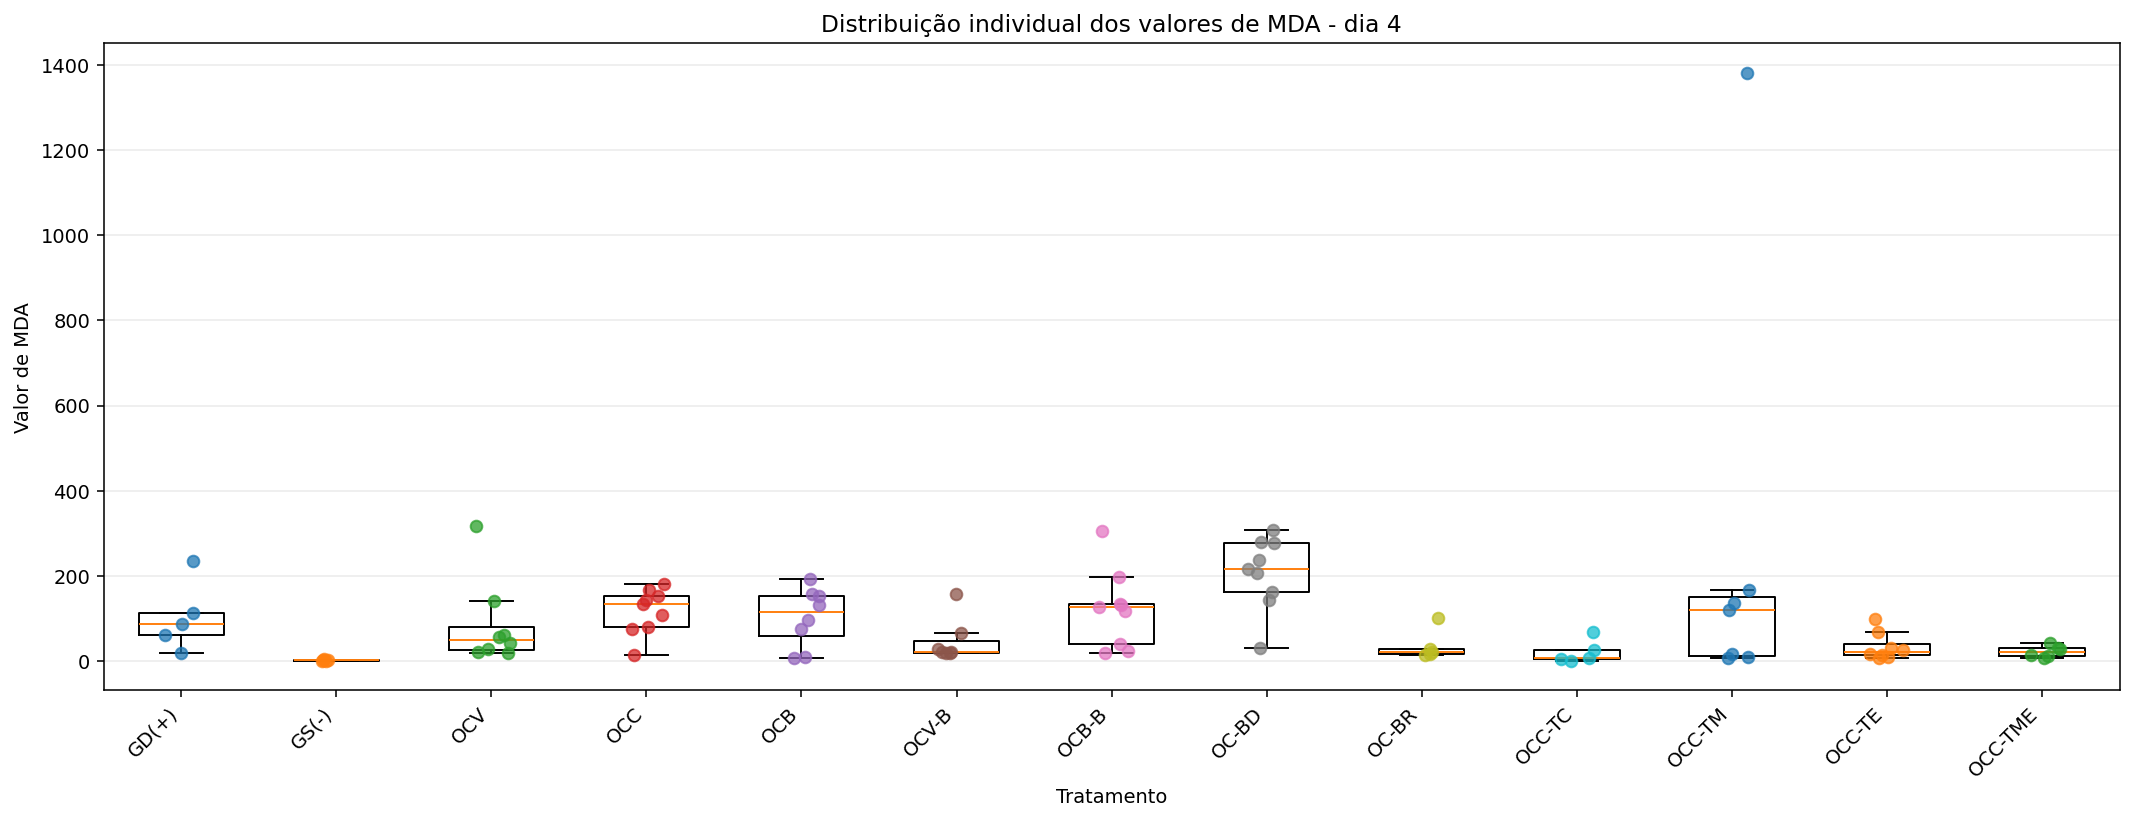

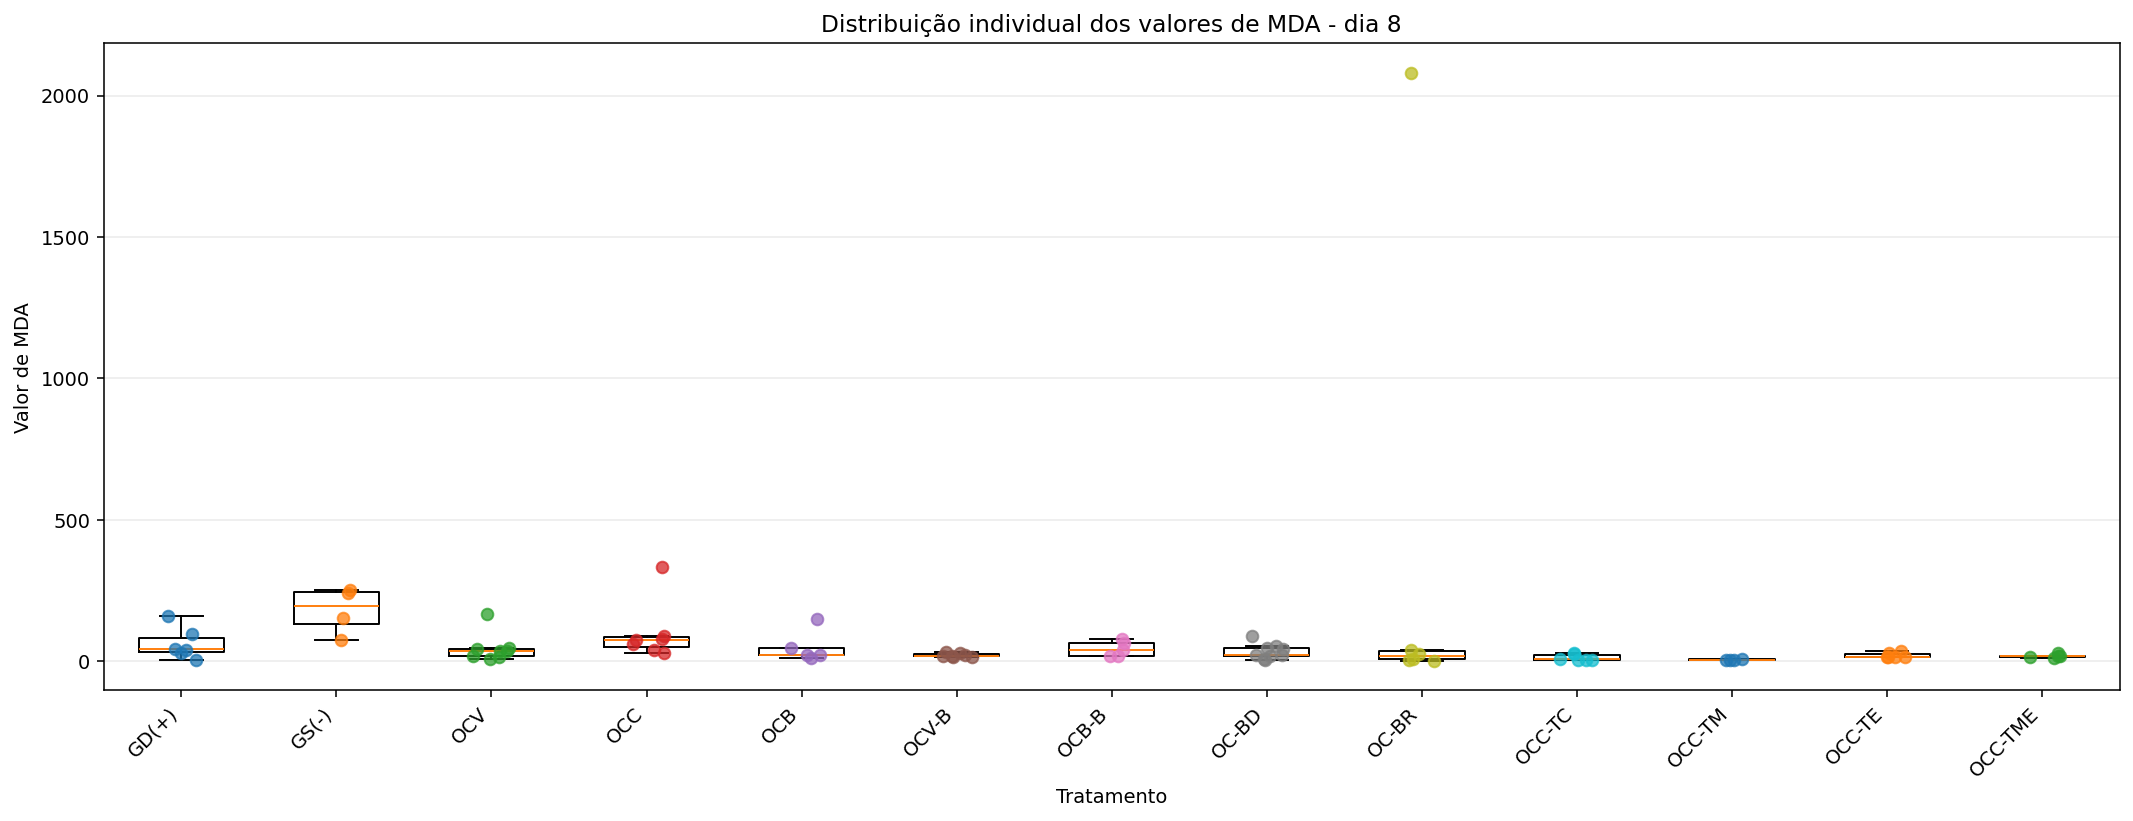


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_descritiva_mda_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_distribuicao_mda_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_mda_dia_8.png


In [52]:
# ETAPA 48 — Análise descritiva e gráficos do MDA

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# =========================================================
# 1. Verificações iniciais
# =========================================================

if "df_mda_individual_longa" not in globals():
    raise RuntimeError(
        "A tabela df_mda_individual_longa não foi encontrada. "
        "Execute primeiro a Etapa 47."
    )

if "PASTA_PROJETO" not in globals():
    raise RuntimeError(
        "A variável PASTA_PROJETO não foi encontrada."
    )

PASTA_PROJETO = Path(
    PASTA_PROJETO
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Configurações
# =========================================================

tratamentos_mda_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

dias_esperados = [
    4,
    8
]

COLUNA_VALOR_MDA = "Valor_MDA"


# =========================================================
# 3. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_MDA
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_mda_individual_longa.columns
]

if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na tabela de MDA: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 4. Preparar cópia específica para análise
# =========================================================

dados_mda = (
    df_mda_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_mda["Tratamento"] = (
    dados_mda["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_mda["Dia"] = pd.to_numeric(
    dados_mda["Dia"],
    errors="coerce"
)

dados_mda[COLUNA_VALOR_MDA] = pd.to_numeric(
    dados_mda[COLUNA_VALOR_MDA],
    errors="coerce"
)


# =========================================================
# 5. Verificar linhas inválidas
# =========================================================

linhas_invalidas = (
    dados_mda["Tratamento"].isna()
    | dados_mda["Dia"].isna()
    | dados_mda[COLUNA_VALOR_MDA].isna()
    | ~np.isfinite(
        dados_mda[COLUNA_VALOR_MDA]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_mda.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas nos dados de MDA."
    )


# =========================================================
# 6. Confirmar os critérios já aplicados
# =========================================================

if (
    dados_mda[COLUNA_VALOR_MDA] < 0
).any():

    raise ValueError(
        "A base analítica de MDA contém valores negativos."
    )

if (
    dados_mda[COLUNA_VALOR_MDA] > 10_000
).any():

    raise ValueError(
        "A base analítica de MDA contém valores "
        "superiores a 10.000."
    )


# =========================================================
# 7. Verificar dias e tratamentos
# =========================================================

dias_encontrados = sorted(
    dados_mda["Dia"]
    .astype(int)
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_mda["Tratamento"]
    .unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_mda_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_mda_esperados)
)

if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes nos dados de MDA: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos nos dados de MDA: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 8. Confirmar os totais da Etapa 47
# =========================================================

total_dia_4 = int(
    (
        dados_mda["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_mda["Dia"] == 8
    ).sum()
)

if total_dia_4 != 91:

    raise ValueError(
        "O dia 4 deveria possuir 91 observações, "
        f"mas foram encontradas {total_dia_4}."
    )

if total_dia_8 != 78:

    raise ValueError(
        "O dia 8 deveria possuir 78 observações, "
        f"mas foram encontradas {total_dia_8}."
    )


print("Totais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 9. Calcular a estatística descritiva
# =========================================================

df_descritiva_mda = (
    dados_mda
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            COLUNA_VALOR_MDA,
            "count"
        ),
        media=(
            COLUNA_VALOR_MDA,
            "mean"
        ),
        desvio_padrao=(
            COLUNA_VALOR_MDA,
            "std"
        ),
        minimo=(
            COLUNA_VALOR_MDA,
            "min"
        ),
        primeiro_quartil=(
            COLUNA_VALOR_MDA,
            lambda valores: valores.quantile(0.25)
        ),
        mediana=(
            COLUNA_VALOR_MDA,
            "median"
        ),
        terceiro_quartil=(
            COLUNA_VALOR_MDA,
            lambda valores: valores.quantile(0.75)
        ),
        maximo=(
            COLUNA_VALOR_MDA,
            "max"
        )
    )
)


# =========================================================
# 10. Calcular o intervalo interquartil
# =========================================================

df_descritiva_mda[
    "intervalo_interquartil"
] = (
    df_descritiva_mda[
        "terceiro_quartil"
    ]
    - df_descritiva_mda[
        "primeiro_quartil"
    ]
)


# =========================================================
# 11. Garantir a ordem dos tratamentos
# =========================================================

indice_completo = pd.MultiIndex.from_product(
    [
        tratamentos_mda_esperados,
        dias_esperados
    ],
    names=[
        "Tratamento",
        "Dia"
    ]
)

df_descritiva_mda = (
    df_descritiva_mda
    .set_index(
        [
            "Tratamento",
            "Dia"
        ]
    )
    .reindex(
        indice_completo
    )
    .reset_index()
)


if df_descritiva_mda["n"].isna().any():

    combinacoes_ausentes = (
        df_descritiva_mda.loc[
            df_descritiva_mda["n"].isna(),
            [
                "Tratamento",
                "Dia"
            ]
        ]
    )

    print(
        "Combinações sem observações:"
    )

    display(
        combinacoes_ausentes
    )

    raise ValueError(
        "Existem combinações de tratamento e dia "
        "sem observações."
    )


df_descritiva_mda["n"] = (
    df_descritiva_mda["n"]
    .astype(int)
)


# =========================================================
# 12. Exibir a estatística descritiva
# =========================================================

print("\nEstatística descritiva do MDA:")

display(
    df_descritiva_mda.round(
        {
            "media": 4,
            "desvio_padrao": 4,
            "minimo": 4,
            "primeiro_quartil": 4,
            "mediana": 4,
            "terceiro_quartil": 4,
            "maximo": 4,
            "intervalo_interquartil": 4
        }
    )
)


# =========================================================
# 13. Identificar grupos com amostra pequena
# =========================================================

grupos_amostra_pequena = (
    df_descritiva_mda.loc[
        df_descritiva_mda["n"] < 3,
        [
            "Tratamento",
            "Dia",
            "n"
        ]
    ]
    .copy()
)


print("\nGrupos com menos de três observações:")

if grupos_amostra_pequena.empty:

    print(
        "Nenhum grupo possui menos de três observações."
    )

else:

    display(
        grupos_amostra_pequena
    )


# =========================================================
# 14. Criar tabela de contagens
# =========================================================

tabela_contagem_mda_descritiva = (
    df_descritiva_mda
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_mda_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .astype(int)
)


print("\nNúmero de observações por tratamento:")

display(
    tabela_contagem_mda_descritiva
)


# =========================================================
# 15. Criar os gráficos dos dias 4 e 8
# =========================================================

arquivos_graficos_mda = []

for dia in dias_esperados:

    dados_dia = (
        dados_mda.loc[
            dados_mda["Dia"] == dia
        ]
        .copy()
    )


    valores_boxplot = []
    posicoes_boxplot = []


    for posicao, tratamento in enumerate(
        tratamentos_mda_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                COLUNA_VALOR_MDA
            ]
            .to_numpy(
                dtype=float
            )
        )

        if len(valores) == 0:

            raise ValueError(
                f"O tratamento {tratamento} não possui "
                f"observações no dia {dia}."
            )

        valores_boxplot.append(
            valores
        )

        posicoes_boxplot.append(
            posicao
        )


    plt.close("all")

    fig, ax = plt.subplots(
        figsize=(
            16,
            7
        )
    )


    # -----------------------------------------------------
    # Boxplots
    # -----------------------------------------------------

    ax.boxplot(
        valores_boxplot,
        positions=posicoes_boxplot,
        widths=0.55,
        showfliers=False
    )


    # -----------------------------------------------------
    # Sobreposição das observações individuais
    # -----------------------------------------------------

    gerador_aleatorio = np.random.default_rng(
        20260729 + dia
    )


    for posicao, tratamento in enumerate(
        tratamentos_mda_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia["Tratamento"] == tratamento,
                COLUNA_VALOR_MDA
            ]
            .to_numpy(
                dtype=float
            )
        )

        deslocamento = gerador_aleatorio.uniform(
            -0.12,
            0.12,
            size=len(valores)
        )

        posicoes_pontos = (
            np.full(
                len(valores),
                posicao,
                dtype=float
            )
            + deslocamento
        )

        ax.scatter(
            posicoes_pontos,
            valores,
            alpha=0.75,
            zorder=3
        )


    # -----------------------------------------------------
    # Formatação
    # -----------------------------------------------------

    ax.set_title(
        f"Distribuição individual dos valores de MDA - dia {dia}"
    )

    ax.set_xlabel(
        "Tratamento"
    )

    ax.set_ylabel(
        "Valor de MDA"
    )

    ax.set_xticks(
        range(
            1,
            len(tratamentos_mda_esperados) + 1
        )
    )

    ax.set_xticklabels(
        tratamentos_mda_esperados,
        rotation=45,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.24,
        top=0.90
    )


    # -----------------------------------------------------
    # Salvar e exibir
    # -----------------------------------------------------

    arquivo_grafico = (
        PASTA_PROJETO
        / f"projeto001_distribuicao_mda_dia_{dia}.png"
    )

    fig.canvas.draw()

    fig.savefig(
        arquivo_grafico,
        dpi=300,
        format="png"
    )

    plt.show()

    plt.close(
        fig
    )

    arquivos_graficos_mda.append(
        arquivo_grafico
    )


# =========================================================
# 16. Salvar a estatística descritiva
# =========================================================

arquivo_descritiva_mda = (
    PASTA_PROJETO
    / "projeto001_descritiva_mda_dias_4_8.csv"
)


df_descritiva_mda.to_csv(
    arquivo_descritiva_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_descritiva_mda
)

for arquivo in arquivos_graficos_mda:

    print(
        arquivo
    )

## 49. Comparação global dos valores de MDA por permutação

Os valores individuais de MDA serão comparados entre os 13 tratamentos,
separadamente nos dias 4 e 8.

Será utilizada a estatística H de Kruskal-Wallis, com valor de p calculado
por 49.999 permutações.

A escolha desse procedimento considera:

- forte assimetria das distribuições;
- tamanhos amostrais desiguais;
- presença de valores elevados preservados;
- ausência de garantia de normalidade;
- maior robustez da análise baseada em postos.

Também será calculado o tamanho de efeito global por epsilon quadrado.

Valores menores de MDA representam menor peroxidação lipídica. Contudo, esta
etapa avaliará somente se existe diferença global entre os tratamentos.

Comparações específicas dos óleos com os controles serão realizadas apenas
nos dias em que o teste global apresentar valor de p inferior a 0,05.

In [53]:
# ETAPA 49 — Teste global do MDA por permutação
# VERSÃO AUTOSSUFICIENTE PARA O KAGGLE
# Não depende de variáveis criadas em células anteriores.

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import kruskal, rankdata
from IPython.display import display


# =========================================================
# 1. Configurar automaticamente os caminhos do Kaggle
# =========================================================

PASTA_WORKING = Path("/kaggle/working")

PASTA_PROJETO = (
    PASTA_WORKING
    / "projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)

arquivo_base_mda = (
    PASTA_PROJETO
    / "projeto001_mda_individual_analise.csv"
)


# Procurar automaticamente o arquivo caso ele não esteja
# no local principal esperado.

if not arquivo_base_mda.exists():

    arquivos_encontrados = list(
        PASTA_WORKING.rglob(
            "projeto001_mda_individual_analise.csv"
        )
    )

    if len(arquivos_encontrados) == 1:

        arquivo_base_mda = (
            arquivos_encontrados[0]
        )

    elif len(arquivos_encontrados) == 0:

        raise FileNotFoundError(
            "O arquivo "
            "'projeto001_mda_individual_analise.csv' "
            "não foi encontrado em /kaggle/working. "
            "Execute primeiro a Etapa 47."
        )

    else:

        print(
            "Foram encontrados vários arquivos:"
        )

        for arquivo in arquivos_encontrados:
            print(arquivo)

        raise RuntimeError(
            "Há mais de uma base analítica do MDA. "
            "Não foi possível escolher com segurança."
        )


print("Pasta de resultados:")

print(
    PASTA_PROJETO
)

print("\nBase analítica utilizada:")

print(
    arquivo_base_mda
)


# =========================================================
# 2. Carregar a base analítica do MDA
# =========================================================

df_mda_individual_longa = pd.read_csv(
    arquivo_base_mda,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("\nDimensão da base carregada:")

print(
    f"{df_mda_individual_longa.shape[0]} linhas × "
    f"{df_mda_individual_longa.shape[1]} colunas"
)


# =========================================================
# 3. Configurações da análise
# =========================================================

NUMERO_PERMUTACOES_MDA = 49_999
SEMENTE_MDA = 20260801
NIVEL_SIGNIFICANCIA = 0.05

COLUNA_VALOR_MDA = "Valor_MDA"

tratamentos_mda_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

dias_esperados = [
    4,
    8
]


# =========================================================
# 4. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_MDA
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_mda_individual_longa.columns
]

if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base do MDA: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 5. Preparar os dados
# =========================================================

dados_mda_teste = (
    df_mda_individual_longa[
        colunas_necessarias
    ]
    .copy()
)

dados_mda_teste["Tratamento"] = (
    dados_mda_teste["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_mda_teste["Dia"] = pd.to_numeric(
    dados_mda_teste["Dia"],
    errors="coerce"
)

dados_mda_teste[
    COLUNA_VALOR_MDA
] = pd.to_numeric(
    dados_mda_teste[
        COLUNA_VALOR_MDA
    ],
    errors="coerce"
)


# =========================================================
# 6. Verificar valores inválidos
# =========================================================

linhas_invalidas = (
    dados_mda_teste["Tratamento"].isna()
    | dados_mda_teste["Dia"].isna()
    | dados_mda_teste[
        COLUNA_VALOR_MDA
    ].isna()
    | ~np.isfinite(
        dados_mda_teste[
            COLUNA_VALOR_MDA
        ]
    )
)

if linhas_invalidas.any():

    print("Linhas inválidas encontradas:")

    display(
        dados_mda_teste.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas na base do MDA."
    )


# =========================================================
# 7. Confirmar os critérios de auditoria
# =========================================================

if (
    dados_mda_teste[
        COLUNA_VALOR_MDA
    ] < 0
).any():

    raise ValueError(
        "A base analítica contém valores negativos."
    )


if (
    dados_mda_teste[
        COLUNA_VALOR_MDA
    ] > 10_000
).any():

    raise ValueError(
        "A base analítica contém valores "
        "superiores a 10.000."
    )


# =========================================================
# 8. Conferir dias e tratamentos
# =========================================================

dias_encontrados = sorted(
    dados_mda_teste["Dia"]
    .astype(int)
    .unique()
    .tolist()
)

if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_mda_teste[
        "Tratamento"
    ].unique()
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_mda_esperados
    if tratamento not in tratamentos_encontrados
]


tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_mda_esperados)
)


if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )


if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 9. Confirmar os totais
# =========================================================

total_dia_4 = int(
    (
        dados_mda_teste["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_mda_teste["Dia"] == 8
    ).sum()
)


if total_dia_4 != 91:

    raise ValueError(
        "O dia 4 deveria possuir 91 observações, "
        f"mas foram encontradas {total_dia_4}."
    )


if total_dia_8 != 78:

    raise ValueError(
        "O dia 8 deveria possuir 78 observações, "
        f"mas foram encontradas {total_dia_8}."
    )


print("\nTotais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 10. Função para correção de empates
# =========================================================

def calcular_correcao_empates_mda(
    valores
):

    valores = np.asarray(
        valores,
        dtype=float
    )

    _, contagens = np.unique(
        valores,
        return_counts=True
    )

    numero_total = len(
        valores
    )

    if numero_total < 2:

        raise ValueError(
            "Número insuficiente de observações."
        )

    denominador = (
        numero_total**3
        - numero_total
    )

    numerador = np.sum(
        contagens**3
        - contagens
    )

    correcao = (
        1.0
        - numerador / denominador
    )

    if correcao <= 0:

        raise ValueError(
            "Não foi possível calcular "
            "a correção de empates."
        )

    return float(
        correcao
    )


# =========================================================
# 11. Função para cálculo de H
# =========================================================

def calcular_h_mda(
    postos,
    tamanhos_grupos,
    correcao_empates
):

    postos = np.asarray(
        postos,
        dtype=float
    )

    numero_total = len(
        postos
    )

    inicio = 0
    soma_componentes = 0.0

    for tamanho in tamanhos_grupos:

        final = (
            inicio
            + tamanho
        )

        soma_postos = np.sum(
            postos[
                inicio:final
            ]
        )

        soma_componentes += (
            soma_postos**2
            / tamanho
        )

        inicio = final


    if inicio != numero_total:

        raise RuntimeError(
            "A soma dos tamanhos dos grupos "
            "não corresponde ao total de postos."
        )


    h_sem_correcao = (
        12.0
        / (
            numero_total
            * (
                numero_total
                + 1
            )
        )
        * soma_componentes
        - 3.0
        * (
            numero_total
            + 1
        )
    )


    h_corrigido = (
        h_sem_correcao
        / correcao_empates
    )

    return float(
        h_corrigido
    )


# =========================================================
# 12. Executar o teste nos dias 4 e 8
# =========================================================

resultados_globais_mda = []
contagens_teste_mda = []

inicio_etapa = time.perf_counter()


for dia in dias_esperados:

    print("\n" + "=" * 90)

    print(
        f"PROCESSANDO MDA — DIA {dia}"
    )


    dados_dia = (
        dados_mda_teste.loc[
            dados_mda_teste[
                "Dia"
            ] == dia
        ]
        .copy()
    )


    grupos = []
    tamanhos_grupos = []


    for tratamento in (
        tratamentos_mda_esperados
    ):

        valores = (
            dados_dia.loc[
                dados_dia[
                    "Tratamento"
                ] == tratamento,
                COLUNA_VALOR_MDA
            ]
            .to_numpy(
                dtype=float
            )
        )


        numero_observacoes = len(
            valores
        )


        contagens_teste_mda.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": numero_observacoes
            }
        )


        if numero_observacoes < 2:

            raise ValueError(
                f"O tratamento {tratamento} possui "
                f"somente {numero_observacoes} "
                f"observação(ões) no dia {dia}."
            )


        grupos.append(
            valores
        )

        tamanhos_grupos.append(
            numero_observacoes
        )


    if len(grupos) != 13:

        raise RuntimeError(
            "Eram esperados 13 grupos, "
            f"mas foram encontrados {len(grupos)}."
        )


    numero_grupos = len(
        grupos
    )

    numero_total = sum(
        tamanhos_grupos
    )


    valores_concatenados = np.concatenate(
        grupos
    )


    postos = rankdata(
        valores_concatenados,
        method="average"
    )


    correcao_empates = (
        calcular_correcao_empates_mda(
            valores_concatenados
        )
    )


    h_observado = calcular_h_mda(
        postos=postos,
        tamanhos_grupos=tamanhos_grupos,
        correcao_empates=correcao_empates
    )


    # -----------------------------------------------------
    # Conferência com scipy.stats.kruskal
    # -----------------------------------------------------

    resultado_assintotico = kruskal(
        *grupos,
        nan_policy="raise"
    )


    h_scipy = float(
        resultado_assintotico.statistic
    )

    p_assintotico = float(
        resultado_assintotico.pvalue
    )


    if not np.isclose(
        h_observado,
        h_scipy,
        rtol=1e-10,
        atol=1e-10
    ):

        raise RuntimeError(
            "A estatística H manual não coincide "
            "com o resultado do SciPy."
        )


    # -----------------------------------------------------
    # Teste de permutação
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        SEMENTE_MDA
        + dia
    )

    numero_extremos = 0

    inicio_dia = time.perf_counter()


    for _ in range(
        NUMERO_PERMUTACOES_MDA
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )


        h_permutado = calcular_h_mda(
            postos=postos_permutados,
            tamanhos_grupos=tamanhos_grupos,
            correcao_empates=correcao_empates
        )


        if h_permutado >= (
            h_observado
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        NUMERO_PERMUTACOES_MDA
        + 1
    )


    erro_padrao_monte_carlo = np.sqrt(
        valor_p_permutacao
        * (
            1.0
            - valor_p_permutacao
        )
        / (
            NUMERO_PERMUTACOES_MDA
            + 1
        )
    )


    # -----------------------------------------------------
    # Tamanho de efeito
    # -----------------------------------------------------

    epsilon_quadrado = (
        h_observado
        - numero_grupos
        + 1
    ) / (
        numero_total
        - numero_grupos
    )


    epsilon_quadrado = float(
        np.clip(
            epsilon_quadrado,
            0.0,
            1.0
        )
    )


    if (
        valor_p_permutacao
        < NIVEL_SIGNIFICANCIA
    ):

        conclusao = (
            "Há evidência de diferença global "
            "entre os tratamentos."
        )

    else:

        conclusao = (
            "Não há evidência de diferença global "
            "entre os tratamentos."
        )


    tempo_dia = (
        time.perf_counter()
        - inicio_dia
    )


    resultados_globais_mda.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Menor_n": min(
                tamanhos_grupos
            ),
            "Maior_n": max(
                tamanhos_grupos
            ),
            "Estatistica_H": h_observado,
            "Graus_de_liberdade": (
                numero_grupos
                - 1
            ),
            "Valor_p_assintotico": p_assintotico,
            "Numero_de_permutacoes": (
                NUMERO_PERMUTACOES_MDA
            ),
            "Permutacoes_iguais_ou_maiores": (
                numero_extremos
            ),
            "Valor_p_permutacao": (
                valor_p_permutacao
            ),
            "Erro_padrao_Monte_Carlo": (
                erro_padrao_monte_carlo
            ),
            "Epsilon_quadrado": (
                epsilon_quadrado
            ),
            "Tempo_segundos": (
                tempo_dia
            ),
            "Conclusao_5_percent": (
                conclusao
            )
        }
    )


    print(
        f"H observado: {h_observado:.6f}"
    )

    print(
        f"p assintótico: {p_assintotico:.8f}"
    )

    print(
        "p por permutação: "
        f"{valor_p_permutacao:.8f}"
    )

    print(
        f"ε²: {epsilon_quadrado:.4f}"
    )

    print(
        f"Tempo: {tempo_dia:.2f} segundos"
    )

    print(
        conclusao
    )


# =========================================================
# 13. Criar as tabelas finais
# =========================================================

df_resultados_permutacao_mda = pd.DataFrame(
    resultados_globais_mda
)

df_contagens_teste_mda = pd.DataFrame(
    contagens_teste_mda
)


tabela_contagens_teste_mda = (
    df_contagens_teste_mda
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_mda_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(0)
    .astype(int)
)


# =========================================================
# 14. Exibir os resultados
# =========================================================

print("\n" + "=" * 90)

print(
    "CONTAGENS UTILIZADAS NO TESTE DO MDA"
)

display(
    tabela_contagens_teste_mda
)


print("\nRESULTADOS GLOBAIS DO MDA")

display(
    df_resultados_permutacao_mda.round(
        {
            "Estatistica_H": 6,
            "Valor_p_assintotico": 8,
            "Valor_p_permutacao": 8,
            "Erro_padrao_Monte_Carlo": 8,
            "Epsilon_quadrado": 4,
            "Tempo_segundos": 2
        }
    )
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)


print(
    f"\nTempo total da Etapa 49: "
    f"{tempo_total:.2f} segundos"
)


# =========================================================
# 15. Salvar os resultados
# =========================================================

arquivo_teste_global_mda = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_mda.csv"
)

arquivo_contagens_teste_mda = (
    PASTA_PROJETO
    / "projeto001_contagens_teste_global_mda.csv"
)


df_resultados_permutacao_mda.to_csv(
    arquivo_teste_global_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagens_teste_mda.to_csv(
    arquivo_contagens_teste_mda,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_teste_global_mda
)

print(
    arquivo_contagens_teste_mda
)

Pasta de resultados:
/kaggle/working/projeto001_resultados

Base analítica utilizada:
/kaggle/working/projeto001_resultados/projeto001_mda_individual_analise.csv

Dimensão da base carregada:
169 linhas × 10 colunas

Totais conferidos:
Dia 4: 91 observações
Dia 8: 78 observações

PROCESSANDO MDA — DIA 4
H observado: 43.501909
p assintótico: 0.00001856
p por permutação: 0.00002000
ε²: 0.4039
Tempo: 2.64 segundos
Há evidência de diferença global entre os tratamentos.

PROCESSANDO MDA — DIA 8
H observado: 33.916349
p assintótico: 0.00069533
p por permutação: 0.00006000
ε²: 0.3372
Tempo: 2.60 segundos
Há evidência de diferença global entre os tratamentos.

CONTAGENS UTILIZADAS NO TESTE DO MDA


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,6



RESULTADOS GLOBAIS DO MDA


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Menor_n,Maior_n,Estatistica_H,Graus_de_liberdade,Valor_p_assintotico,Numero_de_permutacoes,Permutacoes_iguais_ou_maiores,Valor_p_permutacao,Erro_padrao_Monte_Carlo,Epsilon_quadrado,Tempo_segundos,Conclusao_5_percent
0,4,13,91,5,9,43.501909,12,0.000019,49999,0,0.00002,0.000020,0.4039,2.64,Há evidência de diferença global entre os trat...
1,8,13,78,4,9,33.916349,12,0.000695,49999,2,0.00006,0.000035,0.3372,2.60,Há evidência de diferença global entre os trat...



Tempo total da Etapa 49: 5.27 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_teste_global_permutacao_mda.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_teste_global_mda.csv


## 50. Comparações dos valores de MDA entre os óleos e os controles

Como os testes globais por permutação identificaram diferenças significativas
entre os tratamentos nos dias 4 e 8, serão realizadas comparações planejadas
entre cada óleo e os controles GD(+) e GS(-).

Será utilizado o teste bilateral de permutação baseado na estatística U de
Mann–Whitney, com 49.999 permutações por comparação.

Em cada dia, os valores de p das 22 comparações serão corrigidos conjuntamente
pelo método de Holm. As famílias de testes dos dias 4 e 8 serão tratadas
separadamente, pois correspondem a análises globais independentes.

Também serão apresentados:

- número de observações por grupo;
- medianas;
- diferença entre medianas;
- correlação bisserial de postos;
- magnitude e direção do efeito.

Para MDA, valores inferiores aos controles indicam menor peroxidação lipídica
e representam uma direção biologicamente favorável.

In [54]:
# ETAPA 50 — Comparações do MDA entre os óleos e os controles
# Dias 4 e 8
# Teste U de Mann-Whitney por permutação
# Correção de Holm separadamente em cada dia
# Célula autossuficiente para o Kaggle

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_BASE_MDA = (
    PASTA_PROJETO
    / "projeto001_mda_individual_analise.csv"
)

ARQUIVO_GLOBAL_MDA = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_mda.csv"
)

COLUNA_VALOR_MDA = "Valor_MDA"

NUMERO_PERMUTACOES_PARES_MDA = 49_999
SEMENTE_PARES_MDA = 20260806
NIVEL_SIGNIFICANCIA = 0.05

dias_analisados = [
    4,
    8
]

controles_mda = [
    "GD(+)",
    "GS(-)"
]

oleos_mda = [
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]

tratamentos_esperados = (
    controles_mda
    + oleos_mda
)


# =========================================================
# 2. Localizar a base do MDA
# =========================================================

if not ARQUIVO_BASE_MDA.exists():

    arquivos_encontrados = list(
        Path("/kaggle/working").rglob(
            "projeto001_mda_individual_analise.csv"
        )
    )

    if len(arquivos_encontrados) == 1:

        ARQUIVO_BASE_MDA = arquivos_encontrados[0]

    elif len(arquivos_encontrados) == 0:

        raise FileNotFoundError(
            "O arquivo "
            "'projeto001_mda_individual_analise.csv' "
            "não foi encontrado em /kaggle/working."
        )

    else:

        print(
            "Foram encontradas várias bases do MDA:"
        )

        for arquivo in arquivos_encontrados:
            print(arquivo)

        raise RuntimeError(
            "Não foi possível selecionar uma única base."
        )


print("Base analítica utilizada:")

print(
    ARQUIVO_BASE_MDA
)


# =========================================================
# 3. Carregar a base analítica
# =========================================================

df_mda_individual_longa = pd.read_csv(
    ARQUIVO_BASE_MDA,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("\nDimensão da base carregada:")

print(
    f"{df_mda_individual_longa.shape[0]} linhas × "
    f"{df_mda_individual_longa.shape[1]} colunas"
)


# =========================================================
# 4. Carregar e conferir o teste global
# =========================================================

if not ARQUIVO_GLOBAL_MDA.exists():

    arquivos_globais_encontrados = list(
        Path("/kaggle/working").rglob(
            "projeto001_teste_global_permutacao_mda.csv"
        )
    )

    if len(arquivos_globais_encontrados) == 1:

        ARQUIVO_GLOBAL_MDA = (
            arquivos_globais_encontrados[0]
        )

    elif len(arquivos_globais_encontrados) == 0:

        raise FileNotFoundError(
            "O resultado global do MDA não foi encontrado. "
            "Execute primeiro a Etapa 49."
        )

    else:

        print(
            "Foram encontrados vários resultados globais:"
        )

        for arquivo in arquivos_globais_encontrados:
            print(arquivo)

        raise RuntimeError(
            "Não foi possível selecionar um único resultado global."
        )


df_resultados_globais_mda = pd.read_csv(
    ARQUIVO_GLOBAL_MDA,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


colunas_globais_necessarias = [
    "Dia",
    "Numero_total_de_observacoes",
    "Valor_p_permutacao"
]

colunas_globais_ausentes = [
    coluna
    for coluna in colunas_globais_necessarias
    if coluna not in df_resultados_globais_mda.columns
]

if colunas_globais_ausentes:

    raise ValueError(
        "Colunas ausentes no teste global do MDA: "
        f"{colunas_globais_ausentes}"
    )


for dia, total_esperado in [
    (4, 91),
    (8, 78)
]:

    resultado_dia = (
        df_resultados_globais_mda.loc[
            df_resultados_globais_mda["Dia"] == dia
        ]
    )

    if len(resultado_dia) != 1:

        raise ValueError(
            f"Não foi encontrado exatamente um resultado "
            f"global para o dia {dia}."
        )

    total_encontrado = int(
        resultado_dia[
            "Numero_total_de_observacoes"
        ].iloc[0]
    )

    valor_p_global = float(
        resultado_dia[
            "Valor_p_permutacao"
        ].iloc[0]
    )

    if total_encontrado != total_esperado:

        raise ValueError(
            f"O teste global do dia {dia} deveria possuir "
            f"{total_esperado} observações, mas possui "
            f"{total_encontrado}."
        )

    if valor_p_global >= NIVEL_SIGNIFICANCIA:

        raise ValueError(
            f"O teste global do dia {dia} não foi "
            "significativo. As comparações desse dia "
            "não deveriam ser realizadas."
        )

    print(
        f"\nDia {dia}: teste global confirmado, "
        f"p = {valor_p_global:.8f}"
    )


# =========================================================
# 5. Preparar os dados
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_MDA
]

colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_mda_individual_longa.columns
]

if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base analítica: "
        f"{colunas_ausentes}"
    )


dados_mda = (
    df_mda_individual_longa[
        colunas_necessarias
    ]
    .copy()
)


dados_mda["Tratamento"] = (
    dados_mda["Tratamento"]
    .astype("string")
    .str.strip()
)

dados_mda["Dia"] = pd.to_numeric(
    dados_mda["Dia"],
    errors="coerce"
)

dados_mda[
    COLUNA_VALOR_MDA
] = pd.to_numeric(
    dados_mda[
        COLUNA_VALOR_MDA
    ],
    errors="coerce"
)


# =========================================================
# 6. Validar a base
# =========================================================

linhas_invalidas = (
    dados_mda["Tratamento"].isna()
    | dados_mda["Dia"].isna()
    | dados_mda[COLUNA_VALOR_MDA].isna()
    | ~np.isfinite(
        dados_mda[COLUNA_VALOR_MDA]
    )
)

if linhas_invalidas.any():

    print(
        "Linhas inválidas encontradas:"
    )

    display(
        dados_mda.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas na base de MDA."
    )


if (
    dados_mda[COLUNA_VALOR_MDA] < 0
).any():

    raise ValueError(
        "A base de MDA contém valores negativos."
    )


if (
    dados_mda[COLUNA_VALOR_MDA] > 10_000
).any():

    raise ValueError(
        "A base de MDA contém valores superiores a 10.000."
    )


tratamentos_encontrados = set(
    dados_mda["Tratamento"].unique()
)

tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_esperados
    if tratamento not in tratamentos_encontrados
]

tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(tratamentos_esperados)
)

if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )

if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


total_dia_4 = int(
    (
        dados_mda["Dia"] == 4
    ).sum()
)

total_dia_8 = int(
    (
        dados_mda["Dia"] == 8
    ).sum()
)

if total_dia_4 != 91:

    raise ValueError(
        "O dia 4 deveria possuir 91 observações, "
        f"mas possui {total_dia_4}."
    )

if total_dia_8 != 78:

    raise ValueError(
        "O dia 8 deveria possuir 78 observações, "
        f"mas possui {total_dia_8}."
    )


print("\nTotais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 7. Classificar a magnitude da correlação bisserial
# =========================================================

def classificar_magnitude_bisserial(
    valor
):

    valor_absoluto = abs(
        valor
    )

    if valor_absoluto < 0.10:
        return "Desprezível"

    if valor_absoluto < 0.30:
        return "Pequeno"

    if valor_absoluto < 0.50:
        return "Moderado"

    return "Grande"


# =========================================================
# 8. Teste U bilateral por permutação
# =========================================================

def teste_u_por_permutacao(
    valores_oleo,
    valores_controle,
    numero_permutacoes,
    semente
):

    valores_oleo = np.asarray(
        valores_oleo,
        dtype=float
    )

    valores_controle = np.asarray(
        valores_controle,
        dtype=float
    )

    n_oleo = len(
        valores_oleo
    )

    n_controle = len(
        valores_controle
    )

    if n_oleo < 2 or n_controle < 2:

        raise ValueError(
            "Cada grupo deve possuir pelo menos "
            "duas observações."
        )


    valores_combinados = np.concatenate(
        [
            valores_oleo,
            valores_controle
        ]
    )


    postos = rankdata(
        valores_combinados,
        method="average"
    )


    soma_postos_oleo = np.sum(
        postos[:n_oleo]
    )


    u_observado = (
        soma_postos_oleo
        - n_oleo
        * (
            n_oleo + 1
        )
        / 2
    )


    centro_u = (
        n_oleo
        * n_controle
        / 2
    )


    distancia_observada = abs(
        u_observado
        - centro_u
    )


    gerador = np.random.default_rng(
        semente
    )


    numero_extremos = 0


    for _ in range(
        numero_permutacoes
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )


        soma_postos_permutada = np.sum(
            postos_permutados[:n_oleo]
        )


        u_permutado = (
            soma_postos_permutada
            - n_oleo
            * (
                n_oleo + 1
            )
            / 2
        )


        distancia_permutada = abs(
            u_permutado
            - centro_u
        )


        if distancia_permutada >= (
            distancia_observada
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        numero_permutacoes
        + 1
    )


    correlacao_bisserial = (
        2.0
        * u_observado
        / (
            n_oleo
            * n_controle
        )
        - 1.0
    )


    return {
        "Estatistica_U": float(
            u_observado
        ),
        "Valor_p_permutacao": float(
            valor_p_permutacao
        ),
        "Permutacoes_iguais_ou_maiores": int(
            numero_extremos
        ),
        "Correlacao_bisserial_postos": float(
            correlacao_bisserial
        )
    }


# =========================================================
# 9. Executar as 44 comparações
# =========================================================

resultados_comparacoes_mda = []

contador_comparacao = 0

inicio_etapa = time.perf_counter()


for dia in dias_analisados:

    dados_dia = (
        dados_mda.loc[
            dados_mda["Dia"] == dia
        ]
        .copy()
    )


    for controle in controles_mda:

        valores_controle = (
            dados_dia.loc[
                dados_dia["Tratamento"] == controle,
                COLUNA_VALOR_MDA
            ]
            .to_numpy(
                dtype=float
            )
        )


        for oleo in oleos_mda:

            contador_comparacao += 1


            valores_oleo = (
                dados_dia.loc[
                    dados_dia["Tratamento"] == oleo,
                    COLUNA_VALOR_MDA
                ]
                .to_numpy(
                    dtype=float
                )
            )


            resultado_permutacao = (
                teste_u_por_permutacao(
                    valores_oleo=valores_oleo,
                    valores_controle=valores_controle,
                    numero_permutacoes=(
                        NUMERO_PERMUTACOES_PARES_MDA
                    ),
                    semente=(
                        SEMENTE_PARES_MDA
                        + contador_comparacao
                    )
                )
            )


            resultado_assintotico = mannwhitneyu(
                valores_oleo,
                valores_controle,
                alternative="two-sided",
                method="asymptotic"
            )


            mediana_oleo = float(
                np.median(
                    valores_oleo
                )
            )


            mediana_controle = float(
                np.median(
                    valores_controle
                )
            )


            diferenca_medianas = (
                mediana_oleo
                - mediana_controle
            )


            efeito = (
                resultado_permutacao[
                    "Correlacao_bisserial_postos"
                ]
            )


            if efeito < 0:

                direcao_efeito = (
                    "Óleo apresentou tendência a menor MDA"
                )

                interpretacao_biologica = (
                    "Favorável"
                )

            elif efeito > 0:

                direcao_efeito = (
                    "Óleo apresentou tendência a maior MDA"
                )

                interpretacao_biologica = (
                    "Desfavorável"
                )

            else:

                direcao_efeito = (
                    "Não houve direção predominante"
                )

                interpretacao_biologica = (
                    "Neutra"
                )


            resultados_comparacoes_mda.append(
                {
                    "Dia": dia,
                    "Oleo": oleo,
                    "Controle": controle,
                    "n_Oleo": len(
                        valores_oleo
                    ),
                    "n_Controle": len(
                        valores_controle
                    ),
                    "Mediana_Oleo": mediana_oleo,
                    "Mediana_Controle": mediana_controle,
                    "Diferenca_Medianas": diferenca_medianas,
                    "Estatistica_U": (
                        resultado_permutacao[
                            "Estatistica_U"
                        ]
                    ),
                    "Valor_p_assintotico": float(
                        resultado_assintotico.pvalue
                    ),
                    "Numero_de_permutacoes": (
                        NUMERO_PERMUTACOES_PARES_MDA
                    ),
                    "Permutacoes_iguais_ou_maiores": (
                        resultado_permutacao[
                            "Permutacoes_iguais_ou_maiores"
                        ]
                    ),
                    "Valor_p_permutacao": (
                        resultado_permutacao[
                            "Valor_p_permutacao"
                        ]
                    ),
                    "Correlacao_bisserial_postos": efeito,
                    "Magnitude_efeito": (
                        classificar_magnitude_bisserial(
                            efeito
                        )
                    ),
                    "Direcao_efeito": direcao_efeito,
                    "Interpretacao_biologica": (
                        interpretacao_biologica
                    )
                }
            )


# =========================================================
# 10. Criar tabela das comparações
# =========================================================

df_comparacoes_mda = pd.DataFrame(
    resultados_comparacoes_mda
)


if len(df_comparacoes_mda) != 44:

    raise RuntimeError(
        "Eram esperadas 44 comparações, "
        f"mas foram produzidas "
        f"{len(df_comparacoes_mda)}."
    )


# =========================================================
# 11. Aplicar Holm separadamente em cada dia
# =========================================================

df_comparacoes_mda[
    "Valor_p_Holm"
] = np.nan

df_comparacoes_mda[
    "Significativo_Holm_5_percent"
] = False


for dia in dias_analisados:

    mascara_dia = (
        df_comparacoes_mda["Dia"] == dia
    )


    valores_p_dia = (
        df_comparacoes_mda.loc[
            mascara_dia,
            "Valor_p_permutacao"
        ]
        .to_numpy(
            dtype=float
        )
    )


    if len(valores_p_dia) != 22:

        raise RuntimeError(
            f"Eram esperadas 22 comparações no dia {dia}, "
            f"mas foram encontradas {len(valores_p_dia)}."
        )


    rejeitar_h0, valores_p_holm, _, _ = multipletests(
        valores_p_dia,
        alpha=NIVEL_SIGNIFICANCIA,
        method="holm"
    )


    df_comparacoes_mda.loc[
        mascara_dia,
        "Valor_p_Holm"
    ] = valores_p_holm


    df_comparacoes_mda.loc[
        mascara_dia,
        "Significativo_Holm_5_percent"
    ] = rejeitar_h0


df_comparacoes_mda[
    "Conclusao"
] = np.where(
    df_comparacoes_mda[
        "Significativo_Holm_5_percent"
    ],
    (
        "Diferença significativa após "
        "correção de Holm"
    ),
    (
        "Diferença não significativa após "
        "correção de Holm"
    )
)


# =========================================================
# 12. Ordenar os resultados
# =========================================================

df_comparacoes_mda = (
    df_comparacoes_mda
    .sort_values(
        [
            "Dia",
            "Controle",
            "Valor_p_Holm",
            "Oleo"
        ]
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 13. Exibir as comparações por dia e controle
# =========================================================

for dia in dias_analisados:

    for controle in controles_mda:

        print("\n" + "=" * 120)

        print(
            f"MDA — DIA {dia} — ÓLEOS VERSUS {controle}"
        )


        tabela_exibicao = (
            df_comparacoes_mda.loc[
                (
                    df_comparacoes_mda["Dia"] == dia
                )
                & (
                    df_comparacoes_mda[
                        "Controle"
                    ] == controle
                ),
                [
                    "Oleo",
                    "n_Oleo",
                    "n_Controle",
                    "Mediana_Oleo",
                    "Mediana_Controle",
                    "Diferenca_Medianas",
                    "Valor_p_permutacao",
                    "Valor_p_Holm",
                    "Significativo_Holm_5_percent",
                    "Correlacao_bisserial_postos",
                    "Magnitude_efeito",
                    "Direcao_efeito",
                    "Interpretacao_biologica"
                ]
            ]
        )


        display(
            tabela_exibicao.round(
                {
                    "Mediana_Oleo": 4,
                    "Mediana_Controle": 4,
                    "Diferenca_Medianas": 4,
                    "Valor_p_permutacao": 6,
                    "Valor_p_Holm": 6,
                    "Correlacao_bisserial_postos": 4
                }
            )
        )


# =========================================================
# 14. Selecionar comparações significativas
# =========================================================

df_comparacoes_significativas_mda = (
    df_comparacoes_mda.loc[
        df_comparacoes_mda[
            "Significativo_Holm_5_percent"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 120)

print(
    "COMPARAÇÕES SIGNIFICATIVAS DO MDA "
    "APÓS CORREÇÃO DE HOLM"
)


if df_comparacoes_significativas_mda.empty:

    print(
        "Nenhuma comparação permaneceu significativa "
        "após a correção de Holm."
    )

else:

    display(
        df_comparacoes_significativas_mda[
            [
                "Dia",
                "Oleo",
                "Controle",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito",
                "Interpretacao_biologica"
            ]
        ].round(
            {
                "Mediana_Oleo": 4,
                "Mediana_Controle": 4,
                "Diferenca_Medianas": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 15. Resumo por dia
# =========================================================

df_resumo_significancia_mda = (
    df_comparacoes_mda
    .groupby(
        "Dia",
        as_index=False
    )
    .agg(
        Numero_de_comparacoes=(
            "Oleo",
            "count"
        ),
        Numero_significativas_Holm=(
            "Significativo_Holm_5_percent",
            "sum"
        )
    )
)


df_resumo_significancia_mda[
    "Numero_significativas_Holm"
] = (
    df_resumo_significancia_mda[
        "Numero_significativas_Holm"
    ]
    .astype(int)
)


print("\nResumo por dia:")

display(
    df_resumo_significancia_mda
)


# =========================================================
# 16. Salvar os resultados
# =========================================================

arquivo_comparacoes_mda = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_mda_"
        "dias4_8_permutacao_holm.csv"
    )
)

arquivo_significativas_mda = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_significativas_"
        "mda.csv"
    )
)

arquivo_resumo_mda = (
    PASTA_PROJETO
    / (
        "projeto001_resumo_comparacoes_mda.csv"
    )
)


df_comparacoes_mda.to_csv(
    arquivo_comparacoes_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_comparacoes_significativas_mda.to_csv(
    arquivo_significativas_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_resumo_significancia_mda.to_csv(
    arquivo_resumo_mda,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)


print(
    f"\nTempo total da Etapa 50: "
    f"{tempo_total:.2f} segundos"
)

print("\nArquivos salvos:")

print(
    arquivo_comparacoes_mda
)

print(
    arquivo_significativas_mda
)

print(
    arquivo_resumo_mda
)

Base analítica utilizada:
/kaggle/working/projeto001_resultados/projeto001_mda_individual_analise.csv

Dimensão da base carregada:
169 linhas × 10 colunas

Dia 4: teste global confirmado, p = 0.00002000

Dia 8: teste global confirmado, p = 0.00006000

Totais conferidos:
Dia 4: 91 observações
Dia 8: 78 observações

MDA — DIA 4 — ÓLEOS VERSUS GD(+)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
0,OCC-TME,6,5,22.2658,86.6444,-64.3786,0.03004,0.36048,False,-0.8000,Grande,Óleo apresentou tendência a menor MDA,Favorável
1,OC-BD,9,5,216.5796,86.6444,129.9352,0.05876,0.60852,False,0.6444,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
2,OCC-TC,5,5,7.0964,86.6444,-79.5480,0.05532,0.60852,False,-0.7600,Grande,Óleo apresentou tendência a menor MDA,Favorável
3,OCC-TE,8,5,22.0087,86.6444,-64.6357,0.06406,0.60852,False,-0.6500,Grande,Óleo apresentou tendência a menor MDA,Favorável
4,OC-BR,5,5,20.9006,86.6444,-65.7438,0.15028,1.00000,False,-0.6000,Grande,Óleo apresentou tendência a menor MDA,Favorável
5,OCB,8,5,114.4965,86.6444,27.8521,0.94316,1.00000,False,0.0500,Desprezível,Óleo apresentou tendência a maior MDA,Desfavorável
6,OCB-B,9,5,126.0835,86.6444,39.4391,0.51826,1.00000,False,0.2444,Pequeno,Óleo apresentou tendência a maior MDA,Desfavorável
7,OCC,9,5,134.1729,86.6444,47.5285,0.60396,1.00000,False,0.2000,Pequeno,Óleo apresentou tendência a maior MDA,Desfavorável
8,OCC-TM,7,5,119.0781,86.6444,32.4337,1.00000,1.00000,False,-0.0286,Desprezível,Óleo apresentou tendência a menor MDA,Favorável
9,OCV,8,5,50.2419,86.6444,-36.4025,0.61938,1.00000,False,-0.2000,Pequeno,Óleo apresentou tendência a menor MDA,Favorável



MDA — DIA 4 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
11,OCC,9,5,134.1729,1.9303,132.2426,0.00094,0.02068,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
12,OCB-B,9,5,126.0835,1.9303,124.1532,0.00112,0.02352,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
13,OC-BD,9,5,216.5796,1.9303,214.6493,0.00118,0.02360,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
14,OCV,8,5,50.2419,1.9303,48.3116,0.00144,0.02736,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
15,OCB,8,5,114.4965,1.9303,112.5662,0.00160,0.02808,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
16,OCC-TE,8,5,22.0087,1.9303,20.0785,0.00156,0.02808,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
17,OCC-TM,7,5,119.0781,1.9303,117.1478,0.00236,0.03616,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
18,OCV-B,7,5,22.4227,1.9303,20.4924,0.00226,0.03616,True,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
19,OCC-TME,6,5,22.2658,1.9303,20.3355,0.00434,0.06076,False,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
20,OC-BR,5,5,20.9006,1.9303,18.9703,0.00804,0.10452,False,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável



MDA — DIA 8 — ÓLEOS VERSUS GD(+)


...


COMPARAÇÕES SIGNIFICATIVAS DO MDA APÓS CORREÇÃO DE HOLM


,Dia,Oleo,Controle,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
0,4,OCC,GS(-),9,5,134.1729,1.9303,132.2426,0.00094,0.02068,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
1,4,OCB-B,GS(-),9,5,126.0835,1.9303,124.1532,0.00112,0.02352,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
2,4,OC-BD,GS(-),9,5,216.5796,1.9303,214.6493,0.00118,0.02360,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
3,4,OCV,GS(-),8,5,50.2419,1.9303,48.3116,0.00144,0.02736,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
4,4,OCB,GS(-),8,5,114.4965,1.9303,112.5662,0.00160,0.02808,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
5,4,OCC-TE,GS(-),8,5,22.0087,1.9303,20.0785,0.00156,0.02808,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
6,4,OCC-TM,GS(-),7,5,119.0781,1.9303,117.1478,0.00236,0.03616,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável
7,4,OCV-B,GS(-),7,5,22.4227,1.9303,20.4924,0.00226,0.03616,1.0,Grande,Óleo apresentou tendência a maior MDA,Desfavorável



Resumo por dia:


,Dia,Numero_de_comparacoes,Numero_significativas_Holm
0,4,22,8
1,8,22,0



Tempo total da Etapa 50: 17.06 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_comparacoes_mda_dias4_8_permutacao_holm.csv
/kaggle/working/projeto001_resultados/projeto001_comparacoes_significativas_mda.csv
/kaggle/working/projeto001_resultados/projeto001_resumo_comparacoes_mda.csv


## 51. Inspeção da estrutura dos dados de FRAP

Nesta etapa será examinada exclusivamente a aba relacionada ao FRAP.

Serão verificados:

- nome exato da aba;
- dimensão da planilha;
- localização dos tratamentos;
- posição dos cabeçalhos dos dias;
- organização das repetições;
- quantidade de valores numéricos;
- presença de valores negativos, células vazias e valores elevados.

Nenhum valor será excluído, transformado, imputado ou submetido a teste
estatístico nesta etapa.

In [55]:
# ETAPA 51 — Inspeção da estrutura dos dados de FRAP
# Célula autossuficiente para o Kaggle
# Nenhum valor será excluído nesta etapa.

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Localizar automaticamente o arquivo Excel
# =========================================================

PASTA_INPUT = Path("/kaggle/input")
PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


arquivos_excel = sorted(
    list(
        PASTA_INPUT.rglob(
            "*.xlsx"
        )
    )
    + list(
        PASTA_INPUT.rglob(
            "*.xls"
        )
    )
)


arquivos_excel_validos = [
    arquivo
    for arquivo in arquivos_excel
    if not arquivo.name.startswith("~$")
]


if len(arquivos_excel_validos) == 0:

    raise FileNotFoundError(
        "Nenhum arquivo Excel foi encontrado "
        "em /kaggle/input."
    )


# Priorizar o arquivo já utilizado no projeto

arquivos_prioritarios = [
    arquivo
    for arquivo in arquivos_excel_validos
    if (
        "Tabela analise multivariada"
        in arquivo.name
    )
]


if len(arquivos_prioritarios) == 1:

    ARQUIVO_EXCEL = arquivos_prioritarios[0]

elif len(arquivos_prioritarios) > 1:

    arquivos_prioritarios = sorted(
        arquivos_prioritarios,
        key=lambda caminho: caminho.stat().st_mtime,
        reverse=True
    )

    ARQUIVO_EXCEL = arquivos_prioritarios[0]

else:

    if len(arquivos_excel_validos) == 1:

        ARQUIVO_EXCEL = arquivos_excel_validos[0]

    else:

        print(
            "Arquivos Excel localizados:"
        )

        for indice, arquivo in enumerate(
            arquivos_excel_validos,
            start=1
        ):

            print(
                f"{indice}. {arquivo}"
            )

        raise RuntimeError(
            "Há mais de um arquivo Excel e nenhum deles "
            "corresponde claramente ao arquivo-base esperado."
        )


print("Arquivo Excel selecionado:")

print(
    ARQUIVO_EXCEL
)


# =========================================================
# 2. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(
        valor
    ).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(
            caractere
        )
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(
        valor
    ).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(
            caractere
        )
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


def converter_numero_inspecao(valor):

    if pd.isna(
        valor
    ):

        return np.nan


    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):

        return float(
            valor
        )


    texto = str(
        valor
    ).strip()


    if texto == "":

        return np.nan


    if "," in texto and "." in texto:

        # Formato brasileiro: 1.234,56

        if texto.rfind(",") > texto.rfind("."):

            texto = texto.replace(
                ".",
                ""
            )

            texto = texto.replace(
                ",",
                "."
            )

        # Formato internacional: 1,234.56

        else:

            texto = texto.replace(
                ",",
                ""
            )


    elif "," in texto:

        texto = texto.replace(
            ",",
            "."
        )


    try:

        return float(
            texto
        )

    except ValueError:

        return np.nan


# =========================================================
# 3. Ler os nomes das abas
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = (
        arquivo_excel.sheet_names
    )


print("\nAbas presentes no arquivo:")

for nome_aba in nomes_abas:

    print(
        "-",
        repr(
            nome_aba
        )
    )


# =========================================================
# 4. Localizar exclusivamente a aba de FRAP
# =========================================================

abas_frap = [
    nome_aba
    for nome_aba in nomes_abas
    if "frap" in normalizar_texto(
        nome_aba
    )
]


if len(abas_frap) == 0:

    raise RuntimeError(
        "Nenhuma aba contendo FRAP foi localizada."
    )


if len(abas_frap) > 1:

    print(
        "\nMais de uma aba contendo FRAP foi localizada:"
    )

    for nome_aba in abas_frap:

        print(
            "-",
            repr(
                nome_aba
            )
        )

    raise RuntimeError(
        "Não foi possível selecionar automaticamente "
        "uma única aba de FRAP."
    )


NOME_ABA_FRAP = abas_frap[0]


print("\nAba de FRAP selecionada:")

print(
    repr(
        NOME_ABA_FRAP
    )
)


# =========================================================
# 5. Ler a aba sem assumir cabeçalho
# =========================================================

frap_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_FRAP,
    header=None,
    engine="openpyxl"
)


if frap_bruta.empty:

    raise RuntimeError(
        "A aba de FRAP está vazia."
    )


print("\nDimensão original da aba:")

print(
    f"{frap_bruta.shape[0]} linhas × "
    f"{frap_bruta.shape[1]} colunas"
)


# =========================================================
# 6. Remover apenas margens totalmente vazias
# =========================================================

linhas_com_conteudo = (
    frap_bruta
    .notna()
    .any(
        axis=1
    )
)

colunas_com_conteudo = (
    frap_bruta
    .notna()
    .any(
        axis=0
    )
)


if not linhas_com_conteudo.any():

    raise RuntimeError(
        "Nenhuma linha com conteúdo foi localizada."
    )


if not colunas_com_conteudo.any():

    raise RuntimeError(
        "Nenhuma coluna com conteúdo foi localizada."
    )


frap_inspecao = frap_bruta.loc[
    linhas_com_conteudo,
    colunas_com_conteudo
].copy()


# =========================================================
# 7. Preservar as referências reais do Excel
# =========================================================

frap_inspecao.index = (
    frap_inspecao.index
    + 1
)

frap_inspecao.index.name = (
    "Linha_Excel"
)


frap_inspecao.columns = [
    get_column_letter(
        int(
            indice_coluna
        )
        + 1
    )
    for indice_coluna
    in frap_inspecao.columns
]


print("\nIntervalo com conteúdo:")

print(
    f"Linhas do Excel: "
    f"{frap_inspecao.index.min()} até "
    f"{frap_inspecao.index.max()}"
)

print(
    f"Colunas do Excel: "
    f"{frap_inspecao.columns[0]} até "
    f"{frap_inspecao.columns[-1]}"
)


# =========================================================
# 8. Exibir a estrutura completa
# =========================================================

print("\nEstrutura completa da aba de FRAP:")

with pd.option_context(
    "display.max_rows",
    None,
    "display.max_columns",
    None,
    "display.width",
    500,
    "display.max_colwidth",
    120
):

    display(
        frap_inspecao
    )


# =========================================================
# 9. Tratamentos esperados
# =========================================================

tratamentos_frap_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento
    in tratamentos_frap_esperados
}


# =========================================================
# 10. Localizar todas as ocorrências dos tratamentos
# =========================================================

registros_tratamentos = []


for linha_excel, linha in frap_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        codigo = normalizar_tratamento(
            valor_original
        )


        if codigo in mapa_tratamentos:

            registros_tratamentos.append(
                {
                    "Tratamento": (
                        mapa_tratamentos[
                            codigo
                        ]
                    ),
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Celula_Excel": (
                        f"{coluna_excel}"
                        f"{linha_excel}"
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )


df_ocorrencias_tratamentos_frap = (
    pd.DataFrame(
        registros_tratamentos
    )
)


if df_ocorrencias_tratamentos_frap.empty:

    raise RuntimeError(
        "Nenhum dos 13 tratamentos foi localizado "
        "na aba de FRAP."
    )


df_ocorrencias_tratamentos_frap = (
    df_ocorrencias_tratamentos_frap
    .sort_values(
        [
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(
        drop=True
    )
)


print("\nOcorrências dos tratamentos:")

display(
    df_ocorrencias_tratamentos_frap
)


# =========================================================
# 11. Conferir tratamentos ausentes ou repetidos
# =========================================================

contagem_tratamentos_frap = (
    df_ocorrencias_tratamentos_frap[
        "Tratamento"
    ]
    .value_counts()
    .reindex(
        tratamentos_frap_esperados,
        fill_value=0
    )
    .rename(
        "Numero_de_ocorrencias"
    )
    .to_frame()
)


print("\nContagem de ocorrências por tratamento:")

display(
    contagem_tratamentos_frap
)


tratamentos_ausentes = (
    contagem_tratamentos_frap.loc[
        contagem_tratamentos_frap[
            "Numero_de_ocorrencias"
        ] == 0
    ]
    .index
    .tolist()
)


tratamentos_repetidos = (
    contagem_tratamentos_frap.loc[
        contagem_tratamentos_frap[
            "Numero_de_ocorrencias"
        ] > 1
    ]
    .index
    .tolist()
)


if tratamentos_ausentes:

    print("\nTratamentos ausentes:")

    print(
        tratamentos_ausentes
    )

else:

    print(
        "\nTodos os 13 tratamentos foram localizados."
    )


if tratamentos_repetidos:

    print("\nTratamentos repetidos:")

    print(
        tratamentos_repetidos
    )


# =========================================================
# 12. Localizar possíveis cabeçalhos dos dias
# =========================================================

registros_cabecalhos_dias = []


for linha_excel, linha in frap_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        texto = normalizar_texto(
            valor_original
        )


        if texto in {
            "dia4",
            "d4",
            "4dias",
            "4dia"
        }:

            registros_cabecalhos_dias.append(
                {
                    "Dia": 4,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Celula_Excel": (
                        f"{coluna_excel}"
                        f"{linha_excel}"
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )


        elif texto in {
            "dia8",
            "d8",
            "8dias",
            "8dia"
        }:

            registros_cabecalhos_dias.append(
                {
                    "Dia": 8,
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Celula_Excel": (
                        f"{coluna_excel}"
                        f"{linha_excel}"
                    ),
                    "Valor_original": (
                        valor_original
                    )
                }
            )


df_cabecalhos_dias_frap = pd.DataFrame(
    registros_cabecalhos_dias
)


print("\nPossíveis cabeçalhos dos dias:")

if df_cabecalhos_dias_frap.empty:

    print(
        "Nenhum cabeçalho explícito de dia foi localizado."
    )

else:

    display(
        df_cabecalhos_dias_frap
    )


# =========================================================
# 13. Auditoria numérica por coluna
# =========================================================

registros_contagem_colunas = []


for coluna_excel in frap_inspecao.columns:

    valores_convertidos = (
        frap_inspecao[
            coluna_excel
        ]
        .apply(
            converter_numero_inspecao
        )
    )


    valores_numericos = (
        valores_convertidos
        .dropna()
    )


    registros_contagem_colunas.append(
        {
            "Coluna_Excel": (
                coluna_excel
            ),
            "Celulas_com_conteudo": int(
                frap_inspecao[
                    coluna_excel
                ]
                .notna()
                .sum()
            ),
            "Valores_numericos": int(
                len(
                    valores_numericos
                )
            ),
            "Valores_negativos": int(
                (
                    valores_numericos
                    < 0
                ).sum()
            ),
            "Valores_iguais_a_zero": int(
                (
                    valores_numericos
                    == 0
                ).sum()
            ),
            "Valores_acima_de_10000": int(
                (
                    valores_numericos
                    > 10_000
                ).sum()
            ),
            "Menor_valor_numerico": (
                float(
                    valores_numericos.min()
                )
                if not valores_numericos.empty
                else np.nan
            ),
            "Maior_valor_numerico": (
                float(
                    valores_numericos.max()
                )
                if not valores_numericos.empty
                else np.nan
            )
        }
    )


df_contagem_colunas_frap = pd.DataFrame(
    registros_contagem_colunas
)


print("\nAuditoria numérica por coluna:")

display(
    df_contagem_colunas_frap
)


# =========================================================
# 14. Localizar valores negativos e acima de 10.000
# =========================================================

registros_valores_negativos = []
registros_valores_acima_10000 = []


for linha_excel, linha in frap_inspecao.iterrows():

    for coluna_excel, valor_original in linha.items():

        valor_numerico = converter_numero_inspecao(
            valor_original
        )


        if pd.isna(
            valor_numerico
        ):

            continue


        celula_excel = (
            f"{coluna_excel}"
            f"{linha_excel}"
        )


        if valor_numerico < 0:

            registros_valores_negativos.append(
                {
                    "Celula_Excel": (
                        celula_excel
                    ),
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Valor": (
                        valor_numerico
                    )
                }
            )


        if valor_numerico > 10_000:

            registros_valores_acima_10000.append(
                {
                    "Celula_Excel": (
                        celula_excel
                    ),
                    "Linha_Excel": int(
                        linha_excel
                    ),
                    "Coluna_Excel": (
                        coluna_excel
                    ),
                    "Valor": (
                        valor_numerico
                    )
                }
            )


df_valores_negativos_frap = pd.DataFrame(
    registros_valores_negativos
)


df_valores_acima_10000_frap = pd.DataFrame(
    registros_valores_acima_10000
)


print("\nValores negativos encontrados:")

if df_valores_negativos_frap.empty:

    print(
        "Nenhum valor negativo foi encontrado."
    )

else:

    display(
        df_valores_negativos_frap
    )


print("\nValores superiores a 10.000:")

if df_valores_acima_10000_frap.empty:

    print(
        "Nenhum valor superior a 10.000 foi encontrado."
    )

else:

    display(
        df_valores_acima_10000_frap
    )


# =========================================================
# 15. Salvar os arquivos de inspeção
# =========================================================

arquivo_inspecao_frap = (
    PASTA_PROJETO
    / "projeto001_inspecao_bruta_frap.csv"
)

arquivo_ocorrencias_frap = (
    PASTA_PROJETO
    / "projeto001_ocorrencias_tratamentos_frap.csv"
)

arquivo_cabecalhos_frap = (
    PASTA_PROJETO
    / "projeto001_cabecalhos_dias_frap.csv"
)

arquivo_contagem_colunas_frap = (
    PASTA_PROJETO
    / "projeto001_contagem_colunas_frap.csv"
)

arquivo_negativos_frap = (
    PASTA_PROJETO
    / "projeto001_valores_negativos_frap.csv"
)

arquivo_acima_10000_frap = (
    PASTA_PROJETO
    / "projeto001_valores_acima_10000_frap.csv"
)


frap_inspecao.to_csv(
    arquivo_inspecao_frap,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


df_ocorrencias_tratamentos_frap.to_csv(
    arquivo_ocorrencias_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_cabecalhos_dias_frap.to_csv(
    arquivo_cabecalhos_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_contagem_colunas_frap.to_csv(
    arquivo_contagem_colunas_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_valores_negativos_frap.to_csv(
    arquivo_negativos_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_valores_acima_10000_frap.to_csv(
    arquivo_acima_10000_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_inspecao_frap
)

print(
    arquivo_ocorrencias_frap
)

print(
    arquivo_cabecalhos_frap
)

print(
    arquivo_contagem_colunas_frap
)

print(
    arquivo_negativos_frap
)

print(
    arquivo_acima_10000_frap
)

Arquivo Excel selecionado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Abas presentes no arquivo:
- 'Abreviações'
- 'Componentes dos óleos'
- 'Cicatrização (área da ferida)'
- 'Cicatr.(contração da ferida)'
- 'Fotoproteção (ABSORÇÃO)'
- 'Fotoproteção (FPS)'
- 'Antibacteriana'
- 'Estresse oxid.(FRAP)'
- 'Estres. Oxid.(MDA)'
- 'Estr. Oxid.(Proteinas)'
- 'Estr. Oxd.(SOD)'
- 'Estr. Oxid. (Catalase)'

Aba de FRAP selecionada:
'Estresse oxid.(FRAP)'

Dimensão original da aba:
15 linhas × 19 colunas

Intervalo com conteúdo:
Linhas do Excel: 1 até 15
Colunas do Excel: A até S

Estrutura completa da aba de FRAP:


,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S
Linha_Excel,,,,,,,,,,,,,,,,,,,
1,Teste FRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tratamento,Dia 4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dia 8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GD(+),3.82783,1.112093,1.424536,2.606331,1.698461,NaN,NaN,NaN,NaN,0.33237,1.779715,2.968027,3.682319,1.196117,2.795032,NaN,NaN,NaN
4,GS(-),1.060572,2.047884,1.930276,4.538528,1.060304,NaN,NaN,NaN,NaN,-0.65126,0.705423,2.413223,1.071277,0.991111,NaN,NaN,NaN,NaN
5,OCV,2.133556,1.959830,2.535072,1.149702,5.390670,2.057090,2.118113,2.019309,NaN,1.15239,2.766173,1.757196,3.709346,1.437055,2.930126,1.715116,1.275633,NaN
6,OCC,2.148545,1.496699,0.617090,0.906734,1.288421,1.852280,1.244934,1.416811,1.388758,1.41522,1.117284,0.704012,0.783866,0.664446,2.376294,0.785737,NaN,NaN
7,OCB,1.323084,2.101986,2.035703,2.034372,0.363662,1.200326,1.455735,1.205221,NaN,1.313236,1.387458,3.282445,1.113605,1.688126,NaN,NaN,NaN,NaN
8,OCV-B,2.95215,3.020864,2.564688,1.914748,2.758214,1.624933,1.362518,NaN,NaN,2.202791,3.889393,5.032092,4.478723,2.321783,4.372762,5.625909,NaN,NaN
9,OCB-B,1.08076,2.684383,1.354906,1.180914,2.260770,2.302601,5.680109,3.424589,5.452990,3.158163,1.111444,3.991856,4.311132,1.874882,NaN,NaN,NaN,NaN



Ocorrências dos tratamentos:


,Tratamento,Linha_Excel,Coluna_Excel,Celula_Excel,Valor_original
0,GD(+),3,A,A3,GD(+)
1,GS(-),4,A,A4,GS(-)
2,OCV,5,A,A5,OCV
3,OCC,6,A,A6,OCC
4,OCB,7,A,A7,OCB
5,OCV-B,8,A,A8,OCV-B
6,OCB-B,9,A,A9,OCB-B
7,OC-BD,10,A,A10,OC-BD
8,OC-BR,11,A,A11,OC-BR
9,OCC-TC,12,A,A12,OCC-TC



Contagem de ocorrências por tratamento:


...


Auditoria numérica por coluna:


,Coluna_Excel,Celulas_com_conteudo,Valores_numericos,Valores_negativos,Valores_iguais_a_zero,Valores_acima_de_10000,Menor_valor_numerico,Maior_valor_numerico
0,A,15,0,0,0,0,NaN,NaN
1,B,14,13,0,0,0,0.045344,3.827830
2,C,13,13,0,0,0,1.112093,4.405135
3,D,13,13,0,0,0,0.617090,5.508975
4,E,13,13,0,0,0,0.820273,5.998216
5,F,13,13,0,0,0,0.363662,5.390670
6,G,9,9,0,0,0,1.200326,88.457090
7,H,8,8,0,0,0,1.244934,5.680109
8,I,6,6,0,0,0,1.205221,3.643542
9,J,3,3,0,0,0,1.388758,5.452990



Valores negativos encontrados:


,Celula_Excel,Linha_Excel,Coluna_Excel,Valor
0,K4,4,K,-0.65126



Valores superiores a 10.000:
Nenhum valor superior a 10.000 foi encontrado.

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_inspecao_bruta_frap.csv
/kaggle/working/projeto001_resultados/projeto001_ocorrencias_tratamentos_frap.csv
/kaggle/working/projeto001_resultados/projeto001_cabecalhos_dias_frap.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_colunas_frap.csv
/kaggle/working/projeto001_resultados/projeto001_valores_negativos_frap.csv
/kaggle/working/projeto001_resultados/projeto001_valores_acima_10000_frap.csv


## 52. Organização, auditoria e exclusão documentada de valores extremos do FRAP

Os valores individuais de FRAP serão organizados em formato longo, preservando
o tratamento, o dia, a posição original e a célula correspondente no arquivo Excel.

Foram definidos previamente os seguintes critérios operacionais:

1. valores negativos serão excluídos por serem incompatíveis com a interpretação
   quantitativa da capacidade antioxidante do ensaio;
2. após a retirada dos valores negativos, serão calculados separadamente para
   cada dia o primeiro quartil (Q1), o terceiro quartil (Q3) e o intervalo
   interquartil (IQR);
3. serão classificados como valores extremos aqueles inferiores a
   `Q1 − 3 × IQR` ou superiores a `Q3 + 3 × IQR`, conforme a regra das cercas
   externas de Tukey;
4. os valores extremos serão excluídos da base analítica por decisão metodológica
   previamente definida pelo pesquisador;
5. nenhum valor excluído será substituído por zero, média, mediana ou outro valor.

A base bruta será preservada integralmente. O registro de exclusões apresentará
tratamento, dia, célula do Excel, valor original, limites calculados e motivo da
exclusão.

A classificação estatística como valor extremo não significa, isoladamente, que
o resultado seja comprovadamente um erro de medição. A exclusão representa uma
regra operacional adotada para evitar que valores incompatíveis com a distribuição
geral do ensaio exerçam influência desproporcional nas análises posteriores.

Com base na inspeção anterior, são esperadas três exclusões:

- GS(-), dia 8, célula K4: valor negativo;
- OCC-TM, dia 4, célula G13: acima da cerca externa superior;
- OC-BR, dia 8, célula L11: acima da cerca externa superior.

Após a aplicação dos critérios, são esperadas 90 observações no dia 4 e
77 observações no dia 8.

In [56]:
# ETAPA 52 — Organização, auditoria e exclusão documentada
# dos valores negativos e extremos do FRAP
#
# Regras:
# 1. Excluir valores negativos.
# 2. Calcular as cercas externas de Tukey separadamente por dia,
#    após a retirada dos valores negativos.
# 3. Excluir valores < Q1 - 3*IQR ou > Q3 + 3*IQR.
# 4. Preservar integralmente a base bruta e registrar as exclusões.
# 5. Não realizar imputação ou substituição de valores.
#
# Célula autossuficiente para o Kaggle.

from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd

from openpyxl.utils import get_column_letter
from IPython.display import display


# =========================================================
# 1. Configurar os caminhos
# =========================================================

PASTA_INPUT = Path("/kaggle/input")

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# =========================================================
# 2. Localizar automaticamente o arquivo Excel
# =========================================================

arquivos_excel = sorted(
    list(
        PASTA_INPUT.rglob("*.xlsx")
    )
    + list(
        PASTA_INPUT.rglob("*.xls")
    )
)


arquivos_excel_validos = [
    arquivo
    for arquivo in arquivos_excel
    if not arquivo.name.startswith("~$")
]


if len(arquivos_excel_validos) == 0:

    raise FileNotFoundError(
        "Nenhum arquivo Excel foi encontrado "
        "em /kaggle/input."
    )


arquivos_prioritarios = [
    arquivo
    for arquivo in arquivos_excel_validos
    if "Tabela analise multivariada" in arquivo.name
]


if len(arquivos_prioritarios) == 1:

    ARQUIVO_EXCEL = arquivos_prioritarios[0]

elif len(arquivos_prioritarios) > 1:

    arquivos_prioritarios = sorted(
        arquivos_prioritarios,
        key=lambda caminho: caminho.stat().st_mtime,
        reverse=True
    )

    ARQUIVO_EXCEL = arquivos_prioritarios[0]

elif len(arquivos_excel_validos) == 1:

    ARQUIVO_EXCEL = arquivos_excel_validos[0]

else:

    print("Arquivos Excel localizados:")

    for indice, arquivo in enumerate(
        arquivos_excel_validos,
        start=1
    ):

        print(
            f"{indice}. {arquivo}"
        )

    raise RuntimeError(
        "Há mais de um arquivo Excel e não foi possível "
        "selecionar com segurança o arquivo-base."
    )


print("Arquivo Excel selecionado:")

print(
    ARQUIVO_EXCEL
)


# =========================================================
# 3. Funções auxiliares
# =========================================================

def normalizar_texto(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().lower()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^a-z0-9]",
        "",
        texto
    )

    return texto


def normalizar_tratamento(valor):

    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if not unicodedata.combining(caractere)
    )

    texto = re.sub(
        r"[^A-Z0-9+\-()]",
        "",
        texto
    )

    return texto


def converter_numero_frap(valor):

    if pd.isna(valor):
        return np.nan

    if isinstance(
        valor,
        (
            int,
            float,
            np.integer,
            np.floating
        )
    ):

        return float(valor)

    texto = str(valor).strip()

    if texto == "":
        return np.nan

    if "," in texto and "." in texto:

        # Formato brasileiro: 1.234,56

        if texto.rfind(",") > texto.rfind("."):

            texto = texto.replace(".", "")
            texto = texto.replace(",", ".")

        # Formato internacional: 1,234.56

        else:

            texto = texto.replace(",", "")

    elif "," in texto:

        texto = texto.replace(",", ".")

    try:

        return float(texto)

    except ValueError as erro:

        raise ValueError(
            "Foi encontrado um conteúdo não numérico "
            f"no bloco de dados do FRAP: {valor!r}"
        ) from erro


# =========================================================
# 4. Localizar exclusivamente a aba de FRAP
# =========================================================

with pd.ExcelFile(
    ARQUIVO_EXCEL,
    engine="openpyxl"
) as arquivo_excel:

    nomes_abas = arquivo_excel.sheet_names


abas_frap = [
    nome_aba
    for nome_aba in nomes_abas
    if "frap" in normalizar_texto(nome_aba)
]


if len(abas_frap) != 1:

    raise RuntimeError(
        "Era esperada exatamente uma aba de FRAP. "
        f"Abas localizadas: {abas_frap}"
    )


NOME_ABA_FRAP = abas_frap[0]


print("\nAba utilizada:")

print(
    repr(NOME_ABA_FRAP)
)


# =========================================================
# 5. Ler a aba sem assumir cabeçalho
# =========================================================

frap_bruta = pd.read_excel(
    ARQUIVO_EXCEL,
    sheet_name=NOME_ABA_FRAP,
    header=None,
    engine="openpyxl"
)


if frap_bruta.empty:

    raise RuntimeError(
        "A aba de FRAP está vazia."
    )


print("\nDimensão da aba:")

print(
    f"{frap_bruta.shape[0]} linhas × "
    f"{frap_bruta.shape[1]} colunas"
)


# =========================================================
# 6. Definir os tratamentos esperados
# =========================================================

tratamentos_frap_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


mapa_tratamentos = {
    normalizar_tratamento(
        tratamento
    ): tratamento
    for tratamento in tratamentos_frap_esperados
}


# =========================================================
# 7. Localizar as linhas dos tratamentos
# =========================================================

registros_linhas_tratamentos = []


for indice_linha in range(
    frap_bruta.shape[0]
):

    for indice_coluna in range(
        frap_bruta.shape[1]
    ):

        codigo = normalizar_tratamento(
            frap_bruta.iat[
                indice_linha,
                indice_coluna
            ]
        )

        if codigo in mapa_tratamentos:

            registros_linhas_tratamentos.append(
                {
                    "Tratamento": mapa_tratamentos[codigo],
                    "Indice_linha_pandas": indice_linha,
                    "Linha_Excel": indice_linha + 1,
                    "Indice_coluna_rotulo": indice_coluna,
                    "Coluna_rotulo_Excel": get_column_letter(
                        indice_coluna + 1
                    )
                }
            )


df_linhas_tratamentos_frap = pd.DataFrame(
    registros_linhas_tratamentos
)


if len(df_linhas_tratamentos_frap) != 13:

    print(
        "Ocorrências encontradas:"
    )

    display(
        df_linhas_tratamentos_frap
    )

    raise ValueError(
        "Foram esperadas 13 ocorrências de tratamentos, "
        f"mas foram encontradas "
        f"{len(df_linhas_tratamentos_frap)}."
    )


if df_linhas_tratamentos_frap[
    "Tratamento"
].duplicated().any():

    duplicados = (
        df_linhas_tratamentos_frap.loc[
            df_linhas_tratamentos_frap[
                "Tratamento"
            ].duplicated(
                keep=False
            ),
            "Tratamento"
        ]
        .tolist()
    )

    raise ValueError(
        f"Tratamentos repetidos: {duplicados}"
    )


tratamentos_encontrados = set(
    df_linhas_tratamentos_frap[
        "Tratamento"
    ]
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_frap_esperados
    if tratamento not in tratamentos_encontrados
]


if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )


# =========================================================
# 8. Localizar os cabeçalhos dos dias
# =========================================================

posicoes_dia_4 = []
posicoes_dia_8 = []


for indice_linha in range(
    frap_bruta.shape[0]
):

    for indice_coluna in range(
        frap_bruta.shape[1]
    ):

        texto = normalizar_texto(
            frap_bruta.iat[
                indice_linha,
                indice_coluna
            ]
        )

        if texto in {
            "dia4",
            "d4",
            "4dias",
            "4dia"
        }:

            posicoes_dia_4.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )

        elif texto in {
            "dia8",
            "d8",
            "8dias",
            "8dia"
        }:

            posicoes_dia_8.append(
                (
                    indice_linha,
                    indice_coluna
                )
            )


if len(posicoes_dia_4) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"para o dia 4: {posicoes_dia_4}"
    )


if len(posicoes_dia_8) != 1:

    raise ValueError(
        "Não foi localizado exatamente um cabeçalho "
        f"para o dia 8: {posicoes_dia_8}"
    )


linha_cabecalho_dia_4, coluna_inicio_dia_4 = (
    posicoes_dia_4[0]
)

linha_cabecalho_dia_8, coluna_inicio_dia_8 = (
    posicoes_dia_8[0]
)


if linha_cabecalho_dia_4 != linha_cabecalho_dia_8:

    raise ValueError(
        "Os cabeçalhos dos dias 4 e 8 não estão "
        "na mesma linha."
    )


# =========================================================
# 9. Determinar automaticamente os blocos dos dias
# =========================================================

colunas_dia_4 = list(
    range(
        coluna_inicio_dia_4,
        coluna_inicio_dia_8
    )
)


indices_linhas_tratamentos = (
    df_linhas_tratamentos_frap[
        "Indice_linha_pandas"
    ]
    .astype(int)
    .tolist()
)


colunas_dia_8_com_dados = []


for indice_coluna in range(
    coluna_inicio_dia_8,
    frap_bruta.shape[1]
):

    possui_conteudo = (
        frap_bruta.iloc[
            indices_linhas_tratamentos,
            indice_coluna
        ]
        .notna()
        .any()
    )

    if possui_conteudo:

        colunas_dia_8_com_dados.append(
            indice_coluna
        )


if not colunas_dia_8_com_dados:

    raise ValueError(
        "Nenhuma coluna com dados foi localizada "
        "para o dia 8."
    )


ultima_coluna_dia_8 = max(
    colunas_dia_8_com_dados
)


colunas_dia_8 = list(
    range(
        coluna_inicio_dia_8,
        ultima_coluna_dia_8 + 1
    )
)


inicio_dia_4_excel = get_column_letter(
    colunas_dia_4[0] + 1
)

fim_dia_4_excel = get_column_letter(
    colunas_dia_4[-1] + 1
)

inicio_dia_8_excel = get_column_letter(
    colunas_dia_8[0] + 1
)

fim_dia_8_excel = get_column_letter(
    colunas_dia_8[-1] + 1
)


print("\nBloco localizado para o dia 4:")

print(
    f"{inicio_dia_4_excel}:{fim_dia_4_excel}"
)


print("\nBloco localizado para o dia 8:")

print(
    f"{inicio_dia_8_excel}:{fim_dia_8_excel}"
)


if (
    inicio_dia_4_excel != "B"
    or fim_dia_4_excel != "J"
    or inicio_dia_8_excel != "K"
    or fim_dia_8_excel != "S"
):

    raise ValueError(
        "A estrutura localizada não corresponde à "
        "estrutura previamente inspecionada: B:J e K:S."
    )


# =========================================================
# 10. Organizar todos os valores em formato longo
# =========================================================

blocos_frap = {
    4: colunas_dia_4,
    8: colunas_dia_8
}


registros_frap = []


for _, identificacao in (
    df_linhas_tratamentos_frap.iterrows()
):

    tratamento = identificacao[
        "Tratamento"
    ]

    indice_linha = int(
        identificacao[
            "Indice_linha_pandas"
        ]
    )

    linha_excel = int(
        identificacao[
            "Linha_Excel"
        ]
    )


    for dia, colunas_bloco in blocos_frap.items():

        ordem_observacao = 0

        for posicao_bloco, indice_coluna in enumerate(
            colunas_bloco,
            start=1
        ):

            valor_original = frap_bruta.iat[
                indice_linha,
                indice_coluna
            ]

            valor_numerico = converter_numero_frap(
                valor_original
            )

            if pd.isna(valor_numerico):
                continue

            ordem_observacao += 1

            coluna_excel = get_column_letter(
                indice_coluna + 1
            )

            celula_excel = (
                f"{coluna_excel}{linha_excel}"
            )


            registros_frap.append(
                {
                    "Tratamento": tratamento,
                    "Dia": dia,
                    "Ordem_observacao": ordem_observacao,
                    "Posicao_original_no_bloco": (
                        posicao_bloco
                    ),
                    "Linha_Excel": linha_excel,
                    "Coluna_Excel": coluna_excel,
                    "Celula_Excel": celula_excel,
                    "Valor_FRAP": valor_numerico
                }
            )


df_frap_bruta_longa = pd.DataFrame(
    registros_frap
)


if df_frap_bruta_longa.empty:

    raise RuntimeError(
        "Nenhum valor numérico do FRAP foi organizado."
    )


# =========================================================
# 11. Validar os totais da base bruta
# =========================================================

contagem_bruta_por_dia = (
    df_frap_bruta_longa
    .groupby("Dia")
    .size()
)


total_bruto_dia_4 = int(
    contagem_bruta_por_dia.get(
        4,
        0
    )
)

total_bruto_dia_8 = int(
    contagem_bruta_por_dia.get(
        8,
        0
    )
)


if total_bruto_dia_4 != 91:

    raise ValueError(
        "A base bruta deveria possuir 91 observações "
        f"no dia 4, mas possui {total_bruto_dia_4}."
    )


if total_bruto_dia_8 != 79:

    raise ValueError(
        "A base bruta deveria possuir 79 observações "
        f"no dia 8, mas possui {total_bruto_dia_8}."
    )


print("\nTotais da base bruta conferidos:")

print(
    f"Dia 4: {total_bruto_dia_4} observações"
)

print(
    f"Dia 8: {total_bruto_dia_8} observações"
)


# =========================================================
# 12. Identificar inicialmente os valores negativos
# =========================================================

df_frap_bruta_longa[
    "Valor_negativo"
] = (
    df_frap_bruta_longa[
        "Valor_FRAP"
    ] < 0
)


# =========================================================
# 13. Calcular as cercas externas de Tukey
#     separadamente por dia
#
# Os quartis serão calculados somente com valores
# não negativos.
# =========================================================

registros_limites_tukey = []


for dia in [
    4,
    8
]:

    valores_dia_nao_negativos = (
        df_frap_bruta_longa.loc[
            (
                df_frap_bruta_longa[
                    "Dia"
                ] == dia
            )
            & (
                ~df_frap_bruta_longa[
                    "Valor_negativo"
                ]
            ),
            "Valor_FRAP"
        ]
        .to_numpy(
            dtype=float
        )
    )


    if len(valores_dia_nao_negativos) < 4:

        raise ValueError(
            f"Número insuficiente de valores para "
            f"calcular os quartis no dia {dia}."
        )


    primeiro_quartil = float(
        np.quantile(
            valores_dia_nao_negativos,
            0.25,
            method="linear"
        )
    )


    terceiro_quartil = float(
        np.quantile(
            valores_dia_nao_negativos,
            0.75,
            method="linear"
        )
    )


    intervalo_interquartil = (
        terceiro_quartil
        - primeiro_quartil
    )


    limite_inferior_externo = (
        primeiro_quartil
        - 3.0
        * intervalo_interquartil
    )


    limite_superior_externo = (
        terceiro_quartil
        + 3.0
        * intervalo_interquartil
    )


    registros_limites_tukey.append(
        {
            "Dia": dia,
            "Numero_valores_nao_negativos": len(
                valores_dia_nao_negativos
            ),
            "Primeiro_quartil_Q1": primeiro_quartil,
            "Terceiro_quartil_Q3": terceiro_quartil,
            "Intervalo_interquartil_IQR": (
                intervalo_interquartil
            ),
            "Limite_inferior_externo": (
                limite_inferior_externo
            ),
            "Limite_superior_externo": (
                limite_superior_externo
            )
        }
    )


df_limites_tukey_frap = pd.DataFrame(
    registros_limites_tukey
)


print("\nCercas externas de Tukey calculadas:")

display(
    df_limites_tukey_frap.round(
        {
            "Primeiro_quartil_Q1": 6,
            "Terceiro_quartil_Q3": 6,
            "Intervalo_interquartil_IQR": 6,
            "Limite_inferior_externo": 6,
            "Limite_superior_externo": 6
        }
    )
)


# =========================================================
# 14. Acrescentar os limites à base bruta
# =========================================================

df_frap_bruta_longa = (
    df_frap_bruta_longa
    .merge(
        df_limites_tukey_frap[
            [
                "Dia",
                "Primeiro_quartil_Q1",
                "Terceiro_quartil_Q3",
                "Intervalo_interquartil_IQR",
                "Limite_inferior_externo",
                "Limite_superior_externo"
            ]
        ],
        on="Dia",
        how="left",
        validate="many_to_one"
    )
)


# =========================================================
# 15. Identificar valores além das cercas externas
# =========================================================

df_frap_bruta_longa[
    "Extremo_Tukey"
] = (
    ~df_frap_bruta_longa[
        "Valor_negativo"
    ]
    & (
        (
            df_frap_bruta_longa[
                "Valor_FRAP"
            ]
            < df_frap_bruta_longa[
                "Limite_inferior_externo"
            ]
        )
        |
        (
            df_frap_bruta_longa[
                "Valor_FRAP"
            ]
            > df_frap_bruta_longa[
                "Limite_superior_externo"
            ]
        )
    )
)


# =========================================================
# 16. Registrar os motivos das exclusões
# =========================================================

df_frap_bruta_longa[
    "Motivo_exclusao"
] = ""


df_frap_bruta_longa.loc[
    df_frap_bruta_longa[
        "Valor_negativo"
    ],
    "Motivo_exclusao"
] = (
    "Valor negativo: incompatível com a interpretação "
    "quantitativa do ensaio de FRAP"
)


df_frap_bruta_longa.loc[
    df_frap_bruta_longa[
        "Extremo_Tukey"
    ],
    "Motivo_exclusao"
] = (
    "Valor extremo além da cerca externa de Tukey "
    "(Q1 - 3×IQR ou Q3 + 3×IQR)"
)


df_frap_bruta_longa[
    "Incluido_na_analise"
] = (
    df_frap_bruta_longa[
        "Motivo_exclusao"
    ] == ""
)


# =========================================================
# 17. Criar o registro de exclusões e a base analítica
# =========================================================

df_exclusoes_frap = (
    df_frap_bruta_longa.loc[
        ~df_frap_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Dia",
            "Linha_Excel",
            "Coluna_Excel"
        ]
    )
    .reset_index(
        drop=True
    )
)


df_frap_individual_longa = (
    df_frap_bruta_longa.loc[
        df_frap_bruta_longa[
            "Incluido_na_analise"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


# =========================================================
# 18. Conferir as exclusões esperadas
# =========================================================

celulas_excluidas_encontradas = set(
    df_exclusoes_frap[
        "Celula_Excel"
    ]
    .astype(str)
    .tolist()
)


celulas_excluidas_esperadas = {
    "K4",
    "G13",
    "L11"
}


if (
    celulas_excluidas_encontradas
    != celulas_excluidas_esperadas
):

    print(
        "\nExclusões encontradas:"
    )

    display(
        df_exclusoes_frap[
            [
                "Tratamento",
                "Dia",
                "Celula_Excel",
                "Valor_FRAP",
                "Limite_inferior_externo",
                "Limite_superior_externo",
                "Motivo_exclusao"
            ]
        ]
    )

    raise ValueError(
        "As exclusões encontradas não correspondem "
        "às três observações previamente inspecionadas."
    )


auditoria_exclusoes_esperadas = pd.DataFrame(
    [
        {
            "Celula_Excel": "K4",
            "Tratamento": "GS(-)",
            "Dia": 8,
            "Valor_esperado": -0.651260
        },
        {
            "Celula_Excel": "G13",
            "Tratamento": "OCC-TM",
            "Dia": 4,
            "Valor_esperado": 88.457090
        },
        {
            "Celula_Excel": "L11",
            "Tratamento": "OC-BR",
            "Dia": 8,
            "Valor_esperado": 95.464480
        }
    ]
)


for _, esperado in (
    auditoria_exclusoes_esperadas.iterrows()
):

    resultado = (
        df_exclusoes_frap.loc[
            df_exclusoes_frap[
                "Celula_Excel"
            ] == esperado[
                "Celula_Excel"
            ]
        ]
    )


    if len(resultado) != 1:

        raise ValueError(
            "Não foi encontrada exatamente uma exclusão "
            f"na célula {esperado['Celula_Excel']}."
        )


    tratamento_encontrado = str(
        resultado[
            "Tratamento"
        ].iloc[0]
    )


    dia_encontrado = int(
        resultado[
            "Dia"
        ].iloc[0]
    )


    valor_encontrado = float(
        resultado[
            "Valor_FRAP"
        ].iloc[0]
    )


    if tratamento_encontrado != esperado[
        "Tratamento"
    ]:

        raise ValueError(
            f"Tratamento divergente na célula "
            f"{esperado['Celula_Excel']}."
        )


    if dia_encontrado != int(
        esperado["Dia"]
    ):

        raise ValueError(
            f"Dia divergente na célula "
            f"{esperado['Celula_Excel']}."
        )


    if not np.isclose(
        valor_encontrado,
        float(
            esperado[
                "Valor_esperado"
            ]
        ),
        rtol=1e-5,
        atol=1e-5
    ):

        raise ValueError(
            f"Valor divergente na célula "
            f"{esperado['Celula_Excel']}: "
            f"{valor_encontrado}."
        )


# =========================================================
# 19. Validar a base analítica final
# =========================================================

if (
    df_frap_individual_longa[
        "Valor_FRAP"
    ] < 0
).any():

    raise ValueError(
        "A base analítica final ainda contém "
        "valores negativos."
    )


if df_frap_individual_longa[
    "Valor_FRAP"
].isna().any():

    raise ValueError(
        "A base analítica final contém valores ausentes."
    )


if not np.isfinite(
    df_frap_individual_longa[
        "Valor_FRAP"
    ]
).all():

    raise ValueError(
        "A base analítica final contém valores infinitos."
    )


if df_frap_individual_longa[
    "Extremo_Tukey"
].any():

    raise ValueError(
        "A base analítica final ainda contém valores "
        "além das cercas externas de Tukey."
    )


# =========================================================
# 20. Conferir os totais finais
# =========================================================

contagem_final_por_dia = (
    df_frap_individual_longa
    .groupby("Dia")
    .size()
)


total_final_dia_4 = int(
    contagem_final_por_dia.get(
        4,
        0
    )
)

total_final_dia_8 = int(
    contagem_final_por_dia.get(
        8,
        0
    )
)


if total_final_dia_4 != 90:

    raise ValueError(
        "Após as exclusões, eram esperadas "
        "90 observações no dia 4, mas foram encontradas "
        f"{total_final_dia_4}."
    )


if total_final_dia_8 != 77:

    raise ValueError(
        "Após as exclusões, eram esperadas "
        "77 observações no dia 8, mas foram encontradas "
        f"{total_final_dia_8}."
    )


# =========================================================
# 21. Criar a tabela de contagens por tratamento
# =========================================================

df_contagem_frap = (
    df_frap_individual_longa
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            "Valor_FRAP",
            "count"
        )
    )
)


tabela_contagem_frap = (
    df_contagem_frap
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_frap_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(0)
    .astype(int)
)


# =========================================================
# 22. Exibir os resultados da auditoria
# =========================================================

print("\nValores excluídos do FRAP:")

display(
    df_exclusoes_frap[
        [
            "Tratamento",
            "Dia",
            "Celula_Excel",
            "Valor_FRAP",
            "Primeiro_quartil_Q1",
            "Terceiro_quartil_Q3",
            "Intervalo_interquartil_IQR",
            "Limite_inferior_externo",
            "Limite_superior_externo",
            "Motivo_exclusao"
        ]
    ].round(
        {
            "Valor_FRAP": 6,
            "Primeiro_quartil_Q1": 6,
            "Terceiro_quartil_Q3": 6,
            "Intervalo_interquartil_IQR": 6,
            "Limite_inferior_externo": 6,
            "Limite_superior_externo": 6
        }
    )
)


print("\nContagens finais por tratamento:")

display(
    tabela_contagem_frap
)


print("\nResumo das contagens:")

print(
    f"Dia 4 — base bruta: {total_bruto_dia_4}"
)

print(
    f"Dia 4 — excluídas: "
    f"{total_bruto_dia_4 - total_final_dia_4}"
)

print(
    f"Dia 4 — base analítica: {total_final_dia_4}"
)

print(
    f"Dia 8 — base bruta: {total_bruto_dia_8}"
)

print(
    f"Dia 8 — excluídas: "
    f"{total_bruto_dia_8 - total_final_dia_8}"
)

print(
    f"Dia 8 — base analítica: {total_final_dia_8}"
)


# =========================================================
# 23. Salvar os resultados
# =========================================================

arquivo_base_bruta_frap = (
    PASTA_PROJETO
    / "projeto001_frap_base_bruta_longa.csv"
)

arquivo_exclusoes_frap = (
    PASTA_PROJETO
    / "projeto001_registro_exclusoes_frap.csv"
)

arquivo_base_analitica_frap = (
    PASTA_PROJETO
    / "projeto001_frap_individual_analise.csv"
)

arquivo_contagens_frap = (
    PASTA_PROJETO
    / "projeto001_contagem_observacoes_frap.csv"
)

arquivo_limites_tukey_frap = (
    PASTA_PROJETO
    / "projeto001_limites_tukey_frap.csv"
)


df_frap_bruta_longa.to_csv(
    arquivo_base_bruta_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_exclusoes_frap.to_csv(
    arquivo_exclusoes_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_frap_individual_longa.to_csv(
    arquivo_base_analitica_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagem_frap.to_csv(
    arquivo_contagens_frap,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


df_limites_tukey_frap.to_csv(
    arquivo_limites_tukey_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_base_bruta_frap
)

print(
    arquivo_exclusoes_frap
)

print(
    arquivo_base_analitica_frap
)

print(
    arquivo_contagens_frap
)

print(
    arquivo_limites_tukey_frap
)

Arquivo Excel selecionado:
/kaggle/input/datasets/socram14/tabela-analise-multivariada-fjmn-marcos-outliers2/Tabela analise multivariada_FJMN marcos_outliers2.xlsx

Aba utilizada:
'Estresse oxid.(FRAP)'

Dimensão da aba:
15 linhas × 19 colunas

Bloco localizado para o dia 4:
B:J

Bloco localizado para o dia 8:
K:S

Totais da base bruta conferidos:
Dia 4: 91 observações
Dia 8: 79 observações

Cercas externas de Tukey calculadas:


,Dia,Numero_valores_nao_negativos,Primeiro_quartil_Q1,Terceiro_quartil_Q3,Intervalo_interquartil_IQR,Limite_inferior_externo,Limite_superior_externo
0,4,91,1.37654,2.585509,1.208969,-2.250368,6.212418
1,8,78,1.12606,3.110629,1.984569,-4.827645,9.064335



Valores excluídos do FRAP:


,Tratamento,Dia,Celula_Excel,Valor_FRAP,Primeiro_quartil_Q1,Terceiro_quartil_Q3,Intervalo_interquartil_IQR,Limite_inferior_externo,Limite_superior_externo,Motivo_exclusao
0,OCC-TM,4,G13,88.45709,1.37654,2.585509,1.208969,-2.250368,6.212418,Valor extremo além da cerca externa de Tukey (...
1,GS(-),8,K4,-0.65126,1.12606,3.110629,1.984569,-4.827645,9.064335,Valor negativo: incompatível com a interpretaç...
2,OC-BR,8,L11,95.46448,1.12606,3.110629,1.984569,-4.827645,9.064335,Valor extremo além da cerca externa de Tukey (...



Contagens finais por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



Resumo das contagens:
Dia 4 — base bruta: 91
Dia 4 — excluídas: 1
Dia 4 — base analítica: 90
Dia 8 — base bruta: 79
Dia 8 — excluídas: 2
Dia 8 — base analítica: 77

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_frap_base_bruta_longa.csv
/kaggle/working/projeto001_resultados/projeto001_registro_exclusoes_frap.csv
/kaggle/working/projeto001_resultados/projeto001_frap_individual_analise.csv
/kaggle/working/projeto001_resultados/projeto001_contagem_observacoes_frap.csv
/kaggle/working/projeto001_resultados/projeto001_limites_tukey_frap.csv


## 53. Análise descritiva e distribuição individual do FRAP

Os valores individuais de FRAP serão descritos separadamente para os dias 4 e 8,
após a aplicação dos critérios de exclusão documentados na etapa anterior.

Para cada tratamento serão apresentados:

- número de observações;
- média e desvio-padrão;
- mínimo e máximo;
- primeiro e terceiro quartis;
- mediana;
- intervalo interquartil.

Também serão construídos gráficos contendo boxplots e todas as observações
individuais sobrepostas.

No ensaio de FRAP, valores maiores representam maior capacidade de redução do
ferro e, portanto, maior capacidade antioxidante.

Nenhuma transformação, imputação ou exclusão adicional será realizada nesta etapa.

Base analítica utilizada:
/kaggle/working/projeto001_resultados/projeto001_frap_individual_analise.csv

Dimensão da base carregada:
167 linhas × 17 colunas

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

Estatística descritiva do FRAP:


,Tratamento,Dia,n,media,desvio_padrao,minimo,primeiro_quartil,mediana,terceiro_quartil,maximo,intervalo_interquartil
0,GD(+),4,5,2.133850,1.098804,1.112093,1.424536,1.698461,2.606331,3.827830,1.181795
1,GD(+),8,6,2.125597,1.247433,0.332370,1.342017,2.287374,2.924778,3.682319,1.582762
2,GS(-),4,5,2.127513,1.426143,1.060304,1.060572,1.930276,2.047884,4.538528,0.987312
3,GS(-),8,4,1.295258,0.761670,0.705423,0.919689,1.031194,1.406764,2.413223,0.487075
4,OCV,4,8,2.420418,1.260894,1.149702,2.004439,2.087602,2.233935,5.390670,0.229496
5,OCV,8,8,2.092879,0.926219,1.152390,1.396700,1.736156,2.807161,3.709346,1.410462
6,OCC,4,9,1.373364,0.455660,0.617090,1.244934,1.388758,1.496699,2.148545,0.251765
7,OCC,8,7,1.120980,0.615186,0.664446,0.743939,0.785737,1.266252,2.376294,0.522313
8,OCB,4,8,1.465011,0.588745,0.363662,1.203997,1.389410,2.034705,2.101986,0.830707
9,OCB,8,5,1.756974,0.877378,1.113605,1.313236,1.387458,1.688126,3.282445,0.374890



Grupos com menos de três observações:
Nenhum grupo possui menos de três observações.

Número de observações por tratamento:


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5


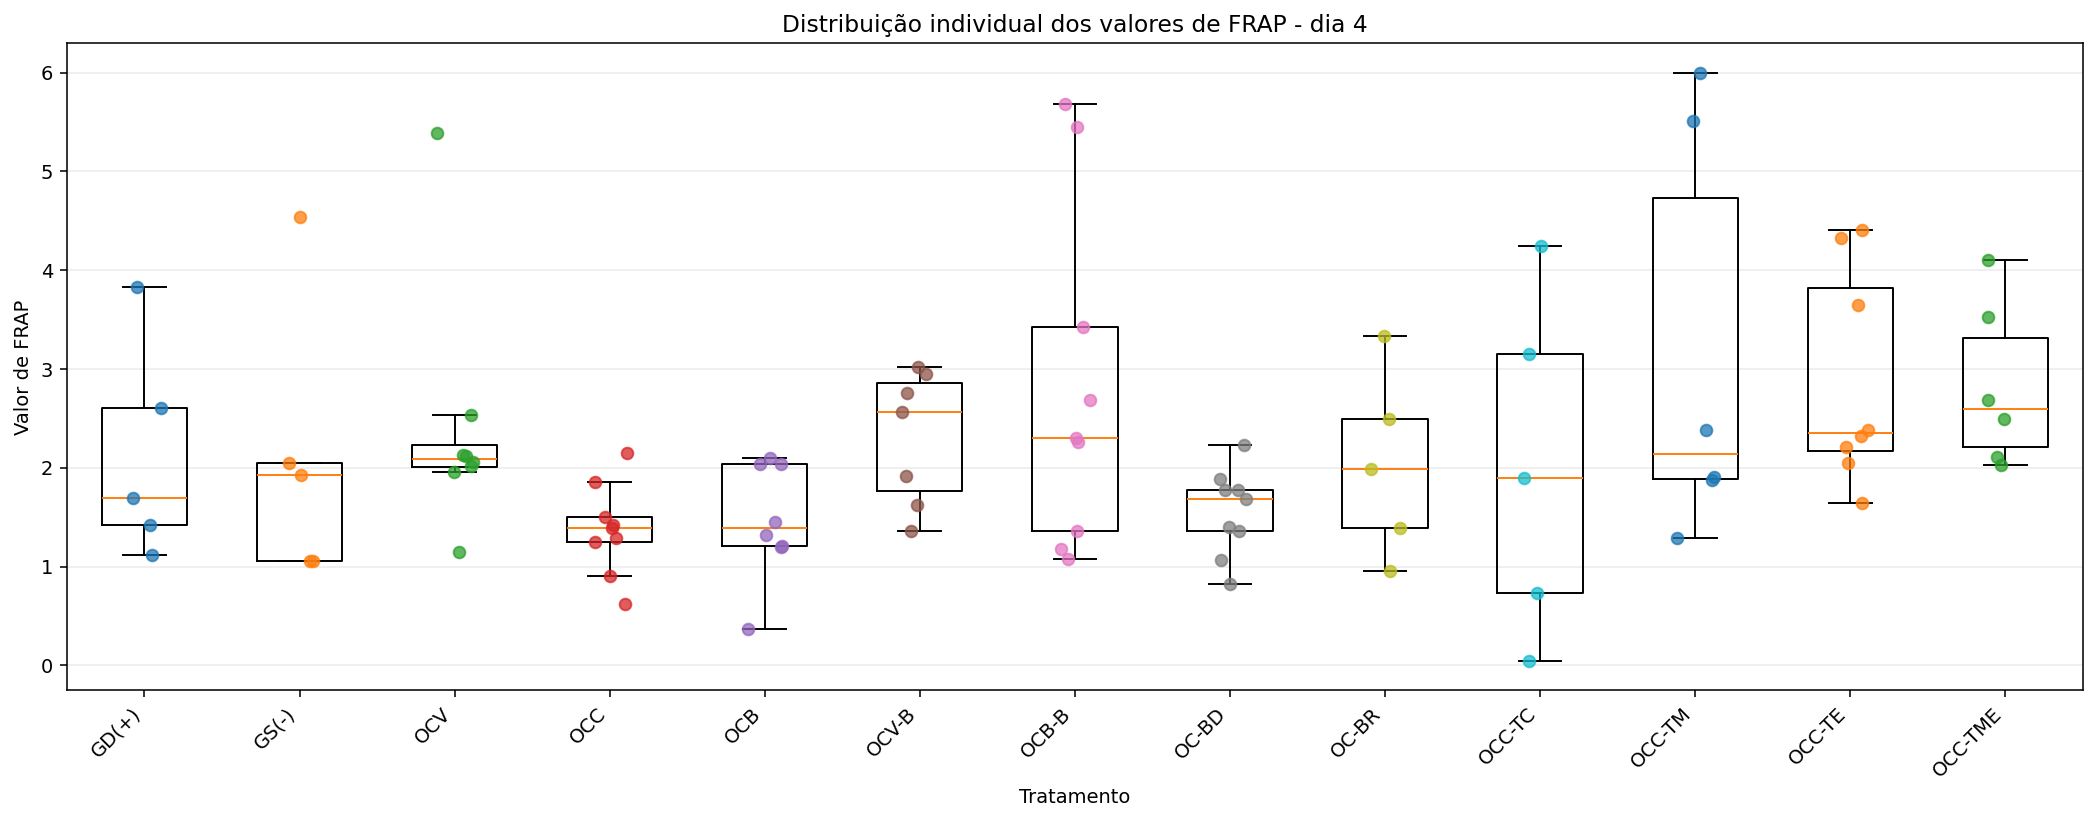

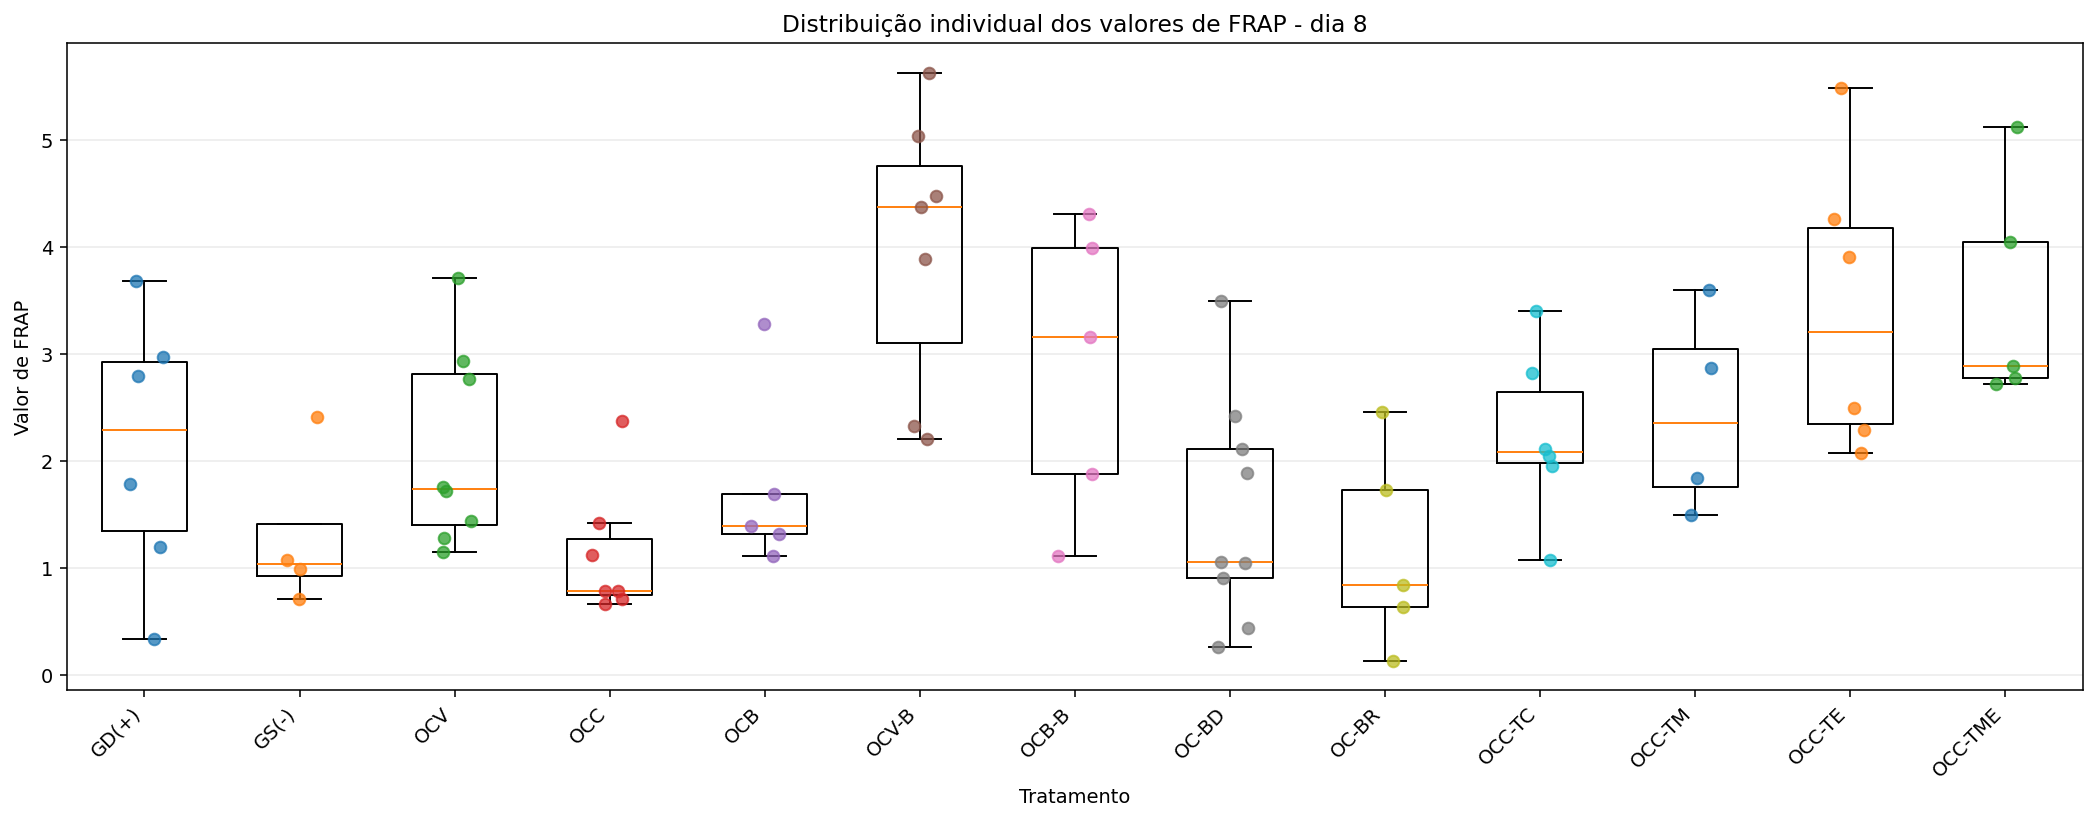


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_descritiva_frap_dias_4_8.csv
/kaggle/working/projeto001_resultados/projeto001_distribuicao_frap_dia_4.png
/kaggle/working/projeto001_resultados/projeto001_distribuicao_frap_dia_8.png


In [57]:
# ETAPA 53 — Análise descritiva e gráficos do FRAP
# Célula autossuficiente para o Kaggle
# Nenhuma exclusão adicional será realizada.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# =========================================================
# 1. Configurar os caminhos
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


ARQUIVO_BASE_FRAP = (
    PASTA_PROJETO
    / "projeto001_frap_individual_analise.csv"
)


if not ARQUIVO_BASE_FRAP.exists():

    arquivos_encontrados = list(
        Path("/kaggle/working").rglob(
            "projeto001_frap_individual_analise.csv"
        )
    )

    if len(arquivos_encontrados) == 1:

        ARQUIVO_BASE_FRAP = arquivos_encontrados[0]

    elif len(arquivos_encontrados) == 0:

        raise FileNotFoundError(
            "O arquivo "
            "'projeto001_frap_individual_analise.csv' "
            "não foi encontrado. Execute primeiro a Etapa 52."
        )

    else:

        print(
            "Foram encontradas várias bases analíticas do FRAP:"
        )

        for arquivo in arquivos_encontrados:

            print(
                arquivo
            )

        raise RuntimeError(
            "Não foi possível selecionar uma única base "
            "analítica do FRAP."
        )


print("Base analítica utilizada:")

print(
    ARQUIVO_BASE_FRAP
)


# =========================================================
# 2. Carregar a base analítica
# =========================================================

df_frap_individual_longa = pd.read_csv(
    ARQUIVO_BASE_FRAP,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("\nDimensão da base carregada:")

print(
    f"{df_frap_individual_longa.shape[0]} linhas × "
    f"{df_frap_individual_longa.shape[1]} colunas"
)


# =========================================================
# 3. Configurações
# =========================================================

COLUNA_VALOR_FRAP = "Valor_FRAP"

dias_esperados = [
    4,
    8
]

tratamentos_frap_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 4. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_FRAP
]


colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_frap_individual_longa.columns
]


if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base analítica do FRAP: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 5. Preparar os dados
# =========================================================

dados_frap = (
    df_frap_individual_longa[
        colunas_necessarias
    ]
    .copy()
)


dados_frap["Tratamento"] = (
    dados_frap["Tratamento"]
    .astype("string")
    .str.strip()
)


dados_frap["Dia"] = pd.to_numeric(
    dados_frap["Dia"],
    errors="coerce"
)


dados_frap[
    COLUNA_VALOR_FRAP
] = pd.to_numeric(
    dados_frap[
        COLUNA_VALOR_FRAP
    ],
    errors="coerce"
)


# =========================================================
# 6. Verificar linhas inválidas
# =========================================================

linhas_invalidas = (
    dados_frap["Tratamento"].isna()
    | dados_frap["Dia"].isna()
    | dados_frap[
        COLUNA_VALOR_FRAP
    ].isna()
    | ~np.isfinite(
        dados_frap[
            COLUNA_VALOR_FRAP
        ]
    )
)


if linhas_invalidas.any():

    print(
        "Linhas inválidas encontradas:"
    )

    display(
        dados_frap.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas na base analítica do FRAP."
    )


# =========================================================
# 7. Confirmar que não restaram valores negativos
# =========================================================

if (
    dados_frap[
        COLUNA_VALOR_FRAP
    ] < 0
).any():

    valores_negativos = (
        dados_frap.loc[
            dados_frap[
                COLUNA_VALOR_FRAP
            ] < 0
        ]
    )

    display(
        valores_negativos
    )

    raise ValueError(
        "A base analítica do FRAP ainda contém "
        "valores negativos."
    )


# =========================================================
# 8. Conferir dias e tratamentos
# =========================================================

dias_encontrados = sorted(
    dados_frap["Dia"]
    .astype(int)
    .unique()
    .tolist()
)


if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_frap[
        "Tratamento"
    ].unique()
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_frap_esperados
    if tratamento not in tratamentos_encontrados
]


tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(
        tratamentos_frap_esperados
    )
)


if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes na base do FRAP: "
        f"{tratamentos_ausentes}"
    )


if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos na base do FRAP: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 9. Confirmar os totais da Etapa 52
# =========================================================

total_dia_4 = int(
    (
        dados_frap[
            "Dia"
        ] == 4
    ).sum()
)


total_dia_8 = int(
    (
        dados_frap[
            "Dia"
        ] == 8
    ).sum()
)


if total_dia_4 != 90:

    raise ValueError(
        "O dia 4 deveria possuir 90 observações, "
        f"mas foram encontradas {total_dia_4}."
    )


if total_dia_8 != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas {total_dia_8}."
    )


print("\nTotais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 10. Calcular a estatística descritiva
# =========================================================

df_descritiva_frap = (
    dados_frap
    .groupby(
        [
            "Tratamento",
            "Dia"
        ],
        as_index=False
    )
    .agg(
        n=(
            COLUNA_VALOR_FRAP,
            "count"
        ),
        media=(
            COLUNA_VALOR_FRAP,
            "mean"
        ),
        desvio_padrao=(
            COLUNA_VALOR_FRAP,
            "std"
        ),
        minimo=(
            COLUNA_VALOR_FRAP,
            "min"
        ),
        primeiro_quartil=(
            COLUNA_VALOR_FRAP,
            lambda valores: valores.quantile(
                0.25
            )
        ),
        mediana=(
            COLUNA_VALOR_FRAP,
            "median"
        ),
        terceiro_quartil=(
            COLUNA_VALOR_FRAP,
            lambda valores: valores.quantile(
                0.75
            )
        ),
        maximo=(
            COLUNA_VALOR_FRAP,
            "max"
        )
    )
)


df_descritiva_frap[
    "intervalo_interquartil"
] = (
    df_descritiva_frap[
        "terceiro_quartil"
    ]
    - df_descritiva_frap[
        "primeiro_quartil"
    ]
)


# =========================================================
# 11. Garantir a ordem completa
# =========================================================

indice_completo = pd.MultiIndex.from_product(
    [
        tratamentos_frap_esperados,
        dias_esperados
    ],
    names=[
        "Tratamento",
        "Dia"
    ]
)


df_descritiva_frap = (
    df_descritiva_frap
    .set_index(
        [
            "Tratamento",
            "Dia"
        ]
    )
    .reindex(
        indice_completo
    )
    .reset_index()
)


if df_descritiva_frap[
    "n"
].isna().any():

    combinacoes_ausentes = (
        df_descritiva_frap.loc[
            df_descritiva_frap[
                "n"
            ].isna(),
            [
                "Tratamento",
                "Dia"
            ]
        ]
    )

    display(
        combinacoes_ausentes
    )

    raise ValueError(
        "Existem combinações de tratamento e dia "
        "sem observações."
    )


df_descritiva_frap[
    "n"
] = (
    df_descritiva_frap[
        "n"
    ]
    .astype(int)
)


# =========================================================
# 12. Exibir a estatística descritiva
# =========================================================

print("\nEstatística descritiva do FRAP:")

display(
    df_descritiva_frap.round(
        {
            "media": 6,
            "desvio_padrao": 6,
            "minimo": 6,
            "primeiro_quartil": 6,
            "mediana": 6,
            "terceiro_quartil": 6,
            "maximo": 6,
            "intervalo_interquartil": 6
        }
    )
)


# =========================================================
# 13. Identificar grupos com amostra pequena
# =========================================================

grupos_amostra_pequena = (
    df_descritiva_frap.loc[
        df_descritiva_frap[
            "n"
        ] < 3,
        [
            "Tratamento",
            "Dia",
            "n"
        ]
    ]
    .copy()
)


print("\nGrupos com menos de três observações:")

if grupos_amostra_pequena.empty:

    print(
        "Nenhum grupo possui menos de três observações."
    )

else:

    display(
        grupos_amostra_pequena
    )


# =========================================================
# 14. Criar tabela de contagens
# =========================================================

tabela_contagem_frap_descritiva = (
    df_descritiva_frap
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_frap_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .astype(int)
)


print("\nNúmero de observações por tratamento:")

display(
    tabela_contagem_frap_descritiva
)


# =========================================================
# 15. Criar os gráficos dos dias 4 e 8
# =========================================================

arquivos_graficos_frap = []


for dia in dias_esperados:

    dados_dia = (
        dados_frap.loc[
            dados_frap[
                "Dia"
            ] == dia
        ]
        .copy()
    )


    valores_boxplot = []
    posicoes_boxplot = []


    for posicao, tratamento in enumerate(
        tratamentos_frap_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia[
                    "Tratamento"
                ] == tratamento,
                COLUNA_VALOR_FRAP
            ]
            .to_numpy(
                dtype=float
            )
        )


        if len(
            valores
        ) == 0:

            raise ValueError(
                f"O tratamento {tratamento} não possui "
                f"observações no dia {dia}."
            )


        valores_boxplot.append(
            valores
        )

        posicoes_boxplot.append(
            posicao
        )


    plt.close(
        "all"
    )


    fig, ax = plt.subplots(
        figsize=(
            16,
            7
        )
    )


    ax.boxplot(
        valores_boxplot,
        positions=posicoes_boxplot,
        widths=0.55,
        showfliers=False
    )


    gerador_aleatorio = np.random.default_rng(
        20260806
        + dia
    )


    for posicao, tratamento in enumerate(
        tratamentos_frap_esperados,
        start=1
    ):

        valores = (
            dados_dia.loc[
                dados_dia[
                    "Tratamento"
                ] == tratamento,
                COLUNA_VALOR_FRAP
            ]
            .to_numpy(
                dtype=float
            )
        )


        deslocamento = gerador_aleatorio.uniform(
            -0.12,
            0.12,
            size=len(
                valores
            )
        )


        posicoes_pontos = (
            np.full(
                len(
                    valores
                ),
                posicao,
                dtype=float
            )
            + deslocamento
        )


        ax.scatter(
            posicoes_pontos,
            valores,
            alpha=0.75,
            zorder=3
        )


    ax.set_title(
        f"Distribuição individual dos valores de FRAP - dia {dia}"
    )

    ax.set_xlabel(
        "Tratamento"
    )

    ax.set_ylabel(
        "Valor de FRAP"
    )

    ax.set_xticks(
        range(
            1,
            len(
                tratamentos_frap_esperados
            ) + 1
        )
    )

    ax.set_xticklabels(
        tratamentos_frap_esperados,
        rotation=45,
        ha="right"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    ax.ticklabel_format(
        axis="y",
        style="plain",
        useOffset=False
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.98,
        bottom=0.24,
        top=0.90
    )


    arquivo_grafico = (
        PASTA_PROJETO
        / f"projeto001_distribuicao_frap_dia_{dia}.png"
    )


    fig.savefig(
        arquivo_grafico,
        dpi=300,
        format="png"
    )

    plt.show()

    plt.close(
        fig
    )


    arquivos_graficos_frap.append(
        arquivo_grafico
    )


# =========================================================
# 16. Salvar os resultados
# =========================================================

arquivo_descritiva_frap = (
    PASTA_PROJETO
    / "projeto001_descritiva_frap_dias_4_8.csv"
)


df_descritiva_frap.to_csv(
    arquivo_descritiva_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_descritiva_frap
)


for arquivo in arquivos_graficos_frap:

    print(
        arquivo
    )

## 54. Comparação global dos valores de FRAP por permutação

Os valores individuais de FRAP serão comparados entre os 13 tratamentos,
separadamente nos dias 4 e 8.

Será utilizada a estatística H de Kruskal-Wallis, com valor de p calculado
por 49.999 permutações.

A escolha desse procedimento considera:

- tamanhos amostrais desiguais;
- assimetria e sobreposição entre as distribuições;
- ausência de garantia de normalidade;
- maior robustez da análise baseada em postos.

Também será calculado o tamanho de efeito global por epsilon quadrado.

No ensaio de FRAP, valores maiores representam maior capacidade antioxidante.
Entretanto, esta etapa avaliará somente a existência de diferença global entre
os tratamentos.

Comparações específicas entre os óleos e os controles serão realizadas somente
nos dias em que o teste global apresentar valor de p inferior a 0,05.

In [58]:
# ETAPA 54 — Teste global do FRAP por permutação
# Kruskal-Wallis com 49.999 permutações
# Análises independentes para os dias 4 e 8
# Célula autossuficiente para o Kaggle

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import kruskal, rankdata
from IPython.display import display


# =========================================================
# 1. Configurar caminhos
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


ARQUIVO_BASE_FRAP = (
    PASTA_PROJETO
    / "projeto001_frap_individual_analise.csv"
)


if not ARQUIVO_BASE_FRAP.exists():

    arquivos_encontrados = list(
        Path("/kaggle/working").rglob(
            "projeto001_frap_individual_analise.csv"
        )
    )

    if len(arquivos_encontrados) == 1:

        ARQUIVO_BASE_FRAP = arquivos_encontrados[0]

    elif len(arquivos_encontrados) == 0:

        raise FileNotFoundError(
            "O arquivo "
            "'projeto001_frap_individual_analise.csv' "
            "não foi encontrado. Execute primeiro a Etapa 52."
        )

    else:

        print(
            "Foram encontradas várias bases analíticas do FRAP:"
        )

        for arquivo in arquivos_encontrados:

            print(
                arquivo
            )

        raise RuntimeError(
            "Não foi possível selecionar uma única base do FRAP."
        )


print("Base analítica utilizada:")

print(
    ARQUIVO_BASE_FRAP
)


# =========================================================
# 2. Carregar a base
# =========================================================

df_frap_individual_longa = pd.read_csv(
    ARQUIVO_BASE_FRAP,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("\nDimensão da base carregada:")

print(
    f"{df_frap_individual_longa.shape[0]} linhas × "
    f"{df_frap_individual_longa.shape[1]} colunas"
)


# =========================================================
# 3. Configurações da análise
# =========================================================

NUMERO_PERMUTACOES_FRAP = 49_999
SEMENTE_FRAP = 20260806
NIVEL_SIGNIFICANCIA = 0.05

COLUNA_VALOR_FRAP = "Valor_FRAP"

dias_esperados = [
    4,
    8
]

tratamentos_frap_esperados = [
    "GD(+)",
    "GS(-)",
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


# =========================================================
# 4. Verificar as colunas necessárias
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_FRAP
]


colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_frap_individual_longa.columns
]


if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base analítica do FRAP: "
        f"{colunas_ausentes}"
    )


# =========================================================
# 5. Preparar os dados
# =========================================================

dados_frap_teste = (
    df_frap_individual_longa[
        colunas_necessarias
    ]
    .copy()
)


dados_frap_teste["Tratamento"] = (
    dados_frap_teste["Tratamento"]
    .astype("string")
    .str.strip()
)


dados_frap_teste["Dia"] = pd.to_numeric(
    dados_frap_teste["Dia"],
    errors="coerce"
)


dados_frap_teste[
    COLUNA_VALOR_FRAP
] = pd.to_numeric(
    dados_frap_teste[
        COLUNA_VALOR_FRAP
    ],
    errors="coerce"
)


# =========================================================
# 6. Verificar linhas inválidas
# =========================================================

linhas_invalidas = (
    dados_frap_teste["Tratamento"].isna()
    | dados_frap_teste["Dia"].isna()
    | dados_frap_teste[
        COLUNA_VALOR_FRAP
    ].isna()
    | ~np.isfinite(
        dados_frap_teste[
            COLUNA_VALOR_FRAP
        ]
    )
)


if linhas_invalidas.any():

    print(
        "Linhas inválidas encontradas:"
    )

    display(
        dados_frap_teste.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas na base do FRAP."
    )


# =========================================================
# 7. Confirmar a ausência de valores negativos
# =========================================================

if (
    dados_frap_teste[
        COLUNA_VALOR_FRAP
    ] < 0
).any():

    valores_negativos = (
        dados_frap_teste.loc[
            dados_frap_teste[
                COLUNA_VALOR_FRAP
            ] < 0
        ]
    )

    display(
        valores_negativos
    )

    raise ValueError(
        "A base analítica do FRAP ainda contém "
        "valores negativos."
    )


# =========================================================
# 8. Conferir dias e tratamentos
# =========================================================

dias_encontrados = sorted(
    dados_frap_teste["Dia"]
    .astype(int)
    .unique()
    .tolist()
)


if dias_encontrados != dias_esperados:

    raise ValueError(
        "Os dias encontrados não correspondem "
        f"aos dias 4 e 8: {dias_encontrados}"
    )


tratamentos_encontrados = set(
    dados_frap_teste[
        "Tratamento"
    ].unique()
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_frap_esperados
    if tratamento not in tratamentos_encontrados
]


tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(
        tratamentos_frap_esperados
    )
)


if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes na base do FRAP: "
        f"{tratamentos_ausentes}"
    )


if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos na base do FRAP: "
        f"{tratamentos_nao_previstos}"
    )


# =========================================================
# 9. Confirmar os totais
# =========================================================

total_dia_4 = int(
    (
        dados_frap_teste[
            "Dia"
        ] == 4
    ).sum()
)


total_dia_8 = int(
    (
        dados_frap_teste[
            "Dia"
        ] == 8
    ).sum()
)


if total_dia_4 != 90:

    raise ValueError(
        "O dia 4 deveria possuir 90 observações, "
        f"mas foram encontradas {total_dia_4}."
    )


if total_dia_8 != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas foram encontradas {total_dia_8}."
    )


print("\nTotais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 10. Função para correção de empates
# =========================================================

def calcular_correcao_empates_frap(
    valores
):

    valores = np.asarray(
        valores,
        dtype=float
    )


    _, contagens = np.unique(
        valores,
        return_counts=True
    )


    numero_total = len(
        valores
    )


    if numero_total < 2:

        raise ValueError(
            "Número insuficiente de observações."
        )


    denominador = (
        numero_total**3
        - numero_total
    )


    numerador = np.sum(
        contagens**3
        - contagens
    )


    correcao = (
        1.0
        - numerador / denominador
    )


    if correcao <= 0:

        raise ValueError(
            "Não foi possível calcular a correção de empates."
        )


    return float(
        correcao
    )


# =========================================================
# 11. Função para calcular a estatística H
# =========================================================

def calcular_h_frap(
    postos,
    tamanhos_grupos,
    correcao_empates
):

    postos = np.asarray(
        postos,
        dtype=float
    )


    numero_total = len(
        postos
    )


    inicio = 0
    soma_componentes = 0.0


    for tamanho in tamanhos_grupos:

        final = (
            inicio
            + tamanho
        )


        soma_postos = np.sum(
            postos[
                inicio:final
            ]
        )


        soma_componentes += (
            soma_postos**2
            / tamanho
        )


        inicio = final


    if inicio != numero_total:

        raise RuntimeError(
            "A soma dos tamanhos dos grupos não corresponde "
            "ao número total de postos."
        )


    h_sem_correcao = (
        12.0
        / (
            numero_total
            * (
                numero_total
                + 1
            )
        )
        * soma_componentes
        - 3.0
        * (
            numero_total
            + 1
        )
    )


    h_corrigido = (
        h_sem_correcao
        / correcao_empates
    )


    return float(
        h_corrigido
    )


# =========================================================
# 12. Executar o teste nos dias 4 e 8
# =========================================================

resultados_globais_frap = []
contagens_teste_frap = []

inicio_etapa = time.perf_counter()


for dia in dias_esperados:

    print("\n" + "=" * 90)

    print(
        f"PROCESSANDO FRAP — DIA {dia}"
    )


    dados_dia = (
        dados_frap_teste.loc[
            dados_frap_teste[
                "Dia"
            ] == dia
        ]
        .copy()
    )


    grupos = []
    tamanhos_grupos = []


    for tratamento in tratamentos_frap_esperados:

        valores = (
            dados_dia.loc[
                dados_dia[
                    "Tratamento"
                ] == tratamento,
                COLUNA_VALOR_FRAP
            ]
            .to_numpy(
                dtype=float
            )
        )


        numero_observacoes = len(
            valores
        )


        contagens_teste_frap.append(
            {
                "Dia": dia,
                "Tratamento": tratamento,
                "n": numero_observacoes
            }
        )


        if numero_observacoes < 2:

            raise ValueError(
                f"O tratamento {tratamento} possui somente "
                f"{numero_observacoes} observação(ões) "
                f"no dia {dia}."
            )


        grupos.append(
            valores
        )


        tamanhos_grupos.append(
            numero_observacoes
        )


    if len(
        grupos
    ) != 13:

        raise RuntimeError(
            "Eram esperados 13 grupos no teste global, "
            f"mas foram encontrados {len(grupos)}."
        )


    numero_grupos = len(
        grupos
    )


    numero_total = sum(
        tamanhos_grupos
    )


    valores_concatenados = np.concatenate(
        grupos
    )


    postos = rankdata(
        valores_concatenados,
        method="average"
    )


    correcao_empates = (
        calcular_correcao_empates_frap(
            valores_concatenados
        )
    )


    h_observado = calcular_h_frap(
        postos=postos,
        tamanhos_grupos=tamanhos_grupos,
        correcao_empates=correcao_empates
    )


    # -----------------------------------------------------
    # Conferência com o teste convencional do SciPy
    # -----------------------------------------------------

    resultado_assintotico = kruskal(
        *grupos,
        nan_policy="raise"
    )


    h_scipy = float(
        resultado_assintotico.statistic
    )


    p_assintotico = float(
        resultado_assintotico.pvalue
    )


    if not np.isclose(
        h_observado,
        h_scipy,
        rtol=1e-10,
        atol=1e-10
    ):

        raise RuntimeError(
            "A estatística H calculada manualmente não coincide "
            "com o resultado do SciPy."
        )


    # -----------------------------------------------------
    # Permutações
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        SEMENTE_FRAP
        + dia
    )


    numero_extremos = 0


    inicio_dia = time.perf_counter()


    for _ in range(
        NUMERO_PERMUTACOES_FRAP
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )


        h_permutado = calcular_h_frap(
            postos=postos_permutados,
            tamanhos_grupos=tamanhos_grupos,
            correcao_empates=correcao_empates
        )


        if h_permutado >= (
            h_observado
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        NUMERO_PERMUTACOES_FRAP
        + 1
    )


    erro_padrao_monte_carlo = np.sqrt(
        valor_p_permutacao
        * (
            1.0
            - valor_p_permutacao
        )
        / (
            NUMERO_PERMUTACOES_FRAP
            + 1
        )
    )


    # -----------------------------------------------------
    # Tamanho de efeito global
    # -----------------------------------------------------

    epsilon_quadrado = (
        h_observado
        - numero_grupos
        + 1
    ) / (
        numero_total
        - numero_grupos
    )


    epsilon_quadrado = float(
        np.clip(
            epsilon_quadrado,
            0.0,
            1.0
        )
    )


    # -----------------------------------------------------
    # Conclusão
    # -----------------------------------------------------

    if valor_p_permutacao < NIVEL_SIGNIFICANCIA:

        conclusao = (
            "Há evidência de diferença global "
            "entre os tratamentos."
        )

    else:

        conclusao = (
            "Não há evidência de diferença global "
            "entre os tratamentos."
        )


    tempo_dia = (
        time.perf_counter()
        - inicio_dia
    )


    resultados_globais_frap.append(
        {
            "Dia": dia,
            "Numero_de_tratamentos": numero_grupos,
            "Numero_total_de_observacoes": numero_total,
            "Menor_n": min(
                tamanhos_grupos
            ),
            "Maior_n": max(
                tamanhos_grupos
            ),
            "Estatistica_H": h_observado,
            "Graus_de_liberdade": (
                numero_grupos
                - 1
            ),
            "Valor_p_assintotico": p_assintotico,
            "Numero_de_permutacoes": (
                NUMERO_PERMUTACOES_FRAP
            ),
            "Permutacoes_iguais_ou_maiores": (
                numero_extremos
            ),
            "Valor_p_permutacao": (
                valor_p_permutacao
            ),
            "Erro_padrao_Monte_Carlo": (
                erro_padrao_monte_carlo
            ),
            "Epsilon_quadrado": (
                epsilon_quadrado
            ),
            "Tempo_segundos": (
                tempo_dia
            ),
            "Conclusao_5_percent": (
                conclusao
            )
        }
    )


    print(
        f"H observado: {h_observado:.6f}"
    )


    print(
        f"p assintótico: {p_assintotico:.8f}"
    )


    print(
        "p por permutação: "
        f"{valor_p_permutacao:.8f}"
    )


    print(
        f"ε²: {epsilon_quadrado:.4f}"
    )


    print(
        f"Tempo: {tempo_dia:.2f} segundos"
    )


    print(
        conclusao
    )


# =========================================================
# 13. Criar as tabelas finais
# =========================================================

df_resultados_permutacao_frap = pd.DataFrame(
    resultados_globais_frap
)


df_contagens_teste_frap = pd.DataFrame(
    contagens_teste_frap
)


tabela_contagens_teste_frap = (
    df_contagens_teste_frap
    .pivot(
        index="Tratamento",
        columns="Dia",
        values="n"
    )
    .reindex(
        tratamentos_frap_esperados
    )
    .rename(
        columns={
            4: "n_Dia_4",
            8: "n_Dia_8"
        }
    )
    .fillna(0)
    .astype(int)
)


# =========================================================
# 14. Exibir os resultados
# =========================================================

print("\n" + "=" * 90)

print(
    "CONTAGENS UTILIZADAS NO TESTE DO FRAP"
)


display(
    tabela_contagens_teste_frap
)


print("\nRESULTADOS GLOBAIS DO FRAP")


display(
    df_resultados_permutacao_frap.round(
        {
            "Estatistica_H": 6,
            "Valor_p_assintotico": 8,
            "Valor_p_permutacao": 8,
            "Erro_padrao_Monte_Carlo": 8,
            "Epsilon_quadrado": 4,
            "Tempo_segundos": 2
        }
    )
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)


print(
    f"\nTempo total da Etapa 54: "
    f"{tempo_total:.2f} segundos"
)


# =========================================================
# 15. Salvar os resultados
# =========================================================

arquivo_teste_global_frap = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_frap.csv"
)


arquivo_contagens_teste_frap = (
    PASTA_PROJETO
    / "projeto001_contagens_teste_global_frap.csv"
)


df_resultados_permutacao_frap.to_csv(
    arquivo_teste_global_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tabela_contagens_teste_frap.to_csv(
    arquivo_contagens_teste_frap,
    sep=";",
    decimal=",",
    index=True,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    arquivo_teste_global_frap
)


print(
    arquivo_contagens_teste_frap
)

Base analítica utilizada:
/kaggle/working/projeto001_resultados/projeto001_frap_individual_analise.csv

Dimensão da base carregada:
167 linhas × 17 colunas

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

PROCESSANDO FRAP — DIA 4
H observado: 24.321843
p assintótico: 0.01838436
p por permutação: 0.01068000
ε²: 0.1600
Tempo: 2.63 segundos
Há evidência de diferença global entre os tratamentos.

PROCESSANDO FRAP — DIA 8
H observado: 35.539920
p assintótico: 0.00038400
p por permutação: 0.00004000
ε²: 0.3678
Tempo: 2.58 segundos
Há evidência de diferença global entre os tratamentos.

CONTAGENS UTILIZADAS NO TESTE DO FRAP


Dia,n_Dia_4,n_Dia_8
Tratamento,,
GD(+),5,6
GS(-),5,4
OCV,8,8
OCC,9,7
OCB,8,5
OCV-B,7,7
OCB-B,9,5
OC-BD,9,9
OC-BR,5,5



RESULTADOS GLOBAIS DO FRAP


,Dia,Numero_de_tratamentos,Numero_total_de_observacoes,Menor_n,Maior_n,Estatistica_H,Graus_de_liberdade,Valor_p_assintotico,Numero_de_permutacoes,Permutacoes_iguais_ou_maiores,Valor_p_permutacao,Erro_padrao_Monte_Carlo,Epsilon_quadrado,Tempo_segundos,Conclusao_5_percent
0,4,13,90,5,9,24.321843,12,0.018384,49999,533,0.01068,0.000460,0.1600,2.63,Há evidência de diferença global entre os trat...
1,8,13,77,4,9,35.539920,12,0.000384,49999,1,0.00004,0.000028,0.3678,2.58,Há evidência de diferença global entre os trat...



Tempo total da Etapa 54: 5.24 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_teste_global_permutacao_frap.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_teste_global_frap.csv


## 55. Comparações dos valores de FRAP entre os óleos e os controles

Como os testes globais por permutação identificaram diferenças significativas
entre os tratamentos nos dias 4 e 8, serão realizadas comparações planejadas
entre cada óleo e os controles GD(+) e GS(-).

Será utilizado o teste bilateral de permutação baseado na estatística U de
Mann–Whitney, com 49.999 permutações por comparação.

Em cada dia, os valores de p das 22 comparações serão corrigidos conjuntamente
pelo método de Holm. Os dias 4 e 8 constituirão famílias independentes de testes.

Também serão apresentados:

- número de observações em cada grupo;
- medianas do óleo e do controle;
- diferença entre medianas;
- correlação bisserial de postos;
- magnitude e direção do efeito.

No ensaio de FRAP, valores superiores aos controles indicam maior capacidade
antioxidante e representam uma direção biologicamente favorável.

In [59]:
# ETAPA 55 — Comparações do FRAP entre os óleos e os controles
# Dias 4 e 8
# Teste U de Mann-Whitney por permutação
# Correção de Holm separadamente em cada dia
# Célula autossuficiente para o Kaggle

from pathlib import Path
import time

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


ARQUIVO_BASE_FRAP = (
    PASTA_PROJETO
    / "projeto001_frap_individual_analise.csv"
)

ARQUIVO_GLOBAL_FRAP = (
    PASTA_PROJETO
    / "projeto001_teste_global_permutacao_frap.csv"
)


COLUNA_VALOR_FRAP = "Valor_FRAP"

NUMERO_PERMUTACOES_PARES_FRAP = 49_999
SEMENTE_PARES_FRAP = 20260806
NIVEL_SIGNIFICANCIA = 0.05


dias_analisados = [
    4,
    8
]


controles_frap = [
    "GD(+)",
    "GS(-)"
]


oleos_frap = [
    "OCV",
    "OCC",
    "OCB",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME"
]


tratamentos_esperados = (
    controles_frap
    + oleos_frap
)


# =========================================================
# 2. Localizar a base analítica
# =========================================================

if not ARQUIVO_BASE_FRAP.exists():

    arquivos_encontrados = list(
        Path("/kaggle/working").rglob(
            "projeto001_frap_individual_analise.csv"
        )
    )

    if len(arquivos_encontrados) == 1:

        ARQUIVO_BASE_FRAP = arquivos_encontrados[0]

    elif len(arquivos_encontrados) == 0:

        raise FileNotFoundError(
            "A base analítica do FRAP não foi encontrada. "
            "Execute primeiro a Etapa 52."
        )

    else:

        print(
            "Foram encontradas várias bases do FRAP:"
        )

        for arquivo in arquivos_encontrados:

            print(
                arquivo
            )

        raise RuntimeError(
            "Não foi possível selecionar uma única base."
        )


print("Base analítica utilizada:")

print(
    ARQUIVO_BASE_FRAP
)


# =========================================================
# 3. Carregar a base analítica
# =========================================================

df_frap_individual_longa = pd.read_csv(
    ARQUIVO_BASE_FRAP,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("\nDimensão da base carregada:")

print(
    f"{df_frap_individual_longa.shape[0]} linhas × "
    f"{df_frap_individual_longa.shape[1]} colunas"
)


# =========================================================
# 4. Localizar e carregar o teste global
# =========================================================

if not ARQUIVO_GLOBAL_FRAP.exists():

    arquivos_globais = list(
        Path("/kaggle/working").rglob(
            "projeto001_teste_global_permutacao_frap.csv"
        )
    )

    if len(arquivos_globais) == 1:

        ARQUIVO_GLOBAL_FRAP = arquivos_globais[0]

    elif len(arquivos_globais) == 0:

        raise FileNotFoundError(
            "O resultado global do FRAP não foi encontrado. "
            "Execute primeiro a Etapa 54."
        )

    else:

        print(
            "Foram encontrados vários resultados globais:"
        )

        for arquivo in arquivos_globais:

            print(
                arquivo
            )

        raise RuntimeError(
            "Não foi possível selecionar um único "
            "resultado global."
        )


df_resultados_globais_frap = pd.read_csv(
    ARQUIVO_GLOBAL_FRAP,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


# =========================================================
# 5. Conferir os resultados globais
# =========================================================

colunas_globais_necessarias = [
    "Dia",
    "Numero_total_de_observacoes",
    "Valor_p_permutacao"
]


colunas_globais_ausentes = [
    coluna
    for coluna in colunas_globais_necessarias
    if coluna not in df_resultados_globais_frap.columns
]


if colunas_globais_ausentes:

    raise ValueError(
        "Colunas ausentes no resultado global do FRAP: "
        f"{colunas_globais_ausentes}"
    )


for dia, total_esperado in [
    (4, 90),
    (8, 77)
]:

    resultado_dia = (
        df_resultados_globais_frap.loc[
            df_resultados_globais_frap[
                "Dia"
            ] == dia
        ]
    )


    if len(resultado_dia) != 1:

        raise ValueError(
            f"Não foi encontrado exatamente um resultado "
            f"global para o dia {dia}."
        )


    total_encontrado = int(
        resultado_dia[
            "Numero_total_de_observacoes"
        ].iloc[0]
    )


    valor_p_global = float(
        resultado_dia[
            "Valor_p_permutacao"
        ].iloc[0]
    )


    if total_encontrado != total_esperado:

        raise ValueError(
            f"O teste global do dia {dia} deveria possuir "
            f"{total_esperado} observações, mas possui "
            f"{total_encontrado}."
        )


    if valor_p_global >= NIVEL_SIGNIFICANCIA:

        raise ValueError(
            f"O teste global do dia {dia} não foi "
            "significativo. As comparações desse dia "
            "não deveriam ser realizadas."
        )


    print(
        f"\nDia {dia}: teste global confirmado, "
        f"p = {valor_p_global:.8f}"
    )


# =========================================================
# 6. Preparar os dados
# =========================================================

colunas_necessarias = [
    "Tratamento",
    "Dia",
    COLUNA_VALOR_FRAP
]


colunas_ausentes = [
    coluna
    for coluna in colunas_necessarias
    if coluna not in df_frap_individual_longa.columns
]


if colunas_ausentes:

    raise ValueError(
        "Colunas ausentes na base analítica do FRAP: "
        f"{colunas_ausentes}"
    )


dados_frap = (
    df_frap_individual_longa[
        colunas_necessarias
    ]
    .copy()
)


dados_frap["Tratamento"] = (
    dados_frap["Tratamento"]
    .astype("string")
    .str.strip()
)


dados_frap["Dia"] = pd.to_numeric(
    dados_frap["Dia"],
    errors="coerce"
)


dados_frap[
    COLUNA_VALOR_FRAP
] = pd.to_numeric(
    dados_frap[
        COLUNA_VALOR_FRAP
    ],
    errors="coerce"
)


# =========================================================
# 7. Validar a base analítica
# =========================================================

linhas_invalidas = (
    dados_frap["Tratamento"].isna()
    | dados_frap["Dia"].isna()
    | dados_frap[
        COLUNA_VALOR_FRAP
    ].isna()
    | ~np.isfinite(
        dados_frap[
            COLUNA_VALOR_FRAP
        ]
    )
)


if linhas_invalidas.any():

    print(
        "Linhas inválidas encontradas:"
    )

    display(
        dados_frap.loc[
            linhas_invalidas
        ]
    )

    raise ValueError(
        "Existem linhas inválidas na base do FRAP."
    )


if (
    dados_frap[
        COLUNA_VALOR_FRAP
    ] < 0
).any():

    raise ValueError(
        "A base analítica do FRAP contém "
        "valores negativos."
    )


tratamentos_encontrados = set(
    dados_frap[
        "Tratamento"
    ].unique()
)


tratamentos_ausentes = [
    tratamento
    for tratamento in tratamentos_esperados
    if tratamento not in tratamentos_encontrados
]


tratamentos_nao_previstos = sorted(
    tratamentos_encontrados
    - set(
        tratamentos_esperados
    )
)


if tratamentos_ausentes:

    raise ValueError(
        "Tratamentos ausentes: "
        f"{tratamentos_ausentes}"
    )


if tratamentos_nao_previstos:

    raise ValueError(
        "Tratamentos não previstos: "
        f"{tratamentos_nao_previstos}"
    )


total_dia_4 = int(
    (
        dados_frap[
            "Dia"
        ] == 4
    ).sum()
)


total_dia_8 = int(
    (
        dados_frap[
            "Dia"
        ] == 8
    ).sum()
)


if total_dia_4 != 90:

    raise ValueError(
        "O dia 4 deveria possuir 90 observações, "
        f"mas possui {total_dia_4}."
    )


if total_dia_8 != 77:

    raise ValueError(
        "O dia 8 deveria possuir 77 observações, "
        f"mas possui {total_dia_8}."
    )


print("\nTotais conferidos:")

print(
    f"Dia 4: {total_dia_4} observações"
)

print(
    f"Dia 8: {total_dia_8} observações"
)


# =========================================================
# 8. Classificar a magnitude do efeito
# =========================================================

def classificar_magnitude_bisserial(
    valor
):

    valor_absoluto = abs(
        valor
    )

    if valor_absoluto < 0.10:
        return "Desprezível"

    if valor_absoluto < 0.30:
        return "Pequeno"

    if valor_absoluto < 0.50:
        return "Moderado"

    return "Grande"


# =========================================================
# 9. Função do teste U por permutação
# =========================================================

def teste_u_por_permutacao(
    valores_oleo,
    valores_controle,
    numero_permutacoes,
    semente
):

    valores_oleo = np.asarray(
        valores_oleo,
        dtype=float
    )


    valores_controle = np.asarray(
        valores_controle,
        dtype=float
    )


    n_oleo = len(
        valores_oleo
    )


    n_controle = len(
        valores_controle
    )


    if n_oleo < 2 or n_controle < 2:

        raise ValueError(
            "Cada grupo deve possuir pelo menos "
            "duas observações."
        )


    valores_combinados = np.concatenate(
        [
            valores_oleo,
            valores_controle
        ]
    )


    postos = rankdata(
        valores_combinados,
        method="average"
    )


    soma_postos_oleo = np.sum(
        postos[
            :n_oleo
        ]
    )


    u_observado = (
        soma_postos_oleo
        - n_oleo
        * (
            n_oleo
            + 1
        )
        / 2
    )


    centro_u = (
        n_oleo
        * n_controle
        / 2
    )


    distancia_observada = abs(
        u_observado
        - centro_u
    )


    gerador = np.random.default_rng(
        semente
    )


    numero_extremos = 0


    for _ in range(
        numero_permutacoes
    ):

        postos_permutados = (
            gerador.permutation(
                postos
            )
        )


        soma_postos_permutada = np.sum(
            postos_permutados[
                :n_oleo
            ]
        )


        u_permutado = (
            soma_postos_permutada
            - n_oleo
            * (
                n_oleo
                + 1
            )
            / 2
        )


        distancia_permutada = abs(
            u_permutado
            - centro_u
        )


        if distancia_permutada >= (
            distancia_observada
            - 1e-12
        ):

            numero_extremos += 1


    valor_p_permutacao = (
        numero_extremos
        + 1
    ) / (
        numero_permutacoes
        + 1
    )


    correlacao_bisserial = (
        2.0
        * u_observado
        / (
            n_oleo
            * n_controle
        )
        - 1.0
    )


    return {
        "Estatistica_U": float(
            u_observado
        ),
        "Valor_p_permutacao": float(
            valor_p_permutacao
        ),
        "Permutacoes_iguais_ou_maiores": int(
            numero_extremos
        ),
        "Correlacao_bisserial_postos": float(
            correlacao_bisserial
        )
    }


# =========================================================
# 10. Executar as 44 comparações
# =========================================================

resultados_comparacoes_frap = []

contador_comparacao = 0

inicio_etapa = time.perf_counter()


for dia in dias_analisados:

    dados_dia = (
        dados_frap.loc[
            dados_frap[
                "Dia"
            ] == dia
        ]
        .copy()
    )


    for controle in controles_frap:

        valores_controle = (
            dados_dia.loc[
                dados_dia[
                    "Tratamento"
                ] == controle,
                COLUNA_VALOR_FRAP
            ]
            .to_numpy(
                dtype=float
            )
        )


        for oleo in oleos_frap:

            contador_comparacao += 1


            valores_oleo = (
                dados_dia.loc[
                    dados_dia[
                        "Tratamento"
                    ] == oleo,
                    COLUNA_VALOR_FRAP
                ]
                .to_numpy(
                    dtype=float
                )
            )


            resultado_permutacao = (
                teste_u_por_permutacao(
                    valores_oleo=valores_oleo,
                    valores_controle=valores_controle,
                    numero_permutacoes=(
                        NUMERO_PERMUTACOES_PARES_FRAP
                    ),
                    semente=(
                        SEMENTE_PARES_FRAP
                        + contador_comparacao
                    )
                )
            )


            resultado_assintotico = mannwhitneyu(
                valores_oleo,
                valores_controle,
                alternative="two-sided",
                method="asymptotic"
            )


            mediana_oleo = float(
                np.median(
                    valores_oleo
                )
            )


            mediana_controle = float(
                np.median(
                    valores_controle
                )
            )


            diferenca_medianas = (
                mediana_oleo
                - mediana_controle
            )


            efeito = (
                resultado_permutacao[
                    "Correlacao_bisserial_postos"
                ]
            )


            if efeito > 0:

                direcao_efeito = (
                    "Óleo apresentou tendência a maior FRAP"
                )

                interpretacao_biologica = (
                    "Favorável"
                )


            elif efeito < 0:

                direcao_efeito = (
                    "Óleo apresentou tendência a menor FRAP"
                )

                interpretacao_biologica = (
                    "Desfavorável"
                )


            else:

                direcao_efeito = (
                    "Não houve direção predominante"
                )

                interpretacao_biologica = (
                    "Neutra"
                )


            resultados_comparacoes_frap.append(
                {
                    "Dia": dia,
                    "Oleo": oleo,
                    "Controle": controle,
                    "n_Oleo": len(
                        valores_oleo
                    ),
                    "n_Controle": len(
                        valores_controle
                    ),
                    "Mediana_Oleo": mediana_oleo,
                    "Mediana_Controle": mediana_controle,
                    "Diferenca_Medianas": diferenca_medianas,
                    "Estatistica_U": (
                        resultado_permutacao[
                            "Estatistica_U"
                        ]
                    ),
                    "Valor_p_assintotico": float(
                        resultado_assintotico.pvalue
                    ),
                    "Numero_de_permutacoes": (
                        NUMERO_PERMUTACOES_PARES_FRAP
                    ),
                    "Permutacoes_iguais_ou_maiores": (
                        resultado_permutacao[
                            "Permutacoes_iguais_ou_maiores"
                        ]
                    ),
                    "Valor_p_permutacao": (
                        resultado_permutacao[
                            "Valor_p_permutacao"
                        ]
                    ),
                    "Correlacao_bisserial_postos": efeito,
                    "Magnitude_efeito": (
                        classificar_magnitude_bisserial(
                            efeito
                        )
                    ),
                    "Direcao_efeito": direcao_efeito,
                    "Interpretacao_biologica": (
                        interpretacao_biologica
                    )
                }
            )


# =========================================================
# 11. Criar a tabela de resultados
# =========================================================

df_comparacoes_frap = pd.DataFrame(
    resultados_comparacoes_frap
)


if len(
    df_comparacoes_frap
) != 44:

    raise RuntimeError(
        "Eram esperadas 44 comparações, "
        f"mas foram produzidas "
        f"{len(df_comparacoes_frap)}."
    )


# =========================================================
# 12. Aplicar Holm separadamente em cada dia
# =========================================================

df_comparacoes_frap[
    "Valor_p_Holm"
] = np.nan


df_comparacoes_frap[
    "Significativo_Holm_5_percent"
] = False


for dia in dias_analisados:

    mascara_dia = (
        df_comparacoes_frap[
            "Dia"
        ] == dia
    )


    valores_p_dia = (
        df_comparacoes_frap.loc[
            mascara_dia,
            "Valor_p_permutacao"
        ]
        .to_numpy(
            dtype=float
        )
    )


    if len(
        valores_p_dia
    ) != 22:

        raise RuntimeError(
            f"Eram esperadas 22 comparações no dia {dia}, "
            f"mas foram encontradas "
            f"{len(valores_p_dia)}."
        )


    rejeitar_h0, valores_p_holm, _, _ = multipletests(
        valores_p_dia,
        alpha=NIVEL_SIGNIFICANCIA,
        method="holm"
    )


    df_comparacoes_frap.loc[
        mascara_dia,
        "Valor_p_Holm"
    ] = valores_p_holm


    df_comparacoes_frap.loc[
        mascara_dia,
        "Significativo_Holm_5_percent"
    ] = rejeitar_h0


df_comparacoes_frap[
    "Conclusao"
] = np.where(
    df_comparacoes_frap[
        "Significativo_Holm_5_percent"
    ],
    (
        "Diferença significativa após "
        "correção de Holm"
    ),
    (
        "Diferença não significativa após "
        "correção de Holm"
    )
)


# =========================================================
# 13. Ordenar os resultados
# =========================================================

df_comparacoes_frap = (
    df_comparacoes_frap
    .sort_values(
        [
            "Dia",
            "Controle",
            "Valor_p_Holm",
            "Oleo"
        ]
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 14. Exibir resultados por dia e controle
# =========================================================

for dia in dias_analisados:

    for controle in controles_frap:

        print("\n" + "=" * 120)

        print(
            f"FRAP — DIA {dia} — "
            f"ÓLEOS VERSUS {controle}"
        )


        tabela_exibicao = (
            df_comparacoes_frap.loc[
                (
                    df_comparacoes_frap[
                        "Dia"
                    ] == dia
                )
                & (
                    df_comparacoes_frap[
                        "Controle"
                    ] == controle
                ),
                [
                    "Oleo",
                    "n_Oleo",
                    "n_Controle",
                    "Mediana_Oleo",
                    "Mediana_Controle",
                    "Diferenca_Medianas",
                    "Valor_p_permutacao",
                    "Valor_p_Holm",
                    "Significativo_Holm_5_percent",
                    "Correlacao_bisserial_postos",
                    "Magnitude_efeito",
                    "Direcao_efeito",
                    "Interpretacao_biologica"
                ]
            ]
        )


        display(
            tabela_exibicao.round(
                {
                    "Mediana_Oleo": 6,
                    "Mediana_Controle": 6,
                    "Diferenca_Medianas": 6,
                    "Valor_p_permutacao": 6,
                    "Valor_p_Holm": 6,
                    "Correlacao_bisserial_postos": 4
                }
            )
        )


# =========================================================
# 15. Selecionar comparações significativas
# =========================================================

df_comparacoes_significativas_frap = (
    df_comparacoes_frap.loc[
        df_comparacoes_frap[
            "Significativo_Holm_5_percent"
        ]
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 120)

print(
    "COMPARAÇÕES SIGNIFICATIVAS DO FRAP "
    "APÓS CORREÇÃO DE HOLM"
)


if df_comparacoes_significativas_frap.empty:

    print(
        "Nenhuma comparação permaneceu significativa "
        "após a correção de Holm."
    )

else:

    display(
        df_comparacoes_significativas_frap[
            [
                "Dia",
                "Oleo",
                "Controle",
                "n_Oleo",
                "n_Controle",
                "Mediana_Oleo",
                "Mediana_Controle",
                "Diferenca_Medianas",
                "Valor_p_permutacao",
                "Valor_p_Holm",
                "Correlacao_bisserial_postos",
                "Magnitude_efeito",
                "Direcao_efeito",
                "Interpretacao_biologica"
            ]
        ].round(
            {
                "Mediana_Oleo": 6,
                "Mediana_Controle": 6,
                "Diferenca_Medianas": 6,
                "Valor_p_permutacao": 6,
                "Valor_p_Holm": 6,
                "Correlacao_bisserial_postos": 4
            }
        )
    )


# =========================================================
# 16. Resumo por dia
# =========================================================

df_resumo_significancia_frap = (
    df_comparacoes_frap
    .groupby(
        "Dia",
        as_index=False
    )
    .agg(
        Numero_de_comparacoes=(
            "Oleo",
            "count"
        ),
        Numero_significativas_Holm=(
            "Significativo_Holm_5_percent",
            "sum"
        )
    )
)


df_resumo_significancia_frap[
    "Numero_significativas_Holm"
] = (
    df_resumo_significancia_frap[
        "Numero_significativas_Holm"
    ]
    .astype(int)
)


print("\nResumo por dia:")

display(
    df_resumo_significancia_frap
)


# =========================================================
# 17. Salvar os resultados
# =========================================================

arquivo_comparacoes_frap = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_frap_"
        "dias4_8_permutacao_holm.csv"
    )
)


arquivo_significativas_frap = (
    PASTA_PROJETO
    / (
        "projeto001_comparacoes_significativas_"
        "frap.csv"
    )
)


arquivo_resumo_frap = (
    PASTA_PROJETO
    / "projeto001_resumo_comparacoes_frap.csv"
)


df_comparacoes_frap.to_csv(
    arquivo_comparacoes_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_comparacoes_significativas_frap.to_csv(
    arquivo_significativas_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_resumo_significancia_frap.to_csv(
    arquivo_resumo_frap,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


tempo_total = (
    time.perf_counter()
    - inicio_etapa
)


print(
    f"\nTempo total da Etapa 55: "
    f"{tempo_total:.2f} segundos"
)


print("\nArquivos salvos:")

print(
    arquivo_comparacoes_frap
)

print(
    arquivo_significativas_frap
)

print(
    arquivo_resumo_frap
)

Base analítica utilizada:
/kaggle/working/projeto001_resultados/projeto001_frap_individual_analise.csv

Dimensão da base carregada:
167 linhas × 17 colunas

Dia 4: teste global confirmado, p = 0.01068000

Dia 8: teste global confirmado, p = 0.00004000

Totais conferidos:
Dia 4: 90 observações
Dia 8: 77 observações

FRAP — DIA 4 — ÓLEOS VERSUS GD(+)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
0,OC-BD,9,5,1.678832,1.698461,-0.019629,0.43852,1.0,False,-0.2889,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
1,OC-BR,5,5,1.988594,1.698461,0.290133,0.84208,1.0,False,-0.1200,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
2,OCB,8,5,1.389410,1.698461,-0.309052,0.43578,1.0,False,-0.3000,Moderado,Óleo apresentou tendência a menor FRAP,Desfavorável
3,OCB-B,9,5,2.302601,1.698461,0.604140,0.70220,1.0,False,0.1556,Pequeno,Óleo apresentou tendência a maior FRAP,Favorável
4,OCC,9,5,1.388758,1.698461,-0.309703,0.18688,1.0,False,-0.4667,Moderado,Óleo apresentou tendência a menor FRAP,Desfavorável
5,OCC-TC,5,5,1.898742,1.698461,0.200281,1.00000,1.0,False,-0.0400,Desprezível,Óleo apresentou tendência a menor FRAP,Desfavorável
6,OCC-TE,8,5,2.354219,1.698461,0.655758,0.28292,1.0,False,0.4000,Moderado,Óleo apresentou tendência a maior FRAP,Favorável
7,OCC-TM,6,5,2.144234,1.698461,0.445774,0.42938,1.0,False,0.3333,Moderado,Óleo apresentou tendência a maior FRAP,Favorável
8,OCC-TME,6,5,2.590650,1.698461,0.892189,0.24850,1.0,False,0.4667,Moderado,Óleo apresentou tendência a maior FRAP,Favorável
9,OCV,8,5,2.087602,1.698461,0.389140,0.62182,1.0,False,0.2000,Pequeno,Óleo apresentou tendência a maior FRAP,Favorável



FRAP — DIA 4 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
11,OC-BD,9,5,1.678832,1.930276,-0.251444,0.60334,1.0,False,-0.2000,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
12,OC-BR,5,5,1.988594,1.930276,0.058318,1.00000,1.0,False,0.0400,Desprezível,Óleo apresentou tendência a maior FRAP,Favorável
13,OCB,8,5,1.389410,1.930276,-0.540867,0.83264,1.0,False,-0.1000,Desprezível,Óleo apresentou tendência a menor FRAP,Desfavorável
14,OCB-B,9,5,2.302601,1.930276,0.372325,0.24262,1.0,False,0.4222,Moderado,Óleo apresentou tendência a maior FRAP,Favorável
15,OCC,9,5,1.388758,1.930276,-0.541518,0.43946,1.0,False,-0.2889,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
16,OCC-TC,5,5,1.898742,1.930276,-0.031534,0.68990,1.0,False,-0.2000,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
17,OCC-TE,8,5,2.354219,1.930276,0.423943,0.16836,1.0,False,0.5000,Grande,Óleo apresentou tendência a maior FRAP,Favorável
18,OCC-TM,6,5,2.144234,1.930276,0.213958,0.42938,1.0,False,0.3333,Moderado,Óleo apresentou tendência a maior FRAP,Favorável
19,OCC-TME,6,5,2.590650,1.930276,0.660374,0.17572,1.0,False,0.5333,Grande,Óleo apresentou tendência a maior FRAP,Favorável
20,OCV,8,5,2.087602,1.930276,0.157325,0.22276,1.0,False,0.4500,Moderado,Óleo apresentou tendência a maior FRAP,Favorável



FRAP — DIA 8 — ÓLEOS VERSUS GD(+)


...


FRAP — DIA 8 — ÓLEOS VERSUS GS(-)


,Oleo,n_Oleo,n_Controle,Mediana_Oleo,Mediana_Controle,Diferenca_Medianas,Valor_p_permutacao,Valor_p_Holm,Significativo_Holm_5_percent,Correlacao_bisserial_postos,Magnitude_efeito,Direcao_efeito,Interpretacao_biologica
33,OCC-TME,5,4,2.886129,1.031194,1.854935,0.01532,0.33704,False,1.0000,Grande,Óleo apresentou tendência a maior FRAP,Favorável
34,OCV-B,7,4,4.372762,1.031194,3.341568,0.02364,0.49644,False,0.8571,Grande,Óleo apresentou tendência a maior FRAP,Favorável
35,OCC-TE,6,4,3.202462,1.031194,2.171268,0.03620,0.68780,False,0.8333,Grande,Óleo apresentou tendência a maior FRAP,Favorável
36,OC-BD,9,4,1.051888,1.031194,0.020694,0.93804,1.00000,False,0.0556,Desprezível,Óleo apresentou tendência a maior FRAP,Favorável
37,OC-BR,5,4,0.838484,1.031194,-0.192710,0.72892,1.00000,False,-0.2000,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
38,OCB,5,4,1.387458,1.031194,0.356264,0.19142,1.00000,False,0.6000,Grande,Óleo apresentou tendência a maior FRAP,Favorável
39,OCB-B,5,4,3.158163,1.031194,2.126969,0.06346,1.00000,False,0.8000,Grande,Óleo apresentou tendência a maior FRAP,Favorável
40,OCC,7,4,0.785737,1.031194,-0.245457,0.64916,1.00000,False,-0.2143,Pequeno,Óleo apresentou tendência a menor FRAP,Desfavorável
41,OCC-TC,6,4,2.077935,1.031194,1.046741,0.17352,1.00000,False,0.5833,Grande,Óleo apresentou tendência a maior FRAP,Favorável
42,OCC-TM,4,4,2.353503,1.031194,1.322309,0.11626,1.00000,False,0.7500,Grande,Óleo apresentou tendência a maior FRAP,Favorável



COMPARAÇÕES SIGNIFICATIVAS DO FRAP APÓS CORREÇÃO DE HOLM
Nenhuma comparação permaneceu significativa após a correção de Holm.

Resumo por dia:


,Dia,Numero_de_comparacoes,Numero_significativas_Holm
0,4,22,0
1,8,22,0



Tempo total da Etapa 55: 17.06 segundos

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_comparacoes_frap_dias4_8_permutacao_holm.csv
/kaggle/working/projeto001_resultados/projeto001_comparacoes_significativas_frap.csv
/kaggle/working/projeto001_resultados/projeto001_resumo_comparacoes_frap.csv


## 56. Auditoria dos arquivos para integração químico-biológica

Antes da integração entre os perfis químicos e as respostas biológicas, serão
auditados os arquivos produzidos nas etapas anteriores.

A auditoria verificará:

- arquivos disponíveis na pasta de resultados;
- dimensões de cada tabela;
- nomes das colunas;
- presença dos tratamentos;
- dias avaliados;
- variável quantitativa registrada;
- arquivos candidatos para representar cicatrização, SOD, catalase,
  proteínas carboniladas, MDA e FRAP.

Nenhuma tabela será combinada e nenhuma análise estatística será realizada nesta
etapa. O objetivo é confirmar a estrutura real dos arquivos antes da construção
da matriz integrada.

In [60]:
# ETAPA 56 — Auditoria dos arquivos disponíveis para integração
# químico-biológica
#
# Esta célula apenas lista e inspeciona os arquivos CSV.
# Nenhuma análise, exclusão ou integração será realizada.

from pathlib import Path

import pandas as pd
import numpy as np

from IPython.display import display


# =========================================================
# 1. Configurar a pasta do projeto
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)


if not PASTA_PROJETO.exists():

    raise FileNotFoundError(
        "A pasta de resultados não foi encontrada:\n"
        f"{PASTA_PROJETO}"
    )


print("Pasta auditada:")

print(
    PASTA_PROJETO
)


# =========================================================
# 2. Listar todos os arquivos CSV
# =========================================================

arquivos_csv = sorted(
    PASTA_PROJETO.glob(
        "*.csv"
    ),
    key=lambda caminho: caminho.name.lower()
)


if len(arquivos_csv) == 0:

    raise FileNotFoundError(
        "Nenhum arquivo CSV foi encontrado na pasta "
        "de resultados."
    )


print(
    f"\nTotal de arquivos CSV encontrados: "
    f"{len(arquivos_csv)}"
)


# =========================================================
# 3. Função segura para leitura dos CSVs
# =========================================================

def ler_csv_projeto(
    caminho
):

    tentativas = [
        {
            "sep": ";",
            "decimal": ",",
            "encoding": "utf-8-sig"
        },
        {
            "sep": ",",
            "decimal": ".",
            "encoding": "utf-8-sig"
        },
        {
            "sep": ";",
            "decimal": ",",
            "encoding": "latin-1"
        },
        {
            "sep": ",",
            "decimal": ".",
            "encoding": "latin-1"
        }
    ]


    erros = []


    for configuracao in tentativas:

        try:

            tabela = pd.read_csv(
                caminho,
                **configuracao
            )


            if tabela.shape[1] >= 1:

                return (
                    tabela,
                    configuracao
                )


        except Exception as erro:

            erros.append(
                str(
                    erro
                )
            )


    raise RuntimeError(
        f"Não foi possível ler o arquivo:\n{caminho}\n\n"
        + "\n".join(
            erros
        )
    )


# =========================================================
# 4. Palavras-chave das respostas biológicas
# =========================================================

palavras_chave = {
    "Cicatrização": [
        "cicatriz",
        "contracao",
        "contração"
    ],
    "SOD": [
        "sod"
    ],
    "Catalase": [
        "catalase"
    ],
    "Proteínas carboniladas": [
        "proteina",
        "carbonil"
    ],
    "MDA": [
        "mda"
    ],
    "FRAP": [
        "frap"
    ],
    "Química": [
        "quim",
        "cromat",
        "composto",
        "outlier"
    ]
}


def classificar_arquivo(
    nome
):

    nome_minusculo = (
        nome.lower()
    )


    categorias = []


    for categoria, termos in (
        palavras_chave.items()
    ):

        if any(
            termo in nome_minusculo
            for termo in termos
        ):

            categorias.append(
                categoria
            )


    if len(
        categorias
    ) == 0:

        return "Outro"


    return " | ".join(
        categorias
    )


# =========================================================
# 5. Auditar cada arquivo
# =========================================================

registros_auditoria = []

detalhes_arquivos = {}


for caminho in arquivos_csv:

    nome_arquivo = (
        caminho.name
    )


    try:

        tabela, configuracao = ler_csv_projeto(
            caminho
        )


        colunas = [
            str(
                coluna
            )
            for coluna in tabela.columns
        ]


        colunas_minusculas = [
            coluna.lower()
            for coluna in colunas
        ]


        possui_tratamento = any(
            "tratamento" in coluna
            for coluna in colunas_minusculas
        )


        possui_dia = any(
            coluna == "dia"
            or coluna.startswith(
                "dia_"
            )
            for coluna in colunas_minusculas
        )


        possui_valor = any(
            (
                "valor" in coluna
                or "mediana" in coluna
                or "media" in coluna
                or "média" in coluna
            )
            for coluna in colunas_minusculas
        )


        tratamentos_encontrados = []


        colunas_tratamento = [
            coluna
            for coluna in colunas
            if "tratamento" in coluna.lower()
        ]


        if len(
            colunas_tratamento
        ) > 0:

            coluna_tratamento = (
                colunas_tratamento[0]
            )


            tratamentos_encontrados = sorted(
                tabela[
                    coluna_tratamento
                ]
                .dropna()
                .astype(str)
                .str.strip()
                .unique()
                .tolist()
            )


        dias_encontrados = []


        colunas_dia = [
            coluna
            for coluna in colunas
            if (
                coluna.lower() == "dia"
                or coluna.lower().startswith(
                    "dia_"
                )
            )
        ]


        if len(
            colunas_dia
        ) > 0:

            coluna_dia = (
                colunas_dia[0]
            )


            dias_encontrados = sorted(
                tabela[
                    coluna_dia
                ]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )


        registros_auditoria.append(
            {
                "Arquivo": nome_arquivo,
                "Categoria_provavel": (
                    classificar_arquivo(
                        nome_arquivo
                    )
                ),
                "Numero_de_linhas": int(
                    tabela.shape[0]
                ),
                "Numero_de_colunas": int(
                    tabela.shape[1]
                ),
                "Possui_coluna_tratamento": (
                    possui_tratamento
                ),
                "Possui_coluna_dia": (
                    possui_dia
                ),
                "Possui_coluna_valor_ou_resumo": (
                    possui_valor
                ),
                "Numero_de_tratamentos": len(
                    tratamentos_encontrados
                ),
                "Dias_encontrados": (
                    " | ".join(
                        dias_encontrados
                    )
                ),
                "Separador_utilizado": (
                    configuracao[
                        "sep"
                    ]
                ),
                "Decimal_utilizado": (
                    configuracao[
                        "decimal"
                    ]
                ),
                "Colunas": (
                    " | ".join(
                        colunas
                    )
                )
            }
        )


        detalhes_arquivos[
            nome_arquivo
        ] = {
            "tabela": tabela,
            "tratamentos": tratamentos_encontrados,
            "dias": dias_encontrados
        }


    except Exception as erro:

        registros_auditoria.append(
            {
                "Arquivo": nome_arquivo,
                "Categoria_provavel": (
                    classificar_arquivo(
                        nome_arquivo
                    )
                ),
                "Numero_de_linhas": np.nan,
                "Numero_de_colunas": np.nan,
                "Possui_coluna_tratamento": False,
                "Possui_coluna_dia": False,
                "Possui_coluna_valor_ou_resumo": False,
                "Numero_de_tratamentos": np.nan,
                "Dias_encontrados": "",
                "Separador_utilizado": "",
                "Decimal_utilizado": "",
                "Colunas": (
                    "ERRO DE LEITURA: "
                    + str(
                        erro
                    )
                )
            }
        )


df_auditoria_arquivos = pd.DataFrame(
    registros_auditoria
)


# =========================================================
# 6. Mostrar somente arquivos potencialmente relevantes
# =========================================================

categorias_relevantes = [
    "Cicatrização",
    "SOD",
    "Catalase",
    "Proteínas carboniladas",
    "MDA",
    "FRAP",
    "Química"
]


mascara_relevante = (
    df_auditoria_arquivos[
        "Categoria_provavel"
    ]
    .apply(
        lambda texto: any(
            categoria in texto
            for categoria
            in categorias_relevantes
        )
    )
)


df_auditoria_relevante = (
    df_auditoria_arquivos.loc[
        mascara_relevante
    ]
    .copy()
    .sort_values(
        [
            "Categoria_provavel",
            "Arquivo"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nArquivos potencialmente relevantes "
    "para a integração:"
)


display(
    df_auditoria_relevante[
        [
            "Arquivo",
            "Categoria_provavel",
            "Numero_de_linhas",
            "Numero_de_colunas",
            "Possui_coluna_tratamento",
            "Possui_coluna_dia",
            "Numero_de_tratamentos",
            "Dias_encontrados"
        ]
    ]
)


# =========================================================
# 7. Mostrar nomes das colunas dos arquivos relevantes
# =========================================================

print(
    "\nEstrutura dos arquivos potencialmente relevantes:"
)


for _, registro in (
    df_auditoria_relevante.iterrows()
):

    print(
        "\n"
        + "=" * 100
    )

    print(
        registro[
            "Arquivo"
        ]
    )

    print(
        "Categoria provável: "
        + str(
            registro[
                "Categoria_provavel"
            ]
        )
    )

    print(
        "Dimensão: "
        + str(
            registro[
                "Numero_de_linhas"
            ]
        )
        + " linhas × "
        + str(
            registro[
                "Numero_de_colunas"
            ]
        )
        + " colunas"
    )

    print(
        "Colunas:"
    )

    print(
        registro[
            "Colunas"
        ]
    )


# =========================================================
# 8. Identificar arquivos analíticos individuais candidatos
# =========================================================

termos_base_individual = [
    "individual",
    "analise",
    "análise",
    "formato_longo",
    "base_bruta"
]


mascara_base_individual = (
    df_auditoria_relevante[
        "Arquivo"
    ]
    .str.lower()
    .apply(
        lambda nome: any(
            termo in nome
            for termo
            in termos_base_individual
        )
    )
)


df_bases_individuais_candidatas = (
    df_auditoria_relevante.loc[
        mascara_base_individual
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "\nBases individuais candidatas para a integração:"
)


display(
    df_bases_individuais_candidatas[
        [
            "Arquivo",
            "Categoria_provavel",
            "Numero_de_linhas",
            "Numero_de_colunas",
            "Numero_de_tratamentos",
            "Dias_encontrados",
            "Colunas"
        ]
    ]
)


# =========================================================
# 9. Salvar a auditoria
# =========================================================

arquivo_auditoria_completa = (
    PASTA_PROJETO
    / "projeto001_auditoria_arquivos_integracao.csv"
)


arquivo_bases_candidatas = (
    PASTA_PROJETO
    / "projeto001_bases_candidatas_integracao.csv"
)


df_auditoria_arquivos.to_csv(
    arquivo_auditoria_completa,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_bases_individuais_candidatas.to_csv(
    arquivo_bases_candidatas,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nArquivos salvos:"
)


print(
    arquivo_auditoria_completa
)


print(
    arquivo_bases_candidatas
)

Pasta auditada:
/kaggle/working/projeto001_resultados

Total de arquivos CSV encontrados: 80

Arquivos potencialmente relevantes para a integração:


,Arquivo,Categoria_provavel,Numero_de_linhas,Numero_de_colunas,Possui_coluna_tratamento,Possui_coluna_dia,Numero_de_tratamentos,Dias_encontrados
0,projeto001_catalase_individual_formato_longo.csv,Catalase,167,7,True,True,13,4 | 8
1,projeto001_comparacoes_catalase_dia8_permutaca...,Catalase,22,19,False,True,0,8
2,projeto001_comparacoes_significativas_catalase...,Catalase,0,19,False,True,0,
3,projeto001_contagem_observacoes_catalase.csv,Catalase,13,3,True,False,13,
4,projeto001_contagens_teste_global_catalase.csv,Catalase,13,3,True,False,13,
...,...,...,...,...,...,...,...,...
68,projeto001_descritiva_sod_dias_4_8.csv,SOD,26,10,True,True,13,4 | 8
69,projeto001_inspecao_bruta_sod.csv,SOD,15,18,False,False,0,
70,projeto001_ocorrencias_tratamentos_sod.csv,SOD,13,4,True,False,13,
71,projeto001_sod_individual_formato_longo.csv,SOD,123,7,True,True,13,4 | 8



Estrutura dos arquivos potencialmente relevantes:

projeto001_catalase_individual_formato_longo.csv
Categoria provável: Catalase
Dimensão: 167 linhas × 7 colunas
Colunas:
Tratamento | Dia | Ordem_observacao | Posicao_original_no_bloco | Linha_Excel | Coluna_Excel | Valor_Catalase

projeto001_comparacoes_catalase_dia8_permutacao_holm.csv
Categoria provável: Catalase
Dimensão: 22 linhas × 19 colunas
Colunas:
Dia | Oleo | Controle | n_Oleo | n_Controle | Mediana_Oleo | Mediana_Controle | Diferenca_Medianas | Estatistica_U | Valor_p_assintotico | Numero_de_permutacoes | Permutacoes_iguais_ou_maiores | Valor_p_permutacao | Correlacao_bisserial_postos | Magnitude_efeito | Direcao_efeito | Valor_p_Holm | Significativo_Holm_5_percent | Conclusao

projeto001_comparacoes_significativas_catalase.csv
Categoria provável: Catalase
Dimensão: 0 linhas × 19 colunas
Colunas:
Dia | Oleo | Controle | n_Oleo | n_Controle | Mediana_Oleo | Mediana_Controle | Diferenca_Medianas | Estatistica_U | Valor_p_assi

,Arquivo,Categoria_provavel,Numero_de_linhas,Numero_de_colunas,Numero_de_tratamentos,Dias_encontrados,Colunas
0,projeto001_catalase_individual_formato_longo.csv,Catalase,167,7,13,4 | 8,Tratamento | Dia | Ordem_observacao | Posicao_...
1,projeto001_cicatrizacao_individual_ampla.csv,Cicatrização,185,9,13,,Unidade_ID | Linha_Excel | Tratamento | Animal...
2,projeto001_cicatrizacao_individual_formato_lon...,Cicatrização,366,6,13,0 | 4 | 8,Unidade_ID | Linha_Excel | Tratamento | Animal...
3,projeto001_contracao_individual_ampla.csv,Cicatrização,185,9,13,,Unidade_ID | Linha_Excel | Tratamento | Animal...
4,projeto001_contracao_individual_longa.csv,Cicatrização,181,9,13,4 | 8,Unidade_ID | Linha_Excel | Tratamento | Animal...
5,projeto001_descritiva_contracao_individual.csv,Cicatrização,26,14,13,4 | 8,Dia | Tratamento | n | Media | Desvio_padrao |...
6,projeto001_frap_base_bruta_longa.csv,FRAP,170,17,13,4 | 8,Tratamento | Dia | Ordem_observacao | Posicao_...
7,projeto001_frap_individual_analise.csv,FRAP,167,17,13,4 | 8,Tratamento | Dia | Ordem_observacao | Posicao_...
8,projeto001_mda_base_bruta_longa.csv,MDA,169,10,13,4 | 8,Tratamento | Dia | Ordem_observacao | Posicao_...
9,projeto001_mda_individual_analise.csv,MDA,169,10,13,4 | 8,Tratamento | Dia | Ordem_observacao | Posicao_...



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_auditoria_arquivos_integracao.csv
/kaggle/working/projeto001_resultados/projeto001_bases_candidatas_integracao.csv


In [61]:
# ETAPA 57 — Construção e auditoria da matriz integrada
# químico-biológica
#
# A unidade analítica será o perfil de óleo.
# As respostas biológicas serão representadas pelas medianas
# das observações individuais de cada perfil e dia.
#
# Nenhuma correlação, padronização, seleção de variáveis ou
# modelagem será realizada nesta etapa.

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# =========================================================
# 1. Configurar a pasta do projeto
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)


if not PASTA_PROJETO.exists():

    raise FileNotFoundError(
        "A pasta de resultados não foi encontrada:\n"
        f"{PASTA_PROJETO}"
    )


print("Pasta do projeto:")

print(
    PASTA_PROJETO
)


# =========================================================
# 2. Perfis e controles esperados
# =========================================================

PERFIS_OLEOS = [
    "OCV",
    "OCC",
    "OCB",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR"
]


CONTROLES = [
    "GD(+)",
    "GS(-)"
]


TRATAMENTOS_ESPERADOS = (
    CONTROLES
    + PERFIS_OLEOS
)


DIAS_ESPERADOS = [
    4,
    8
]


# =========================================================
# 3. Função para localizar os arquivos
# =========================================================

def localizar_arquivo_projeto(
    nome_arquivo
):

    caminho_direto = (
        PASTA_PROJETO
        / nome_arquivo
    )


    if caminho_direto.exists():

        return caminho_direto


    candidatos = list(
        Path("/kaggle/working").rglob(
            nome_arquivo
        )
    )


    if len(candidatos) == 1:

        return candidatos[0]


    if len(candidatos) == 0:

        raise FileNotFoundError(
            "O arquivo necessário não foi encontrado:\n"
            f"{nome_arquivo}"
        )


    print(
        f"Foram encontradas várias cópias de {nome_arquivo}:"
    )


    for candidato in candidatos:

        print(
            candidato
        )


    raise RuntimeError(
        "Não foi possível selecionar uma única cópia "
        f"do arquivo {nome_arquivo}."
    )


# =========================================================
# 4. Função para leitura padronizada
# =========================================================

def ler_csv_projeto(
    caminho
):

    try:

        tabela = pd.read_csv(
            caminho,
            sep=";",
            decimal=",",
            encoding="utf-8-sig"
        )

    except Exception as erro:

        raise RuntimeError(
            "Não foi possível ler o arquivo:\n"
            f"{caminho}"
        ) from erro


    if tabela.empty:

        raise ValueError(
            "O arquivo está vazio:\n"
            f"{caminho}"
        )


    return tabela


# =========================================================
# 5. Localizar e carregar a matriz química
# =========================================================

ARQUIVO_MATRIZ_QUIMICA = localizar_arquivo_projeto(
    "projeto001_matriz_X_quimica_bruta.csv"
)


df_quimica = ler_csv_projeto(
    ARQUIVO_MATRIZ_QUIMICA
)


print("\nMatriz química utilizada:")

print(
    ARQUIVO_MATRIZ_QUIMICA
)


print("\nDimensão original da matriz química:")

print(
    f"{df_quimica.shape[0]} linhas × "
    f"{df_quimica.shape[1]} colunas"
)


# =========================================================
# 6. Auditar a estrutura da matriz química
# =========================================================

if "Perfil" not in df_quimica.columns:

    raise ValueError(
        "A matriz química não contém a coluna 'Perfil'."
    )


if df_quimica.columns.duplicated().any():

    colunas_duplicadas = (
        df_quimica.columns[
            df_quimica.columns.duplicated(
                keep=False
            )
        ]
        .tolist()
    )

    raise ValueError(
        "A matriz química contém nomes de colunas "
        f"duplicados: {colunas_duplicadas}"
    )


df_quimica["Perfil"] = (
    df_quimica["Perfil"]
    .astype("string")
    .str.strip()
)


if df_quimica["Perfil"].isna().any():

    raise ValueError(
        "A matriz química contém perfis ausentes."
    )


if df_quimica["Perfil"].duplicated().any():

    perfis_duplicados = (
        df_quimica.loc[
            df_quimica[
                "Perfil"
            ].duplicated(
                keep=False
            ),
            "Perfil"
        ]
        .tolist()
    )

    raise ValueError(
        "A matriz química contém perfis duplicados: "
        f"{perfis_duplicados}"
    )


perfis_quimicos_encontrados = set(
    df_quimica[
        "Perfil"
    ].tolist()
)


perfis_quimicos_esperados = set(
    PERFIS_OLEOS
)


perfis_ausentes_quimica = sorted(
    perfis_quimicos_esperados
    - perfis_quimicos_encontrados
)


perfis_excedentes_quimica = sorted(
    perfis_quimicos_encontrados
    - perfis_quimicos_esperados
)


if perfis_ausentes_quimica:

    raise ValueError(
        "Perfis ausentes na matriz química: "
        f"{perfis_ausentes_quimica}"
    )


if perfis_excedentes_quimica:

    raise ValueError(
        "Perfis não previstos na matriz química: "
        f"{perfis_excedentes_quimica}"
    )


if df_quimica.shape[0] != 11:

    raise ValueError(
        "A matriz química deveria possuir 11 linhas, "
        f"mas possui {df_quimica.shape[0]}."
    )


colunas_quimicas = [
    coluna
    for coluna in df_quimica.columns
    if coluna != "Perfil"
]


if len(colunas_quimicas) != 37:

    raise ValueError(
        "A matriz química deveria possuir 37 variáveis "
        f"químicas, mas possui {len(colunas_quimicas)}."
    )


# =========================================================
# 7. Converter e validar as variáveis químicas
# =========================================================

for coluna in colunas_quimicas:

    df_quimica[
        coluna
    ] = pd.to_numeric(
        df_quimica[
            coluna
        ],
        errors="coerce"
    )


if df_quimica[
    colunas_quimicas
].isna().any().any():

    colunas_com_ausentes = (
        df_quimica[
            colunas_quimicas
        ]
        .columns[
            df_quimica[
                colunas_quimicas
            ]
            .isna()
            .any()
        ]
        .tolist()
    )

    raise ValueError(
        "A matriz química contém valores ausentes ou "
        "não numéricos nas colunas: "
        f"{colunas_com_ausentes}"
    )


if not np.isfinite(
    df_quimica[
        colunas_quimicas
    ].to_numpy(
        dtype=float
    )
).all():

    raise ValueError(
        "A matriz química contém valores infinitos."
    )


df_quimica = (
    df_quimica
    .set_index(
        "Perfil"
    )
    .reindex(
        PERFIS_OLEOS
    )
    .reset_index()
)


print("\nAuditoria da matriz química concluída:")

print(
    "11 perfis e 37 variáveis químicas."
)


# =========================================================
# 8. Definir as bases biológicas
# =========================================================

CONFIGURACAO_BASES_BIOLOGICAS = [
    {
        "Variavel": "Contracao",
        "Arquivo": (
            "projeto001_contracao_individual_longa.csv"
        ),
        "Coluna_valor": "Contracao_percentual"
    },
    {
        "Variavel": "SOD",
        "Arquivo": (
            "projeto001_sod_individual_formato_longo.csv"
        ),
        "Coluna_valor": "Valor_SOD"
    },
    {
        "Variavel": "Catalase",
        "Arquivo": (
            "projeto001_catalase_individual_formato_longo.csv"
        ),
        "Coluna_valor": "Valor_Catalase"
    },
    {
        "Variavel": "Proteinas_carboniladas",
        "Arquivo": (
            "projeto001_proteinas_carboniladas_"
            "individual_analise.csv"
        ),
        "Coluna_valor": (
            "Valor_Proteinas_Carboniladas"
        )
    },
    {
        "Variavel": "MDA",
        "Arquivo": (
            "projeto001_mda_individual_analise.csv"
        ),
        "Coluna_valor": "Valor_MDA"
    },
    {
        "Variavel": "FRAP",
        "Arquivo": (
            "projeto001_frap_individual_analise.csv"
        ),
        "Coluna_valor": "Valor_FRAP"
    }
]


# =========================================================
# 9. Preparar os recipientes dos resultados
# =========================================================

matrizes_medianas = []
matrizes_contagens = []
registros_auditoria_biologica = []


# =========================================================
# 10. Processar cada resposta biológica
# =========================================================

for configuracao in CONFIGURACAO_BASES_BIOLOGICAS:

    nome_variavel = configuracao[
        "Variavel"
    ]

    nome_arquivo = configuracao[
        "Arquivo"
    ]

    coluna_valor = configuracao[
        "Coluna_valor"
    ]


    caminho_arquivo = localizar_arquivo_projeto(
        nome_arquivo
    )


    tabela = ler_csv_projeto(
        caminho_arquivo
    )


    print("\n" + "=" * 90)

    print(
        f"Processando: {nome_variavel}"
    )

    print(
        caminho_arquivo
    )

    print(
        f"Dimensão original: "
        f"{tabela.shape[0]} linhas × "
        f"{tabela.shape[1]} colunas"
    )


    colunas_necessarias = [
        "Tratamento",
        "Dia",
        coluna_valor
    ]


    colunas_ausentes = [
        coluna
        for coluna in colunas_necessarias
        if coluna not in tabela.columns
    ]


    if colunas_ausentes:

        raise ValueError(
            f"A base de {nome_variavel} não contém "
            f"as colunas: {colunas_ausentes}"
        )


    dados = (
        tabela[
            colunas_necessarias
        ]
        .copy()
    )


    dados["Tratamento"] = (
        dados["Tratamento"]
        .astype("string")
        .str.strip()
    )


    dados["Dia"] = pd.to_numeric(
        dados["Dia"],
        errors="coerce"
    )


    dados[
        coluna_valor
    ] = pd.to_numeric(
        dados[
            coluna_valor
        ],
        errors="coerce"
    )


    linhas_invalidas = (
        dados["Tratamento"].isna()
        | dados["Dia"].isna()
        | dados[
            coluna_valor
        ].isna()
        | ~np.isfinite(
            dados[
                coluna_valor
            ]
        )
    )


    if linhas_invalidas.any():

        print(
            "Linhas inválidas encontradas:"
        )

        display(
            dados.loc[
                linhas_invalidas
            ]
        )

        raise ValueError(
            f"A base de {nome_variavel} contém "
            "linhas inválidas."
        )


    dados["Dia"] = (
        dados["Dia"]
        .astype(int)
    )


    tratamentos_encontrados = set(
        dados[
            "Tratamento"
        ].unique()
    )


    tratamentos_ausentes = sorted(
        set(
            TRATAMENTOS_ESPERADOS
        )
        - tratamentos_encontrados
    )


    tratamentos_excedentes = sorted(
        tratamentos_encontrados
        - set(
            TRATAMENTOS_ESPERADOS
        )
    )


    if tratamentos_ausentes:

        raise ValueError(
            f"Tratamentos ausentes na base de "
            f"{nome_variavel}: {tratamentos_ausentes}"
        )


    if tratamentos_excedentes:

        raise ValueError(
            f"Tratamentos não previstos na base de "
            f"{nome_variavel}: {tratamentos_excedentes}"
        )


    dias_encontrados = sorted(
        dados[
            "Dia"
        ].unique()
        .tolist()
    )


    if dias_encontrados != DIAS_ESPERADOS:

        raise ValueError(
            f"Os dias encontrados na base de "
            f"{nome_variavel} são {dias_encontrados}. "
            "Eram esperados os dias 4 e 8."
        )


    # -----------------------------------------------------
    # Manter somente os 11 perfis com composição química
    # -----------------------------------------------------

    dados_perfis = (
        dados.loc[
            dados[
                "Tratamento"
            ].isin(
                PERFIS_OLEOS
            )
        ]
        .copy()
    )


    grade_esperada = pd.MultiIndex.from_product(
        [
            PERFIS_OLEOS,
            DIAS_ESPERADOS
        ],
        names=[
            "Tratamento",
            "Dia"
        ]
    )


    contagens = (
        dados_perfis
        .groupby(
            [
                "Tratamento",
                "Dia"
            ]
        )[
            coluna_valor
        ]
        .count()
        .reindex(
            grade_esperada
        )
    )


    if contagens.isna().any():

        combinacoes_ausentes = (
            contagens.loc[
                contagens.isna()
            ]
            .index
            .tolist()
        )

        raise ValueError(
            f"Existem combinações sem observações em "
            f"{nome_variavel}: {combinacoes_ausentes}"
        )


    if (
        contagens <= 0
    ).any():

        combinacoes_sem_dados = (
            contagens.loc[
                contagens <= 0
            ]
            .index
            .tolist()
        )

        raise ValueError(
            f"Existem combinações sem valores em "
            f"{nome_variavel}: "
            f"{combinacoes_sem_dados}"
        )


    medianas = (
        dados_perfis
        .groupby(
            [
                "Tratamento",
                "Dia"
            ]
        )[
            coluna_valor
        ]
        .median()
        .reindex(
            grade_esperada
        )
    )


    if medianas.isna().any():

        combinacoes_sem_mediana = (
            medianas.loc[
                medianas.isna()
            ]
            .index
            .tolist()
        )

        raise ValueError(
            f"Não foi possível calcular a mediana de "
            f"{nome_variavel} para: "
            f"{combinacoes_sem_mediana}"
        )


    # -----------------------------------------------------
    # Converter as medianas para formato amplo
    # -----------------------------------------------------

    tabela_mediana = (
        medianas
        .unstack(
            "Dia"
        )
        .reindex(
            PERFIS_OLEOS
        )
    )


    tabela_mediana.columns = [
        f"{nome_variavel}_D{int(dia)}"
        for dia in tabela_mediana.columns
    ]


    tabela_mediana.index.name = (
        "Perfil"
    )


    # -----------------------------------------------------
    # Converter as contagens para formato amplo
    # -----------------------------------------------------

    tabela_contagem = (
        contagens
        .unstack(
            "Dia"
        )
        .reindex(
            PERFIS_OLEOS
        )
    )


    tabela_contagem.columns = [
        f"n_{nome_variavel}_D{int(dia)}"
        for dia in tabela_contagem.columns
    ]


    tabela_contagem.index.name = (
        "Perfil"
    )


    tabela_contagem = (
        tabela_contagem
        .astype(int)
    )


    matrizes_medianas.append(
        tabela_mediana
    )


    matrizes_contagens.append(
        tabela_contagem
    )


    numero_grupos_menor_3 = int(
        (
            contagens < 3
        ).sum()
    )


    registros_auditoria_biologica.append(
        {
            "Variavel": nome_variavel,
            "Arquivo": nome_arquivo,
            "Coluna_valor": coluna_valor,
            "Linhas_base_original": int(
                tabela.shape[0]
            ),
            "Linhas_dos_11_perfis": int(
                dados_perfis.shape[0]
            ),
            "Numero_de_perfis": int(
                dados_perfis[
                    "Tratamento"
                ].nunique()
            ),
            "Dias": (
                "4 | 8"
            ),
            "Numero_de_combinacoes_perfil_dia": int(
                len(
                    contagens
                )
            ),
            "Menor_n": int(
                contagens.min()
            ),
            "Maior_n": int(
                contagens.max()
            ),
            "Combinacoes_com_n_menor_3": (
                numero_grupos_menor_3
            ),
            "Medianas_ausentes": int(
                medianas.isna().sum()
            )
        }
    )


# =========================================================
# 11. Construir a matriz biológica resumida
# =========================================================

df_matriz_biologica = pd.concat(
    matrizes_medianas,
    axis=1
)


df_matriz_biologica = (
    df_matriz_biologica
    .reindex(
        PERFIS_OLEOS
    )
)


df_matriz_biologica.index.name = (
    "Perfil"
)


if df_matriz_biologica.shape != (
    11,
    12
):

    raise ValueError(
        "A matriz biológica deveria possuir "
        "11 linhas × 12 variáveis, mas possui "
        f"{df_matriz_biologica.shape[0]} linhas × "
        f"{df_matriz_biologica.shape[1]} colunas."
    )


if df_matriz_biologica.isna().any().any():

    raise ValueError(
        "A matriz biológica resumida contém "
        "valores ausentes."
    )


if not np.isfinite(
    df_matriz_biologica.to_numpy(
        dtype=float
    )
).all():

    raise ValueError(
        "A matriz biológica resumida contém "
        "valores infinitos."
    )


# =========================================================
# 12. Construir a matriz de contagens
# =========================================================

df_contagens_biologicas = pd.concat(
    matrizes_contagens,
    axis=1
)


df_contagens_biologicas = (
    df_contagens_biologicas
    .reindex(
        PERFIS_OLEOS
    )
)


df_contagens_biologicas.index.name = (
    "Perfil"
)


if df_contagens_biologicas.shape != (
    11,
    12
):

    raise ValueError(
        "A matriz de contagens deveria possuir "
        "11 linhas × 12 colunas, mas possui "
        f"{df_contagens_biologicas.shape[0]} linhas × "
        f"{df_contagens_biologicas.shape[1]} colunas."
    )


# =========================================================
# 13. Construir a matriz integrada
# =========================================================

df_matriz_integrada = (
    df_quimica
    .merge(
        df_matriz_biologica.reset_index(),
        on="Perfil",
        how="inner",
        validate="one_to_one"
    )
)


colunas_biologicas = (
    df_matriz_biologica
    .columns
    .tolist()
)


ordem_colunas_integradas = (
    ["Perfil"]
    + colunas_quimicas
    + colunas_biologicas
)


df_matriz_integrada = (
    df_matriz_integrada[
        ordem_colunas_integradas
    ]
)


# =========================================================
# 14. Validar a matriz integrada
# =========================================================

if df_matriz_integrada.shape != (
    11,
    50
):

    raise ValueError(
        "A matriz integrada deveria possuir "
        "11 linhas × 50 colunas, mas possui "
        f"{df_matriz_integrada.shape[0]} linhas × "
        f"{df_matriz_integrada.shape[1]} colunas."
    )


if df_matriz_integrada[
    "Perfil"
].duplicated().any():

    raise ValueError(
        "A matriz integrada contém perfis duplicados."
    )


if set(
    df_matriz_integrada[
        "Perfil"
    ]
) != set(
    PERFIS_OLEOS
):

    raise ValueError(
        "Os perfis da matriz integrada não correspondem "
        "aos 11 perfis esperados."
    )


colunas_numericas_integradas = (
    colunas_quimicas
    + colunas_biologicas
)


if df_matriz_integrada[
    colunas_numericas_integradas
].isna().any().any():

    raise ValueError(
        "A matriz integrada contém valores ausentes."
    )


if not np.isfinite(
    df_matriz_integrada[
        colunas_numericas_integradas
    ].to_numpy(
        dtype=float
    )
).all():

    raise ValueError(
        "A matriz integrada contém valores infinitos."
    )


# =========================================================
# 15. Criar a auditoria das bases biológicas
# =========================================================

df_auditoria_biologica = pd.DataFrame(
    registros_auditoria_biologica
)


# =========================================================
# 16. Exibir os resultados
# =========================================================

print("\n" + "=" * 100)

print(
    "AUDITORIA DAS BASES BIOLÓGICAS"
)


display(
    df_auditoria_biologica
)


print("\n" + "=" * 100)

print(
    "MEDIANAS BIOLÓGICAS DOS 11 PERFIS"
)


display(
    df_matriz_biologica
    .reset_index()
    .round(6)
)


print("\n" + "=" * 100)

print(
    "NÚMERO DE OBSERVAÇÕES UTILIZADO "
    "EM CADA MEDIANA"
)


display(
    df_contagens_biologicas
    .reset_index()
)


print("\n" + "=" * 100)

print(
    "MATRIZ INTEGRADA CONCLUÍDA"
)


print(
    f"Perfis: {df_matriz_integrada.shape[0]}"
)


print(
    f"Variáveis químicas: {len(colunas_quimicas)}"
)


print(
    f"Variáveis biológicas: "
    f"{len(colunas_biologicas)}"
)


print(
    f"Total de colunas, incluindo Perfil: "
    f"{df_matriz_integrada.shape[1]}"
)


print(
    "\nPerfis presentes:"
)


print(
    df_matriz_integrada[
        "Perfil"
    ].tolist()
)


print(
    "\nVariáveis biológicas:"
)


for coluna in colunas_biologicas:

    print(
        coluna
    )


# =========================================================
# 17. Salvar os resultados
# =========================================================

ARQUIVO_MATRIZ_BIOLOGICA = (
    PASTA_PROJETO
    / "projeto001_matriz_biologica_mediana_integracao.csv"
)


ARQUIVO_CONTAGENS_BIOLOGICAS = (
    PASTA_PROJETO
    / "projeto001_contagens_biologicas_integracao.csv"
)


ARQUIVO_MATRIZ_INTEGRADA = (
    PASTA_PROJETO
    / "projeto001_matriz_integrada_quimico_biologica.csv"
)


ARQUIVO_AUDITORIA_BIOLOGICA = (
    PASTA_PROJETO
    / "projeto001_auditoria_bases_biologicas_integracao.csv"
)


df_matriz_biologica.reset_index().to_csv(
    ARQUIVO_MATRIZ_BIOLOGICA,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_contagens_biologicas.reset_index().to_csv(
    ARQUIVO_CONTAGENS_BIOLOGICAS,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_matriz_integrada.to_csv(
    ARQUIVO_MATRIZ_INTEGRADA,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_auditoria_biologica.to_csv(
    ARQUIVO_AUDITORIA_BIOLOGICA,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")


print(
    ARQUIVO_MATRIZ_BIOLOGICA
)


print(
    ARQUIVO_CONTAGENS_BIOLOGICAS
)


print(
    ARQUIVO_MATRIZ_INTEGRADA
)


print(
    ARQUIVO_AUDITORIA_BIOLOGICA
)

Pasta do projeto:
/kaggle/working/projeto001_resultados

Matriz química utilizada:
/kaggle/working/projeto001_resultados/projeto001_matriz_X_quimica_bruta.csv

Dimensão original da matriz química:
11 linhas × 38 colunas

Auditoria da matriz química concluída:
11 perfis e 37 variáveis químicas.

Processando: Contracao
/kaggle/working/projeto001_resultados/projeto001_contracao_individual_longa.csv
Dimensão original: 181 linhas × 9 colunas

Processando: SOD
/kaggle/working/projeto001_resultados/projeto001_sod_individual_formato_longo.csv
Dimensão original: 123 linhas × 7 colunas

Processando: Catalase
/kaggle/working/projeto001_resultados/projeto001_catalase_individual_formato_longo.csv
Dimensão original: 167 linhas × 7 colunas

Processando: Proteinas_carboniladas
/kaggle/working/projeto001_resultados/projeto001_proteinas_carboniladas_individual_analise.csv
Dimensão original: 167 linhas × 10 colunas

Processando: MDA
/kaggle/working/projeto001_resultados/projeto001_mda_individual_analise.

,Variavel,Arquivo,Coluna_valor,Linhas_base_original,Linhas_dos_11_perfis,Numero_de_perfis,Dias,Numero_de_combinacoes_perfil_dia,Menor_n,Maior_n,Combinacoes_com_n_menor_3,Medianas_ausentes
0,Contracao,projeto001_contracao_individual_longa.csv,Contracao_percentual,181,154,11,4 | 8,22,5,10,0,0
1,SOD,projeto001_sod_individual_formato_longo.csv,Valor_SOD,123,110,11,4 | 8,22,1,8,3,0
2,Catalase,projeto001_catalase_individual_formato_longo.csv,Valor_Catalase,167,147,11,4 | 8,22,4,9,0,0
3,Proteinas_carboniladas,projeto001_proteinas_carboniladas_individual_a...,Valor_Proteinas_Carboniladas,167,147,11,4 | 8,22,4,9,0,0
4,MDA,projeto001_mda_individual_analise.csv,Valor_MDA,169,149,11,4 | 8,22,4,9,0,0
5,FRAP,projeto001_frap_individual_analise.csv,Valor_FRAP,167,147,11,4 | 8,22,4,9,0,0



MEDIANAS BIOLÓGICAS DOS 11 PERFIS


,Perfil,Contracao_D4,Contracao_D8,SOD_D4,SOD_D8,Catalase_D4,Catalase_D8,Proteinas_carboniladas_D4,Proteinas_carboniladas_D8,MDA_D4,MDA_D8,FRAP_D4,FRAP_D8
0,OCV,2.612195,49.384998,0.006820,0.004036,721.16295,663.98435,1031.24320,832.36980,50.241885,37.352805,2.087602,1.736156
1,OCC,31.209790,72.191867,0.008976,0.004876,791.60080,473.33030,1001.35000,803.23680,134.172900,77.074670,1.388758,0.785737
2,OCB,22.727106,52.087815,0.005986,0.000397,957.19685,567.33010,1034.01385,921.49970,114.496520,24.086610,1.389410,1.387458
3,OCC-TC,29.130050,64.148065,0.004518,0.001350,831.73220,401.25070,802.79030,546.67185,7.096420,6.895392,1.898742,2.077935
4,OCC-TM,29.885274,71.688236,0.001782,0.011328,728.82705,501.72495,867.52430,506.99410,119.078100,6.612656,2.144234,2.353503
5,OCC-TE,22.002449,71.029689,0.004352,0.008994,713.89870,443.21715,744.61045,584.46165,22.008740,16.405815,2.354219,3.202462
6,OCC-TME,39.349286,79.283307,0.004053,0.010223,585.55800,551.37560,593.55580,605.31470,22.265825,18.738650,2.590650,2.886129
7,OCV-B,22.434202,78.046588,0.003624,0.005164,643.51370,710.16990,644.69910,764.75090,22.422680,20.034060,2.564688,4.372762
8,OCB-B,5.471107,58.268397,0.007208,0.003038,1160.57800,553.83290,1238.42800,698.58240,126.083500,39.721270,2.302601,3.158163
9,OC-BD,16.991650,56.128796,0.004100,0.011071,1111.59500,396.62930,1473.53000,878.70920,216.579600,22.972290,1.678832,1.051888



NÚMERO DE OBSERVAÇÕES UTILIZADO EM CADA MEDIANA


,Perfil,n_Contracao_D4,n_Contracao_D8,n_SOD_D4,n_SOD_D8,n_Catalase_D4,n_Catalase_D8,n_Proteinas_carboniladas_D4,n_Proteinas_carboniladas_D8,n_MDA_D4,n_MDA_D8,n_FRAP_D4,n_FRAP_D8
0,OCV,8,8,8,8,8,8,8,8,8,8,8,8
1,OCC,10,8,8,2,9,7,9,7,9,7,9,7
2,OCB,7,6,6,3,8,5,8,5,8,5,8,5
3,OCC-TC,5,7,2,5,5,6,5,6,5,6,5,6
4,OCC-TM,7,5,3,1,6,4,6,4,7,4,6,4
5,OCC-TE,8,6,4,4,8,6,8,6,8,6,8,6
6,OCC-TME,5,6,6,5,6,5,6,5,6,5,6,5
7,OCV-B,7,7,6,7,7,7,7,7,7,7,7,7
8,OCB-B,8,6,8,5,9,5,9,5,9,5,9,5
9,OC-BD,10,8,6,4,9,9,9,9,9,9,9,9



MATRIZ INTEGRADA CONCLUÍDA
Perfis: 11
Variáveis químicas: 37
Variáveis biológicas: 12
Total de colunas, incluindo Perfil: 50

Perfis presentes:
['OCV', 'OCC', 'OCB', 'OCC-TC', 'OCC-TM', 'OCC-TE', 'OCC-TME', 'OCV-B', 'OCB-B', 'OC-BD', 'OC-BR']

Variáveis biológicas:
Contracao_D4
Contracao_D8
SOD_D4
SOD_D8
Catalase_D4
Catalase_D8
Proteinas_carboniladas_D4
Proteinas_carboniladas_D8
MDA_D4
MDA_D8
FRAP_D4
FRAP_D8

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_matriz_biologica_mediana_integracao.csv
/kaggle/working/projeto001_resultados/projeto001_contagens_biologicas_integracao.csv
/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv
/kaggle/working/projeto001_resultados/projeto001_auditoria_bases_biologicas_integracao.csv


## 58. Auditoria da confiabilidade das medianas biológicas

Antes da análise das associações químico-biológicas, será verificado o número de
observações individuais utilizado para calcular cada mediana.

A matriz integrada principal será preservada integralmente, contendo os 11 perfis
de óleos e todas as 12 respostas biológicas. Nenhum perfil será excluído nesta
etapa.

Medianas calculadas com menos de três observações serão classificadas como de
baixa replicação. Essa classificação não significa que o valor seja inválido,
mas indica menor precisão na representação da resposta central do perfil.

Foram identificadas previamente três combinações de baixa replicação:

- OCC-TC, SOD no dia 4: duas observações;
- OCC, SOD no dia 8: duas observações;
- OCC-TM, SOD no dia 8: uma observação.

Será criada uma matriz específica para análises de sensibilidade, na qual apenas
essas combinações serão registradas como ausentes. A matriz integrada principal
permanecerá inalterada.

Nas análises posteriores:

- os resultados com todos os 11 perfis serão apresentados como análise principal;
- as associações envolvendo SOD serão repetidas sem as combinações com `n < 3`;
- divergências entre a análise principal e a análise de sensibilidade serão
  explicitamente documentadas;
- nenhuma imputação será realizada.

In [62]:
# ETAPA 58 — Auditoria da confiabilidade das medianas biológicas
#
# Objetivos:
# 1. preservar integralmente a matriz integrada principal;
# 2. identificar medianas calculadas com menos de três observações;
# 3. criar uma matriz para futura análise de sensibilidade;
# 4. não excluir perfis e não realizar imputação;
# 5. não calcular correlações nesta etapa.

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# =========================================================
# 1. Configurar caminhos
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

ARQUIVO_MATRIZ_INTEGRADA = (
    PASTA_PROJETO
    / "projeto001_matriz_integrada_quimico_biologica.csv"
)

ARQUIVO_CONTAGENS = (
    PASTA_PROJETO
    / "projeto001_contagens_biologicas_integracao.csv"
)


if not ARQUIVO_MATRIZ_INTEGRADA.exists():

    raise FileNotFoundError(
        "A matriz integrada não foi encontrada:\n"
        f"{ARQUIVO_MATRIZ_INTEGRADA}"
    )


if not ARQUIVO_CONTAGENS.exists():

    raise FileNotFoundError(
        "A tabela de contagens biológicas não foi encontrada:\n"
        f"{ARQUIVO_CONTAGENS}"
    )


# =========================================================
# 2. Carregar os arquivos
# =========================================================

df_matriz_integrada = pd.read_csv(
    ARQUIVO_MATRIZ_INTEGRADA,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


df_contagens = pd.read_csv(
    ARQUIVO_CONTAGENS,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print("Matriz integrada:")

print(
    f"{df_matriz_integrada.shape[0]} linhas × "
    f"{df_matriz_integrada.shape[1]} colunas"
)


print("\nTabela de contagens:")

print(
    f"{df_contagens.shape[0]} linhas × "
    f"{df_contagens.shape[1]} colunas"
)


# =========================================================
# 3. Definir perfis e variáveis esperados
# =========================================================

PERFIS_ESPERADOS = [
    "OCV",
    "OCC",
    "OCB",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR"
]


VARIAVEIS_BIOLOGICAS = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8"
]


MAPA_CONTAGENS = {
    "Contracao_D4": "n_Contracao_D4",
    "Contracao_D8": "n_Contracao_D8",
    "SOD_D4": "n_SOD_D4",
    "SOD_D8": "n_SOD_D8",
    "Catalase_D4": "n_Catalase_D4",
    "Catalase_D8": "n_Catalase_D8",
    "Proteinas_carboniladas_D4": (
        "n_Proteinas_carboniladas_D4"
    ),
    "Proteinas_carboniladas_D8": (
        "n_Proteinas_carboniladas_D8"
    ),
    "MDA_D4": "n_MDA_D4",
    "MDA_D8": "n_MDA_D8",
    "FRAP_D4": "n_FRAP_D4",
    "FRAP_D8": "n_FRAP_D8"
}


LIMITE_BAIXA_REPLICACAO = 3


# =========================================================
# 4. Validar a estrutura dos arquivos
# =========================================================

if "Perfil" not in df_matriz_integrada.columns:

    raise ValueError(
        "A matriz integrada não contém a coluna 'Perfil'."
    )


if "Perfil" not in df_contagens.columns:

    raise ValueError(
        "A tabela de contagens não contém a coluna 'Perfil'."
    )


colunas_biologicas_ausentes = [
    coluna
    for coluna in VARIAVEIS_BIOLOGICAS
    if coluna not in df_matriz_integrada.columns
]


if colunas_biologicas_ausentes:

    raise ValueError(
        "Variáveis biológicas ausentes na matriz integrada: "
        f"{colunas_biologicas_ausentes}"
    )


colunas_contagem_ausentes = [
    coluna
    for coluna in MAPA_CONTAGENS.values()
    if coluna not in df_contagens.columns
]


if colunas_contagem_ausentes:

    raise ValueError(
        "Colunas ausentes na tabela de contagens: "
        f"{colunas_contagem_ausentes}"
    )


# =========================================================
# 5. Padronizar e validar os perfis
# =========================================================

df_matriz_integrada["Perfil"] = (
    df_matriz_integrada["Perfil"]
    .astype("string")
    .str.strip()
)


df_contagens["Perfil"] = (
    df_contagens["Perfil"]
    .astype("string")
    .str.strip()
)


if df_matriz_integrada["Perfil"].duplicated().any():

    raise ValueError(
        "A matriz integrada contém perfis duplicados."
    )


if df_contagens["Perfil"].duplicated().any():

    raise ValueError(
        "A tabela de contagens contém perfis duplicados."
    )


perfis_matriz = set(
    df_matriz_integrada["Perfil"]
)


perfis_contagens = set(
    df_contagens["Perfil"]
)


if perfis_matriz != set(PERFIS_ESPERADOS):

    raise ValueError(
        "Os perfis da matriz integrada não correspondem "
        "aos 11 perfis esperados."
    )


if perfis_contagens != set(PERFIS_ESPERADOS):

    raise ValueError(
        "Os perfis da tabela de contagens não correspondem "
        "aos 11 perfis esperados."
    )


df_matriz_integrada = (
    df_matriz_integrada
    .set_index("Perfil")
    .reindex(PERFIS_ESPERADOS)
    .reset_index()
)


df_contagens = (
    df_contagens
    .set_index("Perfil")
    .reindex(PERFIS_ESPERADOS)
    .reset_index()
)


# =========================================================
# 6. Validar os valores biológicos e as contagens
# =========================================================

for coluna in VARIAVEIS_BIOLOGICAS:

    df_matriz_integrada[coluna] = pd.to_numeric(
        df_matriz_integrada[coluna],
        errors="coerce"
    )


for coluna in MAPA_CONTAGENS.values():

    df_contagens[coluna] = pd.to_numeric(
        df_contagens[coluna],
        errors="coerce"
    )


if df_matriz_integrada[
    VARIAVEIS_BIOLOGICAS
].isna().any().any():

    raise ValueError(
        "A matriz integrada principal contém valores "
        "biológicos ausentes antes da auditoria."
    )


if not np.isfinite(
    df_matriz_integrada[
        VARIAVEIS_BIOLOGICAS
    ].to_numpy(dtype=float)
).all():

    raise ValueError(
        "A matriz integrada contém valores biológicos "
        "não finitos."
    )


if df_contagens[
    list(MAPA_CONTAGENS.values())
].isna().any().any():

    raise ValueError(
        "A tabela de contagens contém valores ausentes "
        "ou não numéricos."
    )


if (
    df_contagens[
        list(MAPA_CONTAGENS.values())
    ] < 1
).any().any():

    raise ValueError(
        "A tabela de contagens contém valores inferiores a 1."
    )


# =========================================================
# 7. Criar a auditoria em formato longo
# =========================================================

registros_auditoria = []


for _, linha in df_contagens.iterrows():

    perfil = linha["Perfil"]


    for variavel, coluna_contagem in MAPA_CONTAGENS.items():

        numero_observacoes = int(
            linha[coluna_contagem]
        )


        registros_auditoria.append(
            {
                "Perfil": perfil,
                "Variavel_biologica": variavel,
                "Coluna_contagem": coluna_contagem,
                "Numero_observacoes": numero_observacoes,
                "Baixa_replicacao_n_menor_3": (
                    numero_observacoes
                    < LIMITE_BAIXA_REPLICACAO
                ),
                "Situacao": (
                    "Baixa replicação"
                    if numero_observacoes
                    < LIMITE_BAIXA_REPLICACAO
                    else "Replicação mínima atendida"
                )
            }
        )


df_auditoria_replicacao = pd.DataFrame(
    registros_auditoria
)


df_baixa_replicacao = (
    df_auditoria_replicacao.loc[
        df_auditoria_replicacao[
            "Baixa_replicacao_n_menor_3"
        ]
    ]
    .copy()
    .sort_values(
        [
            "Variavel_biologica",
            "Perfil"
        ]
    )
    .reset_index(drop=True)
)


# =========================================================
# 8. Conferir as combinações previamente identificadas
# =========================================================

combinacoes_encontradas = set(
    zip(
        df_baixa_replicacao["Perfil"],
        df_baixa_replicacao["Variavel_biologica"],
        df_baixa_replicacao["Numero_observacoes"]
    )
)


combinacoes_esperadas = {
    (
        "OCC-TC",
        "SOD_D4",
        2
    ),
    (
        "OCC",
        "SOD_D8",
        2
    ),
    (
        "OCC-TM",
        "SOD_D8",
        1
    )
}


if combinacoes_encontradas != combinacoes_esperadas:

    print(
        "\nCombinações de baixa replicação encontradas:"
    )

    display(
        df_baixa_replicacao
    )

    raise ValueError(
        "As combinações de baixa replicação encontradas "
        "não correspondem às três combinações previamente "
        "auditadas."
    )


# =========================================================
# 9. Criar a matriz de sensibilidade
#
# A matriz principal não será modificada.
# Somente as combinações com n < 3 serão registradas
# como ausentes na cópia destinada à sensibilidade.
# =========================================================

df_matriz_sensibilidade = (
    df_matriz_integrada.copy()
)


for _, registro in df_baixa_replicacao.iterrows():

    perfil = registro["Perfil"]

    variavel = registro[
        "Variavel_biologica"
    ]


    mascara_perfil = (
        df_matriz_sensibilidade["Perfil"]
        == perfil
    )


    numero_linhas = int(
        mascara_perfil.sum()
    )


    if numero_linhas != 1:

        raise ValueError(
            f"Não foi localizada exatamente uma linha "
            f"para o perfil {perfil}."
        )


    df_matriz_sensibilidade.loc[
        mascara_perfil,
        variavel
    ] = np.nan


# =========================================================
# 10. Validar as matrizes principal e de sensibilidade
# =========================================================

if df_matriz_integrada.shape != (11, 50):

    raise ValueError(
        "A matriz principal deveria possuir 11 linhas × "
        "50 colunas."
    )


if df_matriz_integrada.isna().any().any():

    raise ValueError(
        "A matriz principal foi alterada ou contém "
        "valores ausentes."
    )


numero_ausentes_sensibilidade = int(
    df_matriz_sensibilidade[
        VARIAVEIS_BIOLOGICAS
    ]
    .isna()
    .sum()
    .sum()
)


if numero_ausentes_sensibilidade != 3:

    raise ValueError(
        "A matriz de sensibilidade deveria conter "
        "exatamente três valores biológicos ausentes, "
        f"mas contém {numero_ausentes_sensibilidade}."
    )


ausentes_por_variavel = (
    df_matriz_sensibilidade[
        VARIAVEIS_BIOLOGICAS
    ]
    .isna()
    .sum()
)


if int(
    ausentes_por_variavel["SOD_D4"]
) != 1:

    raise ValueError(
        "A matriz de sensibilidade deveria conter "
        "um valor ausente em SOD_D4."
    )


if int(
    ausentes_por_variavel["SOD_D8"]
) != 2:

    raise ValueError(
        "A matriz de sensibilidade deveria conter "
        "dois valores ausentes em SOD_D8."
    )


outras_variaveis = [
    coluna
    for coluna in VARIAVEIS_BIOLOGICAS
    if coluna not in [
        "SOD_D4",
        "SOD_D8"
    ]
]


if (
    ausentes_por_variavel[
        outras_variaveis
    ] > 0
).any():

    raise ValueError(
        "Foram introduzidos valores ausentes em variáveis "
        "que não apresentam baixa replicação."
    )


# =========================================================
# 11. Criar resumo por variável
# =========================================================

df_resumo_replicacao = (
    df_auditoria_replicacao
    .groupby(
        "Variavel_biologica",
        as_index=False
    )
    .agg(
        Menor_n=(
            "Numero_observacoes",
            "min"
        ),
        Maior_n=(
            "Numero_observacoes",
            "max"
        ),
        Numero_de_perfis=(
            "Perfil",
            "nunique"
        ),
        Perfis_com_n_menor_3=(
            "Baixa_replicacao_n_menor_3",
            "sum"
        )
    )
)


df_resumo_replicacao[
    "Perfis_com_n_menor_3"
] = (
    df_resumo_replicacao[
        "Perfis_com_n_menor_3"
    ]
    .astype(int)
)


# =========================================================
# 12. Exibir os resultados
# =========================================================

print("\nResumo da replicação por variável:")

display(
    df_resumo_replicacao
)


print("\nCombinações com baixa replicação:")

display(
    df_baixa_replicacao[
        [
            "Perfil",
            "Variavel_biologica",
            "Numero_observacoes",
            "Situacao"
        ]
    ]
)


print("\nValidação das matrizes:")

print(
    "Matriz principal: "
    f"{df_matriz_integrada.shape[0]} perfis × "
    f"{df_matriz_integrada.shape[1]} colunas; "
    "nenhum valor ausente."
)


print(
    "Matriz de sensibilidade: "
    f"{df_matriz_sensibilidade.shape[0]} perfis × "
    f"{df_matriz_sensibilidade.shape[1]} colunas; "
    f"{numero_ausentes_sensibilidade} valores "
    "biológicos sinalizados como ausentes."
)


print("\nAusências na matriz de sensibilidade:")

display(
    ausentes_por_variavel
    .rename("Numero_de_ausentes")
    .reset_index()
    .rename(
        columns={
            "index": "Variavel_biologica"
        }
    )
)


# =========================================================
# 13. Salvar os resultados
# =========================================================

ARQUIVO_AUDITORIA_REPLICACAO = (
    PASTA_PROJETO
    / "projeto001_auditoria_replicacao_integracao.csv"
)


ARQUIVO_BAIXA_REPLICACAO = (
    PASTA_PROJETO
    / "projeto001_combinacoes_baixa_replicacao.csv"
)


ARQUIVO_RESUMO_REPLICACAO = (
    PASTA_PROJETO
    / "projeto001_resumo_replicacao_integracao.csv"
)


ARQUIVO_MATRIZ_SENSIBILIDADE = (
    PASTA_PROJETO
    / (
        "projeto001_matriz_integrada_"
        "sensibilidade_n_minimo_3.csv"
    )
)


df_auditoria_replicacao.to_csv(
    ARQUIVO_AUDITORIA_REPLICACAO,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_baixa_replicacao.to_csv(
    ARQUIVO_BAIXA_REPLICACAO,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_resumo_replicacao.to_csv(
    ARQUIVO_RESUMO_REPLICACAO,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_matriz_sensibilidade.to_csv(
    ARQUIVO_MATRIZ_SENSIBILIDADE,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print("\nArquivos salvos:")

print(
    ARQUIVO_AUDITORIA_REPLICACAO
)

print(
    ARQUIVO_BAIXA_REPLICACAO
)

print(
    ARQUIVO_RESUMO_REPLICACAO
)

print(
    ARQUIVO_MATRIZ_SENSIBILIDADE
)

Matriz integrada:
11 linhas × 50 colunas

Tabela de contagens:
11 linhas × 13 colunas

Resumo da replicação por variável:


,Variavel_biologica,Menor_n,Maior_n,Numero_de_perfis,Perfis_com_n_menor_3
0,Catalase_D4,5,9,11,0
1,Catalase_D8,4,9,11,0
2,Contracao_D4,5,10,11,0
3,Contracao_D8,5,8,11,0
4,FRAP_D4,5,9,11,0
5,FRAP_D8,4,9,11,0
6,MDA_D4,5,9,11,0
7,MDA_D8,4,9,11,0
8,Proteinas_carboniladas_D4,5,9,11,0
9,Proteinas_carboniladas_D8,4,9,11,0



Combinações com baixa replicação:


,Perfil,Variavel_biologica,Numero_observacoes,Situacao
0,OCC-TC,SOD_D4,2,Baixa replicação
1,OCC,SOD_D8,2,Baixa replicação
2,OCC-TM,SOD_D8,1,Baixa replicação



Validação das matrizes:
Matriz principal: 11 perfis × 50 colunas; nenhum valor ausente.
Matriz de sensibilidade: 11 perfis × 50 colunas; 3 valores biológicos sinalizados como ausentes.

Ausências na matriz de sensibilidade:


,Variavel_biologica,Numero_de_ausentes
0,Contracao_D4,0
1,Contracao_D8,0
2,SOD_D4,1
3,SOD_D8,2
4,Catalase_D4,0
5,Catalase_D8,0
6,Proteinas_carboniladas_D4,0
7,Proteinas_carboniladas_D8,0
8,MDA_D4,0
9,MDA_D8,0



Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_auditoria_replicacao_integracao.csv
/kaggle/working/projeto001_resultados/projeto001_combinacoes_baixa_replicacao.csv
/kaggle/working/projeto001_resultados/projeto001_resumo_replicacao_integracao.csv
/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_sensibilidade_n_minimo_3.csv


## 59. Associações exploratórias entre composição química e respostas biológicas

Serão investigadas as associações entre os 37 compostos químicos identificados
nos 11 perfis de óleos de café e as 12 respostas biológicas resumidas por perfil:

- contração da ferida nos dias 4 e 8;
- SOD nos dias 4 e 8;
- catalase nos dias 4 e 8;
- proteínas carboniladas nos dias 4 e 8;
- MDA nos dias 4 e 8;
- FRAP nos dias 4 e 8.

A unidade experimental da integração será o perfil de óleo. Portanto, cada
correlação utilizará no máximo 11 observações independentes, não sendo utilizadas
as réplicas biológicas individuais como observações químicas independentes.

As associações serão estimadas pelo coeficiente de correlação de Spearman,
adequado para avaliar relações monotônicas sem pressupor normalidade das
variáveis.

Para cada associação será calculado um valor de p bilateral por 49.999
permutações. Devido ao grande número de associações avaliadas, será aplicada
correção de Benjamini-Hochberg para controle da taxa de falsas descobertas (FDR).

Serão apresentados dois níveis de correção:

1. FDR dentro de cada resposta biológica, considerando os 37 compostos avaliados;
2. FDR global considerando todas as associações da análise principal.

A análise principal utilizará os 11 perfis.

Como algumas medianas de SOD foram obtidas com menos de três observações,
também será realizada uma análise de sensibilidade:

- SOD_D4: exclusão apenas de OCC-TC, resultando em n = 10;
- SOD_D8: exclusão apenas de OCC e OCC-TM, resultando em n = 9.

Nenhum valor será imputado.

Devido ao pequeno número de perfis químicos, os resultados serão interpretados
como evidências exploratórias de associação e não como demonstração de
causalidade ou validação de biomarcadores.

In [63]:
# ETAPA 59 — Associações químico-biológicas
#
# 37 compostos × 12 respostas biológicas
# Spearman + 49.999 permutações
# FDR de Benjamini-Hochberg
#
# Análise principal: 11 perfis
# Sensibilidade SOD:
#   SOD_D4 -> n = 10
#   SOD_D8 -> n = 9
#
# Nenhuma imputação será realizada.

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import rankdata
from statsmodels.stats.multitest import multipletests
from IPython.display import display


# =========================================================
# 1. Configurações
# =========================================================

PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


ARQUIVO_PRINCIPAL = (
    PASTA_PROJETO
    / "projeto001_matriz_integrada_quimico_biologica.csv"
)


ARQUIVO_SENSIBILIDADE = (
    PASTA_PROJETO
    / "projeto001_matriz_integrada_sensibilidade_n_minimo_3.csv"
)


NUMERO_PERMUTACOES = 49_999
SEMENTE = 20260806
ALFA = 0.05


PERFIS_ESPERADOS = [
    "OCV",
    "OCC",
    "OCB",
    "OCC-TC",
    "OCC-TM",
    "OCC-TE",
    "OCC-TME",
    "OCV-B",
    "OCB-B",
    "OC-BD",
    "OC-BR"
]


VARIAVEIS_BIOLOGICAS = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8"
]


# =========================================================
# 2. Verificar os arquivos
# =========================================================

if not ARQUIVO_PRINCIPAL.exists():

    raise FileNotFoundError(
        "A matriz integrada principal não foi encontrada:\n"
        f"{ARQUIVO_PRINCIPAL}"
    )


if not ARQUIVO_SENSIBILIDADE.exists():

    raise FileNotFoundError(
        "A matriz de sensibilidade não foi encontrada:\n"
        f"{ARQUIVO_SENSIBILIDADE}"
    )


# =========================================================
# 3. Carregar as matrizes
# =========================================================

df_principal = pd.read_csv(
    ARQUIVO_PRINCIPAL,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


df_sensibilidade = pd.read_csv(
    ARQUIVO_SENSIBILIDADE,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


print(
    "Matriz principal:",
    df_principal.shape
)


print(
    "Matriz de sensibilidade:",
    df_sensibilidade.shape
)


# =========================================================
# 4. Validar estrutura
# =========================================================

for nome, tabela in [
    (
        "principal",
        df_principal
    ),
    (
        "sensibilidade",
        df_sensibilidade
    )
]:

    if tabela.shape != (
        11,
        50
    ):

        raise ValueError(
            f"A matriz {nome} deveria possuir "
            "11 linhas × 50 colunas."
        )


    if "Perfil" not in tabela.columns:

        raise ValueError(
            f"A matriz {nome} não contém a coluna Perfil."
        )


    if tabela[
        "Perfil"
    ].duplicated().any():

        raise ValueError(
            f"A matriz {nome} contém perfis duplicados."
        )


    if set(
        tabela[
            "Perfil"
        ]
    ) != set(
        PERFIS_ESPERADOS
    ):

        raise ValueError(
            f"Os perfis da matriz {nome} não correspondem "
            "aos 11 perfis esperados."
        )


# =========================================================
# 5. Identificar automaticamente as 37 variáveis químicas
# =========================================================

COLUNAS_QUIMICAS = [
    coluna
    for coluna in df_principal.columns
    if coluna not in (
        ["Perfil"]
        + VARIAVEIS_BIOLOGICAS
    )
]


if len(
    COLUNAS_QUIMICAS
) != 37:

    raise ValueError(
        "Eram esperadas 37 variáveis químicas, "
        f"mas foram encontradas {len(COLUNAS_QUIMICAS)}."
    )


print(
    f"\nVariáveis químicas identificadas: "
    f"{len(COLUNAS_QUIMICAS)}"
)


print(
    f"Variáveis biológicas: "
    f"{len(VARIAVEIS_BIOLOGICAS)}"
)


# =========================================================
# 6. Converter todas as variáveis para numérico
# =========================================================

COLUNAS_NUMERICAS = (
    COLUNAS_QUIMICAS
    + VARIAVEIS_BIOLOGICAS
)


for coluna in COLUNAS_NUMERICAS:

    df_principal[
        coluna
    ] = pd.to_numeric(
        df_principal[
            coluna
        ],
        errors="coerce"
    )


    df_sensibilidade[
        coluna
    ] = pd.to_numeric(
        df_sensibilidade[
            coluna
        ],
        errors="coerce"
    )


# =========================================================
# 7. Validar a matriz principal
# =========================================================

if df_principal[
    COLUNAS_NUMERICAS
].isna().any().any():

    raise ValueError(
        "A matriz principal contém valores ausentes."
    )


if not np.isfinite(
    df_principal[
        COLUNAS_NUMERICAS
    ].to_numpy(
        dtype=float
    )
).all():

    raise ValueError(
        "A matriz principal contém valores não finitos."
    )


# =========================================================
# 8. Validar exatamente os três ausentes da sensibilidade
# =========================================================

ausentes = (
    df_sensibilidade[
        VARIAVEIS_BIOLOGICAS
    ]
    .isna()
)


if int(
    ausentes.sum().sum()
) != 3:

    raise ValueError(
        "A matriz de sensibilidade deveria possuir "
        "exatamente três valores biológicos ausentes."
    )


if int(
    ausentes[
        "SOD_D4"
    ].sum()
) != 1:

    raise ValueError(
        "Era esperado exatamente um ausente em SOD_D4."
    )


if int(
    ausentes[
        "SOD_D8"
    ].sum()
) != 2:

    raise ValueError(
        "Eram esperados exatamente dois ausentes em SOD_D8."
    )


outras_biologicas = [
    coluna
    for coluna in VARIAVEIS_BIOLOGICAS
    if coluna not in [
        "SOD_D4",
        "SOD_D8"
    ]
]


if (
    ausentes[
        outras_biologicas
    ].sum().sum()
    != 0
):

    raise ValueError(
        "Existem valores ausentes inesperados "
        "fora das variáveis de SOD."
    )


# =========================================================
# 9. Conferir exatamente os perfis ausentes
# =========================================================

perfis_sem_sod_d4 = (
    df_sensibilidade.loc[
        df_sensibilidade[
            "SOD_D4"
        ].isna(),
        "Perfil"
    ]
    .tolist()
)


perfis_sem_sod_d8 = (
    df_sensibilidade.loc[
        df_sensibilidade[
            "SOD_D8"
        ].isna(),
        "Perfil"
    ]
    .tolist()
)


if set(
    perfis_sem_sod_d4
) != {
    "OCC-TC"
}:

    raise ValueError(
        "O perfil ausente em SOD_D4 não corresponde "
        "ao esperado."
    )


if set(
    perfis_sem_sod_d8
) != {
    "OCC",
    "OCC-TM"
}:

    raise ValueError(
        "Os perfis ausentes em SOD_D8 não correspondem "
        "aos esperados."
    )


print(
    "\nSensibilidade confirmada:"
)


print(
    "SOD_D4:",
    perfis_sem_sod_d4
)


print(
    "SOD_D8:",
    perfis_sem_sod_d8
)


# =========================================================
# 10. Verificar variância das variáveis químicas
# =========================================================

variaveis_quimicas_constantes = [
    coluna
    for coluna in COLUNAS_QUIMICAS
    if df_principal[
        coluna
    ].nunique(
        dropna=True
    ) <= 1
]


if variaveis_quimicas_constantes:

    raise ValueError(
        "Foram encontradas variáveis químicas sem "
        "variabilidade:\n"
        f"{variaveis_quimicas_constantes}"
    )


# =========================================================
# 11. Função de Spearman por permutação
# =========================================================

def correlacoes_spearman_permutacao(
    tabela,
    variavel_biologica,
    colunas_quimicas,
    numero_permutacoes,
    semente,
    tipo_analise
):

    colunas_uso = (
        ["Perfil"]
        + colunas_quimicas
        + [
            variavel_biologica
        ]
    )


    dados = (
        tabela[
            colunas_uso
        ]
        .dropna(
            subset=[
                variavel_biologica
            ]
        )
        .copy()
    )


    numero_perfis = len(
        dados
    )


    if numero_perfis < 5:

        raise ValueError(
            f"Número muito pequeno de perfis para "
            f"{variavel_biologica}: n={numero_perfis}"
        )


    y = (
        dados[
            variavel_biologica
        ]
        .to_numpy(
            dtype=float
        )
    )


    if np.unique(
        y
    ).size <= 1:

        raise ValueError(
            f"A variável {variavel_biologica} é constante."
        )


    # -----------------------------------------------------
    # Postos da variável biológica
    # -----------------------------------------------------

    postos_y = rankdata(
        y,
        method="average"
    )


    postos_y_centrados = (
        postos_y
        - postos_y.mean()
    )


    soma_quadrados_y = np.sum(
        postos_y_centrados**2
    )


    # -----------------------------------------------------
    # Postos das 37 variáveis químicas
    # -----------------------------------------------------

    matriz_postos_x = np.column_stack(
        [
            rankdata(
                dados[
                    coluna
                ].to_numpy(
                    dtype=float
                ),
                method="average"
            )
            for coluna in colunas_quimicas
        ]
    )


    matriz_postos_x_centrada = (
        matriz_postos_x
        - matriz_postos_x.mean(
            axis=0
        )
    )


    soma_quadrados_x = np.sum(
        matriz_postos_x_centrada**2,
        axis=0
    )


    if (
        soma_quadrados_x <= 0
    ).any():

        indices_constantes = np.where(
            soma_quadrados_x <= 0
        )[0]


        nomes_constantes = [
            colunas_quimicas[
                indice
            ]
            for indice in indices_constantes
        ]


        raise ValueError(
            "Variáveis químicas constantes no subconjunto "
            f"de {variavel_biologica}: "
            f"{nomes_constantes}"
        )


    denominador = np.sqrt(
        soma_quadrados_x
        * soma_quadrados_y
    )


    rho_observado = (
        postos_y_centrados
        @ matriz_postos_x_centrada
    ) / denominador


    # -----------------------------------------------------
    # Gerar 49.999 permutações aleatórias
    #
    # Cada linha contém uma permutação independente
    # dos índices dos perfis.
    # -----------------------------------------------------

    gerador = np.random.default_rng(
        semente
    )


    matriz_aleatoria = gerador.random(
        (
            numero_permutacoes,
            numero_perfis
        )
    )


    indices_permutados = np.argsort(
        matriz_aleatoria,
        axis=1
    )


    del matriz_aleatoria


    y_permutado = (
        postos_y_centrados[
            indices_permutados
        ]
    )


    # -----------------------------------------------------
    # Calcular simultaneamente as 37 correlações
    # em todas as permutações
    # -----------------------------------------------------

    rho_permutado = (
        y_permutado
        @ matriz_postos_x_centrada
    ) / denominador


    contagem_extremos = np.sum(
        np.abs(
            rho_permutado
        )
        >= (
            np.abs(
                rho_observado
            )
            - 1e-12
        ),
        axis=0
    )


    valores_p = (
        contagem_extremos
        + 1
    ) / (
        numero_permutacoes
        + 1
    )


    # -----------------------------------------------------
    # Organizar resultados
    # -----------------------------------------------------

    resultados = pd.DataFrame(
        {
            "Analise": tipo_analise,
            "Variavel_biologica": (
                variavel_biologica
            ),
            "Composto": colunas_quimicas,
            "n_perfis": numero_perfis,
            "Rho_Spearman": rho_observado,
            "Rho_absoluto": np.abs(
                rho_observado
            ),
            "Numero_permutacoes": (
                numero_permutacoes
            ),
            "Permutacoes_iguais_ou_mais_extremas": (
                contagem_extremos
            ),
            "Valor_p_permutacao": valores_p
        }
    )


    resultados[
        "Direcao"
    ] = np.where(
        resultados[
            "Rho_Spearman"
        ] > 0,
        "Positiva",
        np.where(
            resultados[
                "Rho_Spearman"
            ] < 0,
            "Negativa",
            "Nula"
        )
    )


    return resultados


# =========================================================
# 12. Análise principal — 11 perfis
# =========================================================

resultados_principais = []


for indice, variavel in enumerate(
    VARIAVEIS_BIOLOGICAS
):

    print(
        f"Análise principal: {variavel}"
    )


    resultado = (
        correlacoes_spearman_permutacao(
            tabela=df_principal,
            variavel_biologica=variavel,
            colunas_quimicas=COLUNAS_QUIMICAS,
            numero_permutacoes=(
                NUMERO_PERMUTACOES
            ),
            semente=(
                SEMENTE
                + 1000
                + indice
            ),
            tipo_analise=(
                "Principal_11_perfis"
            )
        )
    )


    resultados_principais.append(
        resultado
    )


df_resultados_principais = pd.concat(
    resultados_principais,
    ignore_index=True
)


if len(
    df_resultados_principais
) != (
    37
    * 12
):

    raise RuntimeError(
        "A análise principal deveria produzir "
        "444 associações."
    )


# =========================================================
# 13. FDR dentro de cada resposta biológica
# =========================================================

df_resultados_principais[
    "Valor_p_FDR_por_desfecho"
] = np.nan


df_resultados_principais[
    "Significativo_FDR_por_desfecho_5_percent"
] = False


for variavel in VARIAVEIS_BIOLOGICAS:

    mascara = (
        df_resultados_principais[
            "Variavel_biologica"
        ] == variavel
    )


    valores_p = (
        df_resultados_principais.loc[
            mascara,
            "Valor_p_permutacao"
        ]
        .to_numpy(
            dtype=float
        )
    )


    rejeitar, p_ajustado, _, _ = multipletests(
        valores_p,
        alpha=ALFA,
        method="fdr_bh"
    )


    df_resultados_principais.loc[
        mascara,
        "Valor_p_FDR_por_desfecho"
    ] = p_ajustado


    df_resultados_principais.loc[
        mascara,
        "Significativo_FDR_por_desfecho_5_percent"
    ] = rejeitar


# =========================================================
# 14. FDR global das 444 associações principais
# =========================================================

rejeitar_global, p_global, _, _ = multipletests(
    df_resultados_principais[
        "Valor_p_permutacao"
    ].to_numpy(
        dtype=float
    ),
    alpha=ALFA,
    method="fdr_bh"
)


df_resultados_principais[
    "Valor_p_FDR_global_444"
] = p_global


df_resultados_principais[
    "Significativo_FDR_global_444_5_percent"
] = rejeitar_global


# =========================================================
# 15. Análise de sensibilidade exclusivamente para SOD
# =========================================================

resultados_sensibilidade = []


for indice, variavel in enumerate(
    [
        "SOD_D4",
        "SOD_D8"
    ]
):

    print(
        f"Análise de sensibilidade: {variavel}"
    )


    resultado = (
        correlacoes_spearman_permutacao(
            tabela=df_sensibilidade,
            variavel_biologica=variavel,
            colunas_quimicas=COLUNAS_QUIMICAS,
            numero_permutacoes=(
                NUMERO_PERMUTACOES
            ),
            semente=(
                SEMENTE
                + 5000
                + indice
            ),
            tipo_analise=(
                "Sensibilidade_n_minimo_3"
            )
        )
    )


    resultados_sensibilidade.append(
        resultado
    )


df_resultados_sensibilidade = pd.concat(
    resultados_sensibilidade,
    ignore_index=True
)


if len(
    df_resultados_sensibilidade
) != 74:

    raise RuntimeError(
        "A análise de sensibilidade deveria produzir "
        "74 associações."
    )


# =========================================================
# 16. FDR da sensibilidade por desfecho
# =========================================================

df_resultados_sensibilidade[
    "Valor_p_FDR_por_desfecho"
] = np.nan


df_resultados_sensibilidade[
    "Significativo_FDR_por_desfecho_5_percent"
] = False


for variavel in [
    "SOD_D4",
    "SOD_D8"
]:

    mascara = (
        df_resultados_sensibilidade[
            "Variavel_biologica"
        ] == variavel
    )


    valores_p = (
        df_resultados_sensibilidade.loc[
            mascara,
            "Valor_p_permutacao"
        ]
        .to_numpy(
            dtype=float
        )
    )


    rejeitar, p_ajustado, _, _ = multipletests(
        valores_p,
        alpha=ALFA,
        method="fdr_bh"
    )


    df_resultados_sensibilidade.loc[
        mascara,
        "Valor_p_FDR_por_desfecho"
    ] = p_ajustado


    df_resultados_sensibilidade.loc[
        mascara,
        "Significativo_FDR_por_desfecho_5_percent"
    ] = rejeitar


# =========================================================
# 17. FDR global das 74 associações da sensibilidade
# =========================================================

rejeitar_sens_global, p_sens_global, _, _ = (
    multipletests(
        df_resultados_sensibilidade[
            "Valor_p_permutacao"
        ].to_numpy(
            dtype=float
        ),
        alpha=ALFA,
        method="fdr_bh"
    )
)


df_resultados_sensibilidade[
    "Valor_p_FDR_global_analise"
] = (
    p_sens_global
)


df_resultados_sensibilidade[
    "Significativo_FDR_global_analise_5_percent"
] = (
    rejeitar_sens_global
)


# =========================================================
# 18. Ordenar por variável e força da associação
# =========================================================

df_resultados_principais = (
    df_resultados_principais
    .sort_values(
        [
            "Variavel_biologica",
            "Valor_p_FDR_por_desfecho",
            "Valor_p_permutacao",
            "Rho_absoluto"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


df_resultados_sensibilidade = (
    df_resultados_sensibilidade
    .sort_values(
        [
            "Variavel_biologica",
            "Valor_p_FDR_por_desfecho",
            "Valor_p_permutacao",
            "Rho_absoluto"
        ],
        ascending=[
            True,
            True,
            True,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


# =========================================================
# 19. Comparar SOD principal × sensibilidade
# =========================================================

principal_sod = (
    df_resultados_principais.loc[
        df_resultados_principais[
            "Variavel_biologica"
        ].isin(
            [
                "SOD_D4",
                "SOD_D8"
            ]
        ),
        [
            "Variavel_biologica",
            "Composto",
            "n_perfis",
            "Rho_Spearman",
            "Valor_p_permutacao",
            "Valor_p_FDR_por_desfecho"
        ]
    ]
    .rename(
        columns={
            "n_perfis": "n_principal",
            "Rho_Spearman": "Rho_principal",
            "Valor_p_permutacao": (
                "p_permutacao_principal"
            ),
            "Valor_p_FDR_por_desfecho": (
                "p_FDR_principal"
            )
        }
    )
)


sensibilidade_sod = (
    df_resultados_sensibilidade[
        [
            "Variavel_biologica",
            "Composto",
            "n_perfis",
            "Rho_Spearman",
            "Valor_p_permutacao",
            "Valor_p_FDR_por_desfecho"
        ]
    ]
    .rename(
        columns={
            "n_perfis": "n_sensibilidade",
            "Rho_Spearman": (
                "Rho_sensibilidade"
            ),
            "Valor_p_permutacao": (
                "p_permutacao_sensibilidade"
            ),
            "Valor_p_FDR_por_desfecho": (
                "p_FDR_sensibilidade"
            )
        }
    )
)


df_comparacao_sod = (
    principal_sod
    .merge(
        sensibilidade_sod,
        on=[
            "Variavel_biologica",
            "Composto"
        ],
        how="inner",
        validate="one_to_one"
    )
)


df_comparacao_sod[
    "Delta_Rho_sensibilidade_menos_principal"
] = (
    df_comparacao_sod[
        "Rho_sensibilidade"
    ]
    - df_comparacao_sod[
        "Rho_principal"
    ]
)


df_comparacao_sod[
    "Mudou_direcao"
] = (
    np.sign(
        df_comparacao_sod[
            "Rho_principal"
        ]
    )
    !=
    np.sign(
        df_comparacao_sod[
            "Rho_sensibilidade"
        ]
    )
)


# =========================================================
# 20. Criar resumo por resposta biológica
# =========================================================

registros_resumo = []


for variavel in VARIAVEIS_BIOLOGICAS:

    tabela_variavel = (
        df_resultados_principais.loc[
            df_resultados_principais[
                "Variavel_biologica"
            ] == variavel
        ]
        .copy()
    )


    linha_maior_rho = (
        tabela_variavel.loc[
            tabela_variavel[
                "Rho_absoluto"
            ].idxmax()
        ]
    )


    registros_resumo.append(
        {
            "Variavel_biologica": variavel,
            "n_perfis": int(
                tabela_variavel[
                    "n_perfis"
                ].iloc[0]
            ),
            "Numero_compostos_testados": int(
                len(
                    tabela_variavel
                )
            ),
            "Numero_p_bruto_menor_0_05": int(
                (
                    tabela_variavel[
                        "Valor_p_permutacao"
                    ] < ALFA
                ).sum()
            ),
            "Numero_FDR_por_desfecho_menor_0_05": int(
                tabela_variavel[
                    "Significativo_FDR_por_desfecho_5_percent"
                ].sum()
            ),
            "Numero_FDR_global_444_menor_0_05": int(
                tabela_variavel[
                    "Significativo_FDR_global_444_5_percent"
                ].sum()
            ),
            "Composto_maior_rho_absoluto": (
                linha_maior_rho[
                    "Composto"
                ]
            ),
            "Rho_maior_em_modulo": float(
                linha_maior_rho[
                    "Rho_Spearman"
                ]
            ),
            "p_permutacao_maior_rho": float(
                linha_maior_rho[
                    "Valor_p_permutacao"
                ]
            ),
            "p_FDR_por_desfecho_maior_rho": float(
                linha_maior_rho[
                    "Valor_p_FDR_por_desfecho"
                ]
            )
        }
    )


df_resumo_associacoes = pd.DataFrame(
    registros_resumo
)


# =========================================================
# 21. Exibir resumo da análise principal
# =========================================================

print(
    "\n"
    + "=" * 120
)


print(
    "RESUMO DAS ASSOCIAÇÕES QUÍMICO-BIOLÓGICAS"
)


display(
    df_resumo_associacoes.round(
        {
            "Rho_maior_em_modulo": 4,
            "p_permutacao_maior_rho": 6,
            "p_FDR_por_desfecho_maior_rho": 6
        }
    )
)


# =========================================================
# 22. Mostrar associações significativas por FDR
# =========================================================

df_significativas_desfecho = (
    df_resultados_principais.loc[
        df_resultados_principais[
            "Significativo_FDR_por_desfecho_5_percent"
        ]
    ]
    .copy()
)


print(
    "\nAssociações da análise principal com "
    "FDR < 0,05 dentro do respectivo desfecho:"
)


if df_significativas_desfecho.empty:

    print(
        "Nenhuma associação permaneceu significativa."
    )

else:

    display(
        df_significativas_desfecho[
            [
                "Variavel_biologica",
                "Composto",
                "n_perfis",
                "Rho_Spearman",
                "Valor_p_permutacao",
                "Valor_p_FDR_por_desfecho",
                "Valor_p_FDR_global_444",
                "Direcao"
            ]
        ].round(
            {
                "Rho_Spearman": 4,
                "Valor_p_permutacao": 6,
                "Valor_p_FDR_por_desfecho": 6,
                "Valor_p_FDR_global_444": 6
            }
        )
    )


# =========================================================
# 23. Mostrar resumo da sensibilidade do SOD
# =========================================================

print(
    "\n"
    + "=" * 120
)


print(
    "ANÁLISE DE SENSIBILIDADE DO SOD"
)


for variavel in [
    "SOD_D4",
    "SOD_D8"
]:

    tabela_sod = (
        df_resultados_sensibilidade.loc[
            df_resultados_sensibilidade[
                "Variavel_biologica"
            ] == variavel
        ]
        .copy()
    )


    n_utilizado = int(
        tabela_sod[
            "n_perfis"
        ].iloc[0]
    )


    numero_significativo = int(
        tabela_sod[
            "Significativo_FDR_por_desfecho_5_percent"
        ].sum()
    )


    print(
        f"{variavel}: "
        f"n = {n_utilizado}; "
        f"associações com FDR < 0,05 = "
        f"{numero_significativo}"
    )


# =========================================================
# 24. Salvar resultados
# =========================================================

ARQUIVO_ASSOCIACOES_PRINCIPAIS = (
    PASTA_PROJETO
    / (
        "projeto001_associacoes_quimico_biologicas_"
        "spearman.csv"
    )
)


ARQUIVO_ASSOCIACOES_SENSIBILIDADE = (
    PASTA_PROJETO
    / (
        "projeto001_associacoes_sod_"
        "sensibilidade.csv"
    )
)


ARQUIVO_COMPARACAO_SOD = (
    PASTA_PROJETO
    / (
        "projeto001_comparacao_sod_"
        "principal_sensibilidade.csv"
    )
)


ARQUIVO_RESUMO_ASSOCIACOES = (
    PASTA_PROJETO
    / (
        "projeto001_resumo_associacoes_"
        "quimico_biologicas.csv"
    )
)


ARQUIVO_SIGNIFICATIVAS = (
    PASTA_PROJETO
    / (
        "projeto001_associacoes_significativas_"
        "FDR_por_desfecho.csv"
    )
)


df_resultados_principais.to_csv(
    ARQUIVO_ASSOCIACOES_PRINCIPAIS,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_resultados_sensibilidade.to_csv(
    ARQUIVO_ASSOCIACOES_SENSIBILIDADE,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_comparacao_sod.to_csv(
    ARQUIVO_COMPARACAO_SOD,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_resumo_associacoes.to_csv(
    ARQUIVO_RESUMO_ASSOCIACOES,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


df_significativas_desfecho.to_csv(
    ARQUIVO_SIGNIFICATIVAS,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nArquivos salvos:"
)


print(
    ARQUIVO_ASSOCIACOES_PRINCIPAIS
)


print(
    ARQUIVO_ASSOCIACOES_SENSIBILIDADE
)


print(
    ARQUIVO_COMPARACAO_SOD
)


print(
    ARQUIVO_RESUMO_ASSOCIACOES
)


print(
    ARQUIVO_SIGNIFICATIVAS
)

Matriz principal: (11, 50)
Matriz de sensibilidade: (11, 50)

Variáveis químicas identificadas: 37
Variáveis biológicas: 12

Sensibilidade confirmada:
SOD_D4: ['OCC-TC']
SOD_D8: ['OCC', 'OCC-TM']
Análise principal: Contracao_D4
Análise principal: Contracao_D8
Análise principal: SOD_D4
Análise principal: SOD_D8
Análise principal: Catalase_D4
Análise principal: Catalase_D8
Análise principal: Proteinas_carboniladas_D4
Análise principal: Proteinas_carboniladas_D8
Análise principal: MDA_D4
Análise principal: MDA_D8
Análise principal: FRAP_D4
Análise principal: FRAP_D8
Análise de sensibilidade: SOD_D4
Análise de sensibilidade: SOD_D8

RESUMO DAS ASSOCIAÇÕES QUÍMICO-BIOLÓGICAS


,Variavel_biologica,n_perfis,Numero_compostos_testados,Numero_p_bruto_menor_0_05,Numero_FDR_por_desfecho_menor_0_05,Numero_FDR_global_444_menor_0_05,Composto_maior_rho_absoluto,Rho_maior_em_modulo,p_permutacao_maior_rho,p_FDR_por_desfecho_maior_rho
0,Contracao_D4,11,37,3,0,0,8.51 | Dehidro-caveol,0.7545,0.00996,0.367040
1,Contracao_D8,11,37,9,0,0,"26.66 | 1,2-dilinoleoil-3-linolenoil-glicerol ...",0.7727,0.00708,0.129711
2,SOD_D4,11,37,8,0,0,24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glice...,-0.8155,0.00344,0.105573
3,SOD_D8,11,37,4,0,0,"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (...",0.7545,0.01058,0.282310
4,Catalase_D4,11,37,9,0,0,18.23 | Estearato de caveol,-0.8182,0.00350,0.129500
5,Catalase_D8,11,37,1,0,0,5.71 | Ácido palmítico,0.6364,0.04100,1.000000
6,Proteinas_carboniladas_D4,11,37,14,3,0,25.96 | 1-estearoil-2-oleoil-3-linoleoil-glice...,-0.8909,0.00042,0.015540
7,Proteinas_carboniladas_D8,11,37,12,8,0,"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (...",-0.8273,0.00276,0.049858
8,MDA_D4,11,37,7,0,0,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)",-0.7364,0.01280,0.197765
9,MDA_D8,11,37,16,6,0,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)",-0.8636,0.00150,0.021016



Associações da análise principal com FDR < 0,05 dentro do respectivo desfecho:


,Variavel_biologica,Composto,n_perfis,Rho_Spearman,Valor_p_permutacao,Valor_p_FDR_por_desfecho,Valor_p_FDR_global_444,Direcao
148,FRAP_D4,5.71 | Ácido palmítico,11,0.8455,0.00176,0.046250,0.096997,Positiva
149,FRAP_D4,6.39 | Cafeína,11,0.8364,0.00250,0.046250,0.096997,Positiva
185,FRAP_D8,6.39 | Cafeína,11,0.8818,0.00074,0.027380,0.096997,Positiva
186,FRAP_D8,5.71 | Ácido palmítico,11,0.8545,0.00162,0.029970,0.096997,Positiva
259,MDA_D8,24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glice...,11,-0.8519,0.00148,0.021016,0.096997,Negativa
260,MDA_D8,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)",11,-0.8636,0.00150,0.021016,0.096997,Negativa
261,MDA_D8,21.25 | Araquidato de cafestol,11,-0.8455,0.00174,0.021016,0.096997,Negativa
262,MDA_D8,"22.97 | 1,2,3-tripalmitoil-glicerol (PPP)",11,-0.8364,0.00256,0.021016,0.096997,Negativa
263,MDA_D8,"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (...",11,-0.8273,0.00284,0.021016,0.096997,Negativa
264,MDA_D8,9.12 | Cafestol,11,-0.8000,0.00498,0.030710,0.122840,Negativa



ANÁLISE DE SENSIBILIDADE DO SOD
SOD_D4: n = 10; associações com FDR < 0,05 = 0
SOD_D8: n = 9; associações com FDR < 0,05 = 0

Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_associacoes_quimico_biologicas_spearman.csv
/kaggle/working/projeto001_resultados/projeto001_associacoes_sod_sensibilidade.csv
/kaggle/working/projeto001_resultados/projeto001_comparacao_sod_principal_sensibilidade.csv
/kaggle/working/projeto001_resultados/projeto001_resumo_associacoes_quimico_biologicas.csv
/kaggle/working/projeto001_resultados/projeto001_associacoes_significativas_FDR_por_desfecho.csv


# =========================================================
# ETAPA 60 — Síntese de convergência químico-biológica
# Reconstruída a partir dos resultados da ETAPA 59
# =========================================================


Número de compostos selecionados: 13


,Composto,Numero_FDR_favoraveis,Numero_p_bruto_favoraveis,Rho_Contracao_D8
0,21.25 | Araquidato de cafestol,2,5,0.554545
1,"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (...",2,4,0.627273
2,9.12 | Cafestol,2,4,0.500000
3,"22.97 | 1,2,3-tripalmitoil-glicerol (PPP)",2,4,0.454545
4,"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)",2,4,0.372727
5,24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glice...,2,3,0.592257
6,5.71 | Ácido palmítico,2,3,0.190909
7,6.39 | Cafeína,2,2,0.245455
8,10.15 | β-sitosterol,1,5,0.681818
9,25.85 | 1-palmitoil-2-linoleoil-3-araquidonil-...,1,4,0.718182



Dimensão da matriz: (13, 12)


Variavel_biologica,Contracao_D4,Contracao_D8,SOD_D4,SOD_D8,Catalase_D4,Catalase_D8,Proteinas_carboniladas_D4,Proteinas_carboniladas_D8,MDA_D4,MDA_D8,FRAP_D4,FRAP_D8
Composto,,,,,,,,,,,,
21.25 | Araquidato de cafestol,0.373,0.555,-0.764,0.627,-0.482,-0.300,0.627,0.755,0.536,0.845,0.673,0.464
"25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)",0.236,0.627,-0.773,0.755,-0.382,-0.345,0.518,0.827,0.464,0.827,0.564,0.391
9.12 | Cafestol,0.509,0.500,-0.573,0.373,-0.736,-0.136,0.827,0.645,0.718,0.800,0.545,0.382
"22.97 | 1,2,3-tripalmitoil-glicerol (PPP)",0.364,0.455,-0.464,0.382,-0.609,-0.345,0.755,0.773,0.700,0.836,0.455,0.373
"23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)",0.255,0.373,-0.473,0.300,-0.482,-0.300,0.673,0.818,0.736,0.864,0.536,0.482
24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL),0.437,0.592,-0.815,0.656,-0.451,-0.282,0.588,0.779,0.524,0.852,0.542,0.305
5.71 | Ácido palmítico,-0.109,0.191,-0.355,-0.064,-0.445,0.636,0.445,0.073,0.236,0.109,0.845,0.855
6.39 | Cafeína,-0.082,0.245,-0.418,0.082,-0.491,0.509,0.518,0.418,0.245,0.345,0.836,0.882
10.15 | β-sitosterol,0.327,0.682,-0.545,0.464,-0.555,-0.100,0.673,0.745,0.700,0.682,0.427,0.282


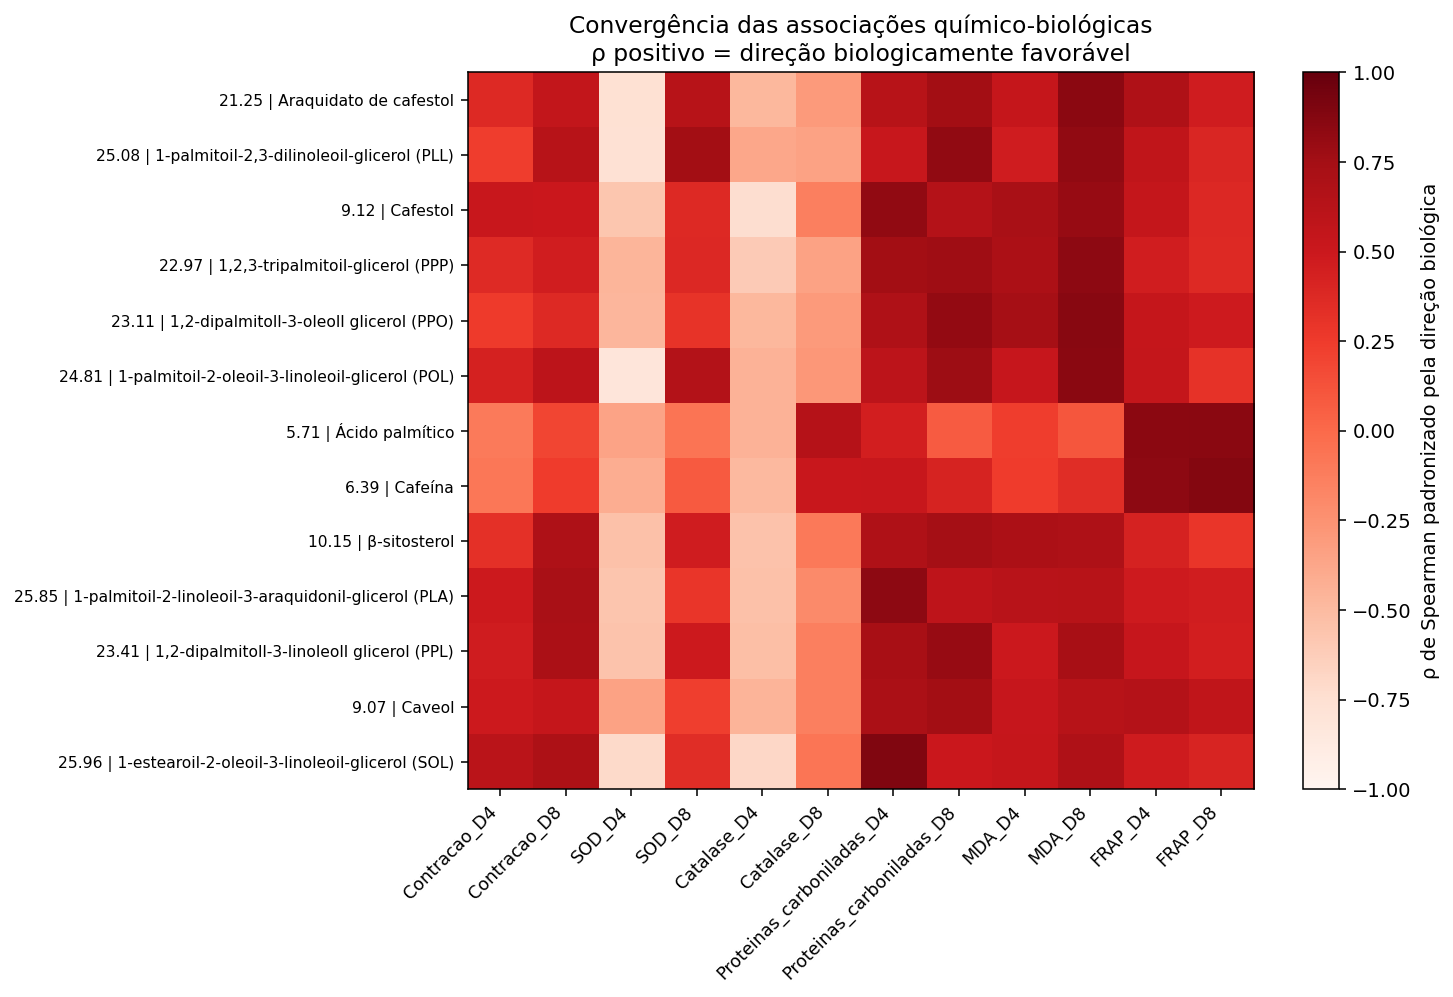


Arquivos salvos:
/kaggle/working/projeto001_resultados/projeto001_matriz_rho_direcao_favoravel.csv
/kaggle/working/projeto001_resultados/projeto001_heatmap_convergencia_quimico_biologica.png


In [64]:
# ============================================================
# ETAPA 60 — HEATMAP DE CONVERGÊNCIA QUÍMICO-BIOLÓGICA
# Usa exclusivamente os resultados calculados na ETAPA 59
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display


# ------------------------------------------------------------
# 0. Verificar se a ETAPA 59 foi executada
# ------------------------------------------------------------

if "df_resultados_principais" not in globals():
    raise RuntimeError(
        "df_resultados_principais não existe. "
        "Execute primeiro a ETAPA 59."
    )

if "VARIAVEIS_BIOLOGICAS" not in globals():
    raise RuntimeError(
        "VARIAVEIS_BIOLOGICAS não existe. "
        "Execute primeiro a ETAPA 59."
    )


# Pasta de saída
PASTA_PROJETO = Path(
    "/kaggle/working/projeto001_resultados"
)

PASTA_PROJETO.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. Direção biologicamente favorável
# ------------------------------------------------------------

SINAL_BIOLOGICO = {
    "Contracao_D4": 1,
    "Contracao_D8": 1,
    "SOD_D4": 1,
    "SOD_D8": 1,
    "Catalase_D4": 1,
    "Catalase_D8": 1,
    "Proteinas_carboniladas_D4": -1,
    "Proteinas_carboniladas_D8": -1,
    "MDA_D4": -1,
    "MDA_D8": -1,
    "FRAP_D4": 1,
    "FRAP_D8": 1
}


# ------------------------------------------------------------
# 2. Copiar as 444 associações da ETAPA 59
# ------------------------------------------------------------

df_convergencia = df_resultados_principais.copy()


df_convergencia["Sinal_biologico"] = (
    df_convergencia["Variavel_biologica"]
    .map(SINAL_BIOLOGICO)
)


if df_convergencia["Sinal_biologico"].isna().any():

    faltantes = (
        df_convergencia.loc[
            df_convergencia["Sinal_biologico"].isna(),
            "Variavel_biologica"
        ]
        .unique()
    )

    raise ValueError(
        f"Variáveis sem direção definida: {faltantes}"
    )


# ------------------------------------------------------------
# 3. Padronizar apenas a direção de rho
#
# NÃO altera a magnitude da correlação.
#
# Exemplo:
# MDA rho = -0,80  -> +0,80
# FRAP rho = +0,80 -> +0,80
# ------------------------------------------------------------

df_convergencia["Rho_direcao_favoravel"] = (
    df_convergencia["Rho_Spearman"]
    *
    df_convergencia["Sinal_biologico"]
)


# ------------------------------------------------------------
# 4. Identificar associações favoráveis após FDR
# ------------------------------------------------------------

df_convergencia["FDR_favoravel"] = (
    df_convergencia[
        "Significativo_FDR_por_desfecho_5_percent"
    ].astype(bool)
    &
    (
        df_convergencia[
            "Rho_direcao_favoravel"
        ] > 0
    )
)


df_convergencia["p_bruto_favoravel"] = (
    (
        df_convergencia[
            "Valor_p_permutacao"
        ] < 0.05
    )
    &
    (
        df_convergencia[
            "Rho_direcao_favoravel"
        ] > 0
    )
)


# ------------------------------------------------------------
# 5. Resumo por composto
# ------------------------------------------------------------

resumo = (
    df_convergencia
    .groupby(
        "Composto",
        as_index=False
    )
    .agg(

        Numero_FDR_favoraveis=(
            "FDR_favoravel",
            "sum"
        ),

        Numero_p_bruto_favoraveis=(
            "p_bruto_favoravel",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 6. Adicionar rho da contração no dia 8
# ------------------------------------------------------------

rho_d8 = (
    df_convergencia.loc[
        df_convergencia[
            "Variavel_biologica"
        ] == "Contracao_D8",
        [
            "Composto",
            "Rho_Spearman"
        ]
    ]
    .rename(
        columns={
            "Rho_Spearman":
            "Rho_Contracao_D8"
        }
    )
)


resumo = resumo.merge(
    rho_d8,
    on="Composto",
    how="left",
    validate="one_to_one"
)


# ------------------------------------------------------------
# 7. Selecionar compostos com pelo menos uma
# associação favorável após FDR por desfecho
# ------------------------------------------------------------

priorizados = (
    resumo.loc[
        resumo[
            "Numero_FDR_favoraveis"
        ] > 0
    ]
    .sort_values(
        [
            "Numero_FDR_favoraveis",
            "Numero_p_bruto_favoraveis",
            "Rho_Contracao_D8"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


compostos_grafico = (
    priorizados[
        "Composto"
    ]
    .tolist()
)


print(
    "Número de compostos selecionados:",
    len(compostos_grafico)
)

display(priorizados)


# ------------------------------------------------------------
# 8. Construir matriz compostos × respostas biológicas
# ------------------------------------------------------------

matriz_grafico = (
    df_convergencia
    .loc[
        df_convergencia[
            "Composto"
        ].isin(
            compostos_grafico
        )
    ]
    .pivot(
        index="Composto",
        columns="Variavel_biologica",
        values="Rho_direcao_favoravel"
    )
    .reindex(
        index=compostos_grafico,
        columns=VARIAVEIS_BIOLOGICAS
    )
)


print(
    "\nDimensão da matriz:",
    matriz_grafico.shape
)


display(
    matriz_grafico.round(3)
)


# ------------------------------------------------------------
# 9. Salvar a matriz
# ------------------------------------------------------------

ARQUIVO_MATRIZ = (
    PASTA_PROJETO
    /
    "projeto001_matriz_rho_direcao_favoravel.csv"
)


matriz_grafico.to_csv(
    ARQUIVO_MATRIZ,
    sep=";",
    decimal=",",
    encoding="utf-8-sig"
)


# ------------------------------------------------------------
# 10. Gerar o heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 8)
)


imagem = ax.imshow(
    matriz_grafico.to_numpy(
        dtype=float
    ),
    aspect="auto",

    # escala fixa das correlações
    vmin=-1,
    vmax=1,

    # tonalidade vermelha
    cmap="Reds"
)


# eixo X

ax.set_xticks(
    np.arange(
        len(
            VARIAVEIS_BIOLOGICAS
        )
    )
)

ax.set_xticklabels(
    VARIAVEIS_BIOLOGICAS,
    rotation=45,
    ha="right",
    fontsize=9
)


# eixo Y

ax.set_yticks(
    np.arange(
        len(
            compostos_grafico
        )
    )
)

ax.set_yticklabels(
    compostos_grafico,
    fontsize=8
)


# título

ax.set_title(
    "Convergência das associações químico-biológicas\n"
    "ρ positivo = direção biologicamente favorável",
    fontsize=12
)


# barra lateral

barra = fig.colorbar(
    imagem,
    ax=ax
)

barra.set_label(
    "ρ de Spearman padronizado pela direção biológica"
)


# ajuste de margens

fig.subplots_adjust(
    left=0.38,
    right=0.92,
    bottom=0.24,
    top=0.88
)


# ------------------------------------------------------------
# 11. Salvar a figura
# ------------------------------------------------------------

ARQUIVO_HEATMAP = (
    PASTA_PROJETO
    /
    "projeto001_heatmap_convergencia_quimico_biologica.png"
)


fig.savefig(
    ARQUIVO_HEATMAP,
    dpi=300,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# 12. MOSTRAR NO NOTEBOOK
# ------------------------------------------------------------

plt.show()


print("\nArquivos salvos:")
print(ARQUIVO_MATRIZ)
print(ARQUIVO_HEATMAP)

## 61 - Script em Python para PLS-R e VIP Scores

=== DESEMPENHO DO MODELO PLS-R (Componentes=2) ===
R² de Validação Cruzada (Q²): -0.366
RMSEP (Erro Médio de Predição): 1.280

=== BIOMARCADORES CHAVE (VIP >= 1.0) ===
                                               Composto  VIP_Score  Coeficiente_Beta
                                 5.71 | Ácido palmítico   2.187570          0.229714
                                         6.39 | Cafeína   2.014155          0.208657
                                   9.94 | Estigmasterol   1.251761          0.112978
25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL)   1.232860          0.114693
                             19.46 | Oleato de cafestol   1.220877          0.128764
                            17.22 | Palmitato de caveol   1.198057          0.112689
                                        8.31 | Cafestal   1.119539         -0.117310
24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL)   1.048557         -0.025860


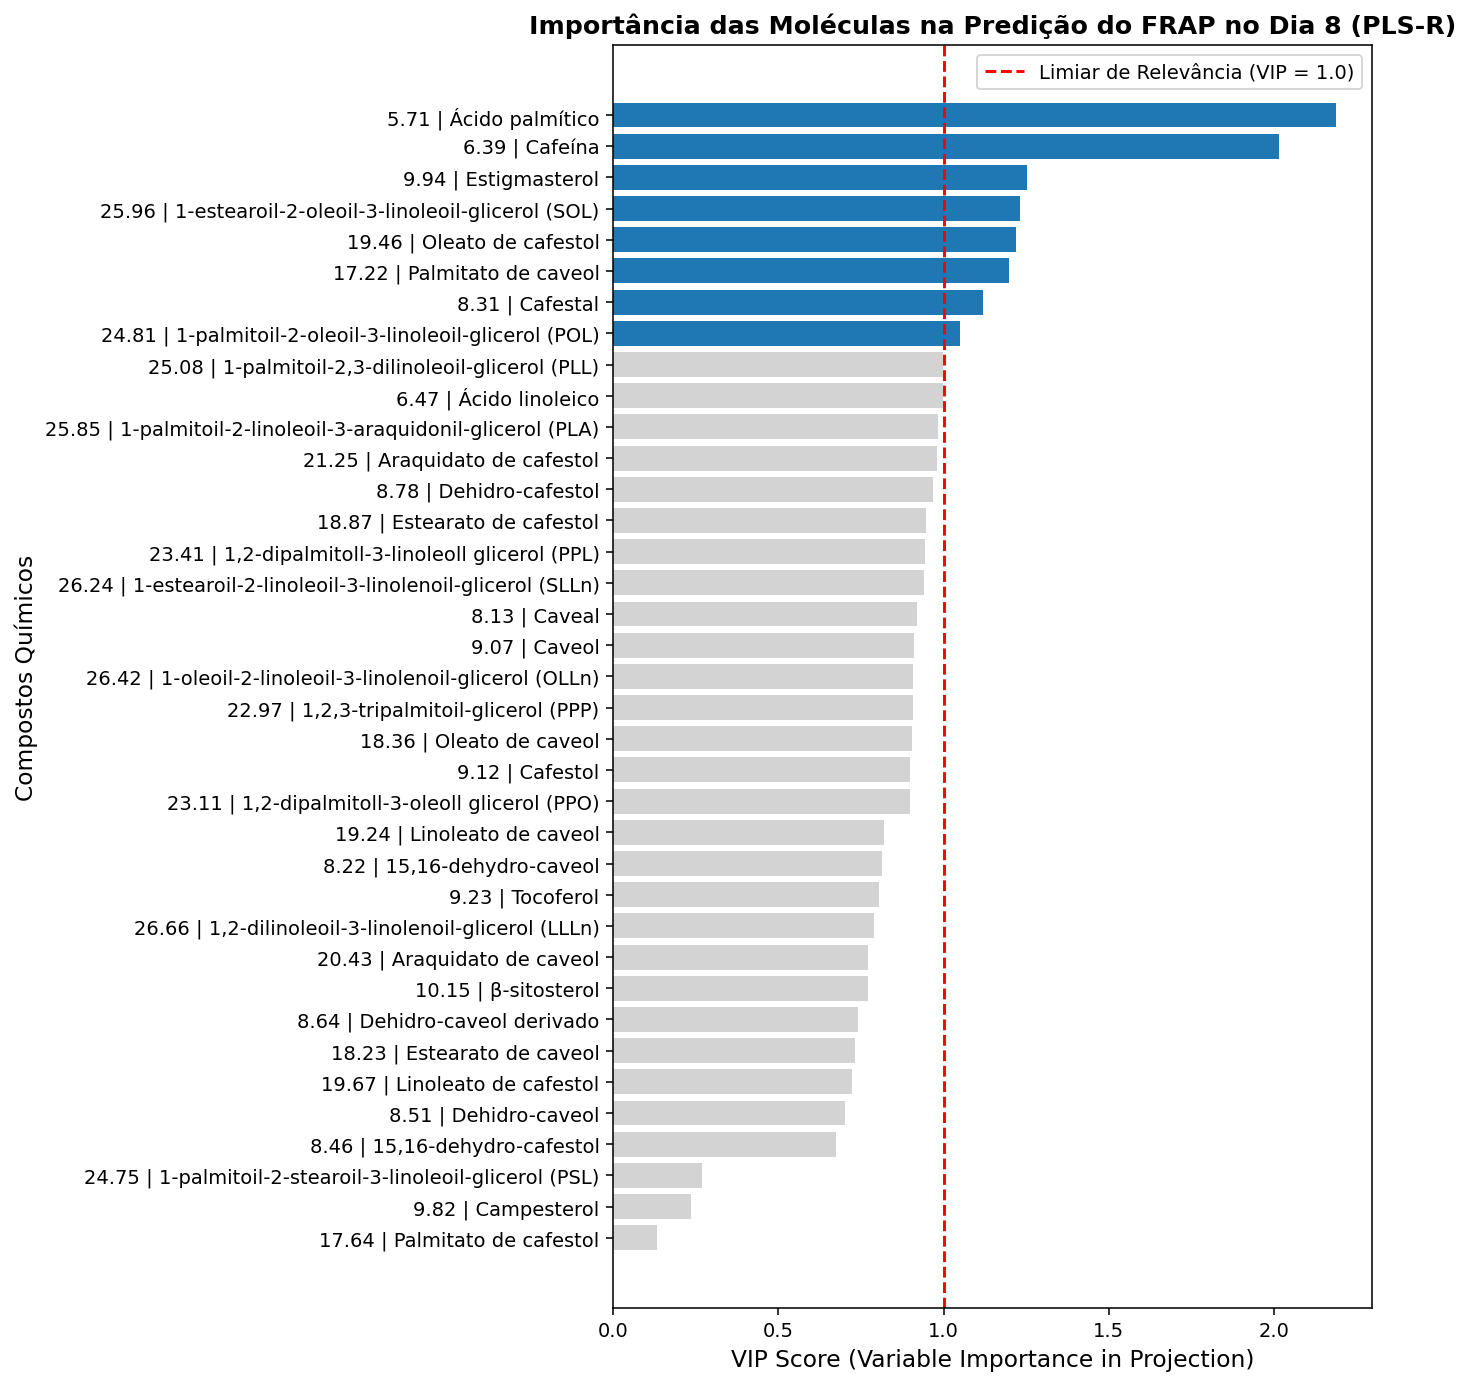

In [65]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. CARREGAR A MATRIZ INTEGRADA DO PROJETO (37 QUÍMICOS + 12 BIOLÓGICOS)
# ==============================================================================
arquivo_matriz = Path(
    "/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv"
)

# Caso o arquivo já esteja na memória como df_matriz_integrada, usamos ele:
if "df_matriz_integrada" in globals():
  df_integrada = df_matriz_integrada.copy()
else:
  df_integrada = pd.read_csv(arquivo_matriz, sep=";", decimal=",")

# Definir as 12 colunas biológicas
colunas_biologicas = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8",
]

# Identificar automaticamente as 37 colunas químicas
colunas_quimicas = [
    c
    for c in df_integrada.columns
    if c not in colunas_biologicas and c != "Perfil"
]

# Matriz X (37 compostos químicos) e Vetor y (ex: FRAP no Dia 8)
X = df_integrada[colunas_quimicas].set_index(df_integrada["Perfil"])
y = df_integrada["FRAP_D8"]  # Você pode trocar para 'MDA_D8', 'Contracao_D8', etc.

# Padronização das variáveis (Autoscaling / Z-score)
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X), columns=X.columns, index=X.index
)


# ==============================================================================
# 2. FUNÇÃO PARA CÁLCULO DOS VIP SCORES
# ==============================================================================
def calculate_vip(model):
  t = model.x_scores_
  w = model.x_weights_
  q = model.y_loadings_
  p, n_comps = w.shape
  vip = np.zeros(p)
  s = np.diag(t.T @ t @ q.T @ q)
  total_s = np.sum(s)
  for i in range(p):
    weight = np.array(
        [(w[i, k] / np.linalg.norm(w[:, k])) ** 2 for k in range(n_comps)]
    )
    vip[i] = np.sqrt(p * np.sum(s * weight) / total_s)
  return vip


# ==============================================================================
# 3. AJUSTE DO MODELO PLS-R E VALIDAÇÃO CRUZADA (LOO-CV)
# ==============================================================================
n_components = 2  # 2 componentes latentes
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y)

# Leave-One-Out Cross-Validation (N=11)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  model_cv = PLSRegression(n_components=n_components)
  model_cv.fit(X_train, y_train)

  pred = model_cv.predict(X_test)
  y_true.append(y_test.values)
  y_pred.append(pred)

r2_cv = r2_score(y_true, y_pred)
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"=== DESEMPENHO DO MODELO PLS-R (Componentes={n_components}) ===")
print(f"R² de Validação Cruzada (Q²): {r2_cv:.3f}")
print(f"RMSEP (Erro Médio de Predição): {rmsep:.3f}\n")

# ==============================================================================
# 4. RANKING DOS VIP SCORES (BIOMARCADORES CHAVE)
# ==============================================================================
vips = calculate_vip(pls)

df_vips = pd.DataFrame({
    "Composto": X.columns,
    "VIP_Score": vips,
    "Coeficiente_Beta": pls.coef_.ravel(),
}).sort_values(by="VIP_Score", ascending=False)

print("=== BIOMARCADORES CHAVE (VIP >= 1.0) ===")
print(df_vips[df_vips["VIP_Score"] >= 1.0].to_string(index=False))

# ==============================================================================
# 5. GRÁFICO DOS VIP SCORES
# ==============================================================================
plt.figure(figsize=(10, 10))
colors = ["#1f77b4" if v >= 1.0 else "#d3d3d3" for v in df_vips["VIP_Score"]]

plt.barh(df_vips["Composto"], df_vips["VIP_Score"], color=colors)
plt.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Limiar de Relevância (VIP = 1.0)",
)
plt.xlabel("VIP Score (Variable Importance in Projection)", fontsize=12)
plt.ylabel("Compostos Químicos", fontsize=12)
plt.title(
    "Importância das Moléculas na Predição do FRAP no Dia 8 (PLS-R)",
    fontsize=13,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

## 62 - === DESEMPENHO DO MODELO PLS-R (MDA_D8 | Componentes=2) ===

=== DESEMPENHO DO MODELO PLS-R (MDA_D8 | Componentes=2) ===
R² de Validação Cruzada (Q²): -0.242
RMSEP (Erro Médio de Predição): 21.023

=== BIOMARCADORES CHAVE (VIP >= 1.0) ===
                                               Composto  VIP_Score  Coeficiente_Beta
                                     9.82 | Campesterol   2.095753          4.336032
                           20.43 | Araquidato de caveol   1.827435          3.406022
                          17.64 | Palmitato de cafestol   1.333705          2.886764
                         21.25 | Araquidato de cafestol   1.313307         -2.413725
                                 6.47 | Ácido linoleico   1.268279         -2.619412
24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL)   1.232849         -2.173458
        23.11 | 1,2-dipalmitoll-3-oleoll glicerol (PPO)   1.191813         -2.085944
                            18.23 | Estearato de caveol   1.144294          1.454131
     25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)  

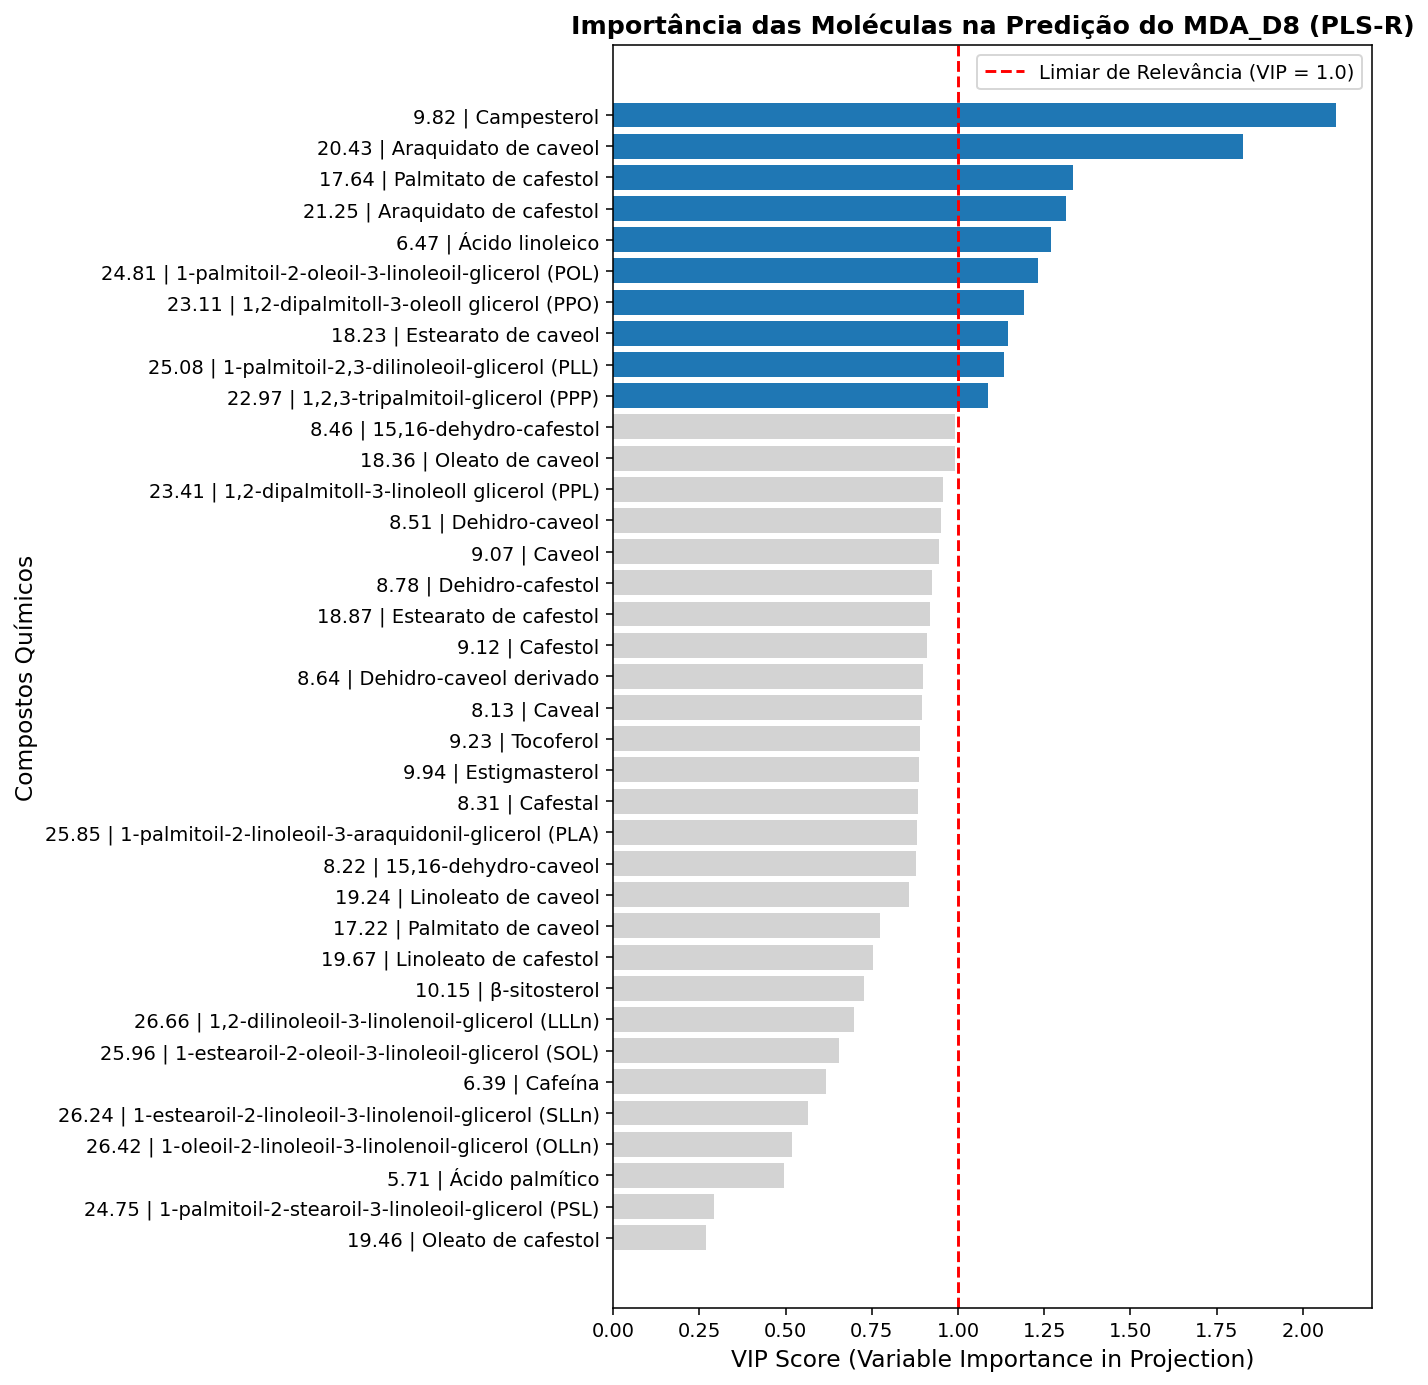

In [66]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler


# ==============================================================================
# 1. FUNÇÃO PARA CÁLCULO DOS VIP SCORES
# ==============================================================================
def calculate_vip(model):
  """Calcula o VIP Score (Variable Importance in Projection) para PLSRegression."""
  t = model.x_scores_
  w = model.x_weights_
  q = model.y_loadings_
  p, n_comps = w.shape

  vip = np.zeros(p)
  s = np.diag(t.T @ t @ q.T @ q)
  total_s = np.sum(s)

  for i in range(p):
    weight = np.array(
        [(w[i, k] / np.linalg.norm(w[:, k])) ** 2 for k in range(n_comps)]
    )
    vip[i] = np.sqrt(p * np.sum(s * weight) / total_s)

  return vip


# ==============================================================================
# 2. CARREGAR A MATRIZ INTEGRADA DO PROJETO (37 QUÍMICOS + 12 BIOLÓGICOS)
# ==============================================================================
arquivo_matriz = Path(
    "/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv"
)

# Utilizar a matriz da memória ou carregar do arquivo CSV gerado nas etapas anteriores
if "df_matriz_integrada" in globals():
  df_integrada = df_matriz_integrada.copy()
elif arquivo_matriz.exists():
  df_integrada = pd.read_csv(arquivo_matriz, sep=";", decimal=",")
else:
  raise FileNotFoundError(
      f"A matriz integrada não foi localizada em: {arquivo_matriz}"
  )

# Definir as 12 colunas de desfechos biológicos
colunas_biologicas = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8",
]

# Identificar automaticamente as 37 variáveis químicas
colunas_quimicas = [
    c
    for c in df_integrada.columns
    if c not in colunas_biologicas and c != "Perfil"
]

# Matriz X (37 compostos químicos) e Vetor Y (Desfecho escolhido: MDA no Dia 8)
X = df_integrada[colunas_quimicas].set_index(df_integrada["Perfil"])

# ------------------------------------------------------------------------------
# DICA: Para testar outro desfecho, basta trocar 'MDA_D8' por 'FRAP_D8', 'Contracao_D8', etc.
# ------------------------------------------------------------------------------
DESFECHO_ALVO = "MDA_D8"
y = df_integrada[DESFECHO_ALVO]

# Padronização das variáveis químicas (Autoscaling / Z-score)
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X), columns=X.columns, index=X.index
)

# ==============================================================================
# 3. AJUSTE DO MODELO PLS-R E VALIDAÇÃO CRUZADA LEAVE-ONE-OUT (LOO-CV)
# ==============================================================================
n_components = 2  # 2 componentes latentes
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y)

# Validação Cruzada Leave-One-Out (N=11 perfis)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  model_cv = PLSRegression(n_components=n_components)
  model_cv.fit(X_train, y_train)

  pred = model_cv.predict(X_test)
  y_true.append(y_test.values)
  y_pred.append(pred)

r2_cv = r2_score(y_true, y_pred)
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))

print(
    f"=== DESEMPENHO DO MODELO PLS-R ({DESFECHO_ALVO} | Componentes={n_components}) ==="
)
print(f"R² de Validação Cruzada (Q²): {r2_cv:.3f}")
print(f"RMSEP (Erro Médio de Predição): {rmsep:.3f}\n")

# ==============================================================================
# 4. RANKING DOS VIP SCORES (BIOMARCADORES CHAVE)
# ==============================================================================
vips = calculate_vip(pls)

df_vips = pd.DataFrame({
    "Composto": X.columns,
    "VIP_Score": vips,
    "Coeficiente_Beta": pls.coef_.ravel(),
}).sort_values(by="VIP_Score", ascending=False)

print("=== BIOMARCADORES CHAVE (VIP >= 1.0) ===")
print(df_vips[df_vips["VIP_Score"] >= 1.0].to_string(index=False))

# ==============================================================================
# 5. GRÁFICO DOS VIP SCORES
# ==============================================================================
plt.figure(figsize=(10, 10))
colors = ["#1f77b4" if v >= 1.0 else "#d3d3d3" for v in df_vips["VIP_Score"]]

plt.barh(df_vips["Composto"], df_vips["VIP_Score"], color=colors)
plt.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Limiar de Relevância (VIP = 1.0)",
)
plt.xlabel("VIP Score (Variable Importance in Projection)", fontsize=12)
plt.ylabel("Compostos Químicos", fontsize=12)
plt.title(
    f"Importância das Moléculas na Predição do {DESFECHO_ALVO} (PLS-R)",
    fontsize=13,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

## 63


=== DESEMPENHO DO MODELO PLS-R (FRAP_D8 | Componentes=2) ===
R² de Validação Cruzada (Q²): -0.366
RMSEP (Erro Médio de Predição): 1.280

=== BIOMARCADORES CHAVE (VIP >= 1.0) ===
                                               Composto  VIP_Score  Coeficiente_Beta
                                 5.71 | Ácido palmítico   2.187570          0.229714
                                         6.39 | Cafeína   2.014155          0.208657
                                   9.94 | Estigmasterol   1.251761          0.112978
25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL)   1.232860          0.114693
                             19.46 | Oleato de cafestol   1.220877          0.128764
                            17.22 | Palmitato de caveol   1.198057          0.112689
                                        8.31 | Cafestal   1.119539         -0.117310
24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL)   1.048557         -0.025860


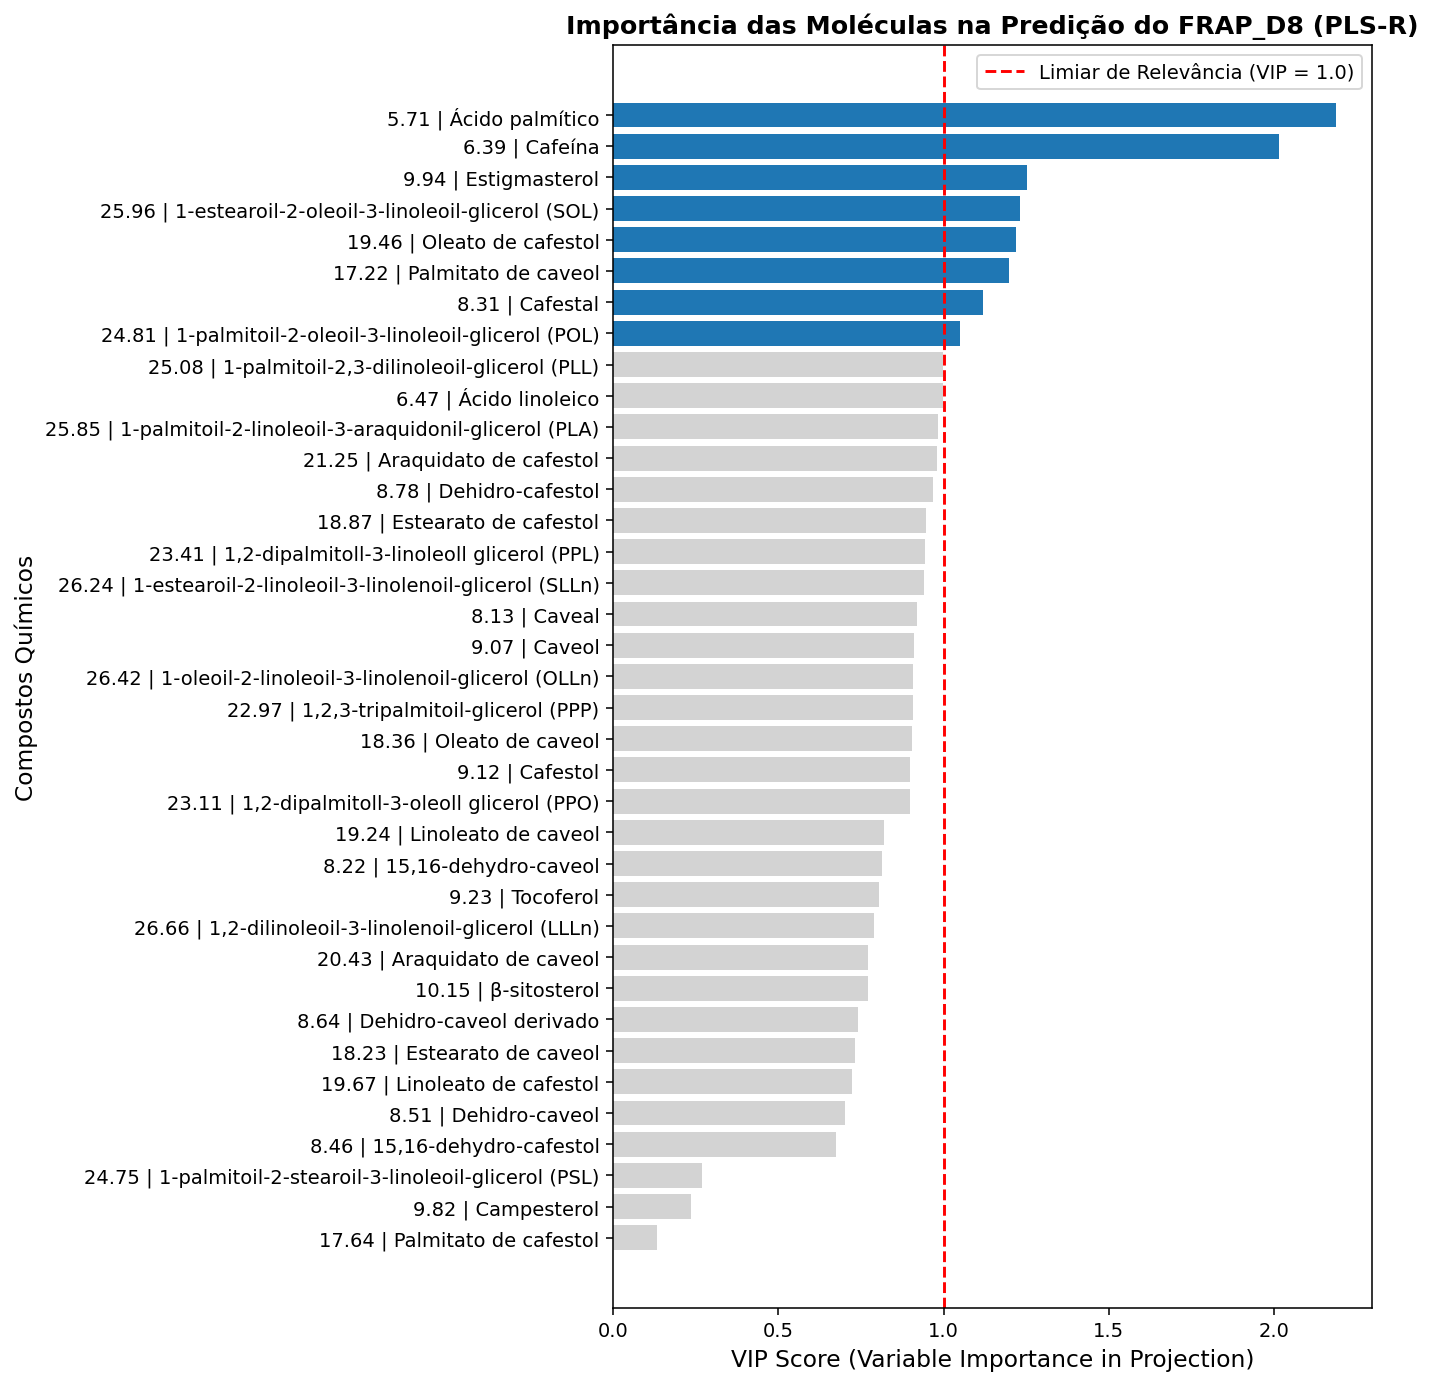

In [67]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler


# ==============================================================================
# 1. FUNÇÃO PARA CÁLCULO DOS VIP SCORES
# ==============================================================================
def calculate_vip(model):
  """Calcula o VIP Score (Variable Importance in Projection) para PLSRegression."""
  t = model.x_scores_
  w = model.x_weights_
  q = model.y_loadings_
  p, n_comps = w.shape

  vip = np.zeros(p)
  s = np.diag(t.T @ t @ q.T @ q)
  total_s = np.sum(s)

  for i in range(p):
    weight = np.array(
        [(w[i, k] / np.linalg.norm(w[:, k])) ** 2 for k in range(n_comps)]
    )
    vip[i] = np.sqrt(p * np.sum(s * weight) / total_s)

  return vip


# ==============================================================================
# 2. CARREGAR A MATRIZ INTEGRADA DO PROJETO (37 QUÍMICOS + 12 BIOLÓGICOS)
# ==============================================================================
arquivo_matriz = Path(
    "/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv"
)

# Utilizar a matriz da memória ou carregar do arquivo CSV gerado nas etapas anteriores
if "df_matriz_integrada" in globals():
  df_integrada = df_matriz_integrada.copy()
elif arquivo_matriz.exists():
  df_integrada = pd.read_csv(arquivo_matriz, sep=";", decimal=",")
else:
  raise FileNotFoundError(
      f"A matriz integrada não foi localizada em: {arquivo_matriz}"
  )

# Definir as 12 colunas de desfechos biológicos
colunas_biologicas = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8",
]

# Identificar automaticamente as 37 variáveis químicas
colunas_quimicas = [
    c
    for c in df_integrada.columns
    if c not in colunas_biologicas and c != "Perfil"
]

# Matriz X (37 compostos químicos) e Vetor Y (Desfecho escolhido: MDA no Dia 8)
X = df_integrada[colunas_quimicas].set_index(df_integrada["Perfil"])

# ------------------------------------------------------------------------------
# DICA: Para testar outro desfecho, basta trocar 'MDA_D8' por 'FRAP_D8', 'Contracao_D8', etc.
# ------------------------------------------------------------------------------
DESFECHO_ALVO = "FRAP_D8"
y = df_integrada[DESFECHO_ALVO]

# Padronização das variáveis químicas (Autoscaling / Z-score)
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X), columns=X.columns, index=X.index
)

# ==============================================================================
# 3. AJUSTE DO MODELO PLS-R E VALIDAÇÃO CRUZADA LEAVE-ONE-OUT (LOO-CV)
# ==============================================================================
n_components = 2  # 2 componentes latentes
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y)

# Validação Cruzada Leave-One-Out (N=11 perfis)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  model_cv = PLSRegression(n_components=n_components)
  model_cv.fit(X_train, y_train)

  pred = model_cv.predict(X_test)
  y_true.append(y_test.values)
  y_pred.append(pred)

r2_cv = r2_score(y_true, y_pred)
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))

print(
    f"=== DESEMPENHO DO MODELO PLS-R ({DESFECHO_ALVO} | Componentes={n_components}) ==="
)
print(f"R² de Validação Cruzada (Q²): {r2_cv:.3f}")
print(f"RMSEP (Erro Médio de Predição): {rmsep:.3f}\n")

# ==============================================================================
# 4. RANKING DOS VIP SCORES (BIOMARCADORES CHAVE)
# ==============================================================================
vips = calculate_vip(pls)

df_vips = pd.DataFrame({
    "Composto": X.columns,
    "VIP_Score": vips,
    "Coeficiente_Beta": pls.coef_.ravel(),
}).sort_values(by="VIP_Score", ascending=False)

print("=== BIOMARCADORES CHAVE (VIP >= 1.0) ===")
print(df_vips[df_vips["VIP_Score"] >= 1.0].to_string(index=False))

# ==============================================================================
# 5. GRÁFICO DOS VIP SCORES
# ==============================================================================
plt.figure(figsize=(10, 10))
colors = ["#1f77b4" if v >= 1.0 else "#d3d3d3" for v in df_vips["VIP_Score"]]

plt.barh(df_vips["Composto"], df_vips["VIP_Score"], color=colors)
plt.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Limiar de Relevância (VIP = 1.0)",
)
plt.xlabel("VIP Score (Variable Importance in Projection)", fontsize=12)
plt.ylabel("Compostos Químicos", fontsize=12)
plt.title(
    f"Importância das Moléculas na Predição do {DESFECHO_ALVO} (PLS-R)",
    fontsize=13,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

## 64 Contração D8

=== DESEMPENHO DO MODELO PLS-R (Contracao_D8 | Componentes=2) ===
R² de Validação Cruzada (Q²): -0.008
RMSEP (Erro Médio de Predição): 11.992

=== BIOMARCADORES CHAVE (VIP >= 1.0) ===
                                                    Composto  VIP_Score  Coeficiente_Beta
                                        10.15 | β-sitosterol   1.527500          1.305170
        26.66 | 1,2-dilinoleoil-3-linolenoil-glicerol (LLLn)   1.506146          1.302339
          25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)   1.405370          1.001107
     24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (POL)   1.312302          0.888898
                                        9.94 | Estigmasterol   1.305563          1.012281
          23.41 | 1,2-dipalmitoll-3-linoleoll glicerol (PPL)   1.246257          0.805016
26.24 | 1-estearoil-2-linoleoil-3-linolenoil-glicerol (SLLn)   1.244853          1.037444
                                          9.82 | Campesterol   1.140527          1.092872
25.85 

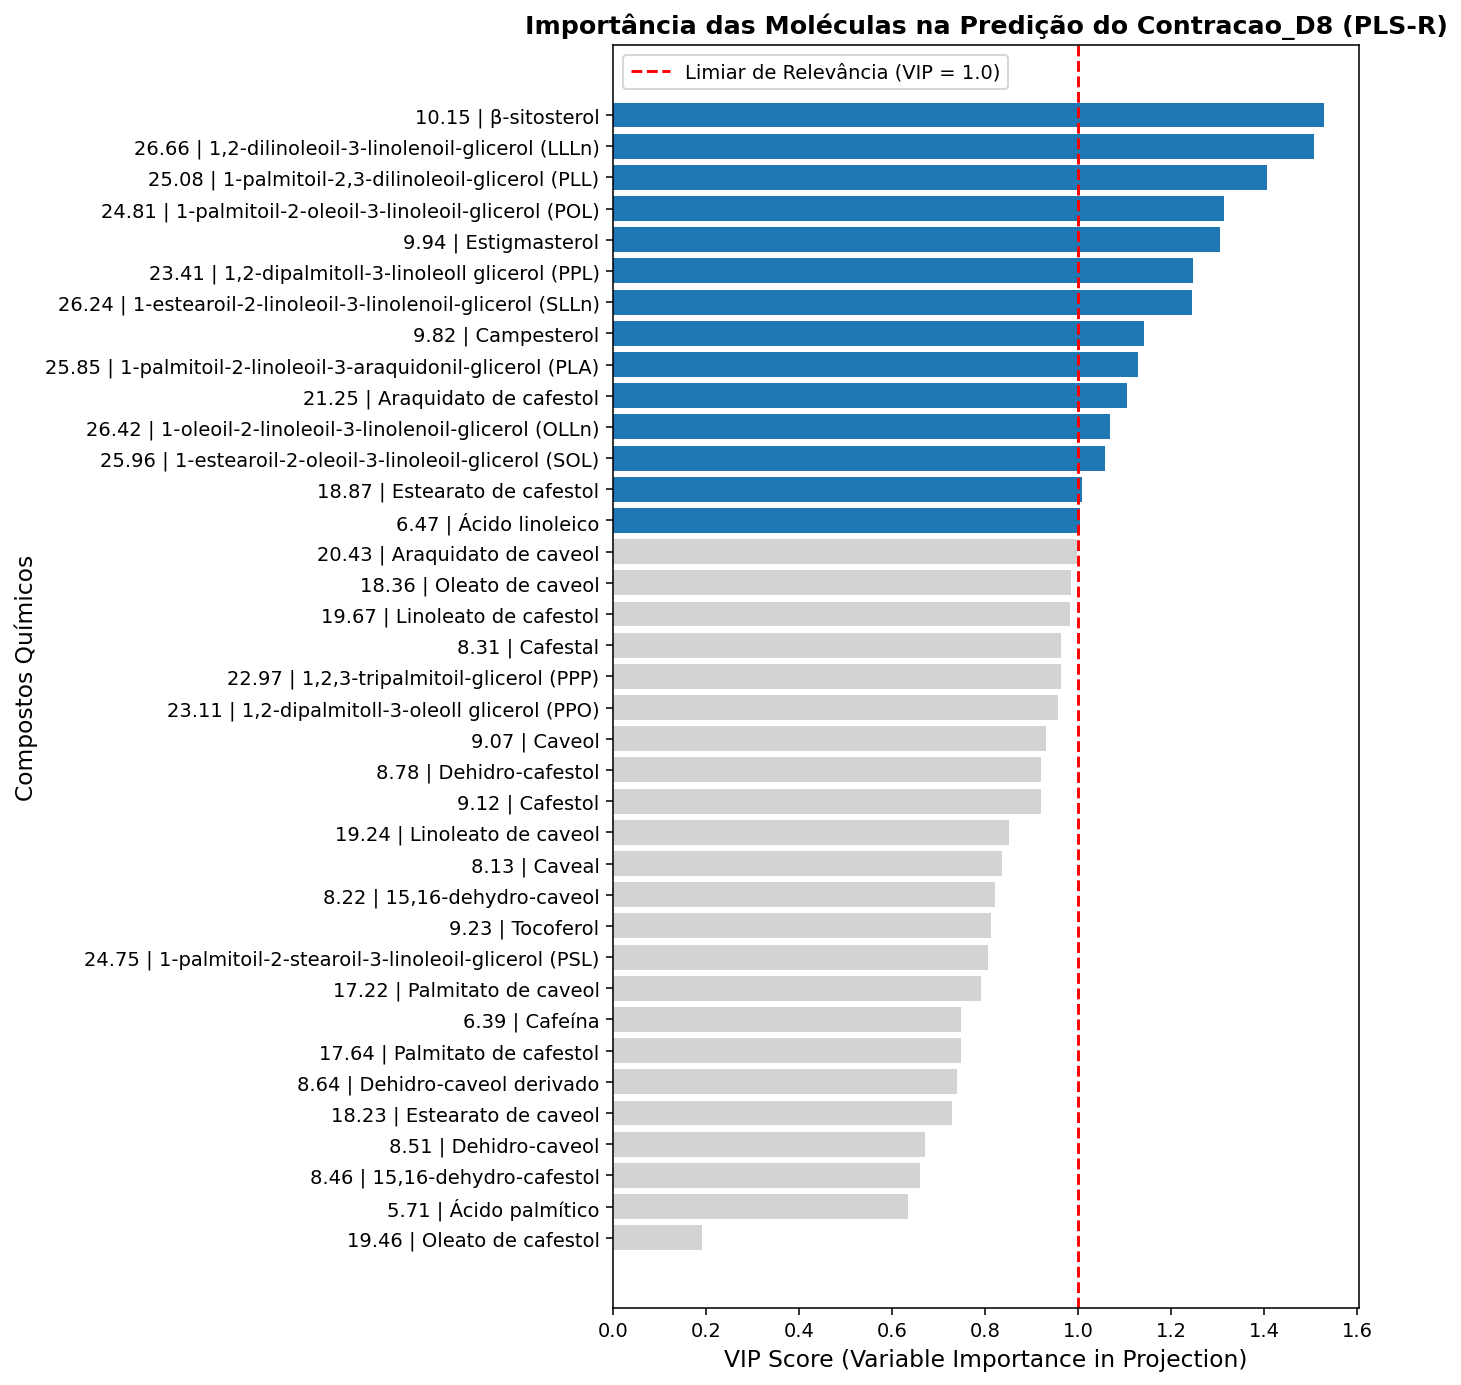

In [68]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler


# ==============================================================================
# 1. FUNÇÃO PARA CÁLCULO DOS VIP SCORES
# ==============================================================================
def calculate_vip(model):
  """Calcula o VIP Score (Variable Importance in Projection) para PLSRegression."""
  t = model.x_scores_
  w = model.x_weights_
  q = model.y_loadings_
  p, n_comps = w.shape

  vip = np.zeros(p)
  s = np.diag(t.T @ t @ q.T @ q)
  total_s = np.sum(s)

  for i in range(p):
    weight = np.array(
        [(w[i, k] / np.linalg.norm(w[:, k])) ** 2 for k in range(n_comps)]
    )
    vip[i] = np.sqrt(p * np.sum(s * weight) / total_s)

  return vip


# ==============================================================================
# 2. CARREGAR A MATRIZ INTEGRADA DO PROJETO (37 QUÍMICOS + 12 BIOLÓGICOS)
# ==============================================================================
arquivo_matriz = Path(
    "/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv"
)

# Utilizar a matriz da memória ou carregar do arquivo CSV gerado nas etapas anteriores
if "df_matriz_integrada" in globals():
  df_integrada = df_matriz_integrada.copy()
elif arquivo_matriz.exists():
  df_integrada = pd.read_csv(arquivo_matriz, sep=";", decimal=",")
else:
  raise FileNotFoundError(
      f"A matriz integrada não foi localizada em: {arquivo_matriz}"
  )

# Definir as 12 colunas de desfechos biológicos
colunas_biologicas = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8",
]

# Identificar automaticamente as 37 variáveis químicas
colunas_quimicas = [
    c
    for c in df_integrada.columns
    if c not in colunas_biologicas and c != "Perfil"
]

# Matriz X (37 compostos químicos) e Vetor Y (Desfecho escolhido: MDA no Dia 8)
X = df_integrada[colunas_quimicas].set_index(df_integrada["Perfil"])

# ------------------------------------------------------------------------------
# DICA: Para testar outro desfecho, basta trocar 'MDA_D8' por 'FRAP_D8', 'Contracao_D8', etc.
# ------------------------------------------------------------------------------
DESFECHO_ALVO = "Contracao_D8"
y = df_integrada[DESFECHO_ALVO]

# Padronização das variáveis químicas (Autoscaling / Z-score)
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X), columns=X.columns, index=X.index
)

# ==============================================================================
# 3. AJUSTE DO MODELO PLS-R E VALIDAÇÃO CRUZADA LEAVE-ONE-OUT (LOO-CV)
# ==============================================================================
n_components = 2  # 2 componentes latentes
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y)

# Validação Cruzada Leave-One-Out (N=11 perfis)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  model_cv = PLSRegression(n_components=n_components)
  model_cv.fit(X_train, y_train)

  pred = model_cv.predict(X_test)
  y_true.append(y_test.values)
  y_pred.append(pred)

r2_cv = r2_score(y_true, y_pred)
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))

print(
    f"=== DESEMPENHO DO MODELO PLS-R ({DESFECHO_ALVO} | Componentes={n_components}) ==="
)
print(f"R² de Validação Cruzada (Q²): {r2_cv:.3f}")
print(f"RMSEP (Erro Médio de Predição): {rmsep:.3f}\n")

# ==============================================================================
# 4. RANKING DOS VIP SCORES (BIOMARCADORES CHAVE)
# ==============================================================================
vips = calculate_vip(pls)

df_vips = pd.DataFrame({
    "Composto": X.columns,
    "VIP_Score": vips,
    "Coeficiente_Beta": pls.coef_.ravel(),
}).sort_values(by="VIP_Score", ascending=False)

print("=== BIOMARCADORES CHAVE (VIP >= 1.0) ===")
print(df_vips[df_vips["VIP_Score"] >= 1.0].to_string(index=False))

# ==============================================================================
# 5. GRÁFICO DOS VIP SCORES
# ==============================================================================
plt.figure(figsize=(10, 10))
colors = ["#1f77b4" if v >= 1.0 else "#d3d3d3" for v in df_vips["VIP_Score"]]

plt.barh(df_vips["Composto"], df_vips["VIP_Score"], color=colors)
plt.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Limiar de Relevância (VIP = 1.0)",
)
plt.xlabel("VIP Score (Variable Importance in Projection)", fontsize=12)
plt.ylabel("Compostos Químicos", fontsize=12)
plt.title(
    f"Importância das Moléculas na Predição do {DESFECHO_ALVO} (PLS-R)",
    fontsize=13,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

## 65 Catalase


=== DESEMPENHO DO MODELO PLS-R (Catalase_D8 | Componentes=2) ===
R² de Validação Cruzada (Q²): -1.479
RMSEP (Erro Médio de Predição): 213.634

=== BIOMARCADORES CHAVE (VIP >= 1.0) ===
                                               Composto  VIP_Score  Coeficiente_Beta
                                 5.71 | Ácido palmítico   3.090320         50.243197
                                         6.39 | Cafeína   2.494256         40.589158
                                        8.31 | Cafestal   1.983120        -32.692368
                         21.25 | Araquidato de cafestol   1.402206        -21.441976
     25.08 | 1-palmitoil-2,3-dilinoleoil-glicerol (PLL)   1.298201        -19.825174
                           20.43 | Araquidato de caveol   1.278072        -20.619234
25.96 | 1-estearoil-2-oleoil-3-linoleoil-glicerol (SOL)   1.259948         20.167873
                                     9.82 | Campesterol   1.179989         18.028683
24.81 | 1-palmitoil-2-oleoil-3-linoleoil-glicerol (

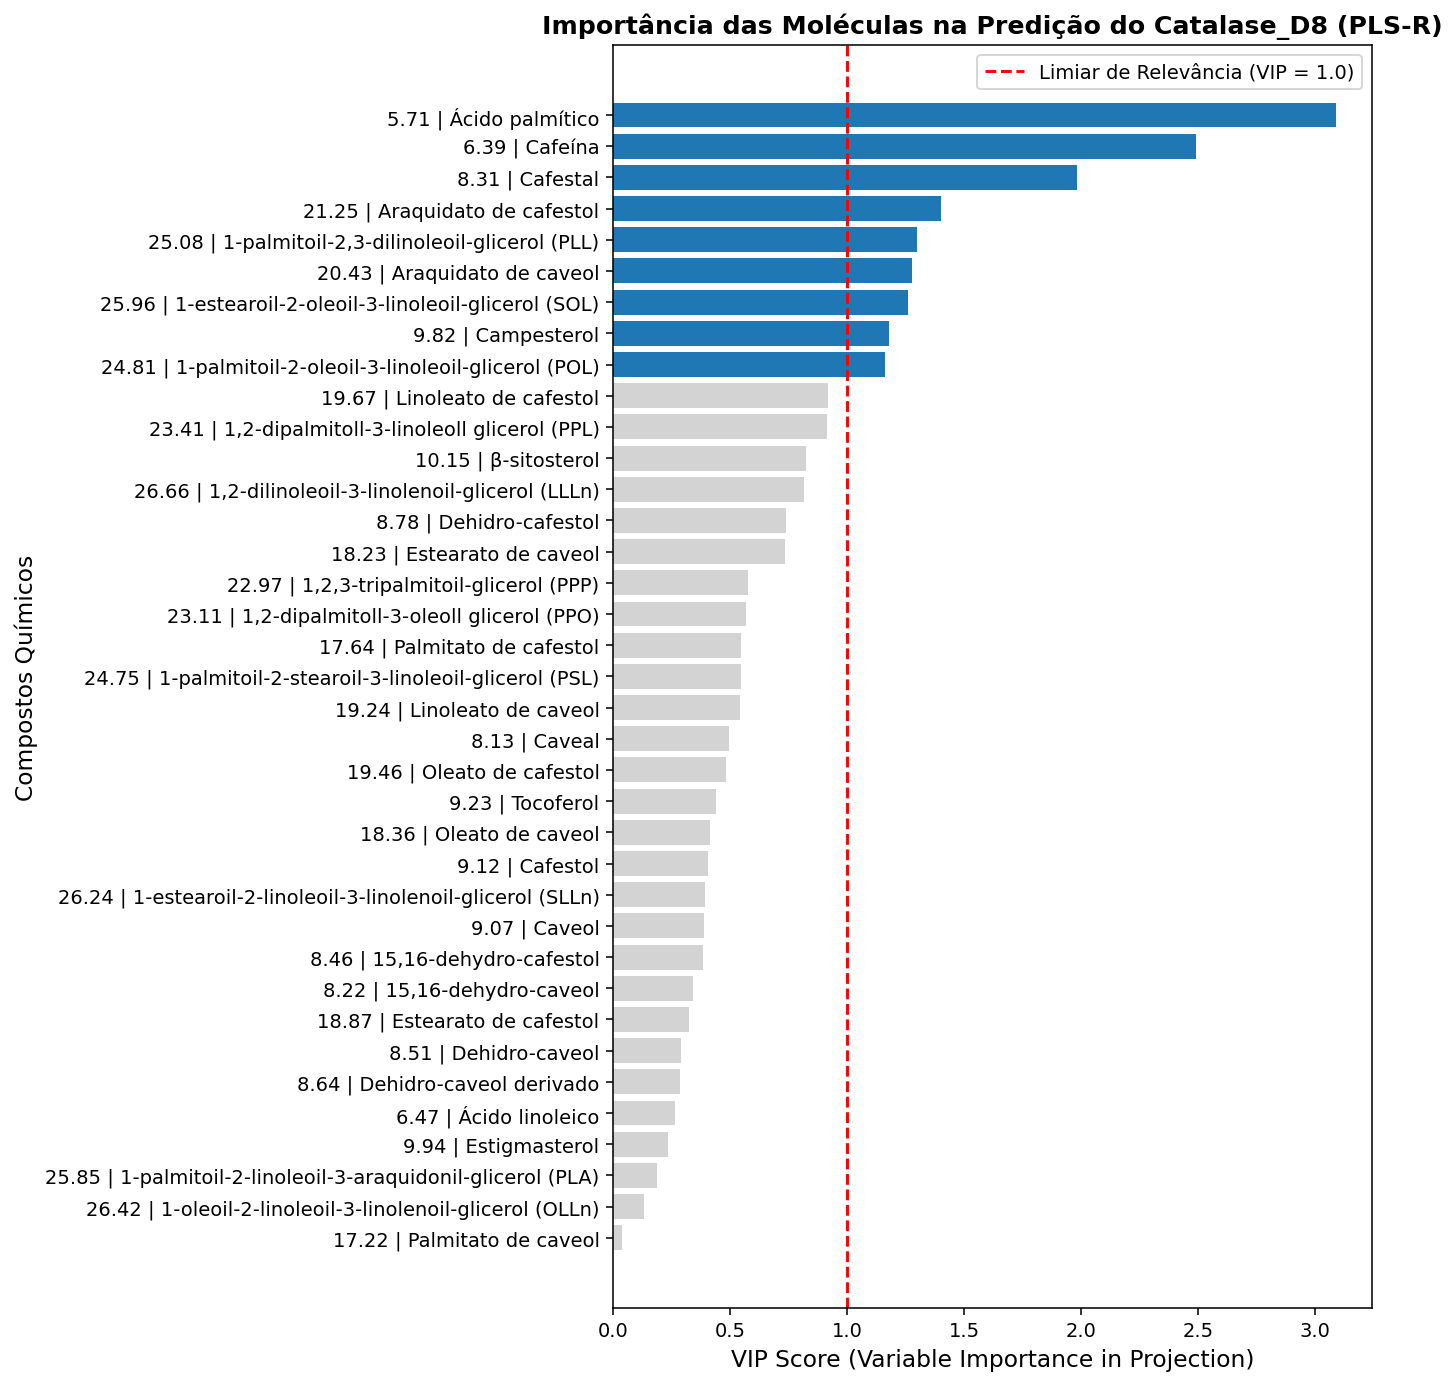

In [69]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler


# ==============================================================================
# 1. FUNÇÃO PARA CÁLCULO DOS VIP SCORES
# ==============================================================================
def calculate_vip(model):
  """Calcula o VIP Score (Variable Importance in Projection) para PLSRegression."""
  t = model.x_scores_
  w = model.x_weights_
  q = model.y_loadings_
  p, n_comps = w.shape

  vip = np.zeros(p)
  s = np.diag(t.T @ t @ q.T @ q)
  total_s = np.sum(s)

  for i in range(p):
    weight = np.array(
        [(w[i, k] / np.linalg.norm(w[:, k])) ** 2 for k in range(n_comps)]
    )
    vip[i] = np.sqrt(p * np.sum(s * weight) / total_s)

  return vip


# ==============================================================================
# 2. CARREGAR A MATRIZ INTEGRADA DO PROJETO (37 QUÍMICOS + 12 BIOLÓGICOS)
# ==============================================================================
arquivo_matriz = Path(
    "/kaggle/working/projeto001_resultados/projeto001_matriz_integrada_quimico_biologica.csv"
)

# Utilizar a matriz da memória ou carregar do arquivo CSV gerado nas etapas anteriores
if "df_matriz_integrada" in globals():
  df_integrada = df_matriz_integrada.copy()
elif arquivo_matriz.exists():
  df_integrada = pd.read_csv(arquivo_matriz, sep=";", decimal=",")
else:
  raise FileNotFoundError(
      f"A matriz integrada não foi localizada em: {arquivo_matriz}"
  )

# Definir as 12 colunas de desfechos biológicos
colunas_biologicas = [
    "Contracao_D4",
    "Contracao_D8",
    "SOD_D4",
    "SOD_D8",
    "Catalase_D4",
    "Catalase_D8",
    "Proteinas_carboniladas_D4",
    "Proteinas_carboniladas_D8",
    "MDA_D4",
    "MDA_D8",
    "FRAP_D4",
    "FRAP_D8",
]

# Identificar automaticamente as 37 variáveis químicas
colunas_quimicas = [
    c
    for c in df_integrada.columns
    if c not in colunas_biologicas and c != "Perfil"
]

# Matriz X (37 compostos químicos) e Vetor Y (Desfecho escolhido: MDA no Dia 8)
X = df_integrada[colunas_quimicas].set_index(df_integrada["Perfil"])

# ------------------------------------------------------------------------------
# DICA: Para testar outro desfecho, basta trocar 'MDA_D8' por 'FRAP_D8', 'Contracao_D8', etc.
# ------------------------------------------------------------------------------
DESFECHO_ALVO = "Catalase_D8"
y = df_integrada[DESFECHO_ALVO]

# Padronização das variáveis químicas (Autoscaling / Z-score)
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_X.fit_transform(X), columns=X.columns, index=X.index
)

# ==============================================================================
# 3. AJUSTE DO MODELO PLS-R E VALIDAÇÃO CRUZADA LEAVE-ONE-OUT (LOO-CV)
# ==============================================================================
n_components = 2  # 2 componentes latentes
pls = PLSRegression(n_components=n_components)
pls.fit(X_scaled, y)

# Validação Cruzada Leave-One-Out (N=11 perfis)
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X_scaled):
  X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

  model_cv = PLSRegression(n_components=n_components)
  model_cv.fit(X_train, y_train)

  pred = model_cv.predict(X_test)
  y_true.append(y_test.values)
  y_pred.append(pred)

r2_cv = r2_score(y_true, y_pred)
rmsep = np.sqrt(mean_squared_error(y_true, y_pred))

print(
    f"=== DESEMPENHO DO MODELO PLS-R ({DESFECHO_ALVO} | Componentes={n_components}) ==="
)
print(f"R² de Validação Cruzada (Q²): {r2_cv:.3f}")
print(f"RMSEP (Erro Médio de Predição): {rmsep:.3f}\n")

# ==============================================================================
# 4. RANKING DOS VIP SCORES (BIOMARCADORES CHAVE)
# ==============================================================================
vips = calculate_vip(pls)

df_vips = pd.DataFrame({
    "Composto": X.columns,
    "VIP_Score": vips,
    "Coeficiente_Beta": pls.coef_.ravel(),
}).sort_values(by="VIP_Score", ascending=False)

print("=== BIOMARCADORES CHAVE (VIP >= 1.0) ===")
print(df_vips[df_vips["VIP_Score"] >= 1.0].to_string(index=False))

# ==============================================================================
# 5. GRÁFICO DOS VIP SCORES
# ==============================================================================
plt.figure(figsize=(10, 10))
colors = ["#1f77b4" if v >= 1.0 else "#d3d3d3" for v in df_vips["VIP_Score"]]

plt.barh(df_vips["Composto"], df_vips["VIP_Score"], color=colors)
plt.axvline(
    x=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Limiar de Relevância (VIP = 1.0)",
)
plt.xlabel("VIP Score (Variable Importance in Projection)", fontsize=12)
plt.ylabel("Compostos Químicos", fontsize=12)
plt.title(
    f"Importância das Moléculas na Predição do {DESFECHO_ALVO} (PLS-R)",
    fontsize=13,
    fontweight="bold",
)
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

